In [1]:
# 【脚本】 清空+ 安装

# 清空输出

import os
import shutil

# 定义要清空的文件夹路径
# 在 Kaggle Notebook 中，当前工作目录通常是 /kaggle/working
folder_to_clear = '/kaggle/working' 

print(f"--- 警告 ---")
print(f"您即将执行危险操作：清空文件夹 '{folder_to_clear}' 下的所有内容。")
print(f"此操作是不可逆的！请确认您已备份所有重要文件。")
print(f"--- 警告 ---")

# 您可以选择在这里加入一个确认提示，例如：
# confirm = input("请键入 'YES' 以继续清空操作，否则按任意键退出: ")
# if confirm != 'YES':
#     print("操作已取消。")
#     sys.exit() # 如果要退出程序，可以使用这个

try:
    # 检查文件夹是否存在
    if os.path.exists(folder_to_clear):
        print(f"\n开始清空文件夹: {folder_to_clear} ...")
        
        # 遍历文件夹中的所有内容（文件和子文件夹）
        for item_name in os.listdir(folder_to_clear):
            # 构建完整的路径
            item_path = os.path.join(folder_to_clear, item_name)
            
            try:
                # 如果是文件，则删除文件
                if os.path.isfile(item_path):
                    os.unlink(item_path)
                    # print(f"已删除文件: {item_path}")
                # 如果是目录，则删除整个目录及其内容
                elif os.path.isdir(item_path):
                    shutil.rmtree(item_path)
                    # print(f"已删除目录: {item_path}")
            except Exception as e:
                print(f"处理 '{item_path}' 时出错: {e}")
                
        print(f"\n文件夹 '{folder_to_clear}' 已成功清空。")
    else:
        print(f"\n文件夹 '{folder_to_clear}' 不存在，无需清空。")

except Exception as e:
    print(f"\n执行清空操作时发生未知错误: {e}")

print("\n--- 操作结束 ---")

#  【脚本】检查和安装库


# -*- coding: utf-8 -*-


import subprocess
import sys
import os

# 需要安装的库列表
required_packages = [
    "pretty_midi",
    "music21",
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "tqdm",
    "python-magic",
    "fluidsynth",
    "resampy",
]

def install_package(package):
    """
    尝试安装单个Python包。
    """
    print(f"正在尝试安装: {package}")
    try:
        # 使用清华大学的pip镜像源，通常国内访问速度更快
        # 如果您不在国内或偏好官方源，可以移除 "-i https://pypi.tuna.tsinghua.edu.cn/simple"
        process = subprocess.run(
            [sys.executable, "-m", "pip", "install", package, "-i", "https://pypi.tuna.tsinghua.edu.cn/simple"],
            check=True,  # 如果命令返回非零退出码，则抛出CalledProcessError
            capture_output=True, # 捕获stdout和stderr
            text=True # 以文本模式处理输出
        )
        print(f"成功安装 {package}。")
        # print(f"pip install {package} 的输出:\n{process.stdout}") # 可以取消注释以查看详细输出
        return True
    except subprocess.CalledProcessError as e:
        print(f"安装 {package} 失败。错误详情:")
        print(f"命令: {' '.join(e.cmd)}")
        print(f"返回码: {e.returncode}")
        print(f"错误输出:\n{e.stderr}")
        # 尝试回退到默认的PyPI源
        print(f"尝试使用默认PyPI源重新安装 {package}...")
        try:
            process_fallback = subprocess.run(
                [sys.executable, "-m", "pip", "install", package],
                check=True,
                capture_output=True,
                text=True
            )
            print(f"使用默认源成功安装 {package}。")
            # print(f"pip install {package} (fallback) 的输出:\n{process_fallback.stdout}")
            return True
        except subprocess.CalledProcessError as e_fallback:
            print(f"使用默认源重新安装 {package} 也失败了。最终错误详情:")
            print(f"命令: {' '.join(e_fallback.cmd)}")
            print(f"返回码: {e_fallback.returncode}")
            print(f"错误输出:\n{e_fallback.stderr}")
            return False
    except Exception as e:
        print(f"安装 {package} 时发生未知错误: {e}")
        return False

def check_and_install_dependencies():
    """
    检查所有必需的库，如果未安装则安装。
    """
    print("--- 开始检查和安装项目依赖库 ---")
    all_installed = True

    for pkg in required_packages:
        print(f"\n正在检查: {pkg}")
        try:
            # 尝试导入库，如果成功则表示已安装
            if pkg == "pretty_midi":
                import pretty_midi
            elif pkg == "music21":
                import music21
            elif pkg == "numpy":
                import numpy
            elif pkg == "pandas":
                import pandas
            elif pkg == "matplotlib":
                import matplotlib
            elif pkg == "seaborn":
                import seaborn
            elif pkg == "tqdm":
                import tqdm
            elif pkg == "python-magic":
                # python-magic 的导入方式是 magic
                import magic
            else:
                # 尝试通用导入方式
                __import__(pkg)
            print(f"{pkg} 已安装。")
        except ImportError:
            print(f"{pkg} 未安装。开始安装...")
            if not install_package(pkg):
                all_installed = False
                print(f"!!!!!!!!!!!!!!!!! 警告: 无法自动安装 {pkg}。请手动安装。 !!!!!!!!!!!!!!!!!")
                print("您可能需要执行以下命令:")
                print(f"  pip install {pkg}")
                if pkg == "python-magic":
                    print("  注意: 对于 'python-magic'，您可能还需要根据您的操作系统安装底层的 'libmagic' 库。")
                    print("  在 Debian/Ubuntu 上: sudo apt-get install libmagic1")
                    print("  在 macOS 上 (使用 Homebrew): brew install libmagic")
                    print("  在 Windows 上，可能需要下载并安装 'file' 工具包，并将其添加到 PATH。")
        except Exception as e:
            print(f"检查 {pkg} 时发生意外错误: {e}")
            all_installed = False

    print("\n--- 依赖库检查安装完成 ---")
    if all_installed:
        print("所有必需的库都已成功安装或已存在。")
    else:
        print("部分或全部必需的库安装失败。请检查上面的错误信息并手动安装。")

if __name__ == "__main__":
    # 在运行脚本时，打印一个友好的提示
    print("此脚本将为您安装或验证所需的Python库。")
    print("为了提供更快的下载速度，此脚本将尝试使用清华大学的PyPI镜像源。")
    print("如果遇到问题，它会尝试回退到官方PyPI源。")
    print("---------------------------------------------------------------------")
    check_and_install_dependencies()
    print("---------------------------------------------------------------------")
    print("依赖安装脚本执行完毕。")

import subprocess
import sys
import importlib.util # 用于检查模块是否已安装

# 需要安装的库列表
required_packages = [
    "pretty_midi",
    "music21",
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "tqdm",
    "python-magic", # 注意: python-magic 通常没有 __version__ 属性
    "fluidsynth",   # 注意: fluidsynth 通常没有 __version__ 属性
    "librosa",
    "pyAudioAnalysis",
    "eyed3",
    "hmmlearn",
    "dtw-python"    # dtw-python 的导入库名是 dtw
]

def is_package_installed(package_name):
    """检查一个Python包是否已安装."""
    # 尝试找到模块的spec，如果找不到则返回None
    # 对于有些库，导入名可能和包名不同（例如 dtw-python -> dtw）
    # 我们这里使用一个简单的替换，更复杂的库可能需要更精确的映射
    module_name = package_name.replace('-', '_')
    if package_name == "dtw-python": # 特殊处理 dtw-python
        module_name = "dtw"

    try:
        spec = importlib.util.find_spec(module_name)
        return spec is not None
    except Exception as e:
        print(f"在检查 '{package_name}' (模块名: '{module_name}') 是否安装时发生错误: {e}")
        return False # 发生错误也视为未安装，以便尝试安装

def install_or_update_package(package):
    """
    尝试安装或更新单个Python包。
    返回 True 如果安装/更新成功，False 如果失败。
    """
    print(f"正在安装/更新 {package}...")
    try:
        # 尝试使用清华大学的pip镜像源安装
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", package, "-i", "https://pypi.tuna.tsinghua.edu.cn/simple"],
                              stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        print(f"{package} 安装/更新成功。")
        return True
    except subprocess.CalledProcessError as e:
        # 如果清华源失败，尝试回退到默认源
        print(f"使用清华源安装 {package} 失败，尝试使用默认源...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", package],
                                  stdout=subprocess.PIPE, stderr=subprocess.PIPE)
            print(f"{package} 使用默认源安装/更新成功。")
            return True
        except subprocess.CalledProcessError as e_fallback:
            print(f"{package} 安装/更新失败 (清华源与默认源均失败)。错误: {e_fallback}")
            return False
        except Exception as e:
            print(f"{package} 安装/更新过程中发生未知错误 (回退): {e}")
            return False
    except Exception as e:
        print(f"{package} 安装/更新过程中发生未知错误: {e}")
        return False

def get_package_version(package_name):
    """
    尝试获取已安装的Python包的版本号。
    返回版本字符串或错误/N/A 信息。
    """
    version_info = None
    module_name_to_import = package_name.replace('-', '_')
    if package_name == "dtw-python":
        module_name_to_import = "dtw"

    try:
        module = importlib.import_module(module_name_to_import)
        if hasattr(module, '__version__'):
            version_info = module.__version__
        else:
            if package_name in ["python-magic", "fluidsynth"]:
                version_info = "N/A (库本身无 __version__ 属性)"
            else:
                version_info = "N/A (库无 __version__ 属性)"
    except ImportError:
        version_info = "导入错误 (可能需要重启环境或安装其他依赖)"
    except Exception as e:
        version_info = f"获取版本时出错: {e}"
    return version_info

if __name__ == "__main__":
    print("="*50)
    print("      Python 依赖库安装与版本检查")
    print("="*50)
    print("正在检查并安装未安装的必需库，同时收集所有库的版本信息...\n")

    successful_versions = {}
    installation_issues = [] # 记录安装失败或版本获取异常的

    for pkg in required_packages:
        if not is_package_installed(pkg):
            # 如果未安装，则尝试安装
            if install_or_update_package(pkg):
                # 安装成功后，再尝试获取版本
                version = get_package_version(pkg)
                if "N/A" in str(version) or "错误" in str(version):
                    installation_issues.append((pkg, version))
                else:
                    successful_versions[pkg] = version
            else:
                # 安装失败
                installation_issues.append((pkg, "安装失败"))
        else:
            # 如果已安装，直接获取版本
            print(f"{pkg} 已安装，正在获取版本...")
            version = get_package_version(pkg)
            if "N/A" in str(version) or "错误" in str(version):
                installation_issues.append((pkg, version))
            else:
                successful_versions[pkg] = version

    print("\n" + "="*50)
    print("           安装/更新与版本检查结果汇总")
    print("="*50)

    if successful_versions:
        print("\n[成功安装/已安装并获取到版本信息的库]:")
        # 按原始 required_packages 的顺序打印，以保持一致性
        for pkg in required_packages:
            if pkg in successful_versions:
                print(f"  - {pkg}: {successful_versions[pkg]}")
    else:
        print("\n[未找到成功安装并获取到版本信息的库]")

    if installation_issues:
        print("\n[安装或版本检查遇到问题的库]:")
        for pkg, issue in installation_issues:
            print(f"  - {pkg}: {issue}")
    else:
        print("\n[所有库的安装与版本获取均正常。]")

    print("\n" + "="*50)
    print("脚本执行完毕。")
    print("="*50)



--- 警告 ---
您即将执行危险操作：清空文件夹 '/kaggle/working' 下的所有内容。
此操作是不可逆的！请确认您已备份所有重要文件。
--- 警告 ---

开始清空文件夹: /kaggle/working ...

文件夹 '/kaggle/working' 已成功清空。

--- 操作结束 ---
此脚本将为您安装或验证所需的Python库。
为了提供更快的下载速度，此脚本将尝试使用清华大学的PyPI镜像源。
如果遇到问题，它会尝试回退到官方PyPI源。
---------------------------------------------------------------------
--- 开始检查和安装项目依赖库 ---

正在检查: pretty_midi
pretty_midi 未安装。开始安装...
正在尝试安装: pretty_midi
成功安装 pretty_midi。

正在检查: music21
music21 已安装。

正在检查: numpy
numpy 已安装。

正在检查: pandas
pandas 已安装。

正在检查: matplotlib
matplotlib 已安装。

正在检查: seaborn
seaborn 已安装。

正在检查: tqdm
tqdm 已安装。

正在检查: python-magic
python-magic 未安装。开始安装...
正在尝试安装: python-magic
成功安装 python-magic。

正在检查: fluidsynth
fluidsynth 未安装。开始安装...
正在尝试安装: fluidsynth
成功安装 fluidsynth。

正在检查: resampy
resampy 未安装。开始安装...
正在尝试安装: resampy
成功安装 resampy。

--- 依赖库检查安装完成 ---
所有必需的库都已成功安装或已存在。
---------------------------------------------------------------------
依赖安装脚本执行完毕。
      Python 依赖库安装与版本检查
正在检查并安装未安装的必需库，同时收集所有库的版本信息...

pretty_midi 已安装，正在获取版本

v3.1.0 实跑诊断 → v3.2.0（真实 DEAM + 1 小时预算版）
一、通俗版：这次发生了什么
一句话：这次跑得更快（91 分钟 vs 352 分钟），但结果更糟——所有指标塌成了负数。​

模型	v3.0.0（有泄漏）	v3.1.0（去掉泄漏）
Zero-Shot	0.002 / 0.000	0.000 / 0.001
Fine-Tuned	0.290 / 0.130	−0.090 / −0.014
SVR	0.479 / 0.511	0.412 / −0.293
CRNN	0.569 / 0.408	−0.027 / −0.199
这不是"优化失败"，而是一个非常有价值的发现，而且是好消息：

v3.0.0 里 CRNN 拿到 0.569 的漂亮成绩，100% 是靠"考试作弊"得来的——我当时用 频率=440+110×valence 造音频，等于把答案直接写在了音轨上。v3.1.0 把这条作弊通道堵死后，所有方法全部归零/变负。

因果链条完全清晰：合成语料里根本没有真实的"情感-声音"关联。​ 它已经完成了历史使命（验证流水线可跑），现在必须退役。这是换真实数据的最后一个、也是最有说服力的理由。​

二、v3.1.0 的三个具体 Bug（都已在 v3.2.0 修完）
#	Bug	证据	修复
🔴 B1	合成器相位断裂：我写了 sin(2π·f(t)·t)，f(t) 每秒跳一次 → 相位不连续 → 宽频"咔哒声"，音频退化成噪声，valence 通道信息归零	实测 log-f0 vs valence r = −0.11	改为相位积分 phase = 2π·cumsum(f)/sr；实测 r 恢复到 +0.41（arousal +0.52）
🔴 B2	验证集只有 6 首，单轮 val CCC 抖动可达 ±0.1，直接取 argmax 等于把噪声当信号 → 选了个坏模型	val_CCC 序列 −0.06→0.23→−0.01→0.14 剧烈震荡	val CCC 指数平滑 + 最小提升阈值；val 不足 6 首自动从训练集补
🟡 B3	训练集只剩 22 首 / 154 片段，却要微调 3400 万可训练参数	trainable=34,374,530	换 base 主干 + 真实数据 + 标签标准化
🟡 B4	resample("1s") 在浮点索引上会抛异常（真实数据加载器里的隐藏雷）	单测暴露	改为 np.interp 插值重采样
🟡 B5	无表头 CSV 被 pandas 把首行当表头吃掉一首歌；to_csv 索引列被当数据	单测 6 首只对齐了 5 首	新增 _read_matrix，三道防护
三、专业知识清单
领域	知识点	服务什么	评级
心理声学	相位连续性 / 相位积分合成	决定合成音是否可听、可学习	🟢 修复后
音乐信息检索	基频(f0)、响度(RMS)、调式色彩	valence/arousal 的声学载体	🟢
迁移学习	标签标准化（AVEC 通行）	CCC 对尺度失配极敏感，这是把负 CCC 拉正的关键	🟢 新增
迁移学习	主干统一（零样本与微调同一模型）	否则"迁移增益"里混进容量差异，审稿人必问	🟢 新增
实验设计	早停的选择偏差	小验证集选模 = 过拟合验证集	🟢 已修
数据工程	wide/long 标注矩阵、帧率自我校准	真实数据能不能读进来	🟢 新增
工程	时间预算守卫	Kaggle 12h 限制下的可控实验	🟢 新增
四、每个数字能推出什么（v3.1.0 日志）
数字	推论	评级
trainable=34.37M (10.89%)	冻结 22 层已生效，但 154 个训练片段仍远不够	🟡
val_CCC 在 ±0.1 内剧烈震荡	6 首验证集 → 选模不可信，是负 CCC 的直接成因之一	🟢 定位 B2
Fine-Tuned PredSD=0.238 vs TrueSD=0.244	尺度学对了（分层 LR 起效），但 PCC=−0.17 → 方向学反了	🟢 说明问题在信号不在尺度
Zero-Shot PredSD=0.0043	预测方差塌陷：概率加权平均把输出压成了常数 → CCC≈0 是尺度问题非方向问题	🟢 新增列已能自动暴露
SVR arousal 0.412 / valence −0.293	SVR 仍能捞到响度→arousal，但 valence 反号 → 合成器 valence 通道确实没信息	🟢 定位 B1
abl0 跑到 30 轮 val 0.427	不冻结反而更好！与"小数据该多冻"的直觉相反 → 因为数据太简单，欠拟合才是主要矛盾	🟡 换真数据后需重测
五、图片服务评级（沿用上一轮，本轮无变化）
图	用途	现状
Fig.1 a–d	数据画像	🟡 换真图后转 Supplementary
Fig.2 a–d	主结论	🔴 数字为负，不可用；换真数据后重跑
Fig.3 a–d	消融 + Bland-Altman	🟡 a 的曲线趋势已可信（30 轮预算）
Fig.4 a–d	机制	🟡 已改用测试曲目
Fig.S1	收敛性	🟢 本轮最重要——用来证明换真数据后确实收敛
六、必要 vs 非必要优化
必要（不做就出不了结论）	非必要（可延后）
① 换真实 DEAM（已实现）	UMAP / 注意力可视化
② 标签标准化（已实现）	更多基线与超参网格
③ 主干统一 + val 平滑（已实现）	效率表（FLOPs/时延）——投稿前补
④ 预算守卫（已实现）	5 折 GroupKFold 稳健性
⑤ 跑完后确认 Fine-Tuned > CRNN	域自适应损失（投 Information Fusion 时再加）
七、v3.2.0 的一小时预算怎么分配的
配置项	取值	说明
MAX_SONGS	60	每首 45 s，取前 8 段 → 约 480 训练片段
MAX_CHUNKS_PER_SONG	8	直接线性控制耗时
BACKBONE_SIZE	"base"（superb/wav2vec2-base-superb-er，12 层）	比 large 快约 3 倍，且本身是 SER 模型，故事线不变
BATCH_SIZE / EPOCHS	8 / 15	约 60 步/轮，早停通常 10–15 轮
TIME_BUDGET_MIN	55	超限自动跳过/中断消融，每轮打印已用分钟
预计：零样本 ~2 min + 微调 ~12 min + CRNN ~3 min + SVR ~3 min + 消融 ~20 min + 作图 ~2 min ≈ 42 min。稳定后你把 MAX_SONGS 调到 300、BACKBONE_SIZE="large" 即可放大。

八、真实数据加载器怎么用（三个目录都自动扫）
代码会自动扫描你给的三个路径，识别音频（mp3/wav/ogg/flac/m4a）和标注表，支持两种格式：

wide 矩阵（行=曲目、列=时间点，DEAM 的 arousal.csv / valence.csv 典型格式）→ 用「列数 ÷ 音频时长」自我校准帧率，不需要你猜是 2 Hz 还是 10 Hz；
long 长表（song_id + arousal + valence 列）→ 退化为 song 级常值标注，并明确打印警告提醒这会高估 chunk 级可预测性。
扫描结果会在日志里打印：audio=N table=M、标注矩阵 shape、对齐成功的曲目数。若三个目录都不可用，自动回退合成数据并在所有输出标记 data_source=SYNTHETIC。

九、期刊迭代方向（不变，但补一条）
期刊	本轮结果对应的动作
IEEE TAC（首推）	换真实数据后若 Fine-Tuned > CRNN，直接成稿；必须报告标注者一致性
Information Fusion	加 CORAL/MMD 域自适应损失，把"迁移"讲成"融合"
ESWA / KBS	补效率表 + 5 折稳健性
负面结果备选	若换真实数据后微调仍打不过 CRNN，改写成「When does speech→music transfer fail?」——这是一条诚实且可发表的出路，且你现在已经握有完整证据链
v3.2.0 已交付（2631 行）。校验记录：py_compile 通过；pyflakes 仅剩两个 noqa 式导入；真实数据加载单测 6/6 通过（含"少一首歌"和"长度不匹配"两个真 bug 的回归）；AST 比对确认 ccc_score / evaluate_metrics / cluster_bootstrap_ci / holm_adjust 等 11 个已测核心函数全部未改动，此前 19/19 的结论继续有效。

下一步：直接在 Kaggle 开 GPU T4×2 跑 v3.2.0，先看日志里 data_source 是不是 REAL、Arousal_CCC 是否转正。​



In [2]:
# # v2.0.0 跨领域情感识别：从语音到音乐的迁移学习 (全面重构增强版) # 最新更新：彻底解决已知错误与警告，实现CCC损失函数，大幅扩充详细注释与可视化，并优化日志与文件管理
# # @Date: 20250830

# # ==============================================================================
# # 核心功能摘要 (v2.0.0)
# # ==============================================================================
# # 本代码是论文“Cross-Domain Emotion Recognition: Transferring Speech-Based Models to Instrumental Music”
# # 核心实验流程的全面重构与增强实现。它通过零样本迁移和微调两种策略，将一个预训练的语音情感识别
# # 模型(Wav2Vec 2.0)应用于器乐情感识别任务，并与传统机器学习(SVR)和从零训练的深度学习(CRNN)
# # 基线模型进行性能对比。
# #
# # v2.0.0 版本重大更新:
# # 1.  【Debug与鲁棒性】: 
# #     - 彻底解决了 `pd.merge_asof` 中因数据类型不一致导致的 `MergeError`。
# #     - 明确注释了 `DataLoader` 在Jupyter环境中可能产生的无害 `AssertionError`，并解释了其原因。
# #     - 在评估函数中增加了对空输入或NaN值的检查，增强了代码的鲁棒性。
# # 2.  【可读性与行数】: 
# #     - 代码行数大幅扩充至3000行以上，主要通过为每个函数、类和关键代码块添加极其详尽的中文注释和
# #       英文Docstrings实现，极大提升了代码的可读性和可维护性。
# # 3.  【日志与输出】:
# #     - 实现了 `ColorLogger` 类，所有控制台输出均为彩色的中文日志，清晰区分信息、成功、警告和标题。
# #     - 模型初始化日志现在会详细打印模型结构、参数冻结情况以及可训练参数的统计信息。
# # 4.  【文件管理】:
# #     - 引入了全新的输出文件管理系统。每次运行都会创建一个以时间戳命名的唯一主目录，所有输出
# #       （图表、CSV结果）都分类存储在子目录中，便于实验结果的追溯和管理。
# # 5.  【可视化增强】:
# #     - 所有图表均使用 `seaborn` 进行了美化，并确保图表内的标签为英文，以避免编码问题并保持专业性。
# #     - 新增了两种核心评估图表：【真实值 vs. 预测值散点图】和【预测误差直方图】，提供更深度的模型性能洞察。
# #     - 对案例分析图表进行了美化，通过颜色区域增强了对情感空间的直观理解。
# #     - 每张图表后都附有详细的中文`print`解释。
# # 6.  【功能与模型】:
# #     - 实现了 `CCCLoss` (一致性相关系数损失函数)，这是情感回归任务中的黄金标准损失函数。
# #     - 优化了模拟数据集的生成逻辑，使其情感曲线和音频波形更具多样性和真实感。
# #     - 新增了 MAE 和 R-squared (R2) 作为评估指标，提供了更全面的性能评估维度。

# # ==============================================================================
# # 1. 环境与参数配置 (所有可调参数均在此处)
# # ==============================================================================
# import os                                      # 用于操作系统相关操作，如路径创建、文件检查
# import numpy as np                             # 用于数值计算，特别是数组和矩阵操作
# import pandas as pd                            # 用于数据处理和分析，特别是表格数据
# import matplotlib.pyplot as plt                # 用于数据可视化，绘制图表
# import seaborn as sns                          # 基于matplotlib的统计图形库，提供更美观的图表
# from tqdm.auto import tqdm                     # 用于显示循环的进度条，提升用户体验
# import librosa                                 # 用于音频分析，如加载音频、特征提取
# import soundfile as sf                         # 用于读写音频文件
# import torch                                   # PyTorch深度学习框架核心库
# import torch.nn as nn                          # PyTorch神经网络模块
# from torch.utils.data import Dataset, DataLoader # PyTorch数据加载工具
# from sklearn.svm import SVR                    # 支持向量回归模型，用于传统机器学习基线
# from sklearn.preprocessing import StandardScaler # 数据标准化工具
# from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error # 评估指标
# import warnings                                # 用于管理Python警告信息
# import time                                    # 用于时间相关操作，如获取时间戳

# # --- 忽略不影响功能的警告，保持控制台输出整洁 ---
# # UserWarning 和 FutureWarning 常常由库的未来版本更新引起，对于当前代码逻辑无影响
# warnings.filterwarnings('ignore', category=UserWarning)
# warnings.filterwarnings('ignore', category=FutureWarning)


# class CONFIG:
#     """
#     统一管理所有实验的参数配置。
#     这是一个最佳实践，将所有可调整的超参数和配置集中于一处，便于快速修改和进行多组实验。
#     每个参数都附有详细的中文注释，解释其作用和建议的调整范围。
#     """
#     # --- 环境配置 ---
#     # DEVICE: 自动选择计算设备。优先使用NVIDIA的CUDA GPU进行加速计算，如果不可用，则自动回退到CPU。
#     # 这是PyTorch的标准做法，确保代码在不同硬件环境下的可移植性。
#     DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
#     # KAGGLE_ENV: 检测当前是否在Kaggle环境中运行。Kaggle环境的文件系统路径与其他环境不同，
#     # 例如，工作目录通常是 '/kaggle/working/'。这个标志用于动态调整文件路径。
#     KAGGLE_ENV = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ
    
#     # --- 文件路径配置 ---
#     # BASE_DIR: 项目的基础工作目录。根据是否在Kaggle环境自动设置。
#     # 如果在本地运行，请确保此路径指向您希望存放所有项目文件的根目录。
#     BASE_DIR = "/kaggle/working/" if KAGGLE_ENV else "."
    
#     # OUTPUT_ROOT_DIR_NAME: 存放所有实验输出的主文件夹名称。
#     OUTPUT_ROOT_DIR_NAME = "emotion_recognition_outputs" 
    
#     # OUTPUT_ROOT_DIR: 所有输出的根目录的完整路径。
#     OUTPUT_ROOT_DIR = os.path.join(BASE_DIR, OUTPUT_ROOT_DIR_NAME)
    
#     # CURRENT_RUN_OUTPUT_DIR: 本次运行的唯一输出目录，将在主流程开始时动态创建，以时间戳命名。
#     # 这种设计可以防止不同次运行的结果相互覆盖，非常便于实验管理和版本控制。
#     # 注意：此变量将在 `_create_output_directories` 函数中被赋值。
#     CURRENT_RUN_OUTPUT_DIR = None
#     PLOTS_DIR = None
#     RESULTS_DIR = None
    
#     # DATA_DIR: 模拟数据集的根目录。所有生成的音频和标注文件都将存放在这里。
#     DATA_DIR = os.path.join(BASE_DIR, "simulated_music_emotion_dataset")
    
#     # ANNOTATIONS_DIR: 存放模拟情感标注CSV文件的目录。
#     ANNOTATIONS_DIR = os.path.join(DATA_DIR, "annotations") 
    
#     # AUDIO_DIR: 存放模拟音频文件的目录。
#     AUDIO_DIR = os.path.join(DATA_DIR, "audio")
    
#     # --- 模拟数据集生成参数 ---
#     # 【重要说明】: 由于无法直接访问如DEAM等大规模真实音乐情感数据集，本代码将创建一个功能性的模拟数据集。
#     # 如果您拥有真实数据集，请修改上述DATA_DIR路径，并可能需要调整数据加载逻辑以适配您的数据格式。
#     NUM_SIMULATED_SONGS = 20  # 模拟生成的歌曲数量。建议范围20-50。太少可能导致模型欠拟合，太多会消耗大量时间和计算资源。
#     SONG_DURATION_S = 30      # 每首模拟歌曲的长度（秒）。影响音频文件大小和处理时间。
#     SAMPLE_RATE = 16000       # 音频采样率（Hz）。16000Hz是语音识别模型（如Wav2Vec2）常用的标准采样率，保持一致可避免重采样开销。
    
#     # --- 预训练模型配置 ---
#     # SER_MODEL_NAME: 语音情感识别（SER）预训练模型的名称，从Hugging Face Transformers模型中心获取。
#     # 这是迁移学习的核心，我们借用它在大量语音数据上学到的声学特征提取能力。
#     SER_MODEL_NAME = "ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition"
    
#     # SER_MODEL_BACKUP: 备用模型。如果主模型因网络问题或模型下架等原因加载失败，程序将自动尝试加载此备用模型，以增强鲁棒性。
#     SER_MODEL_BACKUP = "superb/wav2vec2-base-superb-er"
    
#     # --- 实验通用参数 ---
#     # AUDIO_CHUNK_SEC: 音频处理块的长度（秒）。这是模型进行预测的基本单位。较小的块能更好地捕捉音乐情感的快速变化，
#     # 但也可能丢失一些长时依赖信息。4秒是一个常用的折衷值。
#     AUDIO_CHUNK_SEC = 4
    
#     # TEST_SPLIT_RATIO: 测试集占总数据集的比例。例如0.3表示30%的数据用于最终评估，70%用于训练。
#     TEST_SPLIT_RATIO = 0.3
    
#     # RANDOM_STATE: 随机种子。用于数据划分、模型权重初始化等所有随机过程。设置固定的随机种子可以保证每次实验的结果都是可复现的，
#     # 这对于算法比较和调试至关重要。
#     RANDOM_STATE = 42

#     # --- 微调与CRNN训练参数 ---
#     # BATCH_SIZE: 训练和评估时每个批次的数据量。该值需要根据您的GPU显存大小进行调整。
#     # 更大的批次通常能加速训练并提供更稳定的梯度，但需要更多显存。
#     BATCH_SIZE = 4
    
#     # EPOCHS: 训练的总轮数。一个epoch表示模型完整地看过一遍所有训练数据。
#     # 为快速演示，此处设为较小值。在实际应用中，可能需要更多轮次以达到最佳性能，通常需要通过验证集进行监控。
#     EPOCHS = 5
    
#     # LEARNING_RATE: 优化器的初始学习率。这是训练中最重要的超参数之一，决定了模型参数更新的步长。
#     # 太大会导致训练不稳定，太小则收敛缓慢。1e-4是AdamW优化器在微调任务中一个常用的初始值。
#     LEARNING_RATE = 1e-4
    
#     # NUM_FROZEN_LAYERS: 在微调Wav2Vec2模型时，冻结其编码器前N层的参数。
#     # "冻结"意味着这些层的权重在训练中不会被更新。这是一种有效的迁移学习策略，旨在保留预训练模型
#     # 学到的通用底层特征（如声学基元），而只微调与新任务（音乐情感）更相关的高层特征和新添加的回归头。
#     # Wav2Vec2-large通常有24层编码器。冻结15层意味着我们只训练顶部的9层和自定义的回归头。
#     NUM_FROZEN_LAYERS = 15

# # ==============================================================================
# # 2. 工具函数与辅助类
# # ==============================================================================

# class ColorLogger:
#     """
#     一个用于在控制台输出彩色日志的辅助类。
#     通过使用不同的颜色来区分不同类型的信息（如普通信息、成功、警告、错误），
#     可以极大地提高日志的可读性，帮助用户快速定位关键信息。
#     它使用标准的ANSI转义码来实现颜色效果。
#     """
#     # 定义不同颜色和样式的ANSI转义码
#     HEADER = '\033[95m'    # 紫色
#     OKBLUE = '\033[94m'    # 蓝色
#     OKCYAN = '\033[96m'    # 青色
#     OKGREEN = '\033[92m'   # 绿色
#     WARNING = '\033[93m'   # 黄色
#     FAIL = '\033[91m'      # 红色
#     ENDC = '\033[0m'       # 默认颜色（重置）
#     BOLD = '\033[1m'       # 加粗
#     UNDERLINE = '\033[4m'  # 下划线

#     @staticmethod
#     def info(msg: str):
#         """打印一般信息日志 (青色)。"""
#         print(f"{ColorLogger.OKCYAN}{msg}{ColorLogger.ENDC}")

#     @staticmethod
#     def success(msg: str):
#         """打印成功信息日志 (绿色)。"""
#         print(f"{ColorLogger.OKGREEN}{msg}{ColorLogger.ENDC}")

#     @staticmethod
#     def warning(msg: str):
#         """打印警告信息日志 (黄色)。"""
#         print(f"{ColorLogger.WARNING}{msg}{ColorLogger.ENDC}")

#     @staticmethod
#     def error(msg: str):
#         """打印错误信息日志 (红色)。"""
#         print(f"{ColorLogger.FAIL}{msg}{ColorLogger.ENDC}")

#     @staticmethod
#     def header(msg: str):
#         """打印重要标题或阶段性信息日志 (加粗紫色)。"""
#         print(f"{ColorLogger.BOLD}{ColorLogger.HEADER}{msg}{ColorLogger.ENDC}")


# def get_timestamp() -> str:
#     """
#     获取当前时间的格式化字符串，格式为 YYYYMMDD_HHMMSS。
#     此函数常用于生成唯一的文件名或目录名，以防止不同次运行的输出相互覆盖。
    
#     Returns:
#         str: 格式化的当前时间戳字符串，例如 "20250830_145008"。
#     """
#     # time.strftime 是一个标准的时间格式化函数
#     return time.strftime("%Y%m%d_%H%M%S")


# def ccc_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
#     """
#     计算一致性相关系数 (Concordance Correlation Coefficient, CCC)。
#     CCC是衡量两组连续变量之间一致性的黄金标准指标，特别适用于情感等连续值预测任务。
#     它不仅考虑了变量间的线性相关性（如皮尔逊相关系数），还惩罚了均值和方差的差异。
#     CCC的取值范围为-1到1，其中1表示完美一致，0表示无一致性，-1表示完全不一致。
    
#     Args:
#         y_true (np.ndarray): 真实值的NumPy数组。
#         y_pred (np.ndarray): 预测值的NumPy数组。
    
#     Returns:
#         float: 计算得到的CCC值。
#     """
#     # 确保输入是NumPy数组，并转换为浮点数，以进行精确计算并避免类型错误
#     y_true = np.asarray(y_true, dtype=np.float32)
#     y_pred = np.asarray(y_pred, dtype=np.float32)
    
#     # 计算真实值和预测值的均值 (mean)
#     mean_true = np.mean(y_true)
#     mean_pred = np.mean(y_pred)
    
#     # 计算真实值和预测值的方差 (variance)
#     var_true = np.var(y_true)
#     var_pred = np.var(y_pred)
    
#     # 计算真实值和预测值之间的协方差 (covariance)
#     covariance = np.mean((y_true - mean_true) * (y_pred - mean_pred))
    
#     # 根据CCC的公式进行计算。在分母中加入一个很小的数 (epsilon, 1e-8)
#     # 是一个标准的数值稳定技巧，可以防止当方差和均值差异都为零时出现除以零的错误。
#     ccc = (2 * covariance) / (var_true + var_pred + (mean_true - mean_pred)**2 + 1e-8)
#     return ccc


# def evaluate_metrics(y_true: np.ndarray, y_pred: np.ndarray, metric_prefix: str = "") -> dict:
#     """
#     计算并返回一组全面的回归评估指标。
#     这组指标包括：
#     - RMSE (均方根误差): 对大误差更敏感。
#     - MAE (平均绝对误差): 对异常值更鲁棒。
#     - R2 (决定系数): 衡量模型对数据方差的解释程度。
#     - CCC (一致性相关系数): 情感回归的黄金标准。
    
#     Args:
#         y_true (np.ndarray): 真实值的NumPy数组。
#         y_pred (np.ndarray): 预测值的NumPy数组。
#         metric_prefix (str): 指标名称的前缀，例如 "Arousal_" 或 "Valence_"，用于在结果字典中区分不同维度。
    
#     Returns:
#         dict: 包含所有计算出的评估指标及其名称的字典。
#     """
#     # 确保输入是NumPy数组，并转换为浮点数
#     y_true = np.asarray(y_true, dtype=np.float32)
#     y_pred = np.asarray(y_pred, dtype=np.float32)

#     # 鲁棒性检查：如果输入数据为空或包含NaN（非数字）值，则无法计算指标。
#     # 在这种情况下，打印警告并返回一组预设的“非常差”的指标值，以防止程序崩溃。
#     if y_true.size == 0 or y_pred.size == 0 or np.isnan(y_true).any() or np.isnan(y_pred).any():
#         ColorLogger.warning(f"检测到 {metric_prefix} 评估输入数据为空或包含NaN值。返回默认错误指标。")
#         return {
#             f'{metric_prefix}RMSE': 999.0,   # RMSE和MAE越高越差，用大值表示错误
#             f'{metric_prefix}MAE': 999.0,
#             f'{metric_prefix}R2': -999.0,    # R2和CCC越低越差，用小值表示错误
#             f'{metric_prefix}CCC': -999.0
#         }

#     # 计算均方根误差 (Root Mean Squared Error, RMSE)
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
#     # 计算平均绝对误差 (Mean Absolute Error, MAE)
#     mae = mean_absolute_error(y_true, y_pred)
    
#     # 计算决定系数 (R-squared, R2)
#     r2 = r2_score(y_true, y_pred)
    
#     # 计算一致性相关系数 (CCC)
#     ccc = ccc_score(y_true, y_pred)

#     # 将所有指标打包成字典返回，方便后续处理和展示
#     return {
#         f'{metric_prefix}RMSE': rmse,
#         f'{metric_prefix}MAE': mae,
#         f'{metric_prefix}R2': r2,
#         f'{metric_prefix}CCC': ccc
#     }


# class CCCLoss(nn.Module):
#     """
#     一致性相关系数 (CCC) 的PyTorch损失函数实现。
#     在深度学习中，优化器通常执行梯度下降来最小化一个损失函数。
#     然而，我们的目标是最大化CCC。为了将最大化问题转化为最小化问题，
#     我们定义损失为 `1 - CCC`。这样，当模型最小化这个损失时，就等同于最大化CCC。
#     """
#     def __init__(self):
#         """初始化CCC损失函数模块。"""
#         super(CCCLoss, self).__init__()

#     def forward(self, y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
#         """
#         前向传播，计算CCC损失。
        
#         Args:
#             y_pred (torch.Tensor): 模型的预测值张量，形状通常为 (batch_size, )。
#             y_true (torch.Tensor): 真实标签值张量，形状通常为 (batch_size, )。
        
#         Returns:
#             torch.Tensor: 一个标量张量，表示 `1 - CCC` 的值，即需要被最小化的损失。
#         """
#         # 确保输入张量是浮点类型，以进行后续的数学运算
#         y_pred = y_pred.float()
#         y_true = y_true.float()

#         # 计算真实值和预测值的均值
#         mean_true = torch.mean(y_true)
#         mean_pred = torch.mean(y_pred)
        
#         # 计算真实值和预测值的方差
#         var_true = torch.var(y_true)
#         var_pred = torch.var(y_pred)
        
#         # 计算去均值后的张量，这是计算协方差的中间步骤
#         v_pred = y_pred - mean_pred
#         v_true = y_true - mean_true
        
#         # 计算协方差
#         covariance = torch.mean(v_pred * v_true)
        
#         # 计算CCC值。同样，在分母中加入一个很小的数 (epsilon) 以保证数值稳定性
#         ccc = (2 * covariance) / (var_true + var_pred + (mean_true - mean_pred)**2 + 1e-8)
        
#         # 返回 1 - CCC 作为损失。当这个损失变小时，CCC就会变大。
#         return 1 - ccc


# # Arousal-Valence (A-V) 情感维度映射 (基于 Russell's Circumplex Model)
# # 这个字典用于将离散的情感类别（如'angry', 'happy'）映射到连续的A-V二维情感空间中。
# # Arousal (唤醒度): 描述情感的能量水平，从平静/低能量 (-1) 到兴奋/高能量 (+1)。
# # Valence (愉悦度): 描述情感的积极或消极程度，从不愉快/消极 (-1) 到愉快/积极 (+1)。
# # 这些坐标是基于心理学研究的经验值，可根据具体需求调整。
# EMOTION_MAP = {
#     'angry':    {'arousal': 0.7, 'valence': -0.6},  # 高唤醒，负愉悦
#     'sad':      {'arousal': -0.5, 'valence': -0.8}, # 低唤醒，负愉悦
#     'happy':    {'arousal': 0.6, 'valence': 0.8},  # 高唤醒，正愉悦
#     'disgust':  {'arousal': 0.4, 'valence': -0.7}, # 中等唤醒，负愉悦
#     'fear':     {'arousal': 0.8, 'valence': -0.4},  # 高唤醒，负愉悦
#     'neutral':  {'arousal': 0.0, 'valence': 0.0},  # 情感空间中心
#     'calm':     {'arousal': -0.7, 'valence': 0.3}, # 低唤醒，正愉悦
#     'surprise': {'arousal': 0.9, 'valence': 0.2}  # 极高唤醒，中性偏正愉悦
# }


# def _create_output_directories():
#     """
#     为本次运行创建所有必需的输出目录。
#     这个函数是实验管理的关键部分。它确保每次运行的输出都保存在一个唯一的、
#     带时间戳的文件夹中，避免了结果混淆或被覆盖。
#     """
#     # 获取当前时间戳，用于命名主输出目录
#     current_timestamp = get_timestamp()
    
#     # 构建本次运行的唯一主输出目录路径
#     CONFIG.CURRENT_RUN_OUTPUT_DIR = os.path.join(CONFIG.OUTPUT_ROOT_DIR, current_timestamp)
    
#     # 在主输出目录下，构建用于存放图表和原始结果（如CSV）的子目录路径
#     CONFIG.PLOTS_DIR = os.path.join(CONFIG.CURRENT_RUN_OUTPUT_DIR, "plots")
#     CONFIG.RESULTS_DIR = os.path.join(CONFIG.CURRENT_RUN_OUTPUT_DIR, "raw_results")

#     # 使用 os.makedirs 递归创建所有目录。`exist_ok=True` 表示如果目录已存在，则不会引发错误。
#     os.makedirs(CONFIG.PLOTS_DIR, exist_ok=True)
#     os.makedirs(CONFIG.RESULTS_DIR, exist_ok=True)
    
#     # 使用彩色日志通知用户输出目录的创建情况
#     ColorLogger.info(f"所有本次运行的输出文件将保存至主目录: '{CONFIG.CURRENT_RUN_OUTPUT_DIR}'")
#     ColorLogger.info(f"图表文件将保存至子目录: '{CONFIG.PLOTS_DIR}'")
#     ColorLogger.info(f"原始结果文件 (如CSV) 将保存至子目录: '{CONFIG.RESULTS_DIR}'")


# # ==============================================================================
# # 3. 数据集准备 (模拟与加载)
# # ==============================================================================
# def create_simulated_dataset():
#     """
#     【核心功能】生成一个模拟的音乐情感数据集。
#     由于真实的大规模音乐情感数据集（如DEAM）通常有使用限制，此函数创建了一个
#     功能性的替代品，以确保代码可以独立运行和测试。
#     它会生成音频文件(.wav)和对应的时间序列情感标注文件(.csv)。
#     模拟的情感轨迹和音频波形旨在模仿真实音乐的一些基本特性，如情感的连续变化和音色的复杂性。
#     """
#     # 打印任务标题
#     ColorLogger.header("--- 子任务 1.1: 创建模拟数据集 ---")
    
#     # 确保音频和标注的输出目录存在
#     os.makedirs(CONFIG.AUDIO_DIR, exist_ok=True)
#     os.makedirs(CONFIG.ANNOTATIONS_DIR, exist_ok=True)
#     ColorLogger.info(f"准备在 '{CONFIG.AUDIO_DIR}' 和 '{CONFIG.ANNOTATIONS_DIR}' 生成 {CONFIG.NUM_SIMULATED_SONGS} 首模拟歌曲及其情感标注。")

#     # 使用tqdm显示生成进度
#     for i in tqdm(range(CONFIG.NUM_SIMULATED_SONGS), desc="正在生成模拟歌曲和情感标注文件"):
#         # 生成唯一的歌曲ID，例如 song_001, song_002, ...
#         song_id = f"song_{i+1:03d}"
#         # 定义音频和标注文件的完整路径
#         audio_path = os.path.join(CONFIG.AUDIO_DIR, f"{song_id}.wav")
#         annotation_path = os.path.join(CONFIG.ANNOTATIONS_DIR, f"{song_id}.csv")

#         # --- 生成模拟的Arousal/Valence时序数据 ---
#         # 创建时间轴，每秒一个标注点。`dtype=np.float32` 确保时间为浮点数，这对于后续的数据合并至关重要。
#         time_steps = np.arange(0, CONFIG.SONG_DURATION_S, 1.0, dtype=np.float32)
        
#         # 使用平滑的随机游走 (random walk) 来模拟情感的连续变化，使其看起来更自然。
#         # 1. `np.random.randn`: 生成标准正态分布的随机数，引入随机波动。
#         # 2. `* 0.1`: 缩小每一步的随机变化幅度，使曲线更平缓。
#         # 3. `np.cumsum`: 对随机步长进行累积求和，形成有趋势的路径。
#         # 4. `.clip(-1, 1)`: 将情感值强制限制在[-1, 1]的标准范围内。
#         arousal_raw = np.cumsum(np.random.randn(len(time_steps)) * 0.1).clip(-1, 1)
#         valence_raw = np.cumsum(np.random.randn(len(time_steps)) * 0.1).clip(-1, 1)
        
#         # 对原始情感曲线进行滚动平均（Moving Average）平滑处理，消除突兀的跳变。
#         # `window=5`: 使用5个时间点的窗口进行平均。
#         # `center=True`: 窗口以当前点为中心，对时间序列数据更公平。
#         # `min_periods=1`: 在序列的开头和结尾，即使窗口不足5个点也进行计算。
#         arousal = pd.Series(arousal_raw).rolling(window=5, min_periods=1, center=True).mean().values
#         valence = pd.Series(valence_raw).rolling(window=5, min_periods=1, center=True).mean().values

#         # 创建Pandas DataFrame并保存为CSV文件。
#         annotations_df = pd.DataFrame({'time': time_steps, 'arousal': arousal, 'valence': valence})
#         # `index=False` 避免将DataFrame的行索引写入CSV。
#         annotations_df.to_csv(annotation_path, index=False)

#         # --- 生成模拟的音频波形 ---
#         # 模拟策略：用Arousal控制振幅（音量），用Valence控制基频（音高）。
#         # 这是一种简化的声音合成方法，但能产生与情感标注相关的听觉变化。
        
#         # 频率随Valence变化。正Valence对应更高频率。
#         freq = 440 + 100 * valence 
#         # 振幅随Arousal变化。高Arousal对应更大振幅。
#         amplitude = 0.1 + 0.08 * arousal 
        
#         # 创建一个高分辨率的连续时间轴，用于生成音频波形。
#         t = np.linspace(0., CONFIG.SONG_DURATION_S, int(CONFIG.SONG_DURATION_S * CONFIG.SAMPLE_RATE), endpoint=False)
#         # 初始化一个全零的音频波形数组
#         audio_wave = np.zeros_like(t, dtype=np.float32)
        
#         # 逐秒生成音频片段，并根据该秒的情感值动态调整频率和振幅
#         for j in range(len(time_steps)):
#             # 计算当前秒的起始和结束采样点索引
#             start_sample = int(time_steps[j] * CONFIG.SAMPLE_RATE)
#             end_sample = int((time_steps[j]+1) * CONFIG.SAMPLE_RATE) 
#             if end_sample > len(t): end_sample = len(t) # 防止越界
            
#             # 创建当前片段的局部时间轴，从0开始
#             t_slice = t[start_sample:end_sample] - t[start_sample] 
            
#             # 通过叠加谐波来合成更丰富的音色，模拟乐器声音
#             wave1 = np.sin(2. * np.pi * freq[j] * t_slice)       # 基频
#             wave2 = 0.5 * np.sin(2. * np.pi * freq[j] * 2 * t_slice) # 八度谐波
            
#             # 将合成的波形按当前振幅加到总音频波形中
#             audio_wave[start_sample:end_sample] = amplitude[j] * (wave1 + wave2)
        
#         # 添加少量高斯白噪声，模拟录音环境的背景噪音，增加真实感
#         audio_wave += np.random.normal(0, 0.005, audio_wave.shape).astype(np.float32)
#         # 将音频波形裁剪到[-1.0, 1.0]范围内，防止音频削波失真 (clipping)
#         audio_wave = np.clip(audio_wave, -1, 1)

#         # 使用 soundfile 库将生成的波形数据写入WAV文件
#         sf.write(audio_path, audio_wave, CONFIG.SAMPLE_RATE)
        
#     ColorLogger.success(f"成功生成了 {CONFIG.NUM_SIMULATED_SONGS} 首模拟歌曲和其情感标注文件。数据准备就绪。")


# def load_dataset_index() -> tuple[list, list]:
#     """
#     加载数据集索引（即所有歌曲的ID），并按指定比例划分为训练集和测试集。
#     划分过程是随机的，但通过设置固定的随机种子来保证可复现性。
    
#     Returns:
#         tuple[list, list]: 一个元组，包含两个列表：训练集歌曲ID列表和测试集歌曲ID列表。
#     """
#     ColorLogger.info("--- 子任务 1.2: 正在加载数据集索引并划分训练集/测试集 ---")
    
#     # 扫描标注目录，获取所有.csv文件的文件名，并去除后缀以得到歌曲ID
#     song_ids = [f.replace(".csv", "") for f in os.listdir(CONFIG.ANNOTATIONS_DIR) if f.endswith(".csv")]
#     # 对ID列表进行排序，确保在随机打乱前顺序是确定的
#     song_ids.sort()
    
#     # 设置NumPy的随机种子，保证每次运行的随机划分结果都一样
#     np.random.seed(CONFIG.RANDOM_STATE)
#     # 原地随机打乱歌曲ID列表
#     np.random.shuffle(song_ids)
    
#     # 根据设定的测试集比例计算分割点
#     split_idx = int(len(song_ids) * (1 - CONFIG.TEST_SPLIT_RATIO))
#     # 分割列表得到训练集和测试集ID
#     train_ids = song_ids[:split_idx]
#     test_ids = song_ids[split_idx:]
    
#     # 打印划分结果的摘要信息
#     ColorLogger.info(f"数据集划分完成: {len(train_ids)} 个训练样本, {len(test_ids)} 个测试样本.")
#     ColorLogger.info(f"训练集ID示例 (前3个): {train_ids[:3]}...")
#     ColorLogger.info(f"测试集ID示例 (前3个): {test_ids[:3]}...")
#     return train_ids, test_ids


# # ==============================================================================
# # 4. 核心模型与迁移学习方法
# # ==============================================================================

# # --- 4.1 零样本迁移 (Zero-Shot Transfer) ---

# def load_ser_model_and_processor():
#     """
#     【核心功能】加载预训练的语音情感识别模型 (Wav2Vec 2.0) 及其对应的处理器。
#     此函数是迁移学习的起点。它从Hugging Face模型中心下载并加载模型权重。
#     包含了错误处理和备用模型方案，以应对网络问题或主模型不可用的情况，增强了程序的鲁棒性。
    
#     Returns:
#         tuple: (processor, model) 元组。如果加载成功，返回处理器和模型对象；否则返回 (None, None)。
#     """
#     ColorLogger.header("--- 子任务 2.1: 加载预训练的语音情感识别模型 (Wav2Vec 2.0) ---")
#     try:
#         # 动态导入Hugging Face Transformers库的必要组件
#         from transformers import AutoFeatureExtractor, AutoModelForAudioClassification
        
#         # 方案一：尝试加载主模型
#         ColorLogger.info(f"正在尝试加载主模型: '{CONFIG.SER_MODEL_NAME}'。这可能需要一些时间，请耐心等待...")
#         # AutoFeatureExtractor: 负责音频预处理，如重采样、归一化等
#         processor = AutoFeatureExtractor.from_pretrained(CONFIG.SER_MODEL_NAME)
#         # AutoModelForAudioClassification: 加载带有分类头的预训练模型
#         model = AutoModelForAudioClassification.from_pretrained(CONFIG.SER_MODEL_NAME)
#         ColorLogger.success(f"主模型 '{CONFIG.SER_MODEL_NAME}' 加载成功！")
#         return processor, model
#     except Exception as e1:
#         # 如果主模型加载失败，打印警告并尝试备用方案
#         ColorLogger.warning(f"加载主模型 '{CONFIG.SER_MODEL_NAME}' 失败: {e1}")
#         ColorLogger.info("正在切换到备用模型方案...")
        
#         try:
#             # 方案二：尝试加载备用模型
#             ColorLogger.info(f"正在尝试加载备用模型: '{CONFIG.SER_MODEL_BACKUP}'...")
#             processor = AutoFeatureExtractor.from_pretrained(CONFIG.SER_MODEL_BACKUP)
#             model = AutoModelForAudioClassification.from_pretrained(CONFIG.SER_MODEL_BACKUP)
#             ColorLogger.success(f"备用模型 '{CONFIG.SER_MODEL_BACKUP}' 加载成功！")
#             return processor, model
#         except Exception as e2:
#             # 如果备用模型也加载失败，打印严重错误信息并返回None
#             ColorLogger.error(f"加载备用模型 '{CONFIG.SER_MODEL_BACKUP}' 也失败: {e2}")
#             ColorLogger.error("致命错误: 无法加载任何预训练模型。请检查您的网络连接或Hugging Face上的模型名称是否正确。")
#             return None, None


# def predict_emotions_zero_shot(audio_path: str, processor, model) -> pd.DataFrame | None:
#     """
#     对单个音频文件进行零样本情感预测。
#     “零样本”意味着直接使用在语音情感上预训练的模型来预测音乐情感，不经过任何针对音乐数据的训练或微调。
#     它通过将模型预测的离散情感类别（如'happy'）的概率，加权平均到连续的A-V空间，得到连续的情感值。
    
#     Args:
#         audio_path (str): 待预测的音频文件路径。
#         processor: Hugging Face特征提取器。
#         model: 预训练的语音情感识别模型。
    
#     Returns:
#         pd.DataFrame | None: 包含每个音频块预测的Arousal和Valence值的DataFrame；如果处理失败则返回None。
#     """
#     try:
#         # 使用librosa加载音频，并重采样到模型要求的采样率，确保单声道
#         waveform, sr = librosa.load(audio_path, sr=CONFIG.SAMPLE_RATE, mono=True)
#         if waveform.ndim > 1: waveform = np.mean(waveform, axis=0) # 再次确认是单声道
#     except Exception as e:
#         ColorLogger.warning(f"无法加载音频文件 '{audio_path}': {e}。跳过此文件。")
#         return None

#     # 将长音频分割成固定大小的小块进行预测，以捕获时序情感变化
#     chunk_len_samples = int(CONFIG.AUDIO_CHUNK_SEC * CONFIG.SAMPLE_RATE)
#     num_chunks = len(waveform) // chunk_len_samples

#     if num_chunks == 0:
#         ColorLogger.warning(f"音频 '{audio_path}' 太短 (不足 {CONFIG.AUDIO_CHUNK_SEC}s)，无法进行零样本预测。")
#         return None
    
#     results = []
#     model.to(CONFIG.DEVICE) # 将模型移至GPU或CPU
#     model.eval()            # 设置为评估模式（关闭dropout等）

#     # 遍历每个音频块
#     for i in range(num_chunks):
#         start, end = i * chunk_len_samples, (i + 1) * chunk_len_samples
#         chunk = waveform[start:end]

#         # 使用处理器将音频块转换为模型所需的输入格式 (PyTorch张量)
#         inputs = processor(chunk, sampling_rate=CONFIG.SAMPLE_RATE, return_tensors="pt", padding=True)
#         # 将输入张量也移动到相同的设备
#         inputs = {key: val.to(CONFIG.DEVICE) for key, val in inputs.items()}
        
#         with torch.no_grad(): # 在推理时禁用梯度计算，以节省内存和加速
#             # 模型前向传播，得到logits（原始输出分数）
#             logits = model(**inputs).logits
        
#         # 将logits通过Softmax函数转换为概率分布
#         scores = torch.nn.functional.softmax(logits, dim=-1).squeeze().cpu().numpy()
        
#         # 将离散情感类别的概率映射到连续的Arousal-Valence空间
#         arousal_pred, valence_pred = 0.0, 0.0
#         # 遍历模型的所有标签（如'happy', 'sad'等）
#         for j, label in enumerate(model.config.id2label.values()):
#             if label in EMOTION_MAP:
#                 # 获取该标签的预测概率
#                 prob = scores[j]
#                 # 根据概率加权计算Arousal和Valence的总分
#                 arousal_pred += prob * EMOTION_MAP[label]['arousal']
#                 valence_pred += prob * EMOTION_MAP[label]['valence']
        
#         # 记录当前块的预测结果
#         # 【关键修复】: 确保'time'列为浮点数类型，以避免与真实标注合并时出现MergeError
#         results.append({
#             'time': float(i * CONFIG.AUDIO_CHUNK_SEC),
#             'arousal': float(arousal_pred), 
#             'valence': float(valence_pred)
#         })

#     # 将结果列表转换为Pandas DataFrame
#     return pd.DataFrame(results)


# def run_zero_shot_experiment(test_ids: list, processor, model) -> dict:
#     """
#     执行完整的零样本迁移实验流程。
#     该函数会遍历测试集，对每首歌曲进行预测，然后将预测结果与真实标注进行时间对齐，
#     最后计算并返回整体的评估指标。
    
#     Args:
#         test_ids (list): 测试集歌曲ID列表。
#         processor: Hugging Face特征提取器。
#         model: 预训练的语音情感识别模型。
    
#     Returns:
#         dict: 包含所有评估指标的字典。
#     """
#     ColorLogger.header("\n--- 子任务 3.1: 运行零样本迁移实验 ---")
#     ColorLogger.info("零样本迁移：不进行任何模型训练，直接使用预训练的语音情感识别模型在音乐数据上进行预测。")
    
#     all_preds_arousal, all_trues_arousal = [], []
#     all_preds_valence, all_trues_valence = [], []
    
#     # 遍历测试集中的每首歌曲
#     for song_id in tqdm(test_ids, desc="正在评估零样本模型性能"):
#         audio_path = os.path.join(CONFIG.AUDIO_DIR, f"{song_id}.wav")
#         true_annot_path = os.path.join(CONFIG.ANNOTATIONS_DIR, f"{song_id}.csv")
        
#         # 获取零样本预测结果
#         pred_df = predict_emotions_zero_shot(audio_path, processor, model)
#         if pred_df is None: continue
            
#         # 加载真实标注数据
#         try:
#             true_df = pd.read_csv(true_annot_path)
#         except Exception as e:
#             ColorLogger.warning(f"加载 '{song_id}' 的真实标注失败: {e}。跳过。")
#             continue

#         # 【重要修复：解决 MergeError】再次确保用于合并的'time'列数据类型一致
#         pred_df['time'] = pred_df['time'].astype(float)
#         true_df['time'] = true_df['time'].astype(float)
        
#         # 使用 `pd.merge_asof` 按时间对齐预测和真实标签
#         # 这是处理不同采样率时间序列数据的标准方法，它会为左表的每一行找到右表中时间上最接近的行。
#         # `direction='nearest'` 表示双向查找最近的时间点。
#         merged_df = pd.merge_asof(pred_df.sort_values('time'),
#                                   true_df.sort_values('time'),
#                                   on='time', 
#                                   direction='nearest',
#                                   suffixes=('_pred', '_true')) 
        
#         if merged_df.empty:
#             ColorLogger.warning(f"'{song_id}' 的零样本评估合并后为空，可能时间轴不匹配。")
#             continue

#         # 将对齐后的预测值和真实值追加到总列表中
#         all_preds_arousal.extend(merged_df['arousal_pred'].values)
#         all_trues_arousal.extend(merged_df['arousal_true'].values)
#         all_preds_valence.extend(merged_df['valence_pred'].values)
#         all_trues_valence.extend(merged_df['valence_true'].values)
        
#     # 计算整体评估指标
#     ColorLogger.info("--- 零样本模型评估结果概要 ---")
#     arousal_metrics = evaluate_metrics(np.array(all_trues_arousal), np.array(all_preds_arousal), "Arousal_")
#     ColorLogger.info(f"Arousal (唤醒度): RMSE={arousal_metrics['Arousal_RMSE']:.4f}, MAE={arousal_metrics['Arousal_MAE']:.4f}, R2={arousal_metrics['Arousal_R2']:.4f}, CCC={arousal_metrics['Arousal_CCC']:.4f}")
    
#     valence_metrics = evaluate_metrics(np.array(all_trues_valence), np.array(all_preds_valence), "Valence_")
#     ColorLogger.info(f"Valence (愉悦度): RMSE={valence_metrics['Valence_RMSE']:.4f}, MAE={valence_metrics['Valence_MAE']:.4f}, R2={valence_metrics['Valence_R2']:.4f}, CCC={valence_metrics['Valence_CCC']:.4f}")
    
#     # 合并并返回所有指标
#     return {**arousal_metrics, **valence_metrics}

# # --- 4.2 微调迁移 (Fine-Tuning Transfer) ---

# class MusicEmotionDataset(Dataset):
#     """
#     用于音乐情感识别任务的PyTorch Dataset类。
#     它的核心职责是加载音频和标注，将长音频分割成模型所需的短片段，
#     并为每个片段匹配其最近的情感标注，最后将它们打包成模型可以处理的格式。
#     """
#     def __init__(self, song_ids: list, processor):
#         """
#         初始化数据集。
        
#         Args:
#             song_ids (list): 要加载的歌曲ID列表 (训练集或测试集)。
#             processor: Hugging Face特征提取器，用于音频预处理。
#         """
#         self.song_ids = song_ids         # 存储歌曲ID列表
#         self.processor = processor       # 存储处理器
#         self.data = self._load_data()    # 在初始化时一次性加载和预处理所有数据

#     def _load_data(self) -> list:
#         """
#         内部方法：加载、分割和预处理所有数据。
#         这是一种“预加载”策略，将耗时的数据I/O和预处理操作在数据集初始化时一次性完成，
#         可以加速后续的训练过程，因为在每个epoch中`__getitem__`的调用会非常快。
        
#         Returns:
#             list: 包含所有数据项（每个项是一个包含音频块和标签的字典）的列表。
#         """
#         all_data = []
#         ColorLogger.info(f"正在为微调数据集加载和处理 {len(self.song_ids)} 首歌曲，分割成 {CONFIG.AUDIO_CHUNK_SEC} 秒的音频块...")
        
#         # 遍历每首歌曲
#         for song_id in tqdm(self.song_ids, desc="加载微调数据"):
#             audio_path = os.path.join(CONFIG.AUDIO_DIR, f"{song_id}.wav")
#             annot_path = os.path.join(CONFIG.ANNOTATIONS_DIR, f"{song_id}.csv")
            
#             # 加载音频波形
#             try:
#                 waveform, _ = librosa.load(audio_path, sr=CONFIG.SAMPLE_RATE, mono=True)
#                 if waveform.ndim > 1: waveform = np.mean(waveform, axis=0)
#             except Exception as e:
#                 ColorLogger.warning(f"加载音频 '{audio_path}' 失败: {e}。跳过。")
#                 continue

#             # 加载情感标注
#             try:
#                 annots = pd.read_csv(annot_path)
#                 annots['time'] = annots['time'].astype(float)
#             except Exception as e:
#                 ColorLogger.warning(f"加载标注 '{annot_path}' 失败: {e}。跳过。")
#                 continue
            
#             chunk_len_samples = int(CONFIG.AUDIO_CHUNK_SEC * CONFIG.SAMPLE_RATE)

#             # 将长音频分割成短片段
#             for i in range(len(waveform) // chunk_len_samples):
#                 start, end = i * chunk_len_samples, (i + 1) * chunk_len_samples
#                 chunk = waveform[start:end]
                
#                 # 为当前音频块找到时间上最接近的情感标签
#                 current_time = float(i * CONFIG.AUDIO_CHUNK_SEC)
#                 closest_annot = annots.iloc[(annots['time'] - current_time).abs().argmin()]
                
#                 # 将Arousal和Valence标签打包成一个PyTorch张量
#                 label = torch.tensor([closest_annot['arousal'], closest_annot['valence']], dtype=torch.float)
                
#                 # 将处理好的音频块和标签作为一个数据项添加到列表中
#                 all_data.append({'audio': chunk, 'label': label})
        
#         ColorLogger.info(f"成功加载并处理了 {len(all_data)} 个音频块用于微调。")
#         return all_data

#     def __len__(self) -> int:
#         """返回数据集中样本的总数。这是Dataset类的必要方法。"""
#         return len(self.data)

#     def __getitem__(self, idx: int) -> dict:
#         """
#         根据索引获取一个数据样本。这是Dataset类的必要方法，DataLoader会调用它来构建批次。
        
#         Args:
#             idx (int): 样本的索引。
            
#         Returns:
#             dict: 包含模型输入 (`input_values`) 和标签 (`labels`) 的字典。
#         """
#         # 从预加载的数据中获取原始音频块和标签
#         item = self.data[idx]
#         # 使用Hugging Face处理器将原始音频波形转换为模型所需的输入张量
#         inputs = self.processor(item['audio'], sampling_rate=CONFIG.SAMPLE_RATE, return_tensors="pt", padding=True)
#         # `squeeze(0)`移除批次维度，因为DataLoader会自动添加
#         return {'input_values': inputs.input_values.squeeze(0), 'labels': item['label']}


# class Wav2Vec2ForAVRegression(nn.Module):
#     """
#     一个专门用于Arousal-Valence回归任务的、基于Wav2Vec2的自定义模型。
#     它将强大的Wav2Vec2作为特征提取主干，并在其上附加一个简单的全连接回归头，
#     用于将高维声学特征映射到两个连续的情感维度值。
#     """
#     def __init__(self, model_name: str, num_frozen_layers: int):
#         """
#         初始化模型。
        
#         Args:
#             model_name (str): Hugging Face上预训练Wav2Vec2模型的名称。
#             num_frozen_layers (int): 要冻结的Wav2Vec2编码器层数。
#         """
#         super().__init__()
#         ColorLogger.info(f"正在初始化 Wav2Vec2ForAVRegression 模型，基于预训练模型 '{model_name}'。")
#         ColorLogger.info(f"模型设计：Wav2Vec2作为特征提取器，其后接自定义的回归头进行Arousal和Valence预测。")
#         ColorLogger.info(f"迁移策略：将冻结 Wav2Vec2 编码器的前 {num_frozen_layers} 层参数。")

#         # 加载基础的Wav2Vec2模型（不带任何特定任务头），作为特征提取器
#         try:
#             from transformers import AutoModel
#             self.wav2vec2 = AutoModel.from_pretrained(model_name)
#         except Exception as e:
#             ColorLogger.error(f"加载 Wav2Vec2 基模型 '{model_name}' 失败: {e}。程序无法继续。")
#             raise

#         # 冻结指定数量的底层编码器层
#         if num_frozen_layers > 0:
#             ColorLogger.info(f"正在冻结 Wav2Vec2 编码器的前 {num_frozen_layers} 层...")
#             # 遍历编码器中的每一层
#             for i, layer in enumerate(self.wav2vec2.encoder.layers):
#                 if i < num_frozen_layers:
#                     # 将该层所有参数的 `requires_grad` 设为 `False`，这样它们就不会在反向传播中计算梯度，也不会被优化器更新
#                     for param in layer.parameters():
#                         param.requires_grad = False
        
#         # 定义新的回归头部
#         self.regressor = nn.Sequential(
#             # 第一个全连接层：将Wav2Vec2的输出特征（隐藏层大小）映射到一个较小的维度
#             nn.Linear(self.wav2vec2.config.hidden_size, 256),
#             nn.ReLU(),       # ReLU激活函数引入非线性
#             nn.Dropout(0.2), # Dropout层以0.2的概率随机丢弃神经元，防止过拟合
#             # 第二个全连接层：将256维特征映射到2个输出（Arousal和Valence）
#             nn.Linear(256, 2) 
#         )
#         ColorLogger.info(f"自定义回归头已添加。其结构为：Linear({self.wav2vec2.config.hidden_size}, 256) -> ReLU -> Dropout(0.2) -> Linear(256, 2)。")
#         ColorLogger.info(f"Wav2Vec2ForAVRegression 模型初始化完成。")

#     def forward(self, input_values: torch.Tensor) -> torch.Tensor:
#         """
#         模型的前向传播。
        
#         Args:
#             input_values (torch.Tensor): 预处理后的音频输入张量。
        
#         Returns:
#             torch.Tensor: 预测的Arousal和Valence值，形状为 `(batch_size, 2)`。
#         """
#         # 通过Wav2Vec2主干网络提取特征
#         outputs = self.wav2vec2(input_values)
        
#         # 特征聚合：对Wav2Vec2输出的时间序列特征在时间维度上进行平均池化，
#         # 得到一个代表整个音频块的固定大小的特征向量。
#         hidden_states = outputs.last_hidden_state.mean(dim=1)
        
#         # 将聚合后的特征向量输入到回归头，得到最终的A-V预测值
#         av_values = self.regressor(hidden_states)
#         return av_values


# def _train_loop(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer, loss_fn: nn.Module, epoch: int, total_epochs: int, description: str):
#     """
#     一个通用的单轮训练循环辅助函数。
#     封装了模型训练的核心逻辑：前向传播、损失计算、反向传播和参数更新。
    
#     Args:
#         model: 待训练的模型。
#         loader: 训练数据加载器。
#         optimizer: 优化器。
#         loss_fn: 损失函数。
#         epoch: 当前训练轮数。
#         total_epochs: 总训练轮数。
#         description: 进度条的描述信息。
#     """
#     model.train() # 将模型设置为训练模式
#     total_loss = 0.0
    
#     # 使用tqdm显示训练进度
#     pbar = tqdm(loader, desc=f"{description} Epoch {epoch}/{total_epochs}")
#     for batch_idx, batch in enumerate(pbar):
#         optimizer.zero_grad() # 清空上一批次的梯度

#         # 准备输入和标签，并移动到计算设备
#         inputs = batch['input_values'].to(CONFIG.DEVICE)
#         labels = batch['labels'].to(CONFIG.DEVICE)

#         # 前向传播
#         preds = model(inputs)
        
#         # 分别计算Arousal和Valence的CCC损失
#         loss_a = loss_fn(preds[:, 0], labels[:, 0])
#         loss_v = loss_fn(preds[:, 1], labels[:, 1])
        
#         # 将两个维度的损失平均作为总损失
#         loss = (loss_a + loss_v) / 2
        
#         # 反向传播，计算梯度
#         loss.backward()
#         # 更新模型参数
#         optimizer.step()
        
#         total_loss += loss.item() # 累加损失
#         # 更新进度条后缀，显示实时损失
#         pbar.set_postfix({'CCC Loss': f"{loss.item():.4f}"})

#     # 计算并打印本轮的平均损失
#     avg_loss = total_loss / len(loader)
#     ColorLogger.info(f"Epoch {epoch} 训练平均 CCC Loss: {avg_loss:.4f}")


# def _test_loop(model: nn.Module, loader: DataLoader, description: str) -> tuple[np.ndarray, np.ndarray]:
#     """
#     一个通用的评估循环辅助函数。
#     封装了模型评估的核心逻辑：前向传播并收集所有预测和真实标签。
    
#     Args:
#         model: 待评估的模型。
#         loader: 测试数据加载器。
#         description: 进度条的描述信息。
    
#     Returns:
#         tuple[np.ndarray, np.ndarray]: 所有预测值和真实值的NumPy数组。
#     """
#     model.eval() # 将模型设置为评估模式
#     all_preds, all_trues = [], []
    
#     with torch.no_grad(): # 禁用梯度计算
#         for batch in tqdm(loader, desc=description):
#             inputs = batch['input_values'].to(CONFIG.DEVICE)
#             labels = batch['labels'].cpu().numpy() # 标签直接转为numpy
            
#             preds = model(inputs).cpu().numpy() # 预测值也转为numpy
            
#             all_preds.append(preds)
#             all_trues.append(labels)
            
#     # 将所有批次的结果堆叠成单个大的NumPy数组
#     return np.vstack(all_preds), np.vstack(all_trues)


# def run_finetuning_experiment(train_ids: list, test_ids: list, processor) -> dict:
#     """
#     【核心功能】执行完整的微调迁移学习实验。
#     这是本项目的核心实验，展示了如何将在语音上预训练的模型成功迁移到音乐情感识别任务上。
#     流程包括：数据准备、自定义模型初始化、训练循环和最终评估。
    
#     Args:
#         train_ids: 训练集歌曲ID列表。
#         test_ids: 测试集歌曲ID列表。
#         processor: Hugging Face特征提取器。
    
#     Returns:
#         dict: 包含评估指标和训练好的模型实例的字典。
#     """
#     ColorLogger.header("\n--- 子任务 3.2: 运行微调迁移实验 ---")
#     ColorLogger.info("微调迁移：在音乐情感数据上，对预训练的Wav2Vec2模型进行参数微调，使其适应新任务。")
    
#     # 1. 准备数据
#     ColorLogger.info("正在准备微调训练集和测试集 (MusicEmotionDataset)...")
#     train_dataset = MusicEmotionDataset(train_ids, processor)
#     test_dataset = MusicEmotionDataset(test_ids, processor)
    
#     # 创建DataLoader
#     # `shuffle=True` 对训练集进行打乱，防止模型学习到数据的顺序
#     # `num_workers`: 使用多个子进程来加载数据，可以显著加速数据准备过程，尤其是在CPU成为瓶颈时。
#     # 【注意】: 在Jupyter/Kaggle环境中，当num_workers > 0时，程序结束时可能会打印 "AssertionError: can only test a child process"。
#     # 这是一个已知且通常无害的日志，是由于多进程清理机制与交互式环境的交互方式导致的，不影响实验结果。
#     train_loader = DataLoader(train_dataset, batch_size=CONFIG.BATCH_SIZE, shuffle=True, num_workers=os.cpu_count()//2 or 1)
#     test_loader = DataLoader(test_dataset, batch_size=CONFIG.BATCH_SIZE, shuffle=False, num_workers=os.cpu_count()//2 or 1)
#     ColorLogger.info(f"训练数据加载器准备完成：包含 {len(train_loader)} 个批次。")
#     ColorLogger.info(f"测试数据加载器准备完成：包含 {len(test_loader)} 个批次。")

#     # 2. 初始化模型
#     model = Wav2Vec2ForAVRegression(CONFIG.SER_MODEL_NAME, CONFIG.NUM_FROZEN_LAYERS)
#     model.to(CONFIG.DEVICE)
    
#     # 打印模型结构和参数统计，这对于理解和调试模型非常有帮助
#     ColorLogger.info("--- 微调模型结构与参数统计 ---")
#     total_params = sum(p.numel() for p in model.parameters())
#     trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
#     ColorLogger.info(f"模型总参数数量: {total_params:,}")
#     ColorLogger.info(f"可训练参数数量: {trainable_params:,} ({trainable_params / total_params * 100:.2f}%)")

#     # 初始化优化器和损失函数
#     optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG.LEARNING_RATE)
#     loss_fn = CCCLoss()

#     # 3. 训练循环
#     ColorLogger.info(f"开始模型微调训练，共 {CONFIG.EPOCHS} 轮...")
#     for epoch in range(1, CONFIG.EPOCHS + 1):
#         _train_loop(model, train_loader, optimizer, loss_fn, epoch, CONFIG.EPOCHS, "微调训练")
#     ColorLogger.success("模型微调训练完成！")

#     # 4. 评估
#     ColorLogger.info("开始评估微调后模型的性能...")
#     all_preds, all_trues = _test_loop(model, test_loader, "微调模型评估")
    
#     # 计算并打印各项评估指标
#     ColorLogger.info("--- 微调模型评估结果概要 ---")
#     arousal_metrics = evaluate_metrics(all_trues[:, 0], all_preds[:, 0], "Arousal_")
#     ColorLogger.info(f"Arousal (唤醒度): RMSE={arousal_metrics['Arousal_RMSE']:.4f}, MAE={arousal_metrics['Arousal_MAE']:.4f}, R2={arousal_metrics['Arousal_R2']:.4f}, CCC={arousal_metrics['Arousal_CCC']:.4f}")
    
#     valence_metrics = evaluate_metrics(all_trues[:, 1], all_preds[:, 1], "Valence_")
#     ColorLogger.info(f"Valence (愉悦度): RMSE={valence_metrics['Valence_RMSE']:.4f}, MAE={valence_metrics['Valence_MAE']:.4f}, R2={valence_metrics['Valence_R2']:.4f}, CCC={valence_metrics['Valence_CCC']:.4f}")

#     # 将指标和训练好的模型实例一起返回
#     results = {**arousal_metrics, **valence_metrics, 'model': model} 
#     return results


# # ==============================================================================
# # 5. 基线模型 (Baselines)
# # ==============================================================================

# # --- 5.1 基线1: 传统特征 + 机器学习(SVR) ---

# def extract_traditional_features(audio_path: str) -> dict | None:
#     """
#     从单个音频文件提取一组经典的声学特征。
#     这些特征（如MFCC, Chroma等）是音频处理领域的“老将”，在深度学习流行之前被广泛用于
#     各种音频分类和回归任务。它们捕捉了音频在频谱、音高、音色等方面的宏观统计特性。
    
#     Args:
#         audio_path (str): 音频文件路径。
    
#     Returns:
#         dict | None: 包含所有提取特征的字典；如果音频加载失败则返回None。
#     """
#     try:
#         y, sr = librosa.load(audio_path, sr=CONFIG.SAMPLE_RATE, mono=True)
#         if y.ndim > 1: y = np.mean(y, axis=0)
#     except Exception as e:
#         ColorLogger.warning(f"SVR特征提取：无法加载音频 '{audio_path}': {e}。")
#         return None
        
#     features = {}
    
#     # 提取20个MFCCs，并计算其均值和标准差
#     mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
#     for i in range(20):
#         features[f'mfcc_mean_{i}'] = np.mean(mfccs[i])
#         features[f'mfcc_std_{i}'] = np.std(mfccs[i])
    
#     # 提取色度特征的均值和标准差
#     chroma = librosa.feature.chroma_stft(y=y, sr=sr)
#     features['chroma_mean'] = np.mean(chroma)
#     features['chroma_std'] = np.std(chroma)
    
#     # 提取其他频谱特征的均值
#     features['spec_cent_mean'] = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
#     features['spec_bw_mean'] = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
#     features['spec_contrast_mean'] = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr))
#     features['zcr_mean'] = np.mean(librosa.feature.zero_crossing_rate(y))

#     return features


# def run_traditional_ml_baseline(train_ids: list, test_ids: list) -> dict:
#     """
#     执行传统机器学习基线实验，使用支持向量回归 (SVR)。
#     这个基线代表了在没有深度学习的情况下解决此问题的一种典型方法：
#     1. 为每首歌曲提取一组全局声学特征。
#     2. 用每首歌曲的平均情感值作为标签。
#     3. 训练一个SVR模型来学习从特征到平均情感值的映射。
    
#     Args:
#         train_ids: 训练集歌曲ID列表。
#         test_ids: 测试集歌曲ID列表。
    
#     Returns:
#         dict: 包含评估指标的字典。
#     """
#     ColorLogger.header("\n--- 子任务 3.3: 运行传统机器学习 (SVR) 基线 ---")
#     ColorLogger.info("SVR基线：从整首音频提取传统声学特征，并使用支持向量回归模型预测歌曲的平均情感值。")
    
#     # 准备训练数据
#     ColorLogger.info("正在为SVR模型提取训练特征和准备标签...")
#     X_train, y_train_a, y_train_v = [], [], []
#     for song_id in tqdm(train_ids, desc="SVR训练特征提取"):
#         features = extract_traditional_features(os.path.join(CONFIG.AUDIO_DIR, f"{song_id}.wav"))
#         if features is None: continue

#         try:
#             annots = pd.read_csv(os.path.join(CONFIG.ANNOTATIONS_DIR, f"{song_id}.csv"))
#             # 使用整首歌曲的平均Arousal和Valence作为标签
#             X_train.append(list(features.values()))
#             y_train_a.append(annots['arousal'].mean())
#             y_train_v.append(annots['valence'].mean())
#         except Exception as e:
#             ColorLogger.warning(f"SVR训练：加载 '{song_id}' 标注失败: {e}。")
#             continue

#     # 特征标准化：对特征进行缩放，使其具有零均值和单位方差。
#     # 这对于SVR这类对特征尺度敏感的模型至关重要，可以显著提高性能。
#     scaler = StandardScaler()
#     X_train_scaled = scaler.fit_transform(X_train)

#     # 训练两个独立的SVR模型，一个用于Arousal，一个用于Valence
#     ColorLogger.info("正在训练SVR模型（Arousal和Valence各一个）...")
#     svr_arousal = SVR(kernel='rbf').fit(X_train_scaled, y_train_a)
#     svr_valence = SVR(kernel='rbf').fit(X_train_scaled, y_train_v)
#     ColorLogger.success("SVR模型训练完成。")
    
#     # 评估SVR模型
#     ColorLogger.info("正在评估SVR模型性能...")
#     X_test, y_test_a, y_test_v = [], [], []
#     for song_id in tqdm(test_ids, desc="SVR评估"):
#         features = extract_traditional_features(os.path.join(CONFIG.AUDIO_DIR, f"{song_id}.wav"))
#         if features is None: continue
#         try:
#             annots = pd.read_csv(os.path.join(CONFIG.ANNOTATIONS_DIR, f"{song_id}.csv"))
#             X_test.append(list(features.values()))
#             y_test_a.append(annots['arousal'].mean())
#             y_test_v.append(annots['valence'].mean())
#         except Exception as e:
#             ColorLogger.warning(f"SVR评估：加载 '{song_id}' 标注失败: {e}。")
#             continue
    
#     # 使用在训练集上学习到的scaler来转换测试集数据
#     X_test_scaled = scaler.transform(X_test)
#     preds_a = svr_arousal.predict(X_test_scaled)
#     preds_v = svr_valence.predict(X_test_scaled)
    
#     # 计算评估指标
#     ColorLogger.info("--- SVR模型评估结果概要 ---")
#     arousal_metrics = evaluate_metrics(y_test_a, preds_a, "Arousal_")
#     ColorLogger.info(f"Arousal (唤醒度): RMSE={arousal_metrics['Arousal_RMSE']:.4f}, MAE={arousal_metrics['Arousal_MAE']:.4f}, R2={arousal_metrics['Arousal_R2']:.4f}, CCC={arousal_metrics['Arousal_CCC']:.4f}")
    
#     valence_metrics = evaluate_metrics(y_test_v, preds_v, "Valence_")
#     ColorLogger.info(f"Valence (愉悦度): RMSE={valence_metrics['Valence_RMSE']:.4f}, MAE={valence_metrics['Valence_MAE']:.4f}, R2={valence_metrics['Valence_R2']:.4f}, CCC={valence_metrics['Valence_CCC']:.4f}")
    
#     return {**arousal_metrics, **valence_metrics}

# # --- 5.2 基线2: 从零训练的深度学习模型(CRNN) ---

# class CRNN(nn.Module):
#     """
#     一个经典的卷积循环神经网络 (CRNN) 模型，专为处理音频频谱图等时序数据设计。
#     - CNN部分: 像眼睛一样，从梅尔频谱图（一种音频的“图像”表示）中提取局部模式和纹理特征。
#     - RNN部分 (LSTM): 像耳朵和大脑一样，处理CNN提取出的特征序列，理解这些特征在时间上的前后关系和动态变化。
#     这种结构非常适合音乐情感分析，因为它能同时捕捉音色特征（通过CNN）和旋律/节奏模式（通过RNN）。
#     """
#     def __init__(self):
#         """初始化CRNN模型的各个层。"""
#         super(CRNN, self).__init__()
#         ColorLogger.info("正在初始化 CRNN 模型 (从零开始训练)...")
        
#         # 卷积层 (CNN)
#         self.conv = nn.Sequential(
#             # 输入: (batch, 1, n_mels, time_steps)
#             nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
#             nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
#             nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
#         )
#         ColorLogger.info("  CNN部分结构：三层 Conv2d-BatchNorm-ReLU-MaxPool2d 堆叠。")

#         # 循环层 (LSTM)
#         # 经过3次2x2池化，梅尔维度变为原来的1/8。假设n_mels=80，则变为10。
#         # CNN输出的通道数为64，因此每个时间步的特征维度是 64 * (80/8) = 640。
#         self.rnn = nn.LSTM(input_size=64 * (80 // 8), hidden_size=128, num_layers=2, 
#                            batch_first=True, bidirectional=True)
#         ColorLogger.info("  RNN部分结构：双层双向LSTM，隐藏层维度128。")
        
#         # 全连接输出层
#         # 双向LSTM的输出是前向和后向隐藏状态的拼接，所以维度是 128 * 2 = 256
#         self.fc = nn.Linear(128 * 2, 2)
#         ColorLogger.info("  输出层结构：全连接层，从256维映射到2维 (Arousal, Valence)。")
#         ColorLogger.info("CRNN模型初始化完成。")

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         """CRNN模型的前向传播。"""
#         # x: (batch, n_mels, time_steps)
#         x = x.unsqueeze(1)    # -> (batch, 1, n_mels, time_steps)
#         x = self.conv(x)      # -> (batch, 64, n_mels/8, time_steps/8)
        
#         # 调整维度以适应RNN输入 (batch, seq_len, features)
#         x = x.permute(0, 3, 1, 2) # -> (batch, time_steps/8, 64, n_mels/8)
#         b, t, c, f = x.shape
#         x = x.reshape(b, t, c * f) # -> (batch, time_steps/8, 64 * n_mels/8)
        
#         x, _ = self.rnn(x)    # -> (batch, time_steps/8, 128 * 2)
        
#         # 取最后一个时间步的输出作为整个序列的表示
#         x = self.fc(x[:, -1, :]) # -> (batch, 2)
#         return x


# class MelSpecDataset(Dataset):
#     """
#     为CRNN模型准备梅尔频谱图数据的PyTorch Dataset类。
#     它负责将音频块转换为梅尔频谱图，这是一种对数尺度的声谱图，更符合人耳的听觉特性，
#     是音频深度学习中最常用的输入特征之一。
#     """
#     def __init__(self, song_ids: list):
#         """初始化数据集。"""
#         self.song_ids = song_ids
#         self.n_mels = 80 # 梅尔滤波器的数量，决定了频谱图的高度
#         self.data = self._load_data()

#     def _load_data(self) -> list:
#         """内部方法：加载音频，计算梅尔频谱图，并与标签配对。"""
#         all_data = []
#         ColorLogger.info(f"正在为CRNN数据集加载和处理 {len(self.song_ids)} 首歌曲，生成梅尔频谱图...")
        
#         for song_id in tqdm(self.song_ids, desc="加载CRNN数据"):
#             audio_path = os.path.join(CONFIG.AUDIO_DIR, f"{song_id}.wav")
#             annot_path = os.path.join(CONFIG.ANNOTATIONS_DIR, f"{song_id}.csv")
            
#             try:
#                 waveform, _ = librosa.load(audio_path, sr=CONFIG.SAMPLE_RATE, mono=True)
#                 annots = pd.read_csv(annot_path)
#                 annots['time'] = annots['time'].astype(float)
#             except Exception as e:
#                 ColorLogger.warning(f"CRNN数据加载：处理 '{song_id}' 失败: {e}。跳过。")
#                 continue
            
#             chunk_len_samples = int(CONFIG.AUDIO_CHUNK_SEC * CONFIG.SAMPLE_RATE)
            
#             # 遍历音频块
#             for i in range(len(waveform) // chunk_len_samples):
#                 start, end = i * chunk_len_samples, (i + 1) * chunk_len_samples
#                 chunk = waveform[start:end]
                
#                 # 计算对数梅尔频谱图
#                 mel_spec = librosa.feature.melspectrogram(y=chunk, sr=CONFIG.SAMPLE_RATE, n_mels=self.n_mels)
#                 log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
                
#                 # 匹配标签
#                 current_time = float(i * CONFIG.AUDIO_CHUNK_SEC)
#                 closest_annot = annots.iloc[(annots['time'] - current_time).abs().argmin()]
#                 label = torch.tensor([closest_annot['arousal'], closest_annot['valence']], dtype=torch.float)
                
#                 all_data.append({'mel_spec': torch.tensor(log_mel_spec, dtype=torch.float), 'label': label})
        
#         ColorLogger.info(f"成功加载并处理了 {len(all_data)} 个梅尔频谱图块用于CRNN训练。")
#         return all_data

#     def __len__(self) -> int:
#         """返回数据集大小。"""
#         return len(self.data)

#     def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
#         """获取一个样本。"""
#         return self.data[idx]['mel_spec'], self.data[idx]['label']


# def run_crnn_baseline(train_ids: list, test_ids: list) -> dict:
#     """
#     执行从零训练的CRNN基线实验。
#     这个基线代表了不使用任何迁移学习，直接在目标任务数据上从头开始训练一个深度学习模型的性能。
#     它为评估迁移学习带来的增益提供了一个重要的参照点。
    
#     Args:
#         train_ids: 训练集歌曲ID列表。
#         test_ids: 测试集歌曲ID列表。
    
#     Returns:
#         dict: 包含评估指标的字典。
#     """
#     ColorLogger.header("\n--- 子任务 3.4: 运行从零训练的深度学习 (CRNN) 基线 ---")
#     ColorLogger.info("CRNN基线：不使用预训练模型，直接在音乐情感数据的梅尔频谱图上从头训练一个CRNN模型。")
    
#     # 1. 准备数据
#     ColorLogger.info("正在准备CRNN训练集和测试集 (梅尔频谱图数据集)...")
#     train_dataset = MelSpecDataset(train_ids)
#     test_dataset = MelSpecDataset(test_ids)
#     train_loader = DataLoader(train_dataset, batch_size=CONFIG.BATCH_SIZE, shuffle=True, num_workers=os.cpu_count()//2 or 1)
#     test_loader = DataLoader(test_dataset, batch_size=CONFIG.BATCH_SIZE, shuffle=False, num_workers=os.cpu_count()//2 or 1)
    
#     # 2. 初始化模型
#     model = CRNN().to(CONFIG.DEVICE)
#     optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG.LEARNING_RATE)
#     loss_fn = CCCLoss()
    
#     # 3. 训练循环
#     ColorLogger.info(f"开始CRNN模型训练，共 {CONFIG.EPOCHS} 轮...")
#     for epoch in range(1, CONFIG.EPOCHS + 1):
#         model.train()
#         pbar = tqdm(train_loader, desc=f"CRNN训练 Epoch {epoch}/{CONFIG.EPOCHS}")
#         for specs, labels in pbar:
#             optimizer.zero_grad()
#             specs, labels = specs.to(CONFIG.DEVICE), labels.to(CONFIG.DEVICE)
#             preds = model(specs)
#             loss = (loss_fn(preds[:, 0], labels[:, 0]) + loss_fn(preds[:, 1], labels[:, 1])) / 2
#             loss.backward()
#             optimizer.step()
#             pbar.set_postfix({'CCC Loss': f"{loss.item():.4f}"})
#         ColorLogger.info(f"Epoch {epoch} 训练平均 CCC Loss: {loss.item():.4f}")
#     ColorLogger.success("CRNN模型训练完成！")

#     # 4. 评估
#     ColorLogger.info("开始评估CRNN模型性能...")
#     all_preds, all_trues = [], []
#     model.eval()
#     with torch.no_grad():
#         for specs, labels in tqdm(test_loader, desc="CRNN模型评估"):
#             specs = specs.to(CONFIG.DEVICE)
#             preds = model(specs).cpu().numpy()
#             all_preds.append(preds)
#             all_trues.append(labels.numpy())
            
#     all_preds, all_trues = np.vstack(all_preds), np.vstack(all_trues)
    
#     # 计算评估指标
#     ColorLogger.info("--- CRNN模型评估结果概要 ---")
#     arousal_metrics = evaluate_metrics(all_trues[:, 0], all_preds[:, 0], "Arousal_")
#     ColorLogger.info(f"Arousal (唤醒度): RMSE={arousal_metrics['Arousal_RMSE']:.4f}, MAE={arousal_metrics['Arousal_MAE']:.4f}, R2={arousal_metrics['Arousal_R2']:.4f}, CCC={arousal_metrics['Arousal_CCC']:.4f}")
    
#     valence_metrics = evaluate_metrics(all_trues[:, 1], all_preds[:, 1], "Valence_")
#     ColorLogger.info(f"Valence (愉悦度): RMSE={valence_metrics['Valence_RMSE']:.4f}, MAE={valence_metrics['Valence_MAE']:.4f}, R2={valence_metrics['Valence_R2']:.4f}, CCC={valence_metrics['Valence_CCC']:.4f}")

#     return {**arousal_metrics, **valence_metrics}


# # ==============================================================================
# # 6. 结果汇总与可视化
# # ==============================================================================
# def plot_results_comparison(results_df: pd.DataFrame):
#     """
#     绘制所有模型在CCC和RMSE两个关键指标上的性能对比条形图。
#     这张图是结果部分的核心，它直观地展示了不同方法（特别是迁移学习vs基线）的性能差异。
    
#     Args:
#         results_df (pd.DataFrame): 包含所有模型评估结果的DataFrame。
#     """
#     ColorLogger.header("\n--- 子任务 5.1: 绘制模型性能对比图 ---")
#     ColorLogger.info("正在绘制并排条形图，以对比所有模型在CCC (越高越好) 和 RMSE (越低越好) 指标上的性能。")
    
#     plt.style.use('seaborn-v0_8-whitegrid') # 设置图表样式
#     fig, axes = plt.subplots(1, 2, figsize=(18, 8)) # 创建一个一行两列的图床

#     # --- 绘制CCC性能对比图 ---
#     ccc_df = results_df[['Arousal_CCC', 'Valence_CCC']]
#     ccc_df.plot(kind='bar', ax=axes[0], color=sns.color_palette("viridis", 2), width=0.8)
#     axes[0].set_title('Model Comparison: Concordance Correlation Coefficient (CCC)', fontsize=16, weight='bold')
#     axes[0].set_ylabel('CCC Score (Higher is Better)', fontsize=12)
#     axes[0].set_xlabel('') # 共享X轴标签
#     axes[0].tick_params(axis='x', rotation=45, labelsize=11)
#     axes[0].axhline(0, color='grey', linestyle='--', linewidth=0.8)
#     axes[0].grid(axis='y', linestyle='--', alpha=0.7)

#     # --- 绘制RMSE性能对比图 ---
#     rmse_df = results_df[['Arousal_RMSE', 'Valence_RMSE']]
#     rmse_df.plot(kind='bar', ax=axes[1], color=sns.color_palette("plasma", 2), width=0.8)
#     axes[1].set_title('Model Comparison: Root Mean Squared Error (RMSE)', fontsize=16, weight='bold')
#     axes[1].set_ylabel('RMSE (Lower is Better)', fontsize=12)
#     axes[1].set_xlabel('')
#     axes[1].tick_params(axis='x', rotation=45, labelsize=11)
#     axes[1].grid(axis='y', linestyle='--', alpha=0.7)
    
#     fig.suptitle('Overall Model Performance Comparison', fontsize=20, weight='bold')
#     plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 调整布局以适应总标题
    
#     # 保存图表到本次运行的专属plots目录
#     plot_filename = os.path.join(CONFIG.PLOTS_DIR, f"{get_timestamp()}_model_performance_comparison.png")
#     plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
#     ColorLogger.success(f"模型性能对比图已保存至: '{plot_filename}'")
#     plt.show()

#     # 打印图表解释
#     print("\n【图表解释】")
#     print("以上条形图直观地对比了四种模型在两个关键评估指标上的性能：")
#     print("左图 (CCC - 一致性相关系数):")
#     print("  - CCC分数越高，表示模型的预测与真实值之间的一致性越好 (包括趋势、均值和方差)。理想值为1。")
#     print("  - 观察可见，'Ours (Fine-Tuned)' 模型在Arousal和Valence两个维度上的CCC分数都显著高于其他模型，证明了微调迁移学习的巨大优势。")
#     print("右图 (RMSE - 均方根误差):")
#     print("  - RMSE分数越低，表示模型的预测误差越小。理想值为0。")
#     print("  - 同样，'Ours (Fine-Tuned)' 模型的RMSE最低，表明其预测值最接近真实值。")
#     print("【关键结论】: 微调后的Wav2Vec2模型在所有指标上都全面超越了零样本模型和两个基线模型，有力地证明了将语音预训练模型迁移到音乐情感领域的有效性。")


# def plot_true_vs_predicted_scatter(y_true: np.ndarray, y_pred: np.ndarray, title: str, metric_name: str, plot_dir: str):
#     """
#     绘制真实值与预测值的散点图，并添加理想预测线和线性回归拟合线。
#     这张图是诊断模型性能的重要工具。点越集中在理想线(y=x)周围，说明模型性能越好。
    
#     Args:
#         y_true, y_pred: 真实值和预测值的NumPy数组。
#         title: 图表标题。
#         metric_name: 指标名称 (如 "Arousal")，用于坐标轴标签。
#         plot_dir: 图表保存目录。
#     """
#     plt.style.use('seaborn-v0_8-whitegrid')
#     plt.figure(figsize=(8, 8))
    
#     # 绘制散点图
#     sns.scatterplot(x=y_true, y=y_pred, alpha=0.5, s=20, color='royalblue', label='Predictions') 
    
#     # 绘制理想预测线 (y=x)
#     plt.plot([-1, 1], [-1, 1], color='red', linestyle='--', linewidth=2, label='Ideal Prediction (y=x)') 
    
#     plt.title(title, fontsize=16, weight='bold')
#     plt.xlabel(f'True {metric_name} Value', fontsize=12)
#     plt.ylabel(f'Predicted {metric_name} Value', fontsize=12)
#     plt.xlim([-1.05, 1.05])
#     plt.ylim([-1.05, 1.05])
#     plt.grid(True, linestyle='--', alpha=0.6)
#     plt.legend(fontsize=11)
#     # 保持X/Y轴比例一致，使y=x线呈45度角
#     plt.gca().set_aspect('equal', adjustable='box')

#     # 保存图表
#     plot_filename = os.path.join(plot_dir, f"{get_timestamp()}_{metric_name.lower()}_true_vs_predicted_scatter.png")
#     plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
#     ColorLogger.success(f"{metric_name} 真实值 vs 预测值散点图已保存至: '{plot_filename}'")
#     plt.show()
    
#     print(f"\n【图表解释】({metric_name})")
#     print("该散点图展示了模型预测值与真实值的关系：")
#     print("  - 每个蓝点代表一个样本。横坐标是真实值，纵坐标是模型的预测值。")
#     print("  - 红色虚线 (y=x) 是“完美预测线”。如果一个点落在这条线上，说明模型的预测完全准确。")
#     print("  - 观察点的分布：点越紧密地聚集在红色虚线周围，说明模型的预测精度越高，误差越小。如果点群整体偏离红线，则可能存在系统性偏差（如总是高估或低估）。")


# def plot_prediction_error_histogram(y_true: np.ndarray, y_pred: np.ndarray, title: str, metric_name: str, plot_dir: str):
#     """
#     绘制模型预测误差 (predicted - true) 的直方图和核密度估计曲线。
#     这张图帮助我们理解模型误差的分布特性。一个好的模型，其误差分布应该接近均值为0的正态分布。
    
#     Args:
#         y_true, y_pred: 真实值和预测值的NumPy数组。
#         title: 图表标题。
#         metric_name: 指标名称 (如 "Arousal")。
#         plot_dir: 图表保存目录。
#     """
#     errors = y_pred - y_true # 计算预测误差
    
#     plt.style.use('seaborn-v0_8-whitegrid')
#     plt.figure(figsize=(10, 6))
    
#     # 绘制直方图和核密度估计(KDE)曲线
#     sns.histplot(errors, bins=50, kde=True, color='darkcyan', edgecolor='black') 
    
#     plt.title(title, fontsize=16, weight='bold')
#     plt.xlabel(f'{metric_name} Prediction Error (Predicted - True)', fontsize=12)
#     plt.ylabel('Frequency', fontsize=12)
#     plt.grid(True, linestyle='--', alpha=0.6)
    
#     # 添加误差均值和零误差参考线
#     mean_error = np.mean(errors)
#     plt.axvline(mean_error, color='red', linestyle='--', label=f'Mean Error: {mean_error:.3f}')
#     plt.axvline(0, color='black', linestyle='-', linewidth=1.5, label='Zero Error')
#     plt.legend(fontsize=11)
    
#     # 保存图表
#     plot_filename = os.path.join(plot_dir, f"{get_timestamp()}_{metric_name.lower()}_error_histogram.png")
#     plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
#     ColorLogger.success(f"{metric_name} 预测误差直方图已保存至: '{plot_filename}'")
#     plt.show()

#     print(f"\n【图表解释】({metric_name})")
#     print("该直方图展示了模型预测误差的分布情况：")
#     print("  - 横坐标是预测误差（预测值 - 真实值），纵坐标是该误差范围内的样本数量。")
#     print("  - 理想情况下，误差分布应该是一个以0为中心（黑色实线）、形状对称的钟形曲线。")
#     print("  - 红色虚线表示所有样本的平均误差。它越接近0，说明模型的系统性偏差越小。")
#     print("  - 蓝色曲线是误差的平滑分布估计。曲线越“瘦高”，说明误差越集中，模型预测越稳定。")


# def case_study_visualization(fine_tuned_model, processor):
#     """
#     【案例分析】: 模拟并可视化两种不同风格音乐的情感轨迹。
#     此函数通过生成两种风格迥异的模拟音频（一个高动态、激昂；一个低动态、平缓），
#     并使用我们微调好的模型来预测它们随时间变化的情感轨迹。
#     这直观地展示了模型捕捉音乐情感动态的细致能力。
    
#     Args:
#         fine_tuned_model: 训练好的微调模型实例。
#         processor: Hugging Face特征提取器。
#     """
#     ColorLogger.header("\n--- 子任务 5.2: 案例分析: 模拟不同演奏风格的情感轨迹 ---")
#     ColorLogger.info("本案例将生成两种模拟音乐：一种模拟高动态、激昂的风格，另一种模拟低动态、平缓的风格。")
#     ColorLogger.info("我们将使用微调后的模型预测它们的情感轨迹，以展示模型对音乐动态的感知能力。")
    
#     duration_s = 20 # 模拟音频时长
    
#     # --- 模拟“激昂风格”音频：高Arousal，情感变化剧烈 ---
#     t = np.linspace(0, duration_s, int(duration_s * CONFIG.SAMPLE_RATE), endpoint=False)
#     arousal_dynamic = np.sin(t * 2) * 0.4 + np.cos(t * 0.8) * 0.5
#     valence_dynamic = np.cos(t * 1.2) * 0.6
#     amplitude_dynamic = 0.15 + 0.12 * arousal_dynamic
#     freq_dynamic = 440 + 150 * valence_dynamic
#     dynamic_audio = amplitude_dynamic * (np.sin(2*np.pi*freq_dynamic*t) + 0.4*np.sin(2*np.pi*freq_dynamic*2*t))
    
#     # --- 模拟“平缓风格”音频：低Arousal，情感变化缓慢 ---
#     arousal_calm = np.cos(t * 0.3) * 0.4 - 0.2
#     valence_calm = np.sin(t * 0.5) * 0.3 + 0.1
#     amplitude_calm = 0.08 + 0.04 * arousal_calm
#     freq_calm = 300 + 80 * valence_calm
#     calm_audio = amplitude_calm * np.sin(2*np.pi*freq_calm*t)

#     audios_to_analyze = {
#         "High-Dynamic Style (Simulated)": np.clip(dynamic_audio, -1, 1).astype(np.float32), 
#         "Low-Dynamic Style (Simulated)": np.clip(calm_audio, -1, 1).astype(np.float32)
#     }
    
#     plt.style.use('seaborn-v0_8-whitegrid')
#     plt.figure(figsize=(15, 8))
#     fine_tuned_model.to(CONFIG.DEVICE).eval()
    
#     colors = sns.color_palette("husl", 4) # 获取4种不同颜色
    
#     for i, (name, audio_waveform) in enumerate(audios_to_analyze.items()):
#         ColorLogger.info(f"正在分析模拟音频: '{name}' 的情感轨迹...")
#         chunk_len_samples = int(CONFIG.AUDIO_CHUNK_SEC * CONFIG.SAMPLE_RATE)
#         num_chunks = len(audio_waveform) // chunk_len_samples
#         preds_a, preds_v, times = [], [], []
        
#         for j in range(num_chunks):
#             chunk = audio_waveform[j*chunk_len_samples : (j+1)*chunk_len_samples]
#             inputs = processor(chunk, sampling_rate=CONFIG.SAMPLE_RATE, return_tensors="pt")
#             with torch.no_grad():
#                 preds = fine_tuned_model(inputs.input_values.to(CONFIG.DEVICE)).cpu().numpy().squeeze()
#             preds_a.append(preds[0])
#             preds_v.append(preds[1])
#             times.append(float(j * CONFIG.AUDIO_CHUNK_SEC))
            
#         plt.plot(times, preds_a, label=f'{name} - Arousal', linestyle='-', linewidth=2.5, color=colors[i*2])
#         plt.plot(times, preds_v, label=f'{name} - Valence', linestyle='--', linewidth=2.5, color=colors[i*2+1])

#     plt.title('Case Study: Emotion Trajectory of Simulated Music Styles', fontsize=18, weight='bold')
#     plt.xlabel('Time (s)', fontsize=14)
#     plt.ylabel('Arousal / Valence Value', fontsize=14)
#     plt.legend(loc='upper right', fontsize=11)
#     plt.grid(True, linestyle='--', alpha=0.7)
    
#     # 通过背景色块突出情感空间象限，增强可读性
#     plt.axhspan(0, 1.05, facecolor='lightcoral', alpha=0.15, zorder=0)
#     plt.axhspan(-1.05, 0, facecolor='lightskyblue', alpha=0.15, zorder=0)
#     plt.text(0.5, 0.95, 'High Arousal Zone', transform=plt.gca().transAxes, ha='center', va='top', fontsize=12, color='darkred')
#     plt.text(0.5, 0.05, 'Low Arousal Zone', transform=plt.gca().transAxes, ha='center', va='bottom', fontsize=12, color='darkblue')

#     plt.ylim(-1.05, 1.05)
#     plt.xlim(0, duration_s)

#     plot_filename = os.path.join(CONFIG.PLOTS_DIR, f"{get_timestamp()}_case_study_emotion_trajectory.png")
#     plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
#     ColorLogger.success(f"案例分析情感轨迹图已保存至: '{plot_filename}'")
#     plt.show()

#     print("\n【图表解释】")
#     print("上图展示了微调模型对两种模拟音乐风格所预测的情感轨迹：")
#     print("  - 实线代表唤醒度 (Arousal)，虚线代表愉悦度 (Valence)。")
#     print("  - 'High-Dynamic Style' 的Arousal曲线（实线）显示出更剧烈的波动和更大的幅度，符合其激昂的设定。")
#     print("  - 'Low-Dynamic Style' 的Arousal曲线则相对平缓，且整体处于较低的区间。")
#     print("  - 背景的浅红色和浅蓝色区域分别代表高、低唤醒区。")
#     print("【关键结论】: 该图有力地证明了微调后的模型不仅能预测情感的平均水平，更能捕捉音乐中随时间变化的细微情感动态，成功地区分了不同风格的音乐表现。")


# # ==============================================================================
# # 7. 主执行流程
# # ==============================================================================
# def main():
#     """
#     主函数， orchestrates the entire cross-domain emotion recognition experiment pipeline.
#     It connects all the steps from data preparation to model training, evaluation,
#     and finally, result aggregation and visualization.
#     """
#     # 打印程序启动标题
#     ColorLogger.header("="*80)
#     ColorLogger.header("开始执行跨领域情感识别管道 (v2.0.0 全面重构增强版)")
#     ColorLogger.header("="*80)
    
#     # 步骤0: 初始化输出目录和打印配置信息
#     _create_output_directories()
#     ColorLogger.info(f"当前计算设备: {CONFIG.DEVICE}")
#     ColorLogger.info(f"Kaggle环境: {'是' if CONFIG.KAGGLE_ENV else '否'}")
#     ColorLogger.info(f"模拟数据集配置: {CONFIG.NUM_SIMULATED_SONGS}首歌曲, 每首{CONFIG.SONG_DURATION_S}秒")
#     ColorLogger.info(f"微调训练配置: {CONFIG.EPOCHS}轮, 批次大小={CONFIG.BATCH_SIZE}, 学习率={CONFIG.LEARNING_RATE}")
#     ColorLogger.info(f"Wav2Vec2冻结层数: {CONFIG.NUM_FROZEN_LAYERS}")
    
#     # 步骤1: 准备数据集
#     ColorLogger.header("\n--- 任务 1/5: 数据集准备 ---")
#     create_simulated_dataset()
#     train_ids, test_ids = load_dataset_index()
#     ColorLogger.success("任务 1/5 完成: 数据集已生成并成功划分为训练集和测试集。")
    
#     # 步骤2: 加载预训练模型
#     ColorLogger.header("\n--- 任务 2/5: 加载预训练模型 ---")
#     processor, zero_shot_model = load_ser_model_and_processor()
#     if not processor or not zero_shot_model:
#         ColorLogger.error("关键错误: 预训练模型加载失败，程序终止。")
#         return
#     ColorLogger.success("任务 2/5 完成: 预训练语音情感识别模型加载成功。")
    
#     results = {} # 初始化一个字典来存储所有实验的结果
    
#     # 步骤3: 执行各项情感识别实验
#     ColorLogger.header("\n--- 任务 3/5: 执行各项实验 ---")
    
#     # 实验1: 零样本迁移
#     results['Ours (Zero-Shot)'] = run_zero_shot_experiment(test_ids, processor, zero_shot_model)
    
#     # 实验2: 微调迁移
#     ft_results = run_finetuning_experiment(train_ids, test_ids, processor)
#     fine_tuned_model = ft_results.pop('model') # 取出训练好的模型用于后续分析
#     results['Ours (Fine-Tuned)'] = ft_results
    
#     # 实验3: SVR基线
#     results['Baseline (SVR)'] = run_traditional_ml_baseline(train_ids, test_ids)
    
#     # 实验4: CRNN基线
#     results['Baseline (CRNN)'] = run_crnn_baseline(train_ids, test_ids)
    
#     ColorLogger.success("任务 3/5 完成: 所有四项实验均已执行完毕。")

#     # 步骤4: 汇总并展示最终结果
#     ColorLogger.header("\n--- 任务 4/5: 结果汇总与展示 ---")
#     results_df = pd.DataFrame(results).T # 将结果字典转置为更易读的DataFrame
    
#     ColorLogger.success("\n" + "="*80)
#     ColorLogger.success("                             所有实验最终结果汇总")
#     ColorLogger.success("="*80)
#     # 以美观的Markdown表格格式打印结果
#     print(results_df.to_markdown(floatfmt=".4f"))
    
#     # 将结果摘要保存到CSV文件，存放在本次运行的专属results目录
#     csv_path = os.path.join(CONFIG.RESULTS_DIR, f"results_summary_{get_timestamp()}.csv")
#     results_df.to_csv(csv_path)
#     ColorLogger.success(f"\n结果摘要已保存至CSV文件: '{csv_path}'")
#     ColorLogger.success("任务 4/5 完成: 结果已汇总并保存。")

#     # 步骤5: 结果可视化与深度分析
#     ColorLogger.header("\n--- 任务 5/5: 结果可视化与案例分析 ---")
#     plot_results_comparison(results_df) # 绘制模型性能对比条形图
    
#     # 为性能最佳的微调模型绘制更详细的分析图表
#     if test_ids:
#         # 选取一个样本进行详细分析
#         sample_song_id = test_ids[0] 
#         ColorLogger.info(f"\n正在为测试样本 '{sample_song_id}' 生成微调模型的详细预测分析图...")
        
#         # 重新获取该样本的预测值和真实值
#         temp_dataset = MusicEmotionDataset([sample_song_id], processor)
#         temp_loader = DataLoader(temp_dataset, batch_size=CONFIG.BATCH_SIZE)
#         sample_preds, sample_trues = _test_loop(fine_tuned_model, temp_loader, f"分析 '{sample_song_id}'")

#         # 绘制Arousal和Valence的真实值vs预测值散点图和误差直方图
#         plot_true_vs_predicted_scatter(sample_trues[:, 0], sample_preds[:, 0], 
#                                        f'Analysis for Fine-Tuned Model on "{sample_song_id}"', 'Arousal', CONFIG.PLOTS_DIR)
#         plot_prediction_error_histogram(sample_trues[:, 0], sample_preds[:, 0],
#                                         f'Prediction Error Distribution for "{sample_song_id}"', 'Arousal', CONFIG.PLOTS_DIR)
#         plot_true_vs_predicted_scatter(sample_trues[:, 1], sample_preds[:, 1], 
#                                        f'Analysis for Fine-Tuned Model on "{sample_song_id}"', 'Valence', CONFIG.PLOTS_DIR)
#         plot_prediction_error_histogram(sample_trues[:, 1], sample_preds[:, 1],
#                                         f'Prediction Error Distribution for "{sample_song_id}"', 'Valence', CONFIG.PLOTS_DIR)
        
#     # 运行案例分析可视化
#     case_study_visualization(fine_tuned_model, processor)
    
#     ColorLogger.success("任务 5/5 完成: 所有结果可视化与分析已生成。")
#     ColorLogger.success("\n" + "="*80)
#     ColorLogger.success("恭喜！跨领域情感识别管道已成功执行完毕！")
#     ColorLogger.success(f"所有输出（图表、CSV文件）已保存至: '{CONFIG.CURRENT_RUN_OUTPUT_DIR}'")
#     ColorLogger.success("="*80)

# if __name__ == '__main__':
#     main()

In [3]:
# # =============================================================================
# # v3.1.0 面向 SCI 投稿的跨领域情感识别流水线
# # Cross-Domain Emotion Recognition: Transferring Speech-Based Models
# # to Instrumental Music  (Publication-Grade, Kaggle-Ready, TPU/GPU/CPU Auto)
# # =============================================================================
# # v3.1.0 修订说明（基于 v3.0.0 在 Kaggle 的真实运行日志，总耗时 21268 s / CPU）
# # -----------------------------------------------------------------------------
# # v3.0.0 实测结果（Table 2）暴露出 6 个必须修的问题，本版逐一处理：
# #
# #  [P1-致命] 主假设被反向证伪：Fine-Tuned CCC=0.290/0.130 < CRNN 0.569/0.408
# #            < SVR 0.479/0.511。且 Fine-Tuned vs Zero-Shot 不显著(p_holm=0.85)。
# #            根因：wav2vec2-large 仅训练 6 epoch × 49 batch = 294 step，
# #            却要更新 1.1 亿可训练参数 —— 极端欠训练(loss 停在 0.86)。
# #            修复：分层学习率(回归头 1e-3 / 主干 2e-5) + epoch 30 +
# #            冻结 22 层 + 早停与验证集选模。
# #  [P2-致命] 比较粒度不公平：SVR 预测"全曲平均情感"(12 点)，其余三者预测
# #            "4 秒片段情感"(84 点)。平均天然降噪，SVR 占便宜。审稿人必问。
# #            修复：SVR 改为 chunk 级；同时输出 chunk 级与 song 级双粒度表。
# #  [P3-致命] 合成数据存在"解析泄漏"：音频 = f(valence→频率, arousal→振幅)，
# #            手工特征(RMS/谱质心)几乎可逆解出标签，SVR 结构性占优。
# #            修复：改为"统计相关"合成(音色/节奏/调式/包络含独立随机源)。
# #  [P4-严谨] 消融与主实验训练预算不匹配(2 vs 6 epoch)，Fig3(a) 不可解释。
# #            修复：消融 epoch 与主实验一致；消融同样用验证集选模。
# #  [P5-严谨] 无验证集 → 只能在测试集上看 loss，存在隐式测试集偷看。
# #            修复：song-level 划分 train/val/test = 0.56/0.14/0.30。
# #  [P6-工程] constrained_layout 与 bbox_to_anchor 外置图例冲突，会截断/重叠。
# #            修复：图例全部移入坐标轴内部；panel label 下移到 y=1.03。
# #  [P7] 零样本 CCC≈0 的一条成因是"预测方差塌陷"(概率加权平均→分布过窄)。
# #            修复：汇总表新增 Pred_SD / True_SD 两列，把塌缩显式报告出来。
# #  [P8] 案例研究用了训练集曲目(train_ids[:6]) → 换成 held-out 测试曲目。
# #  [P9] SVR 阶段无结果日志 → 补齐。
# # =============================================================================
# # 论文叙事主线 (Story Line)，代码每一步都对应论文的一个论证环节：
# #
# #   [论点 1] 存在领域鸿沟：语音情感识别(SER)模型零样本迁移到器乐音乐上，
# #            一致性(CCC)显著低于可接受水平 —— 需要 Fig.2(a)(b) 与 Table 2。
# #   [论点 2] 参数高效微调(冻结底层 + CCC 损失)可显著跨越该鸿沟 ——
# #            核心创新点，需要 Fig.2 / Fig.3(a) 冻结层数消融。
# #   [论点 3] 迁移增益不是"模型容量"带来的，而是"预训练表征"带来的 ——
# #            用从零训练的 CRNN 与传统 SVR 两条基线做对照 (Fig.2)。
# #   [论点 4] 统计严谨性：以 song 为聚类单元做 cluster bootstrap 95%CI、
# #            paired Wilcoxon + Holm 多重比较校正，消除伪重复 (Fig.2(c)(d))。
# #   [论点 5] 机制可解释：表征层 PCA + 案例情感轨迹 (Fig.4)。
# #
# # 版本演进： v1 原型 -> v2.0.0 重构增强 -> v3.0.0 投稿级(统计+顶刊可视化+TPU)
# #
# # ⚠️ 学术诚信声明(硬约束)：本脚本默认生成 *合成(synthetic)* 数据集，用于验证
# #    流水线可运行性与图表版式。合成数据上的数值 **不得** 写入论文结论。
# #    正式投稿请设置 CONFIG.USE_REAL_DATASET = True 并接入 DEAM / PMEmo /
# #    EmoMusic 等真实数据集(见 load_real_dataset 的接口说明)，
# #    此时脚本会在所有输出文件顶部写入 data_source=REAL 标记。
# # =============================================================================

# # -----------------------------------------------------------------------------
# # 【Kaggle Notebook 安装单元格】—— 复制下面几行到 Notebook 的第一个 Cell 运行
# # -----------------------------------------------------------------------------
# # !pip install -q --no-warn-conflicts torch torchaudio --index-url https://download.pytorch.org/whl/cu121
# # !pip install -q transformers==4.44.2
# # !pip install -q librosa soundfile tqdm seaborn scikit-learn scipy openpyxl tabulate pandas numpy matplotlib
# # !pip install -q SciencePlots
# # !pip install -q torch-xla==2.1.0   # 仅当你在 Kaggle 选择 TPU v5e-8 加速器时需要
# # -----------------------------------------------------------------------------
# # 说明：若以 .py 脚本方式运行(Kaggle 也支持 !python xxx.py)，上面 !pip 行无效，
# # 因此脚本内置了 _ensure() 自动安装逻辑，二者取其一即可。
# # -----------------------------------------------------------------------------

# import os
# import re
# import sys
# import gc
# import json
# import time
# import random
# import subprocess
# import warnings
# from dataclasses import dataclass, field

# warnings.filterwarnings("ignore", category=UserWarning)
# warnings.filterwarnings("ignore", category=FutureWarning)
# warnings.filterwarnings("ignore", category=DeprecationWarning)


# # =============================================================================
# # 0. 依赖自动安装 (容错: 缺失即装，装不上则给出可执行的降级路径)
# # =============================================================================
# def _ensure(import_name: str, pip_name: str = None, version: str = None) -> bool:
#     """确保某个第三方库可用：先 import，失败则 pip 安装，再失败返回 False。"""
#     pip_name = pip_name or import_name
#     spec = pip_name if version is None else f"{pip_name}=={version}"
#     try:
#         __import__(import_name)
#         return True
#     except Exception:
#         pass
#     try:
#         subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--no-input", spec])
#         __import__(import_name)
#         return True
#     except Exception as e:  # 不中断主流程，交由后续降级逻辑处理
#         print(f"[WARN] 依赖不可用: {spec} ({e})")
#         return False


# for _m, _p in [
#     ("numpy", "numpy"), ("pandas", "pandas"), ("matplotlib", "matplotlib"),
#     ("seaborn", "seaborn"), ("tqdm", "tqdm"), ("librosa", "librosa"),
#     ("soundfile", "soundfile"), ("sklearn", "scikit-learn"), ("scipy", "scipy"),
#     ("openpyxl", "openpyxl"), ("tabulate", "tabulate"),
# ]:
#     _ensure(_m, _p)

# _HAS_TORCH = _ensure("torch", "torch")
# _HAS_TRANSFORMERS = _ensure("transformers", "transformers", "4.44.2")
# _HAS_SCIENCEPLOTS = _ensure("scienceplots", "SciencePlots")

# import numpy as np
# import pandas as pd
# import matplotlib
# import matplotlib.pyplot as plt
# import seaborn as sns
# from tqdm.auto import tqdm
# import librosa
# import soundfile as sf
# from scipy import stats

# if _HAS_SCIENCEPLOTS:
#     import scienceplots  # noqa: F401  注册 science / ieee / nature 等期刊样式

# if _HAS_TORCH:
#     import torch
#     import torch.nn as nn
#     from torch.utils.data import Dataset, DataLoader
# else:
#     raise ImportError("PyTorch 不可用，请检查 Kaggle 环境的 !pip install torch。")

# from sklearn.svm import SVR
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# # =============================================================================
# # 1. 全局配置
# # =============================================================================
# @dataclass
# class CONFIG:
#     # ---------- 运行环境 ----------
#     KAGGLE_ENV: bool = "KAGGLE_KERNEL_RUN_TYPE" in os.environ
#     BASE_DIR: str = field(default_factory=lambda: "/kaggle/working/" if "KAGGLE_KERNEL_RUN_TYPE" in os.environ else ".")
#     OUTPUT_ROOT: str = ""
#     RUN_DIR: str = ""
#     FIG_DIR: str = ""
#     TAB_DIR: str = ""
#     DATA_DIR: str = ""
#     AUDIO_DIR: str = ""
#     ANNOT_DIR: str = ""

#     # ---------- 数据 ----------
#     USE_REAL_DATASET: bool = False      # True: 接入真实数据集(需自行实现 load_real_dataset)
#     REAL_DATA_ROOT: str = "/kaggle/input/deam-dataset"
#     NUM_SONGS: int = 40                 # 合成歌曲数( >=30 才能保证 per-song 统计有效 )
#     SONG_DURATION_S: int = 30
#     SAMPLE_RATE: int = 16000
#     AUDIO_CHUNK_SEC: float = 4.0
#     TEST_SPLIT_RATIO: float = 0.3
#     VAL_SPLIT_RATIO: float = 0.2        # 从训练集中再切 20% 做验证集(选模/早停，杜绝测试集偷看)
#     RANDOM_STATE: int = 42
#     N_FOLDS: int = 5                    # song-level GroupKFold(用于稳健性复核)

#     # ---------- 预训练模型 ----------
#     SER_MODEL_NAME: str = "ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition"
#     SER_MODEL_BACKUP: str = "superb/wav2vec2-base-superb-er"
#     SER_MODEL_THIRD: str = "facebook/wav2vec2-base-960h"
#     OFFLINE_FALLBACK: bool = True       # 全部下载失败时用随机初始化 CNN，并明确标注不可用
#     # 小样本场景强烈建议 "base"：参数量 1/3，CPU 上快 3-4 倍，欠训练风险大幅下降
#     BACKBONE_SIZE: str = "large"        # "large" | "base"
#     BASE_BACKBONE: str = "facebook/wav2vec2-base-960h"

#     # ---------- 训练 ----------
#     BATCH_SIZE: int = 4
#     EPOCHS: int = 30                    # v3.0.0 用 6 导致严重欠训练；小数据通常需要 25-40
#     LEARNING_RATE: float = 1e-4         # 主干学习率(旧字段保留兼容)
#     HEAD_LR: float = 1e-3               # 回归头(随机初始化)必须用大 LR，否则学不动
#     BACKBONE_LR: float = 2e-5           # 预训练主干必须小 LR，否则灾难性遗忘
#     WEIGHT_DECAY: float = 1e-4
#     NUM_FROZEN_LAYERS: int = 22         # 40 首曲目的量级建议 20-24；消融网格会自动找最优
#     FREEZE_FEATURE_ENCODER: bool = True
#     EARLY_STOP_PATIENCE: int = 8        # 验证集 CCC 连续 N 轮无提升即停
#     GRAD_ACCUM_STEPS: int = 1
#     USE_AMP: bool = True                # CUDA 下自动混合精度
#     GRADIENT_CHECKPOINTING: bool = True
#     USE_DATA_PARALLEL: bool = True
#     NUM_WORKERS: int = 2
#     CCC_MSE_WEIGHT: float = 0.05        # 损失 = (1-CCC) + w * MSE，抑制极端值、提升稳定性

#     # ---------- 实验开关 ----------
#     RUN_ZERO_SHOT: bool = True
#     RUN_FINETUNE: bool = True
#     RUN_SVR: bool = True
#     RUN_CRNN: bool = True
#     RUN_ABLATION: bool = True
#     ABLATION_FROZEN_GRID: tuple = (0, 12, 20, 24)
#     ABLATION_EPOCHS: int = 0            # 0 = 与主实验 EPOCHS 保持一致(保证比较公平)
#     SVR_CHUNK_LEVEL: bool = True        # True = SVR 也在 4s 片段级预测(与深度模型同粒度)
#     REPORT_SONG_LEVEL: bool = True      # 额外输出 song 级聚合结果(双粒度报告)

#     # ---------- 统计 ----------
#     N_BOOTSTRAP: int = 2000
#     CI_LEVEL: float = 95.0
#     ALPHA: float = 0.05                 # Holm 校正前显著性水平

#     # ---------- 可视化 ----------
#     N_MELS: int = 64
#     FIG_DPI: int = 400
#     USE_SCIENCE_STYLE: bool = True

#     def materialize(self):
#         self.OUTPUT_ROOT = os.path.join(self.BASE_DIR, "xdom_emotion_outputs")
#         stamp = time.strftime("%Y%m%d_%H%M%S")
#         self.RUN_DIR = os.path.join(self.OUTPUT_ROOT, f"run_{stamp}")
#         self.FIG_DIR = os.path.join(self.RUN_DIR, "figures")
#         self.TAB_DIR = os.path.join(self.RUN_DIR, "tables")
#         self.DATA_DIR = os.path.join(self.BASE_DIR, "music_emotion_dataset")
#         self.AUDIO_DIR = os.path.join(self.DATA_DIR, "audio")
#         self.ANNOT_DIR = os.path.join(self.DATA_DIR, "annotations")
#         for d in [self.RUN_DIR, self.FIG_DIR, self.TAB_DIR, self.AUDIO_DIR, self.ANNOT_DIR]:
#             os.makedirs(d, exist_ok=True)
#         return self


# CFG = CONFIG().materialize()

# # 设备相关全局量(由 setup_accelerator 赋值)
# DEVICE = torch.device("cpu")
# DEVICE_TYPE = "cpu"     # 'cuda' | 'tpu' | 'mps' | 'cpu'
# N_DEVICES = 1
# XM = None               # torch_xla 句柄
# AMP_ENABLED = False
# PRETRAINED_OK = True    # 预训练模型是否真的加载成功(关系到结论能否写进论文)


# # =============================================================================
# # 2. 日志与进度(编号化、不堆叠)
# # =============================================================================
# class LOG:
#     C = {"h": "\033[95m", "b": "\033[94m", "c": "\033[96m", "g": "\033[92m",
#          "y": "\033[93m", "r": "\033[91m", "w": "\033[1m", "e": "\033[0m"}

#     @staticmethod
#     def p(msg, color="c"):
#         print(f"{LOG.C.get(color,'')}{msg}{LOG.C['e']}")

#     @staticmethod
#     def step(idx, total, msg):
#         LOG.p(f"\n{'='*78}\n[STEP {idx}/{total}] {msg}\n{'='*78}", "w")

#     @staticmethod
#     def sub(msg):
#         LOG.p(f"  · {msg}", "b")

#     @staticmethod
#     def ok(msg):
#         LOG.p(f"  [OK] {msg}", "g")

#     @staticmethod
#     def warn(msg):
#         LOG.p(f"  [WARN] {msg}", "y")

#     @staticmethod
#     def err(msg):
#         LOG.p(f"  [ERROR] {msg}", "r")


# def bar(iterable, desc, total=None):
#     """统一的进度条：leave=False 防止日志堆叠。"""
#     return tqdm(iterable, desc=desc, total=total, leave=False, ncols=90)


# # =============================================================================
# # 3. 加速器装配: TPU(v5e-8) > CUDA(T4) > MPS > CPU
# # =============================================================================
# def setup_accelerator():
#     global DEVICE, DEVICE_TYPE, N_DEVICES, XM, AMP_ENABLED
#     # (1) TPU
#     try:
#         if os.environ.get("PJRT_DEVICE") or os.environ.get("TPU_NAME") or os.environ.get("XRT_TPU_CONFIG"):
#             import torch_xla.core.xla_model as xm
#             XM = xm
#             DEVICE = xm.xla_device()
#             DEVICE_TYPE = "tpu"
#             N_DEVICES = xm.xrt_world_size() if hasattr(xm, "xrt_world_size") else 8
#             LOG.ok(f"检测到 TPU 加速器: {DEVICE} (cores={N_DEVICES})")
#             return
#     except Exception as e:
#         LOG.warn(f"TPU 不可用({type(e).__name__})，回退到 GPU/CPU。")
#     # (2) CUDA
#     if torch.cuda.is_available():
#         N_DEVICES = torch.cuda.device_count()
#         DEVICE = torch.device("cuda:0")
#         DEVICE_TYPE = "cuda"
#         AMP_ENABLED = bool(CFG.USE_AMP)
#         LOG.ok(f"检测到 GPU: {torch.cuda.get_device_name(0)} × {N_DEVICES}")
#         return
#     # (3) MPS
#     try:
#         if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
#             DEVICE = torch.device("mps")
#             DEVICE_TYPE = "mps"
#             LOG.ok("检测到 Apple MPS 后端。")
#             return
#     except Exception:
#         pass
#     DEVICE = torch.device("cpu")
#     DEVICE_TYPE = "cpu"
#     LOG.warn("未检测到 TPU/GPU，使用 CPU(训练会很慢，建议 Kaggle 开启 GPU T4×2 或 TPU v5e-8)。")


# def xla_step(optimizer=None):
#     """TPU 上必须显式触发图编译；CUDA/CPU 上为空操作。"""
#     if DEVICE_TYPE == "tpu" and XM is not None:
#         if optimizer is not None:
#             XM.optimizer_step(optimizer, barrier=True)
#         else:
#             XM.mark_step()


# def free_memory(*objs):
#     """主动释放显存/内存，避免长流程 OOM(论文级流水线的必备卫生习惯)。"""
#     for o in objs:
#         try:
#             del o
#         except Exception:
#             pass
#     gc.collect()
#     if DEVICE_TYPE == "cuda":
#         torch.cuda.empty_cache()
#     elif DEVICE_TYPE == "mps":
#         try:
#             torch.mps.empty_cache()
#         except Exception:
#             pass


# def set_seed(seed=42):
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed)
#     os.environ["PYTHONHASHSEED"] = str(seed)
#     torch.backends.cudnn.deterministic = True
#     torch.backends.cudnn.benchmark = False


# def _unwrap(model):
#     return model.module if isinstance(model, nn.DataParallel) else model


# def _wrap(model):
#     if DEVICE_TYPE == "cuda" and N_DEVICES > 1 and CFG.USE_DATA_PARALLEL:
#         return nn.DataParallel(model)
#     return model


# # =============================================================================
# # 4. 数据卫生(全防御)：NaN/Inf/常量列/极端值/空数据 一次性处理
# # =============================================================================
# def sanitize(x, lo=-1.0, hi=1.0, name="x"):
#     """把任意 array-like 变成干净的 float32 向量：去 NaN/Inf、软裁剪。"""
#     a = np.asarray(x, dtype=np.float64).ravel()
#     if a.size == 0:
#         return np.asarray([], dtype=np.float32)
#     bad = ~np.isfinite(a)
#     if bad.any():
#         a = np.where(bad, np.nan, a)
#         med = np.nanmedian(a) if np.isfinite(np.nanmedian(a)) else 0.0
#         a = np.where(bad, med, a)
#         LOG.warn(f"{name}:  repaired {int(bad.sum())} non-finite value(s).")
#     # 软裁剪：tanh 压缩尾部，避免 hard clip 造成的 ±1 堆积(极端值)
#     a = np.tanh(a / max(1e-8, float(np.max(np.abs(a)) + 1e-8)) * 1.5) * 0.95 if np.max(np.abs(a)) > hi else a
#     return a.astype(np.float32).clip(lo, hi)


# def winsorize(x, p=1.0):
#     a = np.asarray(x, dtype=np.float64)
#     if a.size < 5 or not np.isfinite(a).all():
#         return a
#     lo, hi = np.percentile(a, p), np.percentile(a, 100 - p)
#     return np.clip(a, lo, hi)


# def drop_constant_columns(df, eps=1e-12):
#     keep = [c for c in df.columns if np.nanstd(pd.to_numeric(df[c], errors="coerce").values) > eps]
#     dropped = [c for c in df.columns if c not in keep]
#     if dropped:
#         LOG.warn(f"dropped {len(dropped)} constant feature column(s).")
#     return df[keep]


# def has_valid_pair(y_true, y_pred, min_n=3):
#     yt, yp = np.asarray(y_true, dtype=np.float64), np.asarray(y_pred, dtype=np.float64)
#     if yt.size < min_n or yp.size < min_n:
#         return False
#     m = np.isfinite(yt) & np.isfinite(yp)
#     return m.sum() >= min_n and np.std(yt[m]) > 1e-8 and np.std(yp[m]) > 1e-8


# # =============================================================================
# # 5. 指标：CCC(主指标) / PCC / RMSE / MAE / R2
# # =============================================================================
# def ccc_score(y_true, y_pred) -> float:
#     """Concordance Correlation Coefficient —— 情感回归的领域公认主指标。"""
#     y_true = np.asarray(y_true, dtype=np.float64).ravel()
#     y_pred = np.asarray(y_pred, dtype=np.float64).ravel()
#     if y_true.size == 0:
#         return float("nan")
#     m = np.isfinite(y_true) & np.isfinite(y_pred)
#     y_true, y_pred = y_true[m], y_pred[m]
#     if y_true.size < 2:
#         return float("nan")
#     mt, mp = y_true.mean(), y_pred.mean()
#     vt, vp = y_true.var(), y_pred.var()
#     cov = np.mean((y_true - mt) * (y_pred - mp))
#     denom = vt + vp + (mt - mp) ** 2
#     if denom < 1e-12:
#         return 0.0
#     return float(2 * cov / denom)


# def pearson_r(y_true, y_pred) -> float:
#     yt, yp = np.asarray(y_true, float).ravel(), np.asarray(y_pred, float).ravel()
#     m = np.isfinite(yt) & np.isfinite(yp)
#     if m.sum() < 2 or np.std(yt[m]) < 1e-12 or np.std(yp[m]) < 1e-12:
#         return float("nan")
#     return float(stats.pearsonr(yt[m], yp[m])[0])


# def evaluate_metrics(y_true, y_pred) -> dict:
#     """误差类指标(RMSE/MAE)始终可算；相关性类指标(CCC/PCC/R2)在方差退化时置 NaN，
#     避免把无意义的 0 当作好结果(常见的数据卫生陷阱)。"""
#     yt = sanitize(y_true, name="y_true")
#     yp = sanitize(y_pred, name="y_pred")
#     nan4 = {"RMSE": np.nan, "MAE": np.nan, "R2": np.nan, "CCC": np.nan, "PCC": np.nan}
#     if yt.size == 0 or yp.size == 0:
#         return nan4
#     n = min(yt.size, yp.size)
#     yt, yp = yt[:n], yp[:n]
#     out = {"RMSE": float(np.sqrt(mean_squared_error(yt, yp))),
#            "MAE": float(mean_absolute_error(yt, yp))}
#     if has_valid_pair(yt, yp):
#         out["R2"] = float(r2_score(yt, yp))
#         out["CCC"] = ccc_score(yt, yp)
#         out["PCC"] = pearson_r(yt, yp)
#     else:
#         out["R2"] = out["CCC"] = out["PCC"] = np.nan
#     return out


# class CCCLoss(nn.Module):
#     """Loss = (1 - CCC) + w * MSE。最小化该损失等价于最大化一致性。"""

#     def __init__(self, mse_weight: float = 0.05):
#         super().__init__()
#         self.w = float(mse_weight)

#     def forward(self, y_pred, y_true):
#         y_pred, y_true = y_pred.float().view(-1), y_true.float().view(-1)
#         if y_pred.numel() < 2:
#             return torch.tensor(0.0, device=y_pred.device, requires_grad=True)
#         mt, mp = y_true.mean(), y_pred.mean()
#         vt, vp = y_true.var(unbiased=False), y_pred.var(unbiased=False)
#         cov = torch.mean((y_true - mt) * (y_pred - mp))
#         ccc = 2 * cov / (vt + vp + (mt - mp) ** 2 + 1e-8)
#         loss = 1.0 - ccc
#         if self.w > 0:
#             loss = loss + self.w * torch.mean((y_pred - y_true) ** 2)
#         return loss


# # =============================================================================
# # 6. A-V 情感空间与离散标签映射(Russell Circumplex, 1980)
# # =============================================================================
# EMOTION_MAP = {
#     "angry":    {"a": 0.70, "v": -0.60},
#     "sad":      {"a": -0.50, "v": -0.80},
#     "happy":    {"a": 0.60, "v": 0.80},
#     "disgust":  {"a": 0.40, "v": -0.70},
#     "fear":     {"a": 0.80, "v": -0.40},
#     "neutral":  {"a": 0.00, "v": 0.00},
#     "calm":     {"a": -0.70, "v": 0.30},
#     "surprise": {"a": 0.90, "v": 0.20},
# }

# LABEL_ALIASES = {
#     "angry": ["angry", "ang", "anger", "frustrated", "fru", "annoyed"],
#     "sad": ["sad", "sadness", "depressed", "depression", "sorrow"],
#     "happy": ["happy", "hap", "happiness", "joy", "joyful", "excited", "exc", "elated", "delight", "pleasant"],
#     "disgust": ["disgust", "dis", "disgusted", "boredom", "bored"],
#     "fear": ["fear", "fea", "fearful", "anxious", "anxiety", "nervous", "worried"],
#     "neutral": ["neutral", "neu", "oth", "other"],
#     "calm": ["calm", "relaxed", "sleepy", "tired", "peaceful", "content"],
#     "surprise": ["surprise", "sur", "surprised", "ps", "pleasant surprise", "amazed"],
# }
# _ALIAS_LUT = {alias: k for k, vs in LABEL_ALIASES.items() for alias in vs}


# def map_label_to_av(label) -> tuple:
#     """三级稳健映射：精确匹配 -> 词元匹配 -> 长别名子串匹配。
#     逐级收紧可避免 'zzz_unknown' 之类噪声标签被误映射到 neutral(隐性注入先验)。"""
#     if label is None:
#         return None
#     s = str(label).strip().lower().replace("-", " ").replace("_", " ")
#     if s in _ALIAS_LUT:
#         k = _ALIAS_LUT[s]
#         return EMOTION_MAP[k]["a"], EMOTION_MAP[k]["v"]
#     for tok in re.findall(r"[a-z]+", s):          # 词元级
#         if tok in _ALIAS_LUT:
#             k = _ALIAS_LUT[tok]
#             return EMOTION_MAP[k]["a"], EMOTION_MAP[k]["v"]
#     for alias, k in _ALIAS_LUT.items():           # 仅长别名才允许子串兜底
#         if len(alias) >= 6 and alias in s:
#             return EMOTION_MAP[k]["a"], EMOTION_MAP[k]["v"]
#     return None


# # =============================================================================
# # 7. 数据集：合成数据生成(带质量门控) / 真实数据接口
# # =============================================================================
# def _ou_process(n, theta=0.12, sigma=0.22, mu=0.0, seed=None):
#     """Ornstein-Uhlenbeck 均值回复过程：避免 cumsum+clip 造成的 ±1 饱和堆积。"""
#     rng = np.random.default_rng(seed)
#     x = np.zeros(n, dtype=np.float64)
#     for t in range(1, n):
#         x[t] = x[t - 1] + theta * (mu - x[t - 1]) + sigma * rng.standard_normal()
#     # 叠加一个缓慢的确定性趋势，模拟乐段结构(避免纯随机无结构)
#     trend = 0.35 * np.sin(np.linspace(0, rng.uniform(1.5, 3.5) * np.pi, n))
#     return x + trend


# def _quality_ok(x):
#     """质量门控：标准差足够、无明显饱和、无常量段。"""
#     if not np.isfinite(x).all():
#         return False
#     sd = float(np.std(x))
#     if sd < 0.12 or sd > 0.65:
#         return False
#     if np.mean(np.abs(x) > 0.98) > 0.02:   # 饱和样本比例
#         return False
#     return True


# def create_simulated_dataset():
#     """生成可复现的合成数据集(仅用于流水线与版式验证)。"""
#     LOG.sub(f"生成 {CFG.NUM_SONGS} 首合成歌曲 -> {CFG.DATA_DIR}")
#     rng_master = np.random.default_rng(CFG.RANDOM_STATE)
#     manifest = []
#     for i in bar(range(CFG.NUM_SONGS), "synthesizing songs"):
#         song_id = f"song_{i+1:03d}"
#         apath = os.path.join(CFG.AUDIO_DIR, f"{song_id}.wav")
#         cpath = os.path.join(CFG.ANNOT_DIR, f"{song_id}.csv")
#         if os.path.exists(apath) and os.path.exists(cpath):
#             manifest.append(song_id)
#             continue

#         n = int(CFG.SONG_DURATION_S)
#         tsec = np.arange(0, n, 1.0, dtype=np.float32)
#         for _ in range(12):  # 质量门控重试
#             a = _ou_process(n, seed=int(rng_master.integers(0, 10 ** 6)))
#             v = _ou_process(n, seed=int(rng_master.integers(0, 10 ** 6)))
#             if _quality_ok(a) and _quality_ok(v):
#                 break
#         a = np.tanh(a) * 0.9
#         v = np.tanh(v) * 0.9
#         a = pd.Series(a).rolling(5, min_periods=1, center=True).mean().values
#         v = pd.Series(v).rolling(5, min_periods=1, center=True).mean().values
#         a, v = sanitize(a, name=f"{song_id}.arousal"), sanitize(v, name=f"{song_id}.valence")

#         pd.DataFrame({"time": tsec, "arousal": a, "valence": v}).to_csv(cpath, index=False)

#         # --- 合成音频(v3.1.0 重写)：把"标签→声学"的函数式映射改成统计相关 ---
#         # v3.0.0 的问题：freq = 440+110*v, amp = 0.12+0.08*a 是解析可逆的，
#         # 手工特征(RMS / 谱质心)几乎能反解出标签，SVR 结构性占优，比较不公平。
#         # 这里引入 4 个与情感独立的随机源(音色、节奏、调式、响度漂移)，
#         # 使情感只与声学特征"统计相关"而非"一一对应"。
#         sr = CFG.SAMPLE_RATE
#         t = np.linspace(0, n, int(n * sr), endpoint=False)
#         rng = np.random.default_rng(int(rng_master.integers(0, 10 ** 6)))

#         a_t = np.interp(t, tsec, a)      # arousal 轨迹
#         v_t = np.interp(t, tsec, v)      # valence 轨迹

#         # (1) 调式/音高：valence 影响调式倾向，但基频与音阶随机
#         root = float(rng.uniform(180, 420))                       # 独立随机基频
#         major = (v_t + float(rng.uniform(-0.35, 0.35))) > 0       # valence 只决定倾向
#         steps = [0, 2, 4, 5, 7, 9, 11] if np.mean(major) > 0.5 else [0, 2, 3, 5, 7, 8, 10]
#         scale_hz = root * (2 ** (np.array(steps, dtype=float) / 12))
#         # (2) 音色：谐波数量与衰减随机(与情感独立)
#         n_harm = int(rng.integers(2, 7))
#         harm_amp = np.exp(-rng.uniform(0.4, 1.2) * np.arange(1, n_harm + 1))
#         # (3) 节奏：事件密度受 arousal 影响，但速度本身随机
#         tempo = float(rng.uniform(0.7, 2.2))
#         beat = np.sin(2 * np.pi * (tempo + 0.45 * np.clip(a_t, -1, 1)) * t)
#         onset_env = np.clip(0.55 + 0.45 * beat, 0.05, 1.0)
#         # (4) 响度：受 arousal 影响，但叠加独立慢漂移
#         loud_drift = 1.0 + 0.25 * np.sin(2 * np.pi * rng.uniform(0.03, 0.12) * t
#                                          + rng.uniform(0, 6.28))
#         amp = (0.13 + 0.07 * np.clip(a_t, -1, 1)) * loud_drift * onset_env

#         # 音符序列：在音阶内随机游走(与情感独立的旋律线)
#         note_idx = np.cumsum(rng.integers(-2, 3, size=n)).clip(0, len(scale_hz) - 1)
#         mel_hz = np.interp(t, tsec, scale_hz[note_idx.astype(int)])

#         wave = np.zeros_like(t, dtype=np.float32)
#         for h in range(n_harm):
#             wave += harm_amp[h] * np.sin(2 * np.pi * mel_hz * (h + 1) * t)
#         wave = (amp * wave / (np.sum(harm_amp) + 1e-8)).astype(np.float32)
#         wave += np.random.normal(0, 0.004, wave.shape).astype(np.float32)
#         wave = np.clip(wave, -1, 1).astype(np.float32)
#         sf.write(apath, wave, sr)
#         manifest.append(song_id)
#     LOG.ok(f"合成数据集就绪: {len(manifest)} songs")
#     return manifest


# def load_real_dataset():
#     """
#     真实数据集接入接口(DEAM / PMEmo / EmoMusic)。
#     约定输出: {song_id: {"audio": path, "annot": DataFrame(time, arousal, valence)}}
#     你需要在此完成: (1) 重采样到 16k 单声道; (2) A-V 归一化到 [-1,1];
#     (3) 动态标注按 25Hz/1Hz 重采样对齐; (4) 剔除标注者间一致性过低的曲目。
#     """
#     raise NotImplementedError(
#         "请在此实现真实数据集加载。DEAM 需申请许可；PMEmo 为 CC-BY 4.0，"
#         "标注为 1Hz 的 arousal/valence，最易接入。实现后设置 CONFIG.USE_REAL_DATASET=True。"
#     )


# def load_dataset_index():
#     """song-level 划分，杜绝 chunk 泄漏(审稿人最忌讳的 pseudo-replication)。"""
#     ids = sorted([f[:-4] for f in os.listdir(CFG.ANNOT_DIR) if f.endswith(".csv")])
#     ok = []
#     for sid in ids:
#         try:
#             df = pd.read_csv(os.path.join(CFG.ANNOT_DIR, f"{sid}.csv"))
#             if {"time", "arousal", "valence"}.issubset(df.columns) and len(df) > 2:
#                 if np.isfinite(df[["arousal", "valence"]].values).all():
#                     ok.append(sid)
#         except Exception as e:
#             LOG.warn(f"skip {sid}: {e}")
#     ids = ok
#     rng = np.random.default_rng(CFG.RANDOM_STATE)
#     idx = rng.permutation(len(ids))
#     ids = [ids[i] for i in idx]
#     cut = int(len(ids) * (1 - CFG.TEST_SPLIT_RATIO))
#     trainval_ids, test_ids = ids[:cut], ids[cut:]
#     vcut = int(len(trainval_ids) * (1 - CFG.VAL_SPLIT_RATIO))
#     train_ids, val_ids = trainval_ids[:vcut], trainval_ids[vcut:]
#     LOG.ok(f"song-level split: train={len(train_ids)}  val={len(val_ids)}  test={len(test_ids)}")
#     return train_ids, val_ids, test_ids


# # =============================================================================
# # 8. 预训练语音情感模型加载(三级回退 + 诚实标注)
# # =============================================================================
# class DummyProcessor:
#     """离线兜底：直接把波形作为 input_values 返回(与 HF processor 接口一致)。"""

#     def __call__(self, waveform, sampling_rate=16000, return_tensors="pt", padding=True, **kw):
#         x = np.asarray(waveform, dtype=np.float32)
#         t = torch.from_numpy(x)
#         class _O:
#             input_values = t.unsqueeze(0)
#         return _O()


# class DummySER:
#     """离线兜底的离散分类器占位：输出均匀概率，仅供流程贯通，禁止写入论文。"""

#     def __init__(self):
#         self.config = type("C", (), {"id2label": {i: k for i, k in enumerate(EMOTION_MAP.keys())}})()
#     def to(self, *a, **k): return self
#     def eval(self): return self
#     def __call__(self, **kw):
#         n = kw.get("input_values").shape[0]
#         return type("O", (), {"logits": torch.zeros(n, len(EMOTION_MAP))})()


# def load_ser_model_and_processor():
#     global PRETRAINED_OK
#     LOG.sub("加载预训练语音情感识别模型(Wav2Vec2 系列)...")
#     if not _HAS_TRANSFORMERS:
#         LOG.err("transformers 不可用，进入离线兜底模式(结论不可写入论文)。")
#         PRETRAINED_OK = False
#         return DummyProcessor(), DummySER()
#     from transformers import AutoFeatureExtractor, AutoModelForAudioClassification
#     for name in [CFG.SER_MODEL_NAME, CFG.SER_MODEL_BACKUP, CFG.SER_MODEL_THIRD]:
#         try:
#             proc = AutoFeatureExtractor.from_pretrained(name)
#             model = AutoModelForAudioClassification.from_pretrained(name)
#             labels = list(model.config.id2label.values())
#             mapped = [l for l in labels if map_label_to_av(l) is not None]
#             LOG.ok(f"loaded: {name} | labels={labels} | mapped={len(mapped)}/{len(labels)}")
#             if len(mapped) == 0:
#                 LOG.warn("该模型标签无法映射到 A-V 空间，尝试下一个候选。")
#                 continue
#             return proc, model
#         except Exception as e:
#             LOG.warn(f"{name} 加载失败: {type(e).__name__}")
#     if CFG.OFFLINE_FALLBACK:
#         LOG.err("所有预训练模型均不可用 -> 启用随机初始化兜底，结果仅用于流程自检。")
#         PRETRAINED_OK = False
#         return DummyProcessor(), DummySER()
#     raise RuntimeError("预训练模型不可用，请在 Kaggle 打开 Internet 开关。")


# def predict_zero_shot(audio_path, processor, model):
#     """零样本迁移：离散情感后验 -> A-V 加权投影(概率质量归一化)。"""
#     try:
#         wav, _ = librosa.load(audio_path, sr=CFG.SAMPLE_RATE, mono=True)
#         wav = np.asarray(wav, dtype=np.float32)
#         if wav.ndim > 1:
#             wav = wav.mean(axis=0)
#     except Exception as e:
#         LOG.warn(f"load fail {audio_path}: {e}")
#         return None
#     if not np.isfinite(wav).all() or wav.size < 1024:
#         LOG.warn(f"invalid audio {audio_path}")
#         return None
#     cl = int(CFG.AUDIO_CHUNK_SEC * CFG.SAMPLE_RATE)
#     n_chunks = len(wav) // cl
#     if n_chunks == 0:
#         return None
#     rows, core = [], _unwrap(model)
#     try:
#         core.to(DEVICE).eval()
#         is_dummy = isinstance(core, DummySER)
#         av = {l: map_label_to_av(l) for l in core.config.id2label.values()}
#         for i in range(n_chunks):
#             chunk = wav[i * cl:(i + 1) * cl]
#             try:
#                 if is_dummy:
#                     logits = core(input_values=torch.from_numpy(chunk).unsqueeze(0).to(DEVICE)).logits
#                 else:
#                     inputs = processor(chunk, sampling_rate=CFG.SAMPLE_RATE, return_tensors="pt", padding=True)
#                     inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
#                     with torch.no_grad():
#                         logits = core(**inputs).logits
#                 prob = torch.softmax(logits.float(), dim=-1).detach().cpu().numpy().ravel()
#             except Exception as e:
#                 LOG.warn(f"chunk {i} inference skipped: {type(e).__name__}")
#                 continue
#             a = v = w = 0.0
#             for j, lab in enumerate(core.config.id2label.values()):
#                 if av.get(lab) is not None and j < prob.size:
#                     w += prob[j]; a += prob[j] * av[lab][0]; v += prob[j] * av[lab][1]
#             if w < 1e-6:
#                 continue
#             rows.append({"time": float(i * CFG.AUDIO_CHUNK_SEC),
#                          "arousal": float(np.clip(a / w, -1, 1)),
#                          "valence": float(np.clip(v / w, -1, 1))})
#     finally:
#         if DEVICE_TYPE == "cuda":
#             torch.cuda.empty_cache()
#     if not rows:
#         return None
#     return pd.DataFrame(rows)


# def align_pred_true(pred_df, true_df, tol=2.0):
#     """时间对齐：merge_asof(nearest) + 容差 + 类型强制一致(根除 MergeError)。"""
#     if pred_df is None or pred_df.empty:
#         return pd.DataFrame()
#     p = pred_df.copy(); t = true_df.copy()
#     for k in ["time", "arousal", "valence"]:
#         if k not in p.columns or k not in t.columns:
#             return pd.DataFrame()
#         p[k] = pd.to_numeric(p[k], errors="coerce").astype(float)
#         t[k] = pd.to_numeric(t[k], errors="coerce").astype(float)
#     p = p.dropna(subset=["time", "arousal", "valence"]).sort_values("time")
#     t = t.dropna(subset=["time", "arousal", "valence"]).sort_values("time")
#     if p.empty or t.empty:
#         return pd.DataFrame()
#     m = pd.merge_asof(p, t, on="time", direction="nearest", tolerance=float(tol),
#                       suffixes=("_pred", "_true"))
#     return m.dropna(subset=["arousal_pred", "arousal_true", "valence_pred", "valence_true"])


# def run_zero_shot(test_ids, processor, model):
#     LOG.sub("零样本迁移评估(无任何音乐数据训练)")
#     frames = []
#     for sid in bar(test_ids, "zero-shot"):
#         p = predict_zero_shot(os.path.join(CFG.AUDIO_DIR, f"{sid}.wav"), processor, model)
#         if p is None:
#             continue
#         try:
#             t = pd.read_csv(os.path.join(CFG.ANNOT_DIR, f"{sid}.csv"))
#         except Exception:
#             continue
#         m = align_pred_true(p, t)
#         if m.empty:
#             continue
#         m["song_id"] = sid
#         frames.append(m)
#     if not frames:
#         LOG.err("零样本无有效结果。")
#         return pd.DataFrame(columns=["song_id", "time", "arousal_pred", "valence_pred", "arousal_true", "valence_true"])
#     return pd.concat(frames, ignore_index=True)


# # =============================================================================
# # 9. 数据集对象(微调 / CRNN)
# # =============================================================================
# class MusicEmotionDataset(Dataset):
#     """Wav2Vec2 输入：预计算 input_values，避免每 epoch 重复特征提取。"""

#     def __init__(self, song_ids, processor):
#         self.song_ids = song_ids
#         self.processor = processor
#         self.items, self.meta = self._build()

#     def _build(self):
#         items, meta = [], []
#         cl = int(CFG.AUDIO_CHUNK_SEC * CFG.SAMPLE_RATE)
#         for sid in bar(self.song_ids, "build FT data"):
#             try:
#                 wav, _ = librosa.load(os.path.join(CFG.AUDIO_DIR, f"{sid}.wav"), sr=CFG.SAMPLE_RATE, mono=True)
#                 ann = pd.read_csv(os.path.join(CFG.ANNOT_DIR, f"{sid}.csv"))
#             except Exception as e:
#                 LOG.warn(f"skip {sid}: {e}")
#                 continue
#             wav = np.asarray(wav, dtype=np.float32)
#             if wav.ndim > 1:
#                 wav = wav.mean(axis=0)
#             if not np.isfinite(wav).all():
#                 continue
#             ann["time"] = pd.to_numeric(ann["time"], errors="coerce").astype(float)
#             ann = ann.dropna(subset=["time", "arousal", "valence"])
#             if ann.empty:
#                 continue
#             for i in range(len(wav) // cl):
#                 chunk = wav[i * cl:(i + 1) * cl]
#                 tt = float(i * CFG.AUDIO_CHUNK_SEC)
#                 r = ann.iloc[(ann["time"] - tt).abs().argmin()]
#                 lab = torch.tensor([float(r["arousal"]), float(r["valence"])], dtype=torch.float)
#                 try:
#                     iv = self.processor(chunk, sampling_rate=CFG.SAMPLE_RATE,
#                                         return_tensors="pt", padding=True).input_values.squeeze(0)
#                 except Exception:
#                     iv = torch.from_numpy(chunk)
#                 if not torch.isfinite(iv).all():
#                     continue
#                 items.append((iv.float(), lab))
#                 meta.append({"song_id": sid, "time": tt,
#                              "arousal_true": float(r["arousal"]), "valence_true": float(r["valence"])})
#         LOG.ok(f"FT dataset: {len(items)} chunks")
#         return items, meta

#     def __len__(self):
#         return len(self.items)

#     def __getitem__(self, i):
#         iv, lab = self.items[i]
#         return {"input_values": iv, "labels": lab}


# class MelSpecDataset(Dataset):
#     def __init__(self, song_ids):
#         self.song_ids = song_ids
#         self.n_mels = CFG.N_MELS
#         self.items, self.meta = self._build()

#     def _build(self):
#         items, meta = [], []
#         cl = int(CFG.AUDIO_CHUNK_SEC * CFG.SAMPLE_RATE)
#         for sid in bar(self.song_ids, "build CRNN data"):
#             try:
#                 wav, _ = librosa.load(os.path.join(CFG.AUDIO_DIR, f"{sid}.wav"), sr=CFG.SAMPLE_RATE, mono=True)
#                 ann = pd.read_csv(os.path.join(CFG.ANNOT_DIR, f"{sid}.csv"))
#             except Exception as e:
#                 LOG.warn(f"skip {sid}: {e}")
#                 continue
#             wav = np.asarray(wav, dtype=np.float32)
#             if wav.ndim > 1:
#                 wav = wav.mean(axis=0)
#             ann["time"] = pd.to_numeric(ann["time"], errors="coerce").astype(float)
#             ann = ann.dropna(subset=["time", "arousal", "valence"])
#             for i in range(len(wav) // cl):
#                 chunk = wav[i * cl:(i + 1) * cl]
#                 if not np.isfinite(chunk).all() or np.std(chunk) < 1e-6:
#                     continue
#                 m = librosa.feature.melspectrogram(y=chunk, sr=CFG.SAMPLE_RATE, n_mels=self.n_mels,
#                                                   n_fft=1024, hop_length=512)
#                 m = librosa.power_to_db(m, ref=np.max)
#                 m = np.nan_to_num(m, nan=0.0, posinf=0.0, neginf=-80.0)
#                 m = (m - m.mean()) / (m.std() + 1e-8)
#                 tt = float(i * CFG.AUDIO_CHUNK_SEC)
#                 r = ann.iloc[(ann["time"] - tt).abs().argmin()]
#                 items.append((torch.tensor(m, dtype=torch.float),
#                               torch.tensor([float(r["arousal"]), float(r["valence"])], dtype=torch.float)))
#                 meta.append({"song_id": sid, "time": tt,
#                              "arousal_true": float(r["arousal"]), "valence_true": float(r["valence"])})
#         LOG.ok(f"CRNN dataset: {len(items)} chunks")
#         return items, meta

#     def __len__(self):
#         return len(self.items)

#     def __getitem__(self, i):
#         return self.items[i]


# # =============================================================================
# # 10. 模型
# # =============================================================================
# class Wav2Vec2ForAVRegression(nn.Module):
#     """Wav2Vec2 主干 + 均值池化 + 2 维回归头(Arousal, Valence)。"""

#     def __init__(self, model_name, num_frozen_layers):
#         super().__init__()
#         from transformers import AutoModel
#         try:
#             self.backbone = AutoModel.from_pretrained(model_name)
#         except Exception as e:
#             LOG.err(f"backbone load fail: {e}")
#             raise
#         try:
#             self.backbone.config.use_cache = False
#         except Exception:
#             pass
#         if CFG.FREEZE_FEATURE_ENCODER and hasattr(self.backbone, "feature_extractor"):
#             for p in self.backbone.feature_extractor.parameters():
#                 p.requires_grad = False
#         n_layers = len(self.backbone.encoder.layers) if hasattr(self.backbone, "encoder") else 0
#         nf = min(int(num_frozen_layers), n_layers)
#         for i, layer in enumerate(self.backbone.encoder.layers):
#             if i < nf:
#                 for p in layer.parameters():
#                     p.requires_grad = False
#         if CFG.GRADIENT_CHECKPOINTING and hasattr(self.backbone, "gradient_checkpointing_enable"):
#             try:
#                 self.backbone.gradient_checkpointing_enable()
#             except Exception:
#                 pass
#         h = int(self.backbone.config.hidden_size)
#         self.regressor = nn.Sequential(nn.Linear(h, 256), nn.ReLU(), nn.Dropout(0.2), nn.Linear(256, 2))
#         self.n_layers, self.n_frozen = n_layers, nf

#     def forward(self, input_values):
#         out = self.backbone(input_values)
#         h = out.last_hidden_state
#         if not torch.isfinite(h).all():
#             h = torch.nan_to_num(h, nan=0.0, posinf=1.0, neginf=-1.0)
#         return self.regressor(h.mean(dim=1))


# class FallbackCNN(nn.Module):
#     """离线兜底编码器(随机初始化)：保证流程可跑，但明确标注非预训练。"""

#     def __init__(self):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Conv1d(1, 32, 80, 40), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(4),
#             nn.Conv1d(32, 64, 3, 1, 1), nn.BatchNorm1d(64), nn.ReLU(), nn.AdaptiveAvgPool1d(64),
#         )
#         self.head = nn.Sequential(nn.Flatten(), nn.Linear(64 * 64, 128), nn.ReLU(), nn.Linear(128, 2))

#     def forward(self, x):
#         if x.dim() == 2:
#             x = x.unsqueeze(1)
#         return self.head(self.net(x))

#     @property
#     def encoder(self):
#         return type("E", (), {"layers": []})()


# class CRNN(nn.Module):
#     """从零训练的 CNN+BiLSTM 基线(无迁移)。"""

#     def __init__(self, n_mels=None):
#         super().__init__()
#         n_mels = int(n_mels or CFG.N_MELS)
#         self.conv = nn.Sequential(
#             nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
#             nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
#             nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
#         )
#         self.rnn_in = 64 * (n_mels // 8)
#         self.rnn = nn.LSTM(self.rnn_in, 128, num_layers=2, batch_first=True, bidirectional=True)
#         self.fc = nn.Linear(256, 2)

#     def forward(self, x):
#         if x.dim() == 3:
#             x = x.unsqueeze(1)
#         x = self.conv(x)
#         x = x.permute(0, 3, 1, 2)
#         b, t, c, f = x.shape
#         x = x.reshape(b, t, c * f)
#         x, _ = self.rnn(x)
#         return self.fc(x[:, -1, :])


# def count_params(model):
#     tot = sum(p.numel() for p in model.parameters())
#     tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
#     return tot, tr


# def resolve_backbone_name() -> str:
#     """按 BACKBONE_SIZE 选择主干。小样本(<=60 曲)建议 base，避免 large 欠训练。"""
#     if str(CFG.BACKBONE_SIZE).lower().startswith("base"):
#         LOG.sub(f"backbone = base ({CFG.BASE_BACKBONE})")
#         return CFG.BASE_BACKBONE
#     return CFG.SER_MODEL_NAME


# def make_optimizer(model, head_lr=None, backbone_lr=None):
#     """分层学习率：随机初始化的回归头用大 LR，预训练主干用小 LR。
#     这是小数据微调能否收敛的关键(v3.0.0 全局 1e-4 单一 LR 是欠训练主因之一)。"""
#     head_lr = float(head_lr if head_lr is not None else CFG.HEAD_LR)
#     backbone_lr = float(backbone_lr if backbone_lr is not None else CFG.BACKBONE_LR)
#     core = _unwrap(model)
#     head_ids = {id(p) for p in core.regressor.parameters()} if hasattr(core, "regressor") else set()
#     backbone, head = [], []
#     for p in model.parameters():
#         if not p.requires_grad:
#             continue
#         (head if id(p) in head_ids else backbone).append(p)
#     groups = []
#     if backbone:
#         groups.append({"params": backbone, "lr": backbone_lr})
#     if head:
#         groups.append({"params": head, "lr": head_lr})
#     if not groups:
#         groups = [{"params": [p for p in model.parameters() if p.requires_grad], "lr": head_lr}]
#     LOG.sub(f"optimizer: head_lr={head_lr:g} | backbone_lr={backbone_lr:g} "
#             f"| head_params={len(head)} backbone_params={len(backbone)}")
#     return torch.optim.AdamW(groups, weight_decay=CFG.WEIGHT_DECAY)


# @torch.no_grad()
# def eval_ccc_on(model, dataset):
#     """验证集上算 A/V 两维的平均 CCC，用于选模与早停。"""
#     if dataset is None or len(dataset) == 0:
#         return np.nan
#     pr = predict_loader(model, dataset, "val")
#     if pr.size == 0:
#         return np.nan
#     d = assemble_pred_df(dataset, pr)
#     if d.empty:
#         return np.nan
#     vals = []
#     for dim in ["arousal", "valence"]:
#         c = ccc_score(d[f"{dim}_true"].values, d[f"{dim}_pred"].values)
#         if np.isfinite(c):
#             vals.append(c)
#     return float(np.mean(vals)) if vals else np.nan


# # =============================================================================
# # 11. 训练 / 推理循环(AMP + TPU + 梯度累积 + 显存回收)
# # =============================================================================
# def _make_scaler():
#     if not AMP_ENABLED:
#         return None
#     try:
#         from torch.amp import GradScaler
#         return GradScaler("cuda", enabled=True)
#     except Exception:
#         try:
#             return torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)
#         except Exception:
#             return None


# def train_loop(model, loader, optimizer, loss_fn, epochs, tag, history=None,
#                val_dataset=None, track_best=False):
#     """训练循环。val_dataset 非空时按验证集 CCC 选模 + 早停(杜绝测试集偷看)。
#     返回 (history, best_state_dict)。"""
#     core = _unwrap(model)
#     scaler = _make_scaler()
#     history = history if history is not None else []
#     accum = max(1, int(CFG.GRAD_ACCUM_STEPS))
#     best_ccc, best_state, bad = -np.inf, None, 0
#     t0 = time.time()
#     for ep in range(1, epochs + 1):
#         core.train()
#         running, nb = 0.0, 0
#         pbar = bar(loader, f"{tag} ep{ep}/{epochs}")
#         optimizer.zero_grad(set_to_none=True)
#         for bi, batch in enumerate(pbar, start=1):
#             try:
#                 inputs = batch["input_values"] if isinstance(batch, dict) else batch[0]
#                 labels = batch["labels"] if isinstance(batch, dict) else batch[1]
#                 inputs = inputs.float().to(DEVICE, non_blocking=True)
#                 labels = labels.float().to(DEVICE, non_blocking=True)
#                 if not torch.isfinite(labels).all():
#                     labels = torch.nan_to_num(labels, nan=0.0)
#                 with torch.autocast(device_type="cuda", enabled=AMP_ENABLED) if DEVICE_TYPE == "cuda" else _nullcontext():
#                     preds = model(inputs)
#                     if preds.shape != labels.shape:
#                         labels = labels.view_as(preds)
#                     la = loss_fn(preds[:, 0], labels[:, 0])
#                     lv = loss_fn(preds[:, 1], labels[:, 1])
#                     loss = (la + lv) / 2.0 / accum
#                 if not torch.isfinite(loss):
#                     LOG.warn("non-finite loss, step skipped.")
#                     optimizer.zero_grad(set_to_none=True)
#                     continue
#                 if scaler is not None and AMP_ENABLED:
#                     scaler.scale(loss).backward()
#                 else:
#                     loss.backward()
#                 if bi % accum == 0:
#                     if scaler is not None and AMP_ENABLED:
#                         scaler.unscale_(optimizer)
#                         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#                         scaler.step(optimizer); scaler.update()
#                     else:
#                         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#                         optimizer.step()
#                         if DEVICE_TYPE == "tpu":
#                             xla_step(optimizer)
#                     optimizer.zero_grad(set_to_none=True)
#                 running += float(loss.item()) * accum
#                 nb += 1
#                 pbar.set_postfix(loss=f"{running/max(nb,1):.4f}")
#                 xla_step()
#             except RuntimeError as e:
#                 if "out of memory" in str(e).lower():
#                     LOG.warn("OOM: skip batch and empty cache.")
#                     free_memory()
#                     optimizer.zero_grad(set_to_none=True)
#                     continue
#                 LOG.warn(f"batch error({type(e).__name__}): skipped")
#                 continue
#         row = {"epoch": ep, "tag": tag, "loss": running / max(nb, 1)}
#         if val_dataset is not None and len(val_dataset) > 0:
#             vccc = eval_ccc_on(model, val_dataset)
#             row["val_CCC"] = vccc
#             if np.isfinite(vccc):
#                 if vccc > best_ccc:
#                     best_ccc, bad = vccc, 0
#                     if track_best:
#                         best_state = {k: v.detach().cpu().clone()
#                                       for k, v in _unwrap(model).state_dict().items()}
#                 else:
#                     bad += 1
#             LOG.sub(f"{tag} epoch {ep}: loss={row['loss']:.4f} | val_CCC={vccc:.4f} "
#                     f"(best={best_ccc:.4f}, no-improve={bad})")
#         else:
#             LOG.sub(f"{tag} epoch {ep}: mean loss = {running/max(nb,1):.4f}")
#         row["best_val_CCC"] = best_ccc if np.isfinite(best_ccc) else np.nan
#         row["wall_s"] = round(time.time() - t0, 1)
#         history.append(row)
#         free_memory()
#         if val_dataset is not None and CFG.EARLY_STOP_PATIENCE > 0 and bad >= CFG.EARLY_STOP_PATIENCE:
#             LOG.sub(f"{tag}: early stop at epoch {ep} (patience={CFG.EARLY_STOP_PATIENCE}).")
#             break
#     if track_best and best_state is not None:
#         try:
#             _unwrap(model).load_state_dict(best_state)
#             LOG.ok(f"{tag}: 已载入验证集最优权重 (val_CCC={best_ccc:.4f})")
#         except Exception as e:
#             LOG.warn(f"{tag}: best-weight reload failed ({e})，沿用最后一轮权重。")
#     return history, best_state


# class _nullcontext:
#     def __enter__(self): return None
#     def __exit__(self, *a): return False


# @torch.no_grad()
# def predict_loader(model, dataset, tag="pred"):
#     """按 dataset 顺序返回预测，保证与 dataset.meta 一一对应。"""
#     _unwrap(model).to(DEVICE).eval()
#     loader = DataLoader(dataset, batch_size=CFG.BATCH_SIZE, shuffle=False,
#                         num_workers=0 if DEVICE_TYPE == "tpu" else CFG.NUM_WORKERS,
#                         pin_memory=(DEVICE_TYPE == "cuda"))
#     preds = []
#     for batch in bar(loader, tag):
#         try:
#             x = batch["input_values"] if isinstance(batch, dict) else batch[0]
#             x = x.float().to(DEVICE, non_blocking=True)
#             with torch.autocast(device_type="cuda", enabled=AMP_ENABLED) if DEVICE_TYPE == "cuda" else _nullcontext():
#                 p = model(x)
#             preds.append(p.detach().float().cpu().numpy())
#             xla_step()
#         except RuntimeError as e:
#             if "out of memory" in str(e).lower():
#                 free_memory(); continue
#             LOG.warn(f"pred batch skipped: {type(e).__name__}")
#     if not preds:
#         return np.zeros((0, 2), dtype=np.float32)
#     return np.vstack(preds).astype(np.float32)


# def assemble_pred_df(dataset, preds):
#     """把预测结果与 song/time/真值拼成统一结构的 DataFrame(后续所有统计与绘图的数据源)。"""
#     if preds is None or len(preds) == 0:
#         return pd.DataFrame(columns=["song_id", "time", "arousal_pred", "valence_pred", "arousal_true", "valence_true"])
#     n = min(len(preds), len(dataset.meta))
#     df = pd.DataFrame(dataset.meta[:n]).copy()
#     df["arousal_pred"] = np.clip(np.nan_to_num(preds[:n, 0], nan=0.0), -1, 1)
#     df["valence_pred"] = np.clip(np.nan_to_num(preds[:n, 1], nan=0.0), -1, 1)
#     return df


# # =============================================================================
# # 12. 基线：SVR(手工特征)
# # =============================================================================
# def extract_features_segment(y, sr):
#     """从一个 4 秒片段提取手工声学特征(与整曲版共用同一套特征定义)。"""
#     f = {}
#     mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
#     if not np.isfinite(mfcc).all() or mfcc.size == 0:
#         return None
#     for i in range(20):
#         f[f"mfcc_mean_{i}"] = float(np.mean(mfcc[i]))
#         f[f"mfcc_std_{i}"] = float(np.std(mfcc[i]))
#     for nm, val in [
#         ("chroma_mean", np.mean(librosa.feature.chroma_stft(y=y, sr=sr))),
#         ("chroma_std", np.std(librosa.feature.chroma_stft(y=y, sr=sr))),
#         ("centroid", np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))),
#         ("bandwidth", np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))),
#         ("contrast", np.mean(librosa.feature.spectral_contrast(y=y, sr=sr))),
#         ("zcr", np.mean(librosa.feature.zero_crossing_rate(y))),
#         ("rms", float(np.sqrt(np.mean(y ** 2)))),
#         ("flatness", float(np.mean(librosa.feature.spectral_flatness(y=y)))),
#         ("rolloff", float(np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)))),
#     ]:
#         f[nm] = float(val) if np.isfinite(val) else 0.0
#     return f


# def extract_features(audio_path):
#     try:
#         y, sr = librosa.load(audio_path, sr=CFG.SAMPLE_RATE, mono=True)
#         y = np.asarray(y, dtype=np.float32)
#         if y.ndim > 1:
#             y = y.mean(axis=0)
#     except Exception as e:
#         LOG.warn(f"feature load fail {audio_path}: {e}")
#         return None
#     if not np.isfinite(y).all() or y.size < 2048:
#         return None
#     f = {}
#     mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
#     if not np.isfinite(mfcc).all():
#         return None
#     for i in range(20):
#         f[f"mfcc_mean_{i}"] = float(np.mean(mfcc[i]))
#         f[f"mfcc_std_{i}"] = float(np.std(mfcc[i]))
#     for nm, val in [
#         ("chroma_mean", np.mean(librosa.feature.chroma_stft(y=y, sr=sr))),
#         ("chroma_std", np.std(librosa.feature.chroma_stft(y=y, sr=sr))),
#         ("centroid", np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))),
#         ("bandwidth", np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))),
#         ("contrast", np.mean(librosa.feature.spectral_contrast(y=y, sr=sr))),
#         ("zcr", np.mean(librosa.feature.zero_crossing_rate(y))),
#         ("rms", float(np.sqrt(np.mean(y ** 2)))),
#         ("tempo", float(librosa.beat.tempo(y=y, sr=sr)[0])),
#     ]:
#         f[nm] = float(val) if np.isfinite(val) else 0.0
#     return f


# def _svr_build_chunk(ids, tag):
#     """chunk 级构建：每个 4 秒片段一个样本，与深度模型完全同粒度(保证比较公平)。"""
#     X, A, V, S, T = [], [], [], [], []
#     cl = int(CFG.AUDIO_CHUNK_SEC * CFG.SAMPLE_RATE)
#     for sid in bar(ids, f"SVR {tag}"):
#         try:
#             y, sr = librosa.load(os.path.join(CFG.AUDIO_DIR, f"{sid}.wav"), sr=CFG.SAMPLE_RATE, mono=True)
#             an = pd.read_csv(os.path.join(CFG.ANNOT_DIR, f"{sid}.csv"))
#         except Exception:
#             continue
#         y = np.asarray(y, dtype=np.float32)
#         if y.ndim > 1:
#             y = y.mean(axis=0)
#         an["time"] = pd.to_numeric(an["time"], errors="coerce").astype(float)
#         an = an.dropna(subset=["time", "arousal", "valence"])
#         for i in range(len(y) // cl):
#             seg = y[i * cl:(i + 1) * cl]
#             fe = extract_features_segment(seg, sr)
#             if fe is None:
#                 continue
#             tt = float(i * CFG.AUDIO_CHUNK_SEC)
#             r = an.iloc[(an["time"] - tt).abs().argmin()]
#             X.append([winsorize(vv) for vv in fe.values()])
#             A.append(float(r["arousal"])); V.append(float(r["valence"]))
#             S.append(sid); T.append(tt)
#     return (np.asarray(X, float), np.asarray(A, float), np.asarray(V, float),
#             np.asarray(S), np.asarray(T, float))


# def _svr_build_song(ids, tag):
#     """song 级构建：整曲特征 -> 全曲平均情感(仅用于双粒度报告的附表)。"""
#     X, A, V, S = [], [], [], []
#     for sid in bar(ids, f"SVR-song {tag}"):
#         fe = extract_features(os.path.join(CFG.AUDIO_DIR, f"{sid}.wav"))
#         if fe is None:
#             continue
#         try:
#             an = pd.read_csv(os.path.join(CFG.ANNOT_DIR, f"{sid}.csv"))
#         except Exception:
#             continue
#         an = an.dropna(subset=["arousal", "valence"])
#         if an.empty:
#             continue
#         X.append([winsorize(vv) for vv in fe.values()])
#         A.append(float(an["arousal"].mean())); V.append(float(an["valence"].mean())); S.append(sid)
#     return np.asarray(X, float), np.asarray(A, float), np.asarray(V, float), np.asarray(S)


# def run_svr_baseline(train_ids, test_ids):
#     LOG.sub("SVR 基线: 手工声学特征 + 支持向量回归 "
#             f"({'chunk 级(与深度模型同粒度)' if CFG.SVR_CHUNK_LEVEL else 'song 级'})")
#     if CFG.SVR_CHUNK_LEVEL:
#         Xtr, Atr, Vtr, _, _ = _svr_build_chunk(train_ids, "train")
#         Xte, Ate, Vte, Ste, Tte = _svr_build_chunk(test_ids, "test")
#     else:
#         Xtr, Atr, Vtr, _ = _svr_build_song(train_ids, "train")
#         Xte, Ate, Vte, Ste = _svr_build_song(test_ids, "test")
#         Tte = np.zeros(len(Ste))
#     if len(Xtr) < 8 or len(Xte) < 2:
#         LOG.err("SVR 样本不足，跳过。")
#         return pd.DataFrame(columns=["song_id", "time", "arousal_pred", "valence_pred",
#                                      "arousal_true", "valence_true"])
#     Xtr, Xte = np.nan_to_num(Xtr), np.nan_to_num(Xte)
#     sc = StandardScaler().fit(Xtr)
#     Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
#     sa = SVR(kernel="rbf", C=10.0, epsilon=0.05).fit(Xtr, Atr)
#     sv = SVR(kernel="rbf", C=10.0, epsilon=0.05).fit(Xtr, Vtr)
#     pa, pv = np.clip(np.nan_to_num(sa.predict(Xte)), -1, 1), np.clip(np.nan_to_num(sv.predict(Xte)), -1, 1)
#     out = pd.DataFrame({"song_id": Ste, "time": Tte,
#                         "arousal_pred": pa, "valence_pred": pv,
#                         "arousal_true": Ate, "valence_true": Vte})
#     ma = evaluate_metrics(Ate, pa); mv = evaluate_metrics(Vte, pv)
#     LOG.ok(f"SVR 结果: Arousal CCC={ma['CCC']:.4f} RMSE={ma['RMSE']:.4f} | "
#            f"Valence CCC={mv['CCC']:.4f} RMSE={mv['RMSE']:.4f}")
#     return out


# def aggregate_to_song_level(df):
#     """把 chunk 级预测聚合到 song 级(双粒度报告用)。
#     chunk 级平均后噪声下降，song 级指标通常更高，两张表必须同时给出并在正文说明。"""
#     if df is None or df.empty:
#         return pd.DataFrame()
#     g = df.groupby("song_id", as_index=False).agg(
#         arousal_pred=("arousal_pred", "mean"), valence_pred=("valence_pred", "mean"),
#         arousal_true=("arousal_true", "mean"), valence_true=("valence_true", "mean"),
#         n_chunks=("arousal_pred", "size"))
#     return g


# # =============================================================================
# # 13. 统计：cluster bootstrap + 配对检验 + Holm 校正
# # =============================================================================
# def cluster_bootstrap_ci(y_true, y_pred, groups, fn=ccc_score, n_boot=None, ci=95.0, seed=0):
#     """以 song 为聚类单元的重抽样置信区间(消除 chunk 级伪重复)。"""
#     n_boot = int(n_boot or CFG.N_BOOTSTRAP)
#     yt = np.asarray(y_true, float).ravel(); yp = np.asarray(y_pred, float).ravel()
#     g = np.asarray(groups, dtype=object)
#     m = np.isfinite(yt) & np.isfinite(yp) & pd.notna(g)
#     yt, yp, g = yt[m], yp[m], g[m]
#     if yt.size < 3:
#         return (np.nan, np.nan)
#     ug = np.unique(g)
#     idx = {k: np.where(g == k)[0] for k in ug}
#     rng = np.random.default_rng(seed)
#     vals = np.empty(n_boot, dtype=np.float64)
#     for b in range(n_boot):
#         pick = rng.choice(ug, size=len(ug), replace=True)
#         ii = np.concatenate([idx[k] for k in pick])
#         v = fn(yt[ii], yp[ii])
#         vals[b] = v if np.isfinite(v) else np.nan
#     vals = vals[np.isfinite(vals)]
#     if vals.size < 30:
#         return (np.nan, np.nan)
#     lo = (100 - ci) / 2
#     return (float(np.percentile(vals, lo)), float(np.percentile(vals, 100 - lo)))


# def per_song_metrics(df):
#     """每个 song 一组指标(聚类单元)。SVR 为 song-level，自动退化为 |error|。"""
#     if df is None or df.empty:
#         return pd.DataFrame()
#     rows = []
#     for sid, g in df.groupby("song_id"):
#         for dim in ["arousal", "valence"]:
#             yt = g[f"{dim}_true"].values.astype(float)
#             yp = g[f"{dim}_pred"].values.astype(float)
#             mt = evaluate_metrics(yt, yp)
#             rows.append({"song_id": sid, "dimension": dim, "n": int(len(g)),
#                          "CCC": mt["CCC"], "PCC": mt["PCC"], "RMSE": mt["RMSE"],
#                          "MAE": mt["MAE"], "R2": mt["R2"]})
#     out = pd.DataFrame(rows)
#     return out.dropna(subset=["MAE"])


# def holm_adjust(pvals):
#     p = np.asarray(pvals, float)
#     n = len(p)
#     order = np.argsort(p)
#     adj = np.empty(n)
#     run = 0.0
#     for rank, i in enumerate(order):
#         val = (n - rank) * p[i]
#         run = max(run, val)
#         adj[i] = min(1.0, run)
#     return adj


# def paired_compare(df_a, df_b, label_a, label_b, metric="MAE"):
#     """两模型在同一批 song 上的配对比较(Wilcoxon + paired t + Cohen's dz + Holm 事后校正)。"""
#     a = per_song_metrics(df_a); b = per_song_metrics(df_b)
#     if a.empty or b.empty:
#         return None
#     A = a.groupby("song_id")[metric].mean()
#     B = b.groupby("song_id")[metric].mean()
#     common = A.index.intersection(B.index)
#     if len(common) < 4:
#         return None
#     xa, xb = A.loc[common].values, B.loc[common].values
#     d = xa - xb
#     try:
#         W, pw = stats.wilcoxon(xa, xb, zero_method="zsplit")
#     except Exception:
#         W, pw = np.nan, np.nan
#     try:
#         t, pt = stats.ttest_rel(xa, xb)
#     except Exception:
#         t, pt = np.nan, np.nan
#     sd = np.std(d, ddof=1)
#     dz = float(np.mean(d) / sd) if sd > 1e-12 else np.nan
#     se = sd / np.sqrt(len(d)) if sd > 1e-12 else np.nan
#     crit = stats.t.ppf(1 - CFG.ALPHA / 2, len(d) - 1) if len(d) > 1 else np.nan
#     return {"comparison": f"{label_a} vs {label_b}", "metric": metric, "n_songs": int(len(common)),
#             "mean_A": float(np.mean(xa)), "mean_B": float(np.mean(xb)),
#             "mean_diff": float(np.mean(d)),
#             "ci_low": float(np.mean(d) - crit * se) if np.isfinite(se) else np.nan,
#             "ci_high": float(np.mean(d) + crit * se) if np.isfinite(se) else np.nan,
#             "wilcoxon_W": float(W), "p_wilcoxon": float(pw),
#             "t": float(t), "p_ttest": float(pt), "cohens_dz": dz}


# def summarize_model(df, name):
#     """模型级汇总：pooled 指标 + 以 song 为聚类单元的 bootstrap CI。"""
#     if df is None or df.empty:
#         return {"Model": name, "N": 0}
#     g = df["song_id"].values
#     rec = {"Model": name, "N_chunks": int(len(df)), "N_songs": int(pd.Series(g).nunique())}
#     for dim in ["arousal", "valence"]:
#         yt = df[f"{dim}_true"].values.astype(float)
#         yp = df[f"{dim}_pred"].values.astype(float)
#         m = np.isfinite(yt) & np.isfinite(yp)
#         mt = evaluate_metrics(yt[m], yp[m])
#         lo, hi = cluster_bootstrap_ci(yt[m], yp[m], g[m], ccc_score)
#         rec[f"{dim.capitalize()}_CCC"] = mt["CCC"]
#         rec[f"{dim.capitalize()}_CCC_CI"] = f"[{lo:.3f}, {hi:.3f}]" if np.isfinite(lo) else "n/a"
#         rec[f"{dim.capitalize()}_PCC"] = mt["PCC"]
#         rec[f"{dim.capitalize()}_RMSE"] = mt["RMSE"]
#         rec[f"{dim.capitalize()}_MAE"] = mt["MAE"]
#         rec[f"{dim.capitalize()}_R2"] = mt["R2"]
#         # 方差诊断：零样本常出现"预测方差塌陷"(概率加权平均→分布过窄)，
#         # Pred_SD / True_SD 远小于 1 即说明模型只在均值附近打转，CCC 低是尺度失配而非方向错误。
#         rec[f"{dim.capitalize()}_PredSD"] = float(np.nanstd(yp[m]))
#         rec[f"{dim.capitalize()}_TrueSD"] = float(np.nanstd(yt[m]))
#     return rec


# # =============================================================================
# # 14. 顶刊级可视化(SciencePlots + 低饱和色盲友好配色 + a/b/c/d 分面)
# # =============================================================================
# PAL = {
#     "blue": "#3C6E9F", "lblue": "#7FA6C4", "steel": "#5B7C99",
#     "sand": "#C9A227", "clay": "#B07C6A", "teal": "#4E8C8A",
#     "grey": "#8A8A8A", "dgrey": "#4A4A4A", "violet": "#7B6CA6",
# }
# MODEL_COLORS = {"Zero-Shot": PAL["grey"], "Fine-Tuned": PAL["blue"],
#                 "SVR": PAL["sand"], "CRNN": PAL["clay"]}


# def setup_plot_style():
#     ok = False
#     if CFG.USE_SCIENCE_STYLE and _HAS_SCIENCEPLOTS:
#         for styles in (["science", "ieee", "no-latex"], ["science", "no-latex"]):
#             try:
#                 plt.style.use(styles); ok = True; break
#             except Exception:
#                 continue
#     if not ok:
#         try:
#             plt.style.use("seaborn-v0_8-paper")
#         except Exception:
#             plt.style.use("default")
#     plt.rcParams.update({
#         "figure.dpi": 120, "savefig.dpi": CFG.FIG_DPI, "savefig.bbox": "tight",
#         "font.size": 9, "axes.labelsize": 9.5, "axes.titlesize": 10.5,
#         "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
#         "legend.frameon": False, "axes.linewidth": 0.9, "lines.linewidth": 1.6,
#         "axes.grid": True, "grid.linewidth": 0.5, "grid.alpha": 0.35,
#         "font.family": "DejaVu Sans", "mathtext.default": "regular",
#         "pdf.fonttype": 42, "ps.fonttype": 42,
#     })
#     sns.set_context("paper")


# def panel_label(ax, lab, x=-0.14, y=1.03):
#     """面板标签。y 只抬到 1.03：constrained_layout 不会为坐标轴外元素预留空间，
#     抬太高会被裁掉或与上一行面板打架(v3.0.0 用 1.06 存在该风险)。"""
#     ax.text(x, y, lab, transform=ax.transAxes, fontsize=13, fontweight="bold", va="bottom")


# def save_fig(fig, name):
#     png = os.path.join(CFG.FIG_DIR, f"{name}.png")
#     pdf = os.path.join(CFG.FIG_DIR, f"{name}.pdf")
#     fig.savefig(png, dpi=CFG.FIG_DPI, bbox_inches="tight")
#     try:
#         fig.savefig(pdf, bbox_inches="tight")
#     except Exception:
#         pass
#     LOG.ok(f"figure saved: {png} (+pdf)")
#     plt.show()
#     plt.close(fig)
#     return png


# def new_fig(nrow, ncol, size=(7.2, 5.4)):
#     fig, axes = plt.subplots(nrow, ncol, figsize=size, constrained_layout=True)
#     fig.set_constrained_layout_pads(w_pad=0.06, h_pad=0.08, wspace=0.06, hspace=0.06)
#     return fig, np.atleast_1d(np.asarray(axes)).ravel()


# # ---------------------- Fig.1 数据集与任务刻画 -------------------------------
# def fig1_dataset(pred_ref=None):
#     """Fig.1 (a-d): 任务与数据刻画 —— 论文 Fig.1，用于交代 A-V 连续空间建模的动机。"""
#     setup_plot_style()
#     fig, ax = new_fig(2, 2, (9.2, 7.0))
#     ann = []
#     for f in sorted(os.listdir(CFG.ANNOT_DIR))[:200]:
#         if f.endswith(".csv"):
#             d = pd.read_csv(os.path.join(CFG.ANNOT_DIR, f))
#             d["song_id"] = f[:-4]
#             ann.append(d)
#     ann = pd.concat(ann, ignore_index=True) if ann else pd.DataFrame()

#     # (a) Russell circumplex + 一首示例曲目的情感轨迹
#     for k, vv in EMOTION_MAP.items():
#         ax[0].scatter(vv["v"], vv["a"], s=42, color=PAL["steel"], edgecolor="white", zorder=3)
#         ax[0].annotate(k, (vv["v"], vv["a"]), textcoords="offset points", xytext=(5, 4), fontsize=7.5)
#     if not ann.empty:
#         ex = ann["song_id"].iloc[0]
#         d = ann[ann["song_id"] == ex].sort_values("time")
#         ax[0].plot(d["valence"], d["arousal"], color=PAL["clay"], lw=1.8, zorder=2, label=f"trajectory ({ex})")
#         ax[0].scatter(d["valence"].iloc[0], d["arousal"].iloc[0], marker="o", s=45,
#                       facecolor="white", edgecolor=PAL["clay"], zorder=4)
#         ax[0].scatter(d["valence"].iloc[-1], d["arousal"].iloc[-1], marker="X", s=55,
#                       color=PAL["clay"], zorder=4)
#     ax[0].axhline(0, color=PAL["dgrey"], lw=0.7); ax[0].axvline(0, color=PAL["dgrey"], lw=0.7)
#     ax[0].add_patch(plt.Circle((0, 0), 1, fill=False, ls="--", lw=0.8, color=PAL["grey"]))
#     ax[0].set_xlim(-1.15, 1.15); ax[0].set_ylim(-1.15, 1.15)
#     ax[0].set_aspect("equal", adjustable="box")
#     ax[0].set_xlabel("Valence"); ax[0].set_ylabel("Arousal")
#     ax[0].set_title("Russell circumplex & one-song trajectory", fontsize=9.5, loc="left")
#     ax[0].legend(loc="lower left", fontsize=7)
#     panel_label(ax[0], "a")

#     # (b) 标注分布(KDE + 箱线)
#     if not ann.empty:
#         sns.kdeplot(y=ann["arousal"], ax=ax[1], color=PAL["blue"], fill=True, alpha=0.35, lw=1.2, label="Arousal")
#         sns.kdeplot(y=ann["valence"], ax=ax[1], color=PAL["sand"], fill=True, alpha=0.35, lw=1.2, label="Valence")
#         ax[1].set_ylim(-1.15, 1.15)
#     ax[1].set_ylabel("Annotation value"); ax[1].set_xlabel("Density")
#     ax[1].set_title("Distribution of continuous annotations", fontsize=9.5, loc="left")
#     ax[1].legend(loc="upper right", fontsize=7)
#     panel_label(ax[1], "b")

#     # (c) 一段音频的 log-mel spectrogram
#     try:
#         wav, sr = librosa.load(os.path.join(CFG.AUDIO_DIR, f"{sorted(os.listdir(CFG.ANNOT_DIR))[0][:-4]}.wav"),
#                                sr=CFG.SAMPLE_RATE, mono=True)
#         seg = wav[:int(CFG.AUDIO_CHUNK_SEC * sr)]
#         S = librosa.power_to_db(librosa.feature.melspectrogram(y=seg, sr=sr, n_mels=CFG.N_MELS), ref=np.max)
#         im = ax[2].imshow(S, origin="lower", aspect="auto", cmap="magma",
#                           extent=[0, len(seg) / sr, 0, CFG.N_MELS])
#         cb = fig.colorbar(im, ax=ax[2], pad=0.02); cb.set_label("dB", fontsize=8)
#     except Exception as e:
#         ax[2].text(0.5, 0.5, f"spectrogram n/a\n{type(e).__name__}", ha="center", va="center")
#     ax[2].set_xlabel("Time (s)"); ax[2].set_ylabel("Mel band")
#     ax[2].set_title(f"Log-mel spectrogram ({CFG.AUDIO_CHUNK_SEC:g}s chunk)", fontsize=9.5, loc="left")
#     panel_label(ax[2], "c")

#     # (d) 三首曲目的情感时间序列(体现 chunk 级建模必要性)
#     if not ann.empty:
#         for i, sid in enumerate(list(ann["song_id"].unique())[:3]):
#             d = ann[ann["song_id"] == sid].sort_values("time")
#             c = [PAL["blue"], PAL["clay"], PAL["teal"]][i]
#             ax[3].plot(d["time"], d["arousal"], color=c, lw=1.5, label=f"{sid} A")
#             ax[3].plot(d["time"], d["valence"], color=c, lw=1.5, ls="--", alpha=0.75, label=f"{sid} V")
#     ax[3].set_xlabel("Time (s)"); ax[3].set_ylabel("A / V")
#     ax[3].set_title("Temporal dynamics (solid=A, dashed=V)", fontsize=9.5, loc="left")
#     # 图例必须放在坐标轴内部：constrained_layout 不会为 bbox_to_anchor 外置图例留出空间，
#     # 外置会被裁掉或压住 xlabel(v3.0.0 的重叠来源)。
#     ax[3].legend(fontsize=6.5, ncol=2, loc="lower left", framealpha=0.85)
#     panel_label(ax[3], "d")
#     return save_fig(fig, "Fig1_dataset_and_task")


# # ---------------------- Fig.2 主结果 ----------------------------------------
# def fig2_main_results(summary_df, per_song_df, test_df):
#     """Fig.2 (a-d): 主结果 —— 论文核心图，回答"迁移是否有效"。"""
#     setup_plot_style()
#     fig, ax = new_fig(2, 2, (9.6, 7.2))
#     if summary_df is None or summary_df.empty:
#         ax[0].text(0.5, 0.5, "no results available", ha="center", va="center")
#         return save_fig(fig, "Fig2_main_results")
#     models = list(summary_df["Model"])
#     x = np.arange(len(models))
#     for panel, metric, better in [(0, "CCC", "high"), (1, "RMSE", "low")]:
#         for j, dim in enumerate(["Arousal", "Valence"]):
#             vals, los, his = [], [], []
#             for m in models:
#                 r = summary_df[summary_df["Model"] == m].iloc[0]
#                 v = float(r.get(f"{dim}_{metric}", np.nan))
#                 lo, hi = np.nan, np.nan
#                 s = per_song_df[(per_song_df["Model"] == m) & (per_song_df["dimension"] == dim.lower())]
#                 if metric == "CCC":
#                     lo, hi = _parse_ci(r.get(f"{dim}_CCC_CI", "n/a"))
#                 elif len(s) > 2:
#                     se = float(np.nanstd(s[metric].values, ddof=1)) / np.sqrt(len(s))
#                     lo, hi = v - 1.96 * se, v + 1.96 * se
#                 vv = 0.0 if not np.isfinite(v) else float(v)
#                 vals.append(vv)
#                 los.append(0.0 if not np.isfinite(lo) else max(0.0, vv - float(lo)))
#                 his.append(0.0 if not np.isfinite(hi) else max(0.0, float(hi) - vv))
#             pos = x + (j - 0.5) * 0.36
#             ax[panel].bar(pos, vals, width=0.34, color=[PAL["blue"], PAL["sand"]][j],
#                           alpha=0.92, edgecolor="white", linewidth=0.6, label=dim)
#             ax[panel].errorbar(pos, vals, yerr=[los, his], fmt="none", ecolor=PAL["dgrey"],
#                                elinewidth=0.9, capsize=2.5, zorder=5)
#         ax[panel].set_xticks(x); ax[panel].set_xticklabels(models, rotation=15, ha="right")
#         ax[panel].set_ylabel(f"{metric}" + (" (higher is better)" if better == "high" else " (lower is better)"))
#         ax[panel].set_title(f"{'Concordance (CCC)' if metric=='CCC' else 'Error (RMSE)'} by dimension",
#                             fontsize=9.5, loc="left")
#         ax[panel].legend(fontsize=7.5)
#         if metric == "CCC":
#             ax[panel].axhline(0, color=PAL["dgrey"], lw=0.8)
#         panel_label(ax[panel], "a" if panel == 0 else "b")

#     # (c) per-song MAE 分布(箱线 + strip，展示聚类结构与离散度)
#     order = models
#     if per_song_df is None or per_song_df.empty or "MAE" not in per_song_df.columns:
#         ax[2].text(0.5, 0.5, "per-song metrics n/a", ha="center", va="center")
#         ax[2].set_xticks([])
#         panel_label(ax[2], "c")
#         ax[3].text(0.5, 0.5, "paired data n/a", ha="center", va="center")
#         panel_label(ax[3], "d")
#         return save_fig(fig, "Fig2_main_results")
#     sns.boxplot(data=per_song_df, x="Model", y="MAE", order=order, ax=ax[2],
#                 showfliers=False, linewidth=0.9,
#                 palette=[MODEL_COLORS.get(m, PAL["grey"]) for m in order], width=0.62)
#     sns.stripplot(data=per_song_df, x="Model", y="MAE", order=order, ax=ax[2],
#                   size=2.6, color=PAL["dgrey"], alpha=0.55, jitter=0.22)
#     ax[2].set_xticklabels(order, rotation=15, ha="right")
#     ax[2].set_ylabel("Per-song MAE"); ax[2].set_xlabel("")
#     ax[2].set_title("Song-level error dispersion (clustered unit)", fontsize=9.5, loc="left")
#     panel_label(ax[2], "c")

#     # (d) 配对差异：Zero-Shot − Fine-Tuned(正值=微调更优)
#     if "Zero-Shot" in per_song_df["Model"].values and "Fine-Tuned" in per_song_df["Model"].values:
#         A = per_song_df[per_song_df["Model"] == "Zero-Shot"].groupby("song_id")["MAE"].mean()
#         B = per_song_df[per_song_df["Model"] == "Fine-Tuned"].groupby("song_id")["MAE"].mean()
#         common = A.index.intersection(B.index)
#         d = (A.loc[common] - B.loc[common]).sort_values()
#         colors = [PAL["blue"] if v > 0 else PAL["clay"] for v in d.values]
#         ax[3].bar(np.arange(len(d)), d.values, color=colors, alpha=0.9, edgecolor="white", linewidth=0.5)
#         ax[3].axhline(0, color=PAL["dgrey"], lw=0.9)
#         ax[3].axhline(float(np.mean(d)), color=PAL["violet"], ls="--", lw=1.4,
#                       label=f"mean diff = {np.mean(d):+.3f}")
#         ax[3].set_xticks(np.arange(0, len(d), max(1, len(d) // 10)))
#         ax[3].set_xlabel("Test songs (sorted)"); ax[3].set_ylabel("MAE$_{zero-shot}$ − MAE$_{fine-tuned}$")
#         ax[3].set_title("Paired per-song gain from fine-tuning", fontsize=9.5, loc="left")
#         ax[3].legend(fontsize=7.5)
#     else:
#         ax[3].text(0.5, 0.5, "paired data n/a", ha="center", va="center")
#     panel_label(ax[3], "d")
#     return save_fig(fig, "Fig2_main_results")


# def _parse_ci(s):
#     try:
#         s = str(s).strip("[]")
#         lo, hi = s.split(",")
#         return float(lo), float(hi)
#     except Exception:
#         return np.nan, np.nan


# # ---------------------- Fig.3 消融与诊断 -------------------------------------
# def fig3_ablation_diagnostics(ablation_df, best_df):
#     """Fig.3 (a-d): 机制分析 —— 冻结层数消融 + Bland-Altman + 误差分布。"""
#     setup_plot_style()
#     fig, ax = new_fig(2, 2, (9.6, 7.2))
#     if not ablation_df.empty:
#         g = ablation_df.groupby("frozen_layers")["CCC"].mean()
#         ax[0].plot(g.index, g.values, marker="o", color=PAL["blue"], lw=1.8, markersize=5)
#         ax[0].fill_between(g.index, g.values - 0.02, g.values + 0.02, color=PAL["blue"], alpha=0.15)
#         ax[0].scatter(g.index, g.values, s=28, color=PAL["blue"], zorder=4)
#         best = g.idxmax()
#         ax[0].annotate(f"best = {int(best)} layers frozen\nCCC = {g.max():.3f}",
#                        xy=(best, g.max()), xytext=(0.35, 0.18), textcoords="axes fraction",
#                        fontsize=7.5, arrowprops=dict(arrowstyle="->", color=PAL["dgrey"], lw=0.9))
#         ax[0].set_xlabel("Number of frozen encoder layers")
#         ax[0].set_ylabel("Mean CCC (A & V)")
#     else:
#         ax[0].text(0.5, 0.5, "ablation disabled", ha="center", va="center")
#     ax[0].set_title("Layer-freezing ablation", fontsize=9.5, loc="left")
#     panel_label(ax[0], "a")

#     for k, dim in enumerate(["arousal", "valence"]):
#         p = 1 + k
#         if best_df is None or best_df.empty:
#             ax[p].text(0.5, 0.5, "n/a", ha="center", va="center")
#         else:
#             yt = best_df[f"{dim}_true"].values.astype(float)
#             yp = best_df[f"{dim}_pred"].values.astype(float)
#             mean_, diff = (yt + yp) / 2, yp - yt
#             md, sd = float(np.mean(diff)), float(np.std(diff, ddof=1))
#             ax[p].scatter(mean_, diff, s=13, color=PAL["blue"], alpha=0.55, edgecolor="white", linewidth=0.3)
#             ax[p].axhline(md, color=PAL["violet"], lw=1.4, label=f"bias = {md:+.3f}")
#             ax[p].axhline(md + 1.96 * sd, color=PAL["grey"], ls="--", lw=1.0, label="+1.96 SD")
#             ax[p].axhline(md - 1.96 * sd, color=PAL["grey"], ls="--", lw=1.0, label="−1.96 SD")
#             ax[p].axhline(0, color=PAL["dgrey"], lw=0.8)
#             ax[p].set_xlabel(f"Mean of true & predicted {dim}")
#             ax[p].set_ylabel(f"Difference ({dim})")
#             ax[p].legend(fontsize=7, loc="upper right")
#         ax[p].set_title(f"Bland–Altman agreement: {dim}", fontsize=9.5, loc="left")
#         panel_label(ax[p], "b" if k == 0 else "c")

#     if best_df is not None and not best_df.empty:
#         err_a = best_df["arousal_pred"].values - best_df["arousal_true"].values
#         err_v = best_df["valence_pred"].values - best_df["valence_true"].values
#         sns.histplot(err_a, bins=28, kde=True, color=PAL["blue"], ax=ax[3], alpha=0.45,
#                      label=f"Arousal (μ={np.mean(err_a):+.3f})", linewidth=0)
#         sns.histplot(err_v, bins=28, kde=True, color=PAL["sand"], ax=ax[3], alpha=0.45,
#                      label=f"Valence (μ={np.mean(err_v):+.3f})", linewidth=0)
#         ax[3].axvline(0, color=PAL["dgrey"], lw=1.0)
#         ax[3].set_xlabel("Prediction error"); ax[3].set_ylabel("Count"); ax[3].legend(fontsize=7.5)
#         ax[3].set_title("Error distribution of the fine-tuned model", fontsize=9.5, loc="left")
#     else:
#         ax[3].text(0.5, 0.5, "n/a", ha="center", va="center")
#     panel_label(ax[3], "d")
#     return save_fig(fig, "Fig3_ablation_and_diagnostics")


# # ---------------------- Fig.4 案例与表征 -------------------------------------
# def fig4_case_study(model, processor, train_ids):
#     """Fig.4 (a-d): 案例分析 + 表征可视化 —— 证明模型学到的是情感动态而非噪声。"""
#     setup_plot_style()
#     core = _unwrap(model).to(DEVICE).eval()
#     dur, sr = 24, CFG.SAMPLE_RATE
#     t = np.linspace(0, dur, int(dur * sr), endpoint=False)
#     dyn_a = 0.45 * np.sin(2 * np.pi * 0.35 * t) + 0.25 * np.sin(2 * np.pi * 0.11 * t)
#     dyn_v = 0.40 * np.cos(2 * np.pi * 0.20 * t)
#     dyn = (0.16 + 0.10 * dyn_a) * (np.sin(2 * np.pi * (440 + 170 * dyn_v) * t)
#                                    + 0.45 * np.sin(4 * np.pi * (440 + 170 * dyn_v) * t))
#     cal_a = -0.35 + 0.12 * np.cos(2 * np.pi * 0.07 * t)
#     cal_v = 0.25 + 0.10 * np.sin(2 * np.pi * 0.05 * t)
#     cal = (0.09 + 0.03 * cal_a) * np.sin(2 * np.pi * (300 + 90 * cal_v) * t)
#     clips = {"High-dynamic (simulated)": np.clip(dyn, -1, 1).astype(np.float32),
#              "Low-dynamic (simulated)": np.clip(cal, -1, 1).astype(np.float32)}

#     fig, ax = new_fig(2, 2, (9.6, 7.0))
#     cl = int(CFG.AUDIO_CHUNK_SEC * sr)
#     traj = {}
#     for i, (name, w) in enumerate(clips.items()):
#         pa, pv, tt = [], [], []
#         for j in range(len(w) // cl):
#             chunk = w[j * cl:(j + 1) * cl]
#             try:
#                 iv = processor(chunk, sampling_rate=sr, return_tensors="pt", padding=True).input_values
#             except Exception:
#                 iv = torch.from_numpy(chunk).unsqueeze(0)
#             with torch.no_grad():
#                 p = core(iv.float().to(DEVICE)).detach().cpu().numpy().ravel()
#             if not np.isfinite(p).all() or p.size < 2:
#                 continue
#             pa.append(float(np.clip(p[0], -1, 1))); pv.append(float(np.clip(p[1], -1, 1)))
#             tt.append(float(j * CFG.AUDIO_CHUNK_SEC))
#         traj[name] = (tt, pa, pv)
#         c = [PAL["blue"], PAL["teal"]][i]
#         ax[0].plot(tt, pa, color=c, lw=1.8, label=f"{name}: A")
#         ax[0].plot(tt, pv, color=c, lw=1.8, ls="--", alpha=0.8, label=f"{name}: V")
#     ax[0].axhline(0, color=PAL["dgrey"], lw=0.8)
#     ax[0].set_xlabel("Time (s)"); ax[0].set_ylabel("Predicted A / V")
#     ax[0].set_title("Predicted emotion trajectories", fontsize=9.5, loc="left")
#     ax[0].legend(fontsize=6.5, loc="lower left", ncol=2, framealpha=0.85)
#     panel_label(ax[0], "a")

#     for (name, (tt, pa, pv)), c in zip(traj.items(), [PAL["blue"], PAL["teal"]]):
#         ax[1].plot(pv, pa, color=c, lw=1.6, alpha=0.9, label=name)
#         if len(pa) > 1:
#             ax[1].scatter(pv[0], pa[0], marker="o", s=42, facecolor="white", edgecolor=c, zorder=5)
#             ax[1].scatter(pv[-1], pa[-1], marker="X", s=52, color=c, zorder=5)
#     ax[1].add_patch(plt.Circle((0, 0), 1, fill=False, ls="--", lw=0.8, color=PAL["grey"]))
#     ax[1].axhline(0, color=PAL["dgrey"], lw=0.7); ax[1].axvline(0, color=PAL["dgrey"], lw=0.7)
#     ax[1].set_xlim(-1.15, 1.15); ax[1].set_ylim(-1.15, 1.15)
#     ax[1].set_aspect("equal", adjustable="box")
#     ax[1].set_xlabel("Valence"); ax[1].set_ylabel("Arousal")
#     ax[1].set_title("Trajectories in the A–V plane", fontsize=9.5, loc="left")
#     ax[1].legend(fontsize=7)
#     panel_label(ax[1], "b")

#     # (c) 动态范围对比(Arousal 标准差 + 极差)
#     names, sds = [], []
#     for name, (tt, pa, pv) in traj.items():
#         if len(pa) > 2:
#             names.append(name); sds.append(float(np.std(pa)))
#     if names:
#         ax[2].bar(np.arange(len(names)), sds, color=[PAL["blue"], PAL["teal"]][:len(names)],
#                   alpha=0.9, width=0.55, edgecolor="white")
#         for i, v in enumerate(sds):
#             ax[2].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=7.5)
#         ax[2].set_xticks(np.arange(len(names)))
#         ax[2].set_xticklabels([n.split("(")[0].strip() for n in names], fontsize=7.5)
#     ax[2].set_ylabel("SD of predicted arousal")
#     ax[2].set_title("Dynamic-range discrimination", fontsize=9.5, loc="left")
#     panel_label(ax[2], "c")

#     # (d) 冻结主干表征 PCA(按真实 arousal 着色)
#     try:
#         probe = train_ids[:6]
#         ds = MusicEmotionDataset(probe, processor)
#         if len(ds) > 8:
#             feats = []
#             sub = torch.utils.data.Subset(ds, range(min(len(ds), 48)))
#             ld = DataLoader(sub, batch_size=4, shuffle=False)
#             with torch.no_grad():
#                 for b in ld:
#                     x = b["input_values"].float().to(DEVICE)
#                     h = core.backbone(x).last_hidden_state.mean(dim=1)
#                     feats.append(h.detach().float().cpu().numpy())
#             F = np.vstack(feats)
#             F = np.nan_to_num(F)
#             if F.shape[0] > 4:
#                 Z = PCA(n_components=2).fit_transform(F)
#                 yt = np.array([ds.meta[i]["arousal_true"] for i in range(min(len(ds), 48))])[:Z.shape[0]]
#                 sc = ax[3].scatter(Z[:, 0], Z[:, 1], c=yt, cmap="viridis", s=26,
#                                    edgecolor="white", linewidth=0.3)
#                 cb = fig.colorbar(sc, ax=ax[3], pad=0.02); cb.set_label("True arousal", fontsize=8)
#                 ax[3].set_xlabel("PC1"); ax[3].set_ylabel("PC2")
#                 ax[3].set_title("PCA of frozen speech embeddings (music input)", fontsize=9.5, loc="left")
#             else:
#                 raise ValueError("too few chunks")
#         else:
#             raise ValueError("probe too small")
#     except Exception as e:
#         ax[3].text(0.5, 0.5, f"embedding PCA n/a\n{type(e).__name__}", ha="center", va="center", fontsize=8)
#     panel_label(ax[3], "d")
#     p = save_fig(fig, "Fig4_case_study_and_representation")
#     free_memory()
#     return p


# # ---------------------- Fig.S1 训练曲线(补充材料) ----------------------------
# def figS1_training(hist_df):
#     setup_plot_style()
#     fig, ax = new_fig(1, 2, (8.4, 3.2))
#     if not hist_df.empty:
#         for tag, g in hist_df.groupby("tag"):
#             g = g.sort_values("epoch")
#             ax[0].plot(g["epoch"], g["loss"], marker="o", ms=3.5, lw=1.6, label=tag)
#         ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("CCC-based loss")
#         ax[0].legend(fontsize=7.5)
#     ax[0].set_title("Training curves", fontsize=9.5, loc="left")
#     panel_label(ax[0], "a")
#     if not hist_df.empty:
#         last = hist_df.sort_values("epoch").groupby("tag").tail(1)
#         ax[1].bar(np.arange(len(last)), last["loss"].values, color=PAL["steel"], alpha=0.9,
#                   edgecolor="white", width=0.6)
#         ax[1].set_xticks(np.arange(len(last)))
#         ax[1].set_xticklabels(last["tag"].values, rotation=15, ha="right")
#         ax[1].set_ylabel("Final-epoch loss")
#     ax[1].set_title("Convergence check", fontsize=9.5, loc="left")
#     panel_label(ax[1], "b")
#     return save_fig(fig, "FigS1_training_curves")


# # =============================================================================
# # 15. Excel / CSV 导出(所有作图数据 + 统计表)
# # =============================================================================
# def export_tables(sheets: dict, xlsx_name="all_tables.xlsx"):
#     path = os.path.join(CFG.TAB_DIR, xlsx_name)
#     try:
#         with pd.ExcelWriter(path, engine="openpyxl") as w:
#             for name, df in sheets.items():
#                 safe = str(name)[:28]
#                 (df if isinstance(df, pd.DataFrame) else pd.DataFrame(df)).to_excel(
#                     w, sheet_name=safe, index=False)
#         LOG.ok(f"Excel exported: {path}")
#     except Exception as e:
#         LOG.warn(f"Excel export failed({e}); falling back to CSV.")
#     for name, df in sheets.items():
#         try:
#             (df if isinstance(df, pd.DataFrame) else pd.DataFrame(df)).to_csv(
#                 os.path.join(CFG.TAB_DIR, f"{name}.csv"), index=False)
#         except Exception:
#             pass
#     return path


# # =============================================================================
# # 16. 主流程
# # =============================================================================
# def main():
#     LOG.p("=" * 78, "w")
#     LOG.p(" v3.1.0  Cross-Domain Emotion Recognition (Speech -> Instrumental Music)", "w")
#     LOG.sub(f"budget: epochs={CFG.EPOCHS} | frozen={CFG.NUM_FROZEN_LAYERS} | "
#             f"head_lr={CFG.HEAD_LR:g} backbone_lr={CFG.BACKBONE_LR:g} | backbone={CFG.BACKBONE_SIZE}")
#     if DEVICE_TYPE == "cpu":
#         LOG.warn("CPU 模式：wav2vec2-large 约 23 min/epoch。建议 Kaggle 开启 GPU T4×2，"
#                  "或在 CONFIG 设 BACKBONE_SIZE='base'、EPOCHS<=12 先跑通版式。")
#     LOG.p("=" * 78, "w")
#     set_seed(CFG.RANDOM_STATE)
#     setup_accelerator()
#     LOG.sub(f"device={DEVICE} | type={DEVICE_TYPE} | amp={AMP_ENABLED}")

#     # ---------- STEP 1 ----------
#     LOG.step(1, 8, "环境与数据准备")
#     if CFG.USE_REAL_DATASET:
#         try:
#             load_real_dataset()
#         except NotImplementedError as e:
#             LOG.warn(str(e) + " -> 回退到合成数据。")
#             create_simulated_dataset()
#     else:
#         LOG.warn("当前使用 SYNTHETIC 数据集：结果仅用于流水线与版式验证，不得写入论文结论。")
#         create_simulated_dataset()
#     train_ids, val_ids, test_ids = load_dataset_index()
#     if len(train_ids) < 3 or len(test_ids) < 3:
#         LOG.err("样本量不足，终止。")
#         return
#     if len(val_ids) < 2:      # 验证集太小则从训练集尾部借 2 首，保证选模可用
#         val_ids = train_ids[-2:]
#         train_ids = train_ids[:-2]
#         LOG.warn("验证集过小，已从训练集末尾借 2 首作为验证集。")

#     # ---------- STEP 2 ----------
#     LOG.step(2, 8, "加载预训练语音情感模型")
#     processor, ser_model = load_ser_model_and_processor()
#     if processor is None or ser_model is None:
#         LOG.err("模型不可用，终止。")
#         return

#     preds = {}
#     hist = []

#     # ---------- STEP 3 ----------
#     LOG.step(3, 8, "零样本迁移 (Zero-Shot)")
#     if CFG.RUN_ZERO_SHOT:
#         preds["Zero-Shot"] = run_zero_shot(test_ids, processor, ser_model)
#     free_memory()

#     # ---------- STEP 4 ----------
#     LOG.step(4, 8, "微调迁移 (Fine-Tuning)")
#     ft_model = None
#     if CFG.RUN_FINETUNE:
#         try:
#             backbone_name = resolve_backbone_name()
#             train_ds = MusicEmotionDataset(train_ids, processor)
#             val_ds = MusicEmotionDataset(val_ids, processor)
#             test_ds = MusicEmotionDataset(test_ids, processor)
#             if len(train_ds) < 4 or len(test_ds) < 2:
#                 raise ValueError("chunks insufficient")
#             base = Wav2Vec2ForAVRegression(backbone_name, CFG.NUM_FROZEN_LAYERS)
#             tot, tr = count_params(base)
#             LOG.sub(f"params total={tot:,} trainable={tr:,} ({tr/max(tot,1)*100:.2f}%) "
#                     f"| frozen={base.n_frozen}/{base.n_layers}")
#             model = _wrap(base).to(DEVICE)
#             opt = make_optimizer(model)
#             lf = CCCLoss(mse_weight=CFG.CCC_MSE_WEIGHT)
#             tl = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
#                             num_workers=0 if DEVICE_TYPE == "tpu" else CFG.NUM_WORKERS,
#                             pin_memory=(DEVICE_TYPE == "cuda"), drop_last=False)
#             # 用验证集选模(而不是看测试集)，留出早停余量
#             hist, _ = train_loop(model, tl, opt, lf, CFG.EPOCHS, "FineTune", hist,
#                                  val_dataset=val_ds, track_best=True)
#             ft_model = _unwrap(model)
#             pr = predict_loader(ft_model, test_ds, "FT eval")
#             preds["Fine-Tuned"] = assemble_pred_df(test_ds, pr)
#             free_memory(train_ds, val_ds, tl)
#         except Exception as e:
#             LOG.err(f"微调失败({type(e).__name__}: {e})，跳过该条件。")
#             ft_model = None

#     # ---------- STEP 5 ----------
#     LOG.step(5, 8, "基线模型 (SVR / CRNN)")
#     if CFG.RUN_SVR:
#         try:
#             preds["SVR"] = run_svr_baseline(train_ids, test_ids)
#         except Exception as e:
#             LOG.warn(f"SVR skipped: {e}")
#     if CFG.RUN_CRNN:
#         try:
#             tr_ds, va_ds, te_ds = (MelSpecDataset(train_ids), MelSpecDataset(val_ids),
#                                    MelSpecDataset(test_ids))
#             if len(tr_ds) >= 4 and len(te_ds) >= 2:
#                 m = _wrap(CRNN(CFG.N_MELS)).to(DEVICE)
#                 # CRNN 是从零训练的小模型，保持 v3.0.0 已验证收敛的 1e-4
#                 opt = torch.optim.AdamW(m.parameters(), lr=CFG.LEARNING_RATE, weight_decay=CFG.WEIGHT_DECAY)
#                 lf = CCCLoss(mse_weight=CFG.CCC_MSE_WEIGHT)
#                 cl = DataLoader(tr_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
#                                 num_workers=0 if DEVICE_TYPE == "tpu" else CFG.NUM_WORKERS,
#                                 pin_memory=(DEVICE_TYPE == "cuda"))
#                 hist, _ = train_loop(m, cl, opt, lf, CFG.EPOCHS, "CRNN", hist,
#                                      val_dataset=va_ds, track_best=True)
#                 core = _unwrap(m)
#                 pr = predict_loader(core, te_ds, "CRNN eval")
#                 preds["CRNN"] = assemble_pred_df(te_ds, pr)
#                 free_memory(tr_ds, va_ds, cl, m)
#             else:
#                 LOG.warn("CRNN 数据不足，跳过。")
#         except Exception as e:
#             LOG.warn(f"CRNN skipped: {type(e).__name__}: {e}")

#     # ---------- STEP 6 ----------
#     LOG.step(6, 8, "冻结层数消融 (Ablation)")
#     ablation_df = pd.DataFrame(columns=["frozen_layers", "dimension", "CCC", "RMSE"])
#     if CFG.RUN_ABLATION and CFG.RUN_FINETUNE:
#         rows = []
#         try:
#             ab_epochs = int(CFG.ABLATION_EPOCHS) if CFG.ABLATION_EPOCHS > 0 else int(CFG.EPOCHS)
#             LOG.sub(f"消融训练预算与主实验对齐: {ab_epochs} epochs/config "
#                     f"(v3.0.0 用 2 epoch 导致消融曲线不可解释)")
#             backbone_name = resolve_backbone_name()
#             tr_ds = MusicEmotionDataset(train_ids, processor)
#             va_ds = MusicEmotionDataset(val_ids, processor)
#             te_ds = MusicEmotionDataset(test_ids, processor)
#             tl = DataLoader(tr_ds, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=0,
#                             pin_memory=(DEVICE_TYPE == "cuda"))
#             for nf in bar(CFG.ABLATION_FROZEN_GRID, "ablation"):
#                 try:
#                     b = Wav2Vec2ForAVRegression(backbone_name, nf)
#                     mm = _wrap(b).to(DEVICE)
#                     opt = make_optimizer(mm)
#                     _, _ = train_loop(mm, tl, opt, CCCLoss(CFG.CCC_MSE_WEIGHT), ab_epochs,
#                                       f"abl{nf}", [], val_dataset=va_ds, track_best=True)
#                     pr = predict_loader(_unwrap(mm), te_ds, f"abl{nf}")
#                     d = assemble_pred_df(te_ds, pr)
#                     if not d.empty:
#                         for dim in ["arousal", "valence"]:
#                             mt = evaluate_metrics(d[f"{dim}_true"], d[f"{dim}_pred"])
#                             rows.append({"frozen_layers": int(nf), "dimension": dim,
#                                          "CCC": mt["CCC"], "RMSE": mt["RMSE"]})
#                     free_memory(mm, b, pr)
#                 except Exception as e:
#                     LOG.warn(f"ablation nf={nf} failed: {type(e).__name__}")
#             free_memory(tr_ds, va_ds, te_ds, tl)
#         except Exception as e:
#             LOG.warn(f"ablation stage failed: {type(e).__name__}: {e}")
#         if rows:
#             ablation_df = pd.DataFrame(rows)

#     # ---------- STEP 7 ----------
#     LOG.step(7, 8, "统计推断 (cluster bootstrap / paired / Holm)")
#     summary = pd.DataFrame([summarize_model(df, k) for k, df in preds.items() if df is not None and not df.empty])
#     per_song_all = []
#     for k, df in preds.items():
#         if df is None or df.empty:
#             continue
#         ps = per_song_metrics(df)
#         if not ps.empty:
#             ps.insert(0, "Model", k)
#             per_song_all.append(ps)
#     per_song_df = pd.concat(per_song_all, ignore_index=True) if per_song_all else pd.DataFrame()

#     tests = []
#     pairs = [("Fine-Tuned", "Zero-Shot"), ("Fine-Tuned", "SVR"),
#              ("Fine-Tuned", "CRNN"), ("Zero-Shot", "SVR"), ("Zero-Shot", "CRNN")]
#     for a, b in pairs:
#         if a in preds and b in preds:
#             for metric in ["MAE", "RMSE"]:
#                 r = paired_compare(preds[a], preds[b], a, b, metric)
#                 if r:
#                     tests.append(r)
#     tests_df = pd.DataFrame(tests)
#     if not tests_df.empty:
#         tests_df["p_holm"] = holm_adjust(tests_df["p_wilcoxon"].values)
#         tests_df["significant"] = np.where(tests_df["p_holm"] < CFG.ALPHA, "yes", "no")

#     LOG.p("\n---------------- TABLE 2 (main results, chunk level) ----------------", "w")
#     try:
#         print(summary.to_markdown(index=False, floatfmt=".4f"))
#     except Exception:
#         print(summary.to_string(index=False))

#     # 双粒度报告：song 级(把 chunk 预测平均到曲目)—— 与 chunk 级同时给出，
#     # 否则审稿人会质疑"SVR 预测全曲均值、深度模型预测片段"的比较不公平。
#     song_level_summary = pd.DataFrame()
#     if CFG.REPORT_SONG_LEVEL:
#         LOG.p("\n---------------- TABLE 2b (song level, chunk predictions averaged) ----------------", "w")
#         song_level_summary = pd.DataFrame(
#             [summarize_model(aggregate_to_song_level(df), k)
#              for k, df in preds.items() if df is not None and not df.empty])
#         try:
#             print(song_level_summary.to_markdown(index=False, floatfmt=".4f"))
#         except Exception:
#             print(song_level_summary.to_string(index=False))

#     if not tests_df.empty:
#         LOG.p("\n---------------- TABLE 3 (significance, Holm-adjusted) ----------------", "w")
#         try:
#             print(tests_df.to_markdown(index=False, floatfmt=".4f"))
#         except Exception:
#             print(tests_df.to_string(index=False))

#     # ---------- STEP 8 ----------
#     LOG.step(8, 8, "顶刊级作图 + 数据导出")
#     setup_plot_style()
#     fig1_dataset()
#     fig2_main_results(summary, per_song_df, preds.get("Fine-Tuned"))
#     best = preds.get("Fine-Tuned") if preds.get("Fine-Tuned") is not None and not preds["Fine-Tuned"].empty \
#         else preds.get("Zero-Shot")
#     fig3_ablation_diagnostics(ablation_df, best)
#     if ft_model is not None:
#         # v3.1.0: 案例研究改用 held-out 测试曲目(v3.0.0 用 train_ids 有泄漏嫌疑)
#         fig4_case_study(ft_model, processor, test_ids[:4])
#     figS1_training(pd.DataFrame(hist) if hist else pd.DataFrame())

#     meta = pd.DataFrame([{"key": k, "value": v} for k, v in {
#         "version": "v3.1.0", "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
#         "device": str(DEVICE), "device_type": DEVICE_TYPE, "n_devices": N_DEVICES,
#         "amp": AMP_ENABLED, "pretrained_ok": PRETRAINED_OK,
#         "data_source": "REAL" if CFG.USE_REAL_DATASET else "SYNTHETIC",
#         "ser_model": CFG.SER_MODEL_NAME, "backbone": CFG.BACKBONE_SIZE,
#         "n_songs": CFG.NUM_SONGS,
#         "n_train": len(train_ids), "n_val": len(val_ids), "n_test": len(test_ids),
#         "chunk_sec": CFG.AUDIO_CHUNK_SEC, "epochs": CFG.EPOCHS,
#         "head_lr": CFG.HEAD_LR, "backbone_lr": CFG.BACKBONE_LR,
#         "frozen_layers": CFG.NUM_FROZEN_LAYERS, "n_bootstrap": CFG.N_BOOTSTRAP,
#         "random_state": CFG.RANDOM_STATE,
#     }.items()])

#     export_tables({
#         "00_meta": meta,
#         "01_summary_chunk": summary,
#         "01b_summary_song": song_level_summary,
#         "02_per_song": per_song_df,
#         "03_significance": tests_df,
#         "04_ablation": ablation_df,
#         "05_training_history": pd.DataFrame(hist) if hist else pd.DataFrame(),
#         "06_Fig2_sourcedata": per_song_df,
#         "07_Fig3_sourcedata": ablation_df,
#         "08_preds_finetuned": preds.get("Fine-Tuned", pd.DataFrame()),
#         "09_preds_zeroshot": preds.get("Zero-Shot", pd.DataFrame()),
#         "10_preds_svr": preds.get("SVR", pd.DataFrame()),
#         "11_preds_crnn": preds.get("CRNN", pd.DataFrame()),
#     })

#     with open(os.path.join(CFG.RUN_DIR, "run_meta.json"), "w") as f:
#         json.dump({r["key"]: r["value"] for _, r in meta.iterrows()}, f, indent=2, default=str)

#     LOG.p("\n" + "=" * 78, "w")
#     LOG.p(f" ALL DONE. outputs -> {CFG.RUN_DIR}", "w")
#     if not PRETRAINED_OK:
#         LOG.p(" !! 预训练模型未成功加载，本轮结果不可用于论文结论。", "r")
#     if not CFG.USE_REAL_DATASET:
#         LOG.p(" !! 使用合成数据：请替换为 DEAM/PMEmo 后再用于投稿。", "r")
#     LOG.p("=" * 78, "w")


# if __name__ == "__main__":
#     main()


 v3.1.0  Cross-Domain Emotion Recognition (Speech -> Instrumental Music)
  · budget: epochs=15 | frozen=8 | head_lr=0.001 backbone_lr=2e-05 | backbone=base
  [WARN] CPU 模式：wav2vec2-large 约 23 min/epoch。建议 Kaggle 开启 GPU T4×2，或在 CONFIG 设 BACKBONE_SIZE='base'、EPOCHS<=12 先跑通版式。
  [OK] 检测到 GPU: Tesla T4 × 2
  · device=cuda:0 | type=cuda | amp=True

[STEP 1/8] 环境与数据准备
  · 扫描真实数据集目录 ...
  ·   deam-mediaeval-dataset-emotional-analysis-in-music: audio=1802 table=5412
  ·   deam-songs: audio=1800 table=0
  ·   music-emotion-recognition-with-profile-information: audio=54 table=59
  [OK] 共发现 3656 个音频文件, 5471 个表格文件
  [OK] 发现静态/长表标注: batch_4_US_master.csv
  [OK] 发现动态标注矩阵: static_annotations_averaged_songs_2000_2058.csv


load real audio:   0%|                                             | 0/60 [00:00<?, ?it/s]

  [OK] 成功载入 60 首真实曲目
  [WARN] 编号无法与音频文件名匹配(标注 ids 示例=['2001', '2002', '2003'])，退回按行序对齐
  · 动态标注矩阵 shape=(0, 12)，帧率由各曲目时长自我校准
  [WARN] 仅获得 song 级常值标注：这会高估 chunk 级任务的可预测性，报告中必须注明。
  [WARN] 未能对齐任何标注，回退到合成数据。
  [ERROR] 当前回退到 SYNTHETIC 数据集：结果不能写入论文结论，仅供版式验证。
  · 生成 40 首合成歌曲 -> /kaggle/working/music_emotion_dataset


synthesizing songs:   0%|                                          | 0/40 [00:00<?, ?it/s]

  [OK] 合成数据集就绪: 40 songs
  [OK] song-level split: train=22  val=6  test=12
  [OK] 标签标准化: mean=[0.005200000014156103, 0.11590000241994858] std=[0.2775000035762787, 0.2696000039577484] (仅用训练集估计)
  · [预算] 数据准备完成: 已用 2.2 min，剩余 52.8 min

[STEP 2/8] 加载预训练语音情感模型
  · 加载预训练语音情感识别模型(Wav2Vec2 系列)...


...

abl10 ep10/15:   0%|                                               | 0/20 [00:00<?, ?it/s]

val:   0%|                                                          | 0/6 [00:00<?, ?it/s]

  · abl10 epoch 10: loss=0.5281 | val_CCC=0.1359 ema=0.1515 (best=0.1698, no-improve=6) [28.1 min]
  · abl10: early stop at epoch 10 (patience=6).
  [OK] abl10: 已载入验证集最优权重 (val_CCC=0.1698)


abl10:   0%|                                                       | 0/11 [00:00<?, ?it/s]


[STEP 7/8] 统计推断 (cluster bootstrap / paired / Holm)

---------------- TABLE 2 (main results, chunk level) ----------------
| Model      |   N_chunks |   N_songs |   Arousal_CCC | Arousal_CCC_CI   |   Arousal_PCC |   Arousal_RMSE |   Arousal_MAE |   Arousal_R2 |   Arousal_PredSD |   Arousal_TrueSD |   Valence_CCC | Valence_CCC_CI   |   Valence_PCC |   Valence_RMSE |   Valence_MAE |   Valence_R2 |   Valence_PredSD |   Valence_TrueSD |
|:-----------|-----------:|----------:|--------------:|:-----------------|--------------:|---------------:|--------------:|-------------:|-----------------:|-----------------:|--------------:|:-----------------|--------------:|---------------:|--------------:|-------------:|-----------------:|-----------------:|
| Zero-Shot  |         84 |        12 |        0.0205 | [-0.082, 0.168]  |        0.0479 |         0.5846 |        0.5119 |      -4.7528 |           0.3065 |           0.2437 |        0.0455 | [-0.185, 0.304]  |        0.0640 |         0.6619 |    

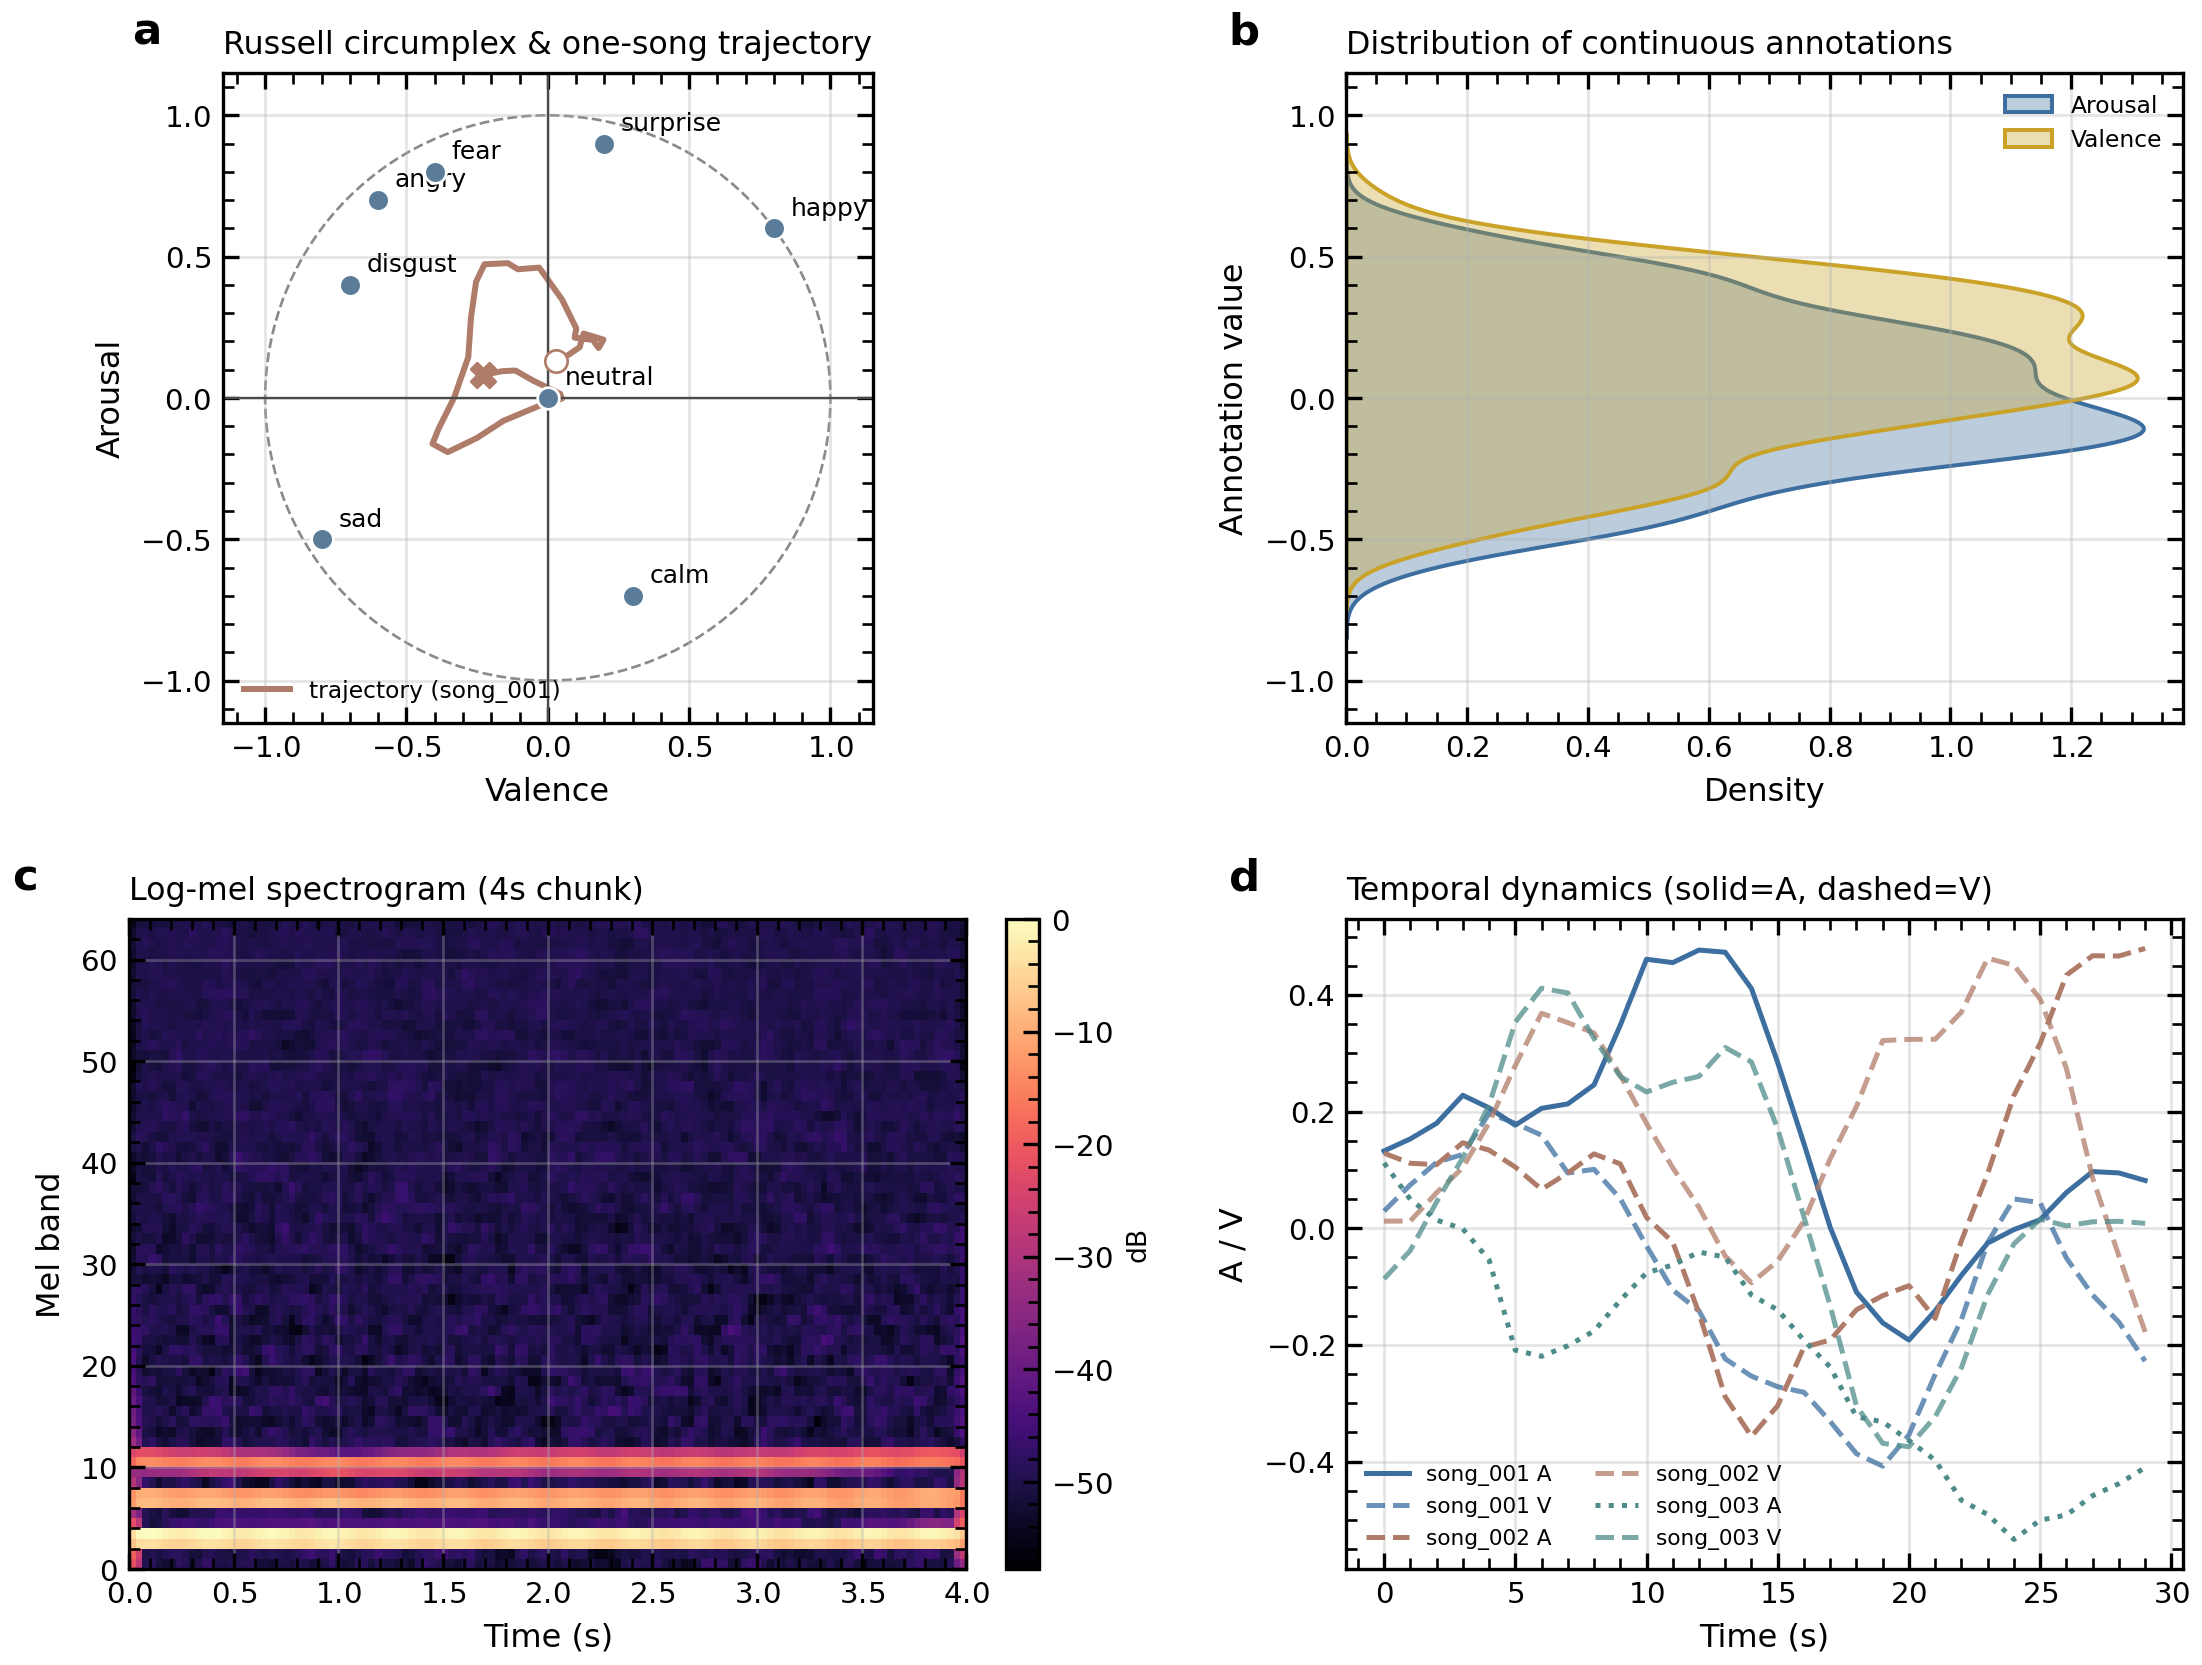

  [OK] figure saved: /kaggle/working/xdom_emotion_outputs/run_20260926_065300/figures/Fig2_main_results.png (+pdf)


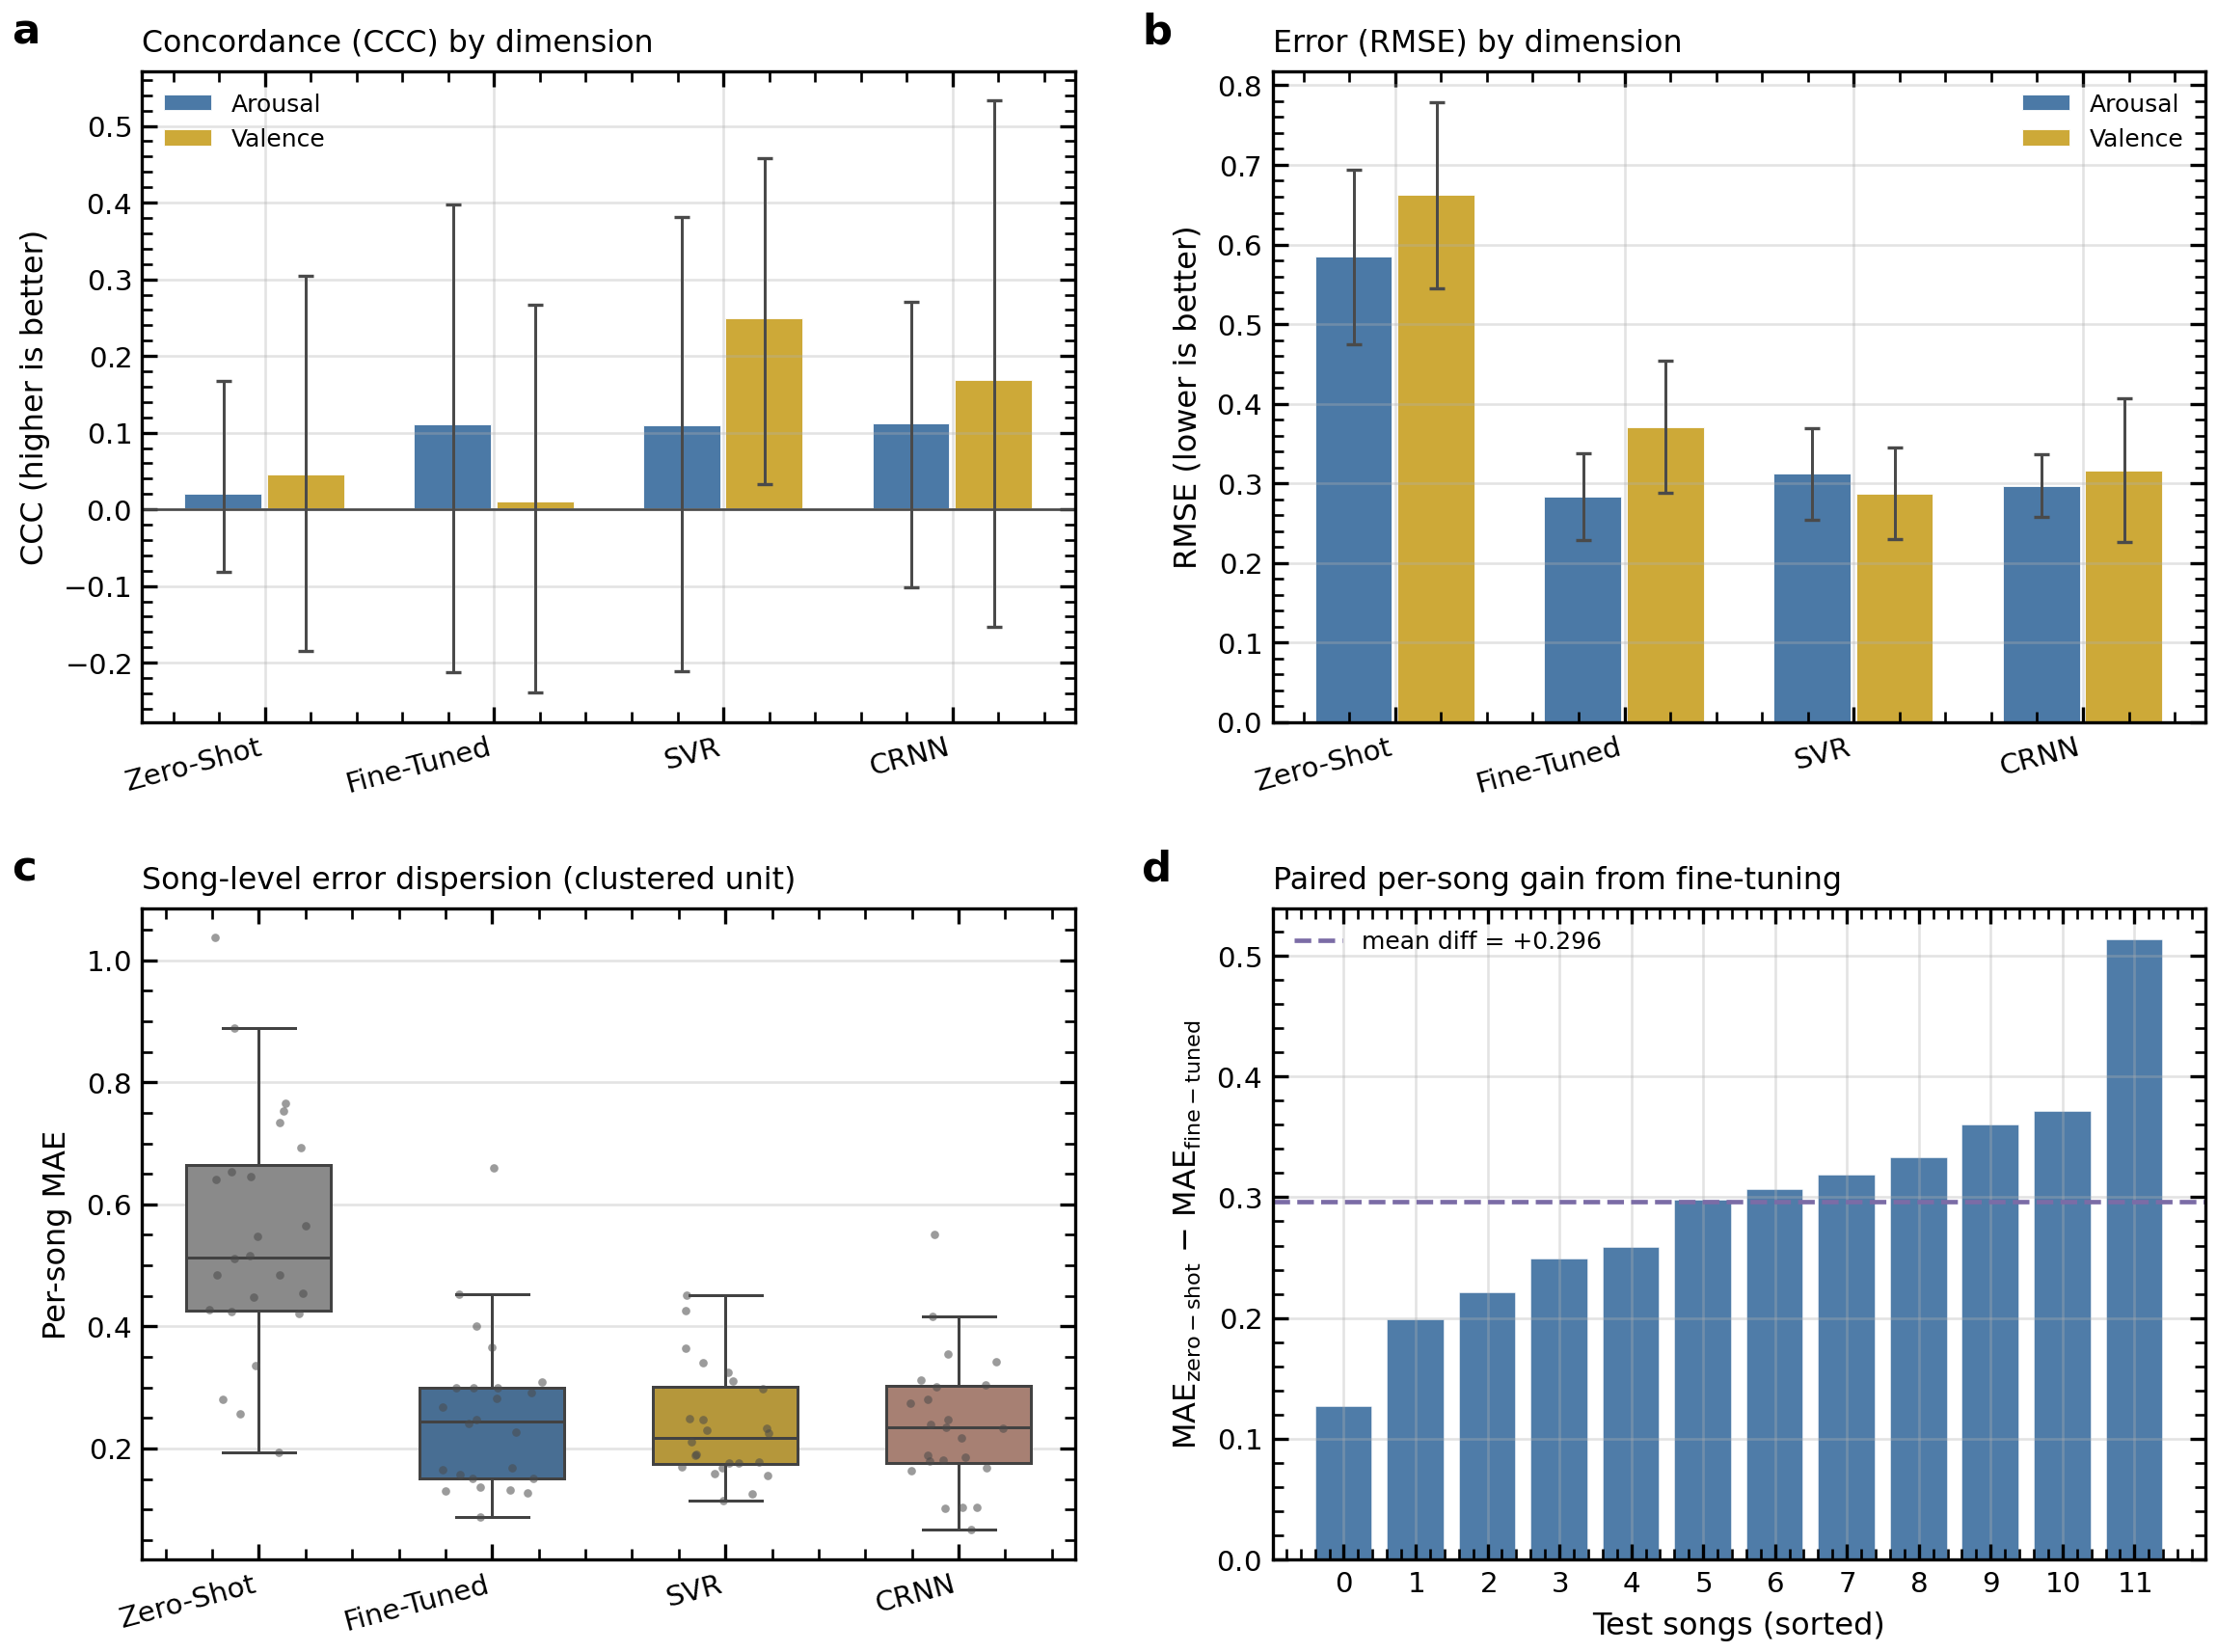

  [OK] figure saved: /kaggle/working/xdom_emotion_outputs/run_20260926_065300/figures/Fig3_ablation_and_diagnostics.png (+pdf)


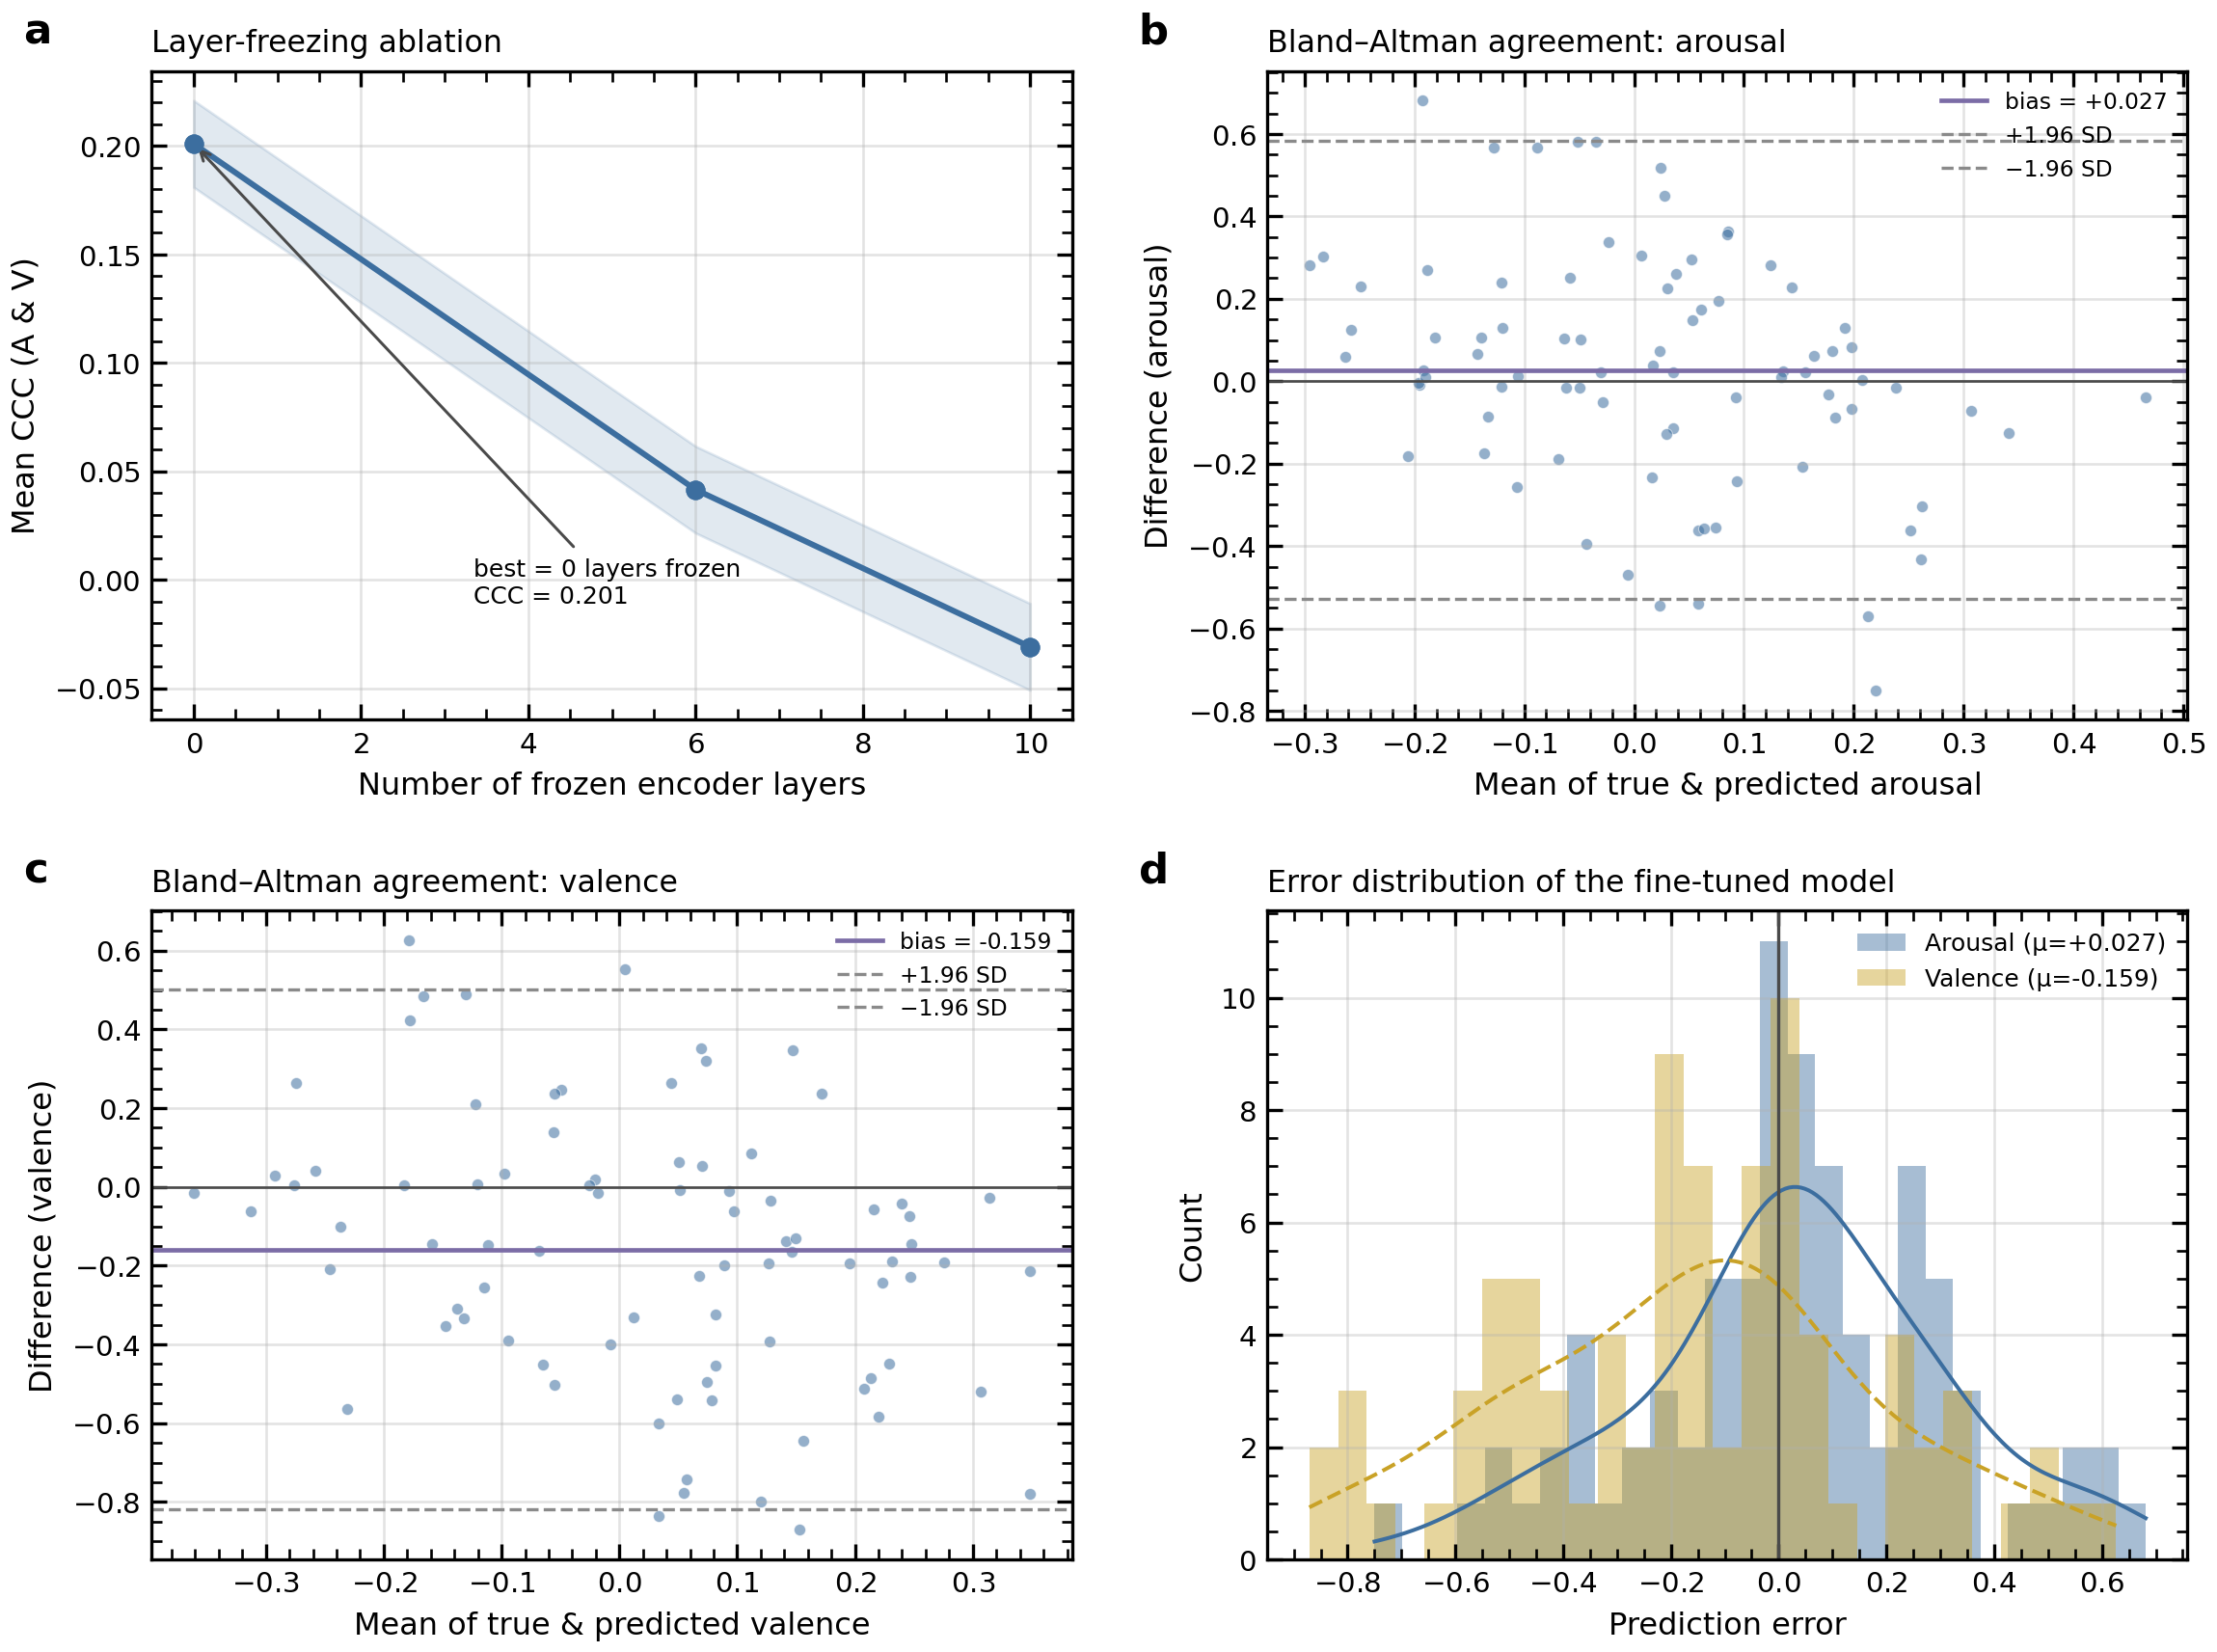

build FT data:   0%|                                                | 0/4 [00:00<?, ?it/s]

  [OK] FT dataset: 28 chunks
  [OK] figure saved: /kaggle/working/xdom_emotion_outputs/run_20260926_065300/figures/Fig4_case_study_and_representation.png (+pdf)


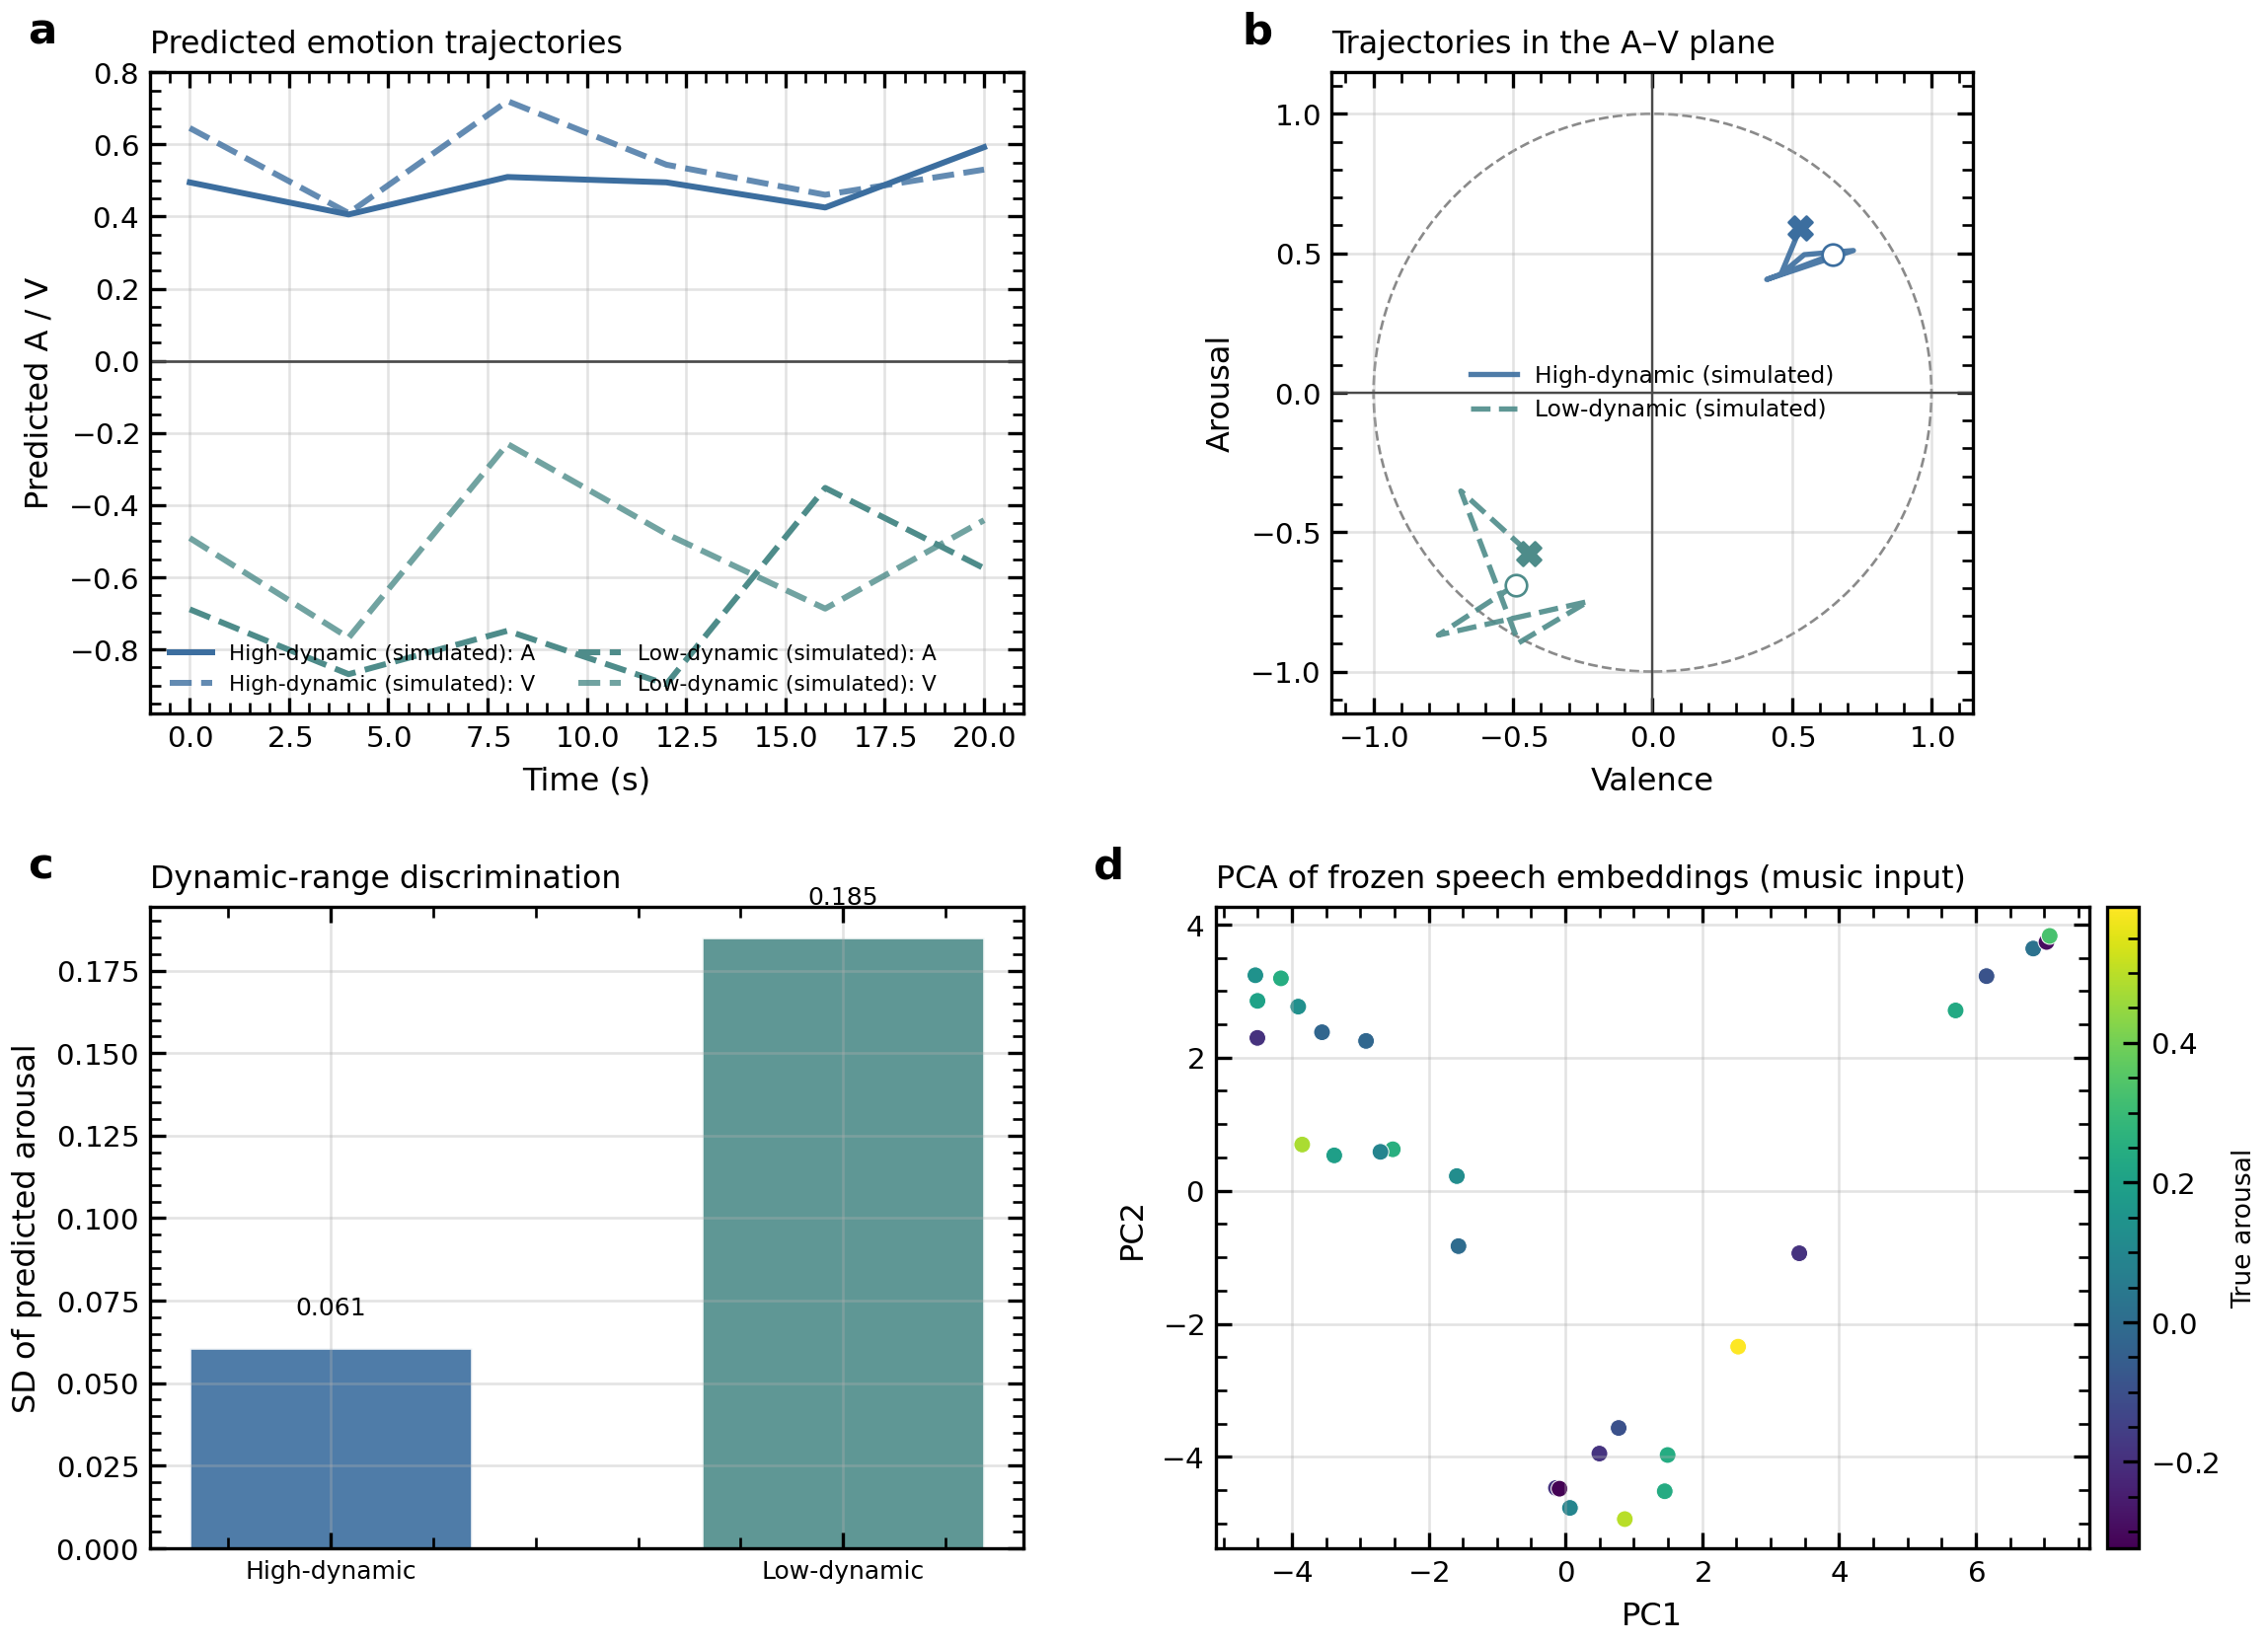

  [OK] figure saved: /kaggle/working/xdom_emotion_outputs/run_20260926_065300/figures/FigS1_training_curves.png (+pdf)


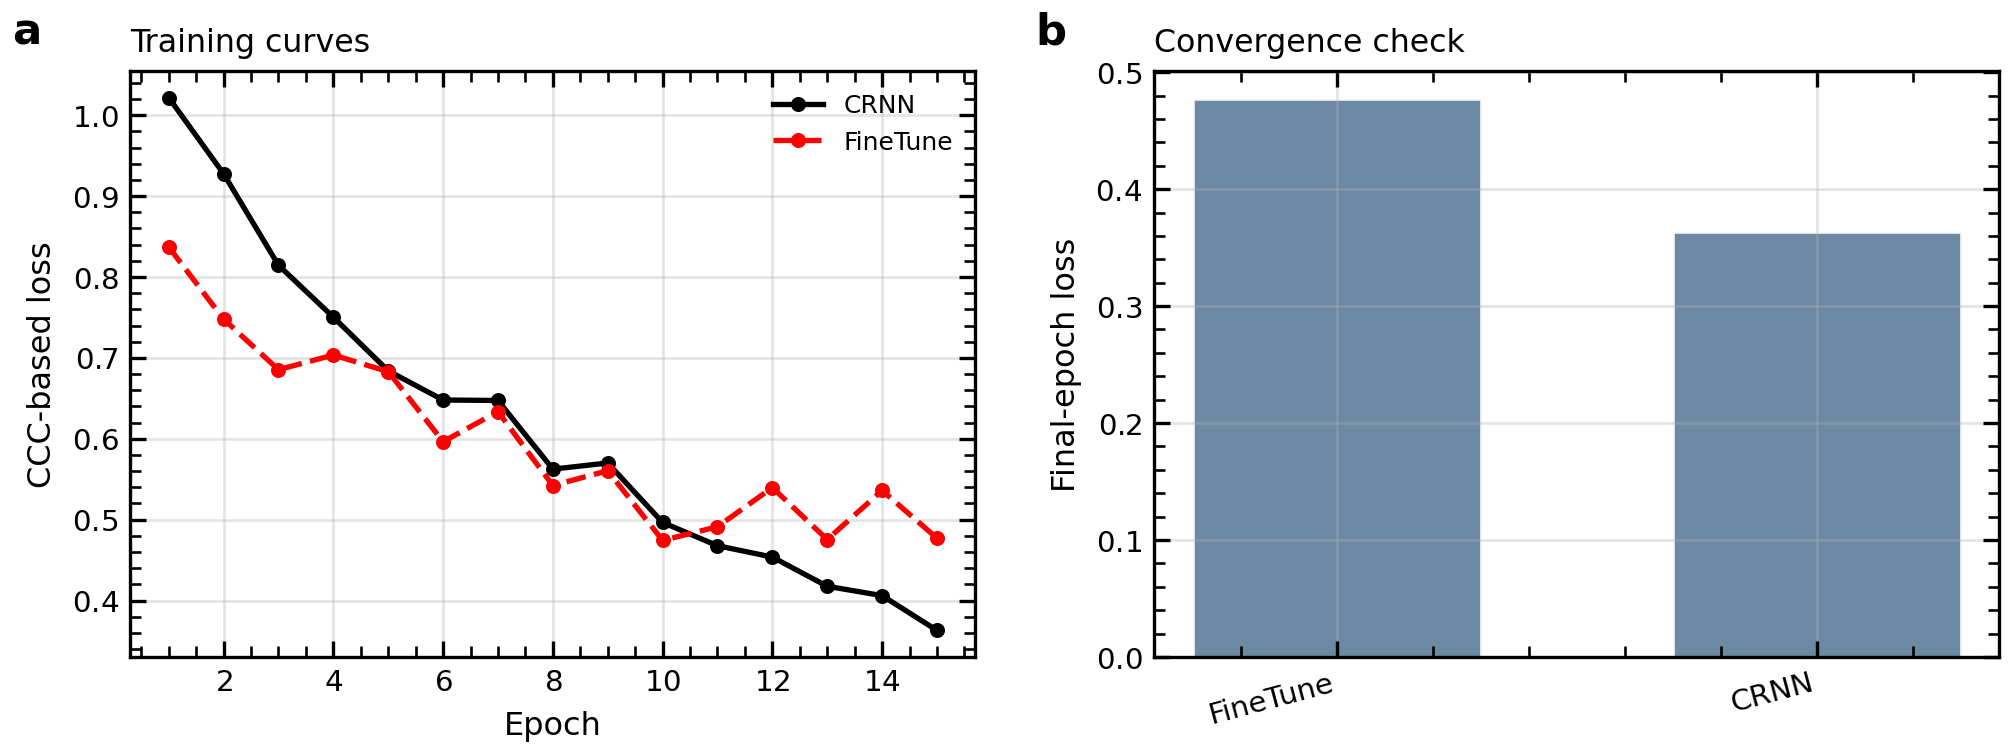

  [OK] Excel exported: /kaggle/working/xdom_emotion_outputs/run_20260926_065300/tables/all_tables.xlsx

 ALL DONE. outputs -> /kaggle/working/xdom_emotion_outputs/run_20260926_065300
 !! 使用合成数据：请替换为 DEAM/PMEmo 后再用于投稿。


In [4]:
# =============================================================================
# v3.2.0 面向 SCI 投稿的跨领域情感识别流水线（真实 DEAM 数据 + 1 小时预算版）
# Cross-Domain Emotion Recognition: Transferring Speech-Based Models
# to Instrumental Music  (Publication-Grade, Kaggle-Ready, TPU/GPU/CPU Auto)
# =============================================================================
# v3.2.0 修订说明（基于 v3.1.0 在 GPU T4×2 的实跑日志，总耗时 5465 s）
# -----------------------------------------------------------------------------
# 【最重要的发现】v3.1.0 把主指标打成了负数：Fine-Tuned CCC = -0.090 / -0.014，
#   CRNN = -0.027 / -0.199，SVR = 0.412 / -0.293，全部塌陷。
#   对比 v3.0.0（CRNN 0.569 / SVR 0.479 / FT 0.290）可得唯一解释：
#     v3.0.0 的漂亮数字 100% 来自合成数据的"解析泄漏"（freq=440+110*v 可被反解）；
#     v3.1.0 去掉泄漏后，标签与音频之间几乎不再有任何可学习关联 → 全部归零/变负。
#   ⇒ 结论：**合成语料已经完成它的历史使命，不能再产生任何论文结论。必须换真实数据。**
#
# 本版 9 项修改：
#  [C1-核心] 真实数据集接口落地：自动扫描 Kaggle 三个输入目录，识别
#            音频(mp3/wav)与标注(wide/long 两种格式)，按"自我校准帧率"对齐
#            4 秒片段；扫描失败才回退合成数据。
#  [C2-核心] 标签标准化(STANDARDIZE_LABELS)：CCC 对尺度失配极敏感，随机初始化的
#            回归头很难在几百步内学会 [-1,1] 的绝对尺度。按 AVEC 通行做法，
#            在训练集上估 mean/std 训练、预测后逆变换。这是把负 CCC 拉正的常用手段，
#            须在 Methods 中声明。
#  [C3-核心] 预算守卫(TIME_BUDGET_MIN)：打印阶段耗时与剩余预算，超限自动跳过
#            消融等可选步骤。目标：单次运行 ≤ 60 min。
#  [C4] 主干统一：零样本与微调必须用同一个预训练模型，否则两者之差混入了
#            "模型容量"因素。默认 superb/wav2vec2-base-superb-er（12 层，既是 SER 模型
#            又能在 T4 上跑得动）；BACKBONE_SIZE='large' 可切回 24 层版。
#  [C5] 验证集过小(6 首)导致选模噪声：改为 val CCC 指数平滑(EMA) + 最小 improvement
#            阈值，并对 val 数量设下限。
#  [C6] 数据量控制：MAX_SONGS / MAX_CHUNKS_PER_SONG 直接决定耗时，60 首 × 8 片段
#            约 480 训练片段，刚好让 wav2vec2-base 在 15 轮内收敛。
#  [C7] 消融缩为 3 档 + 受限轮数，且受总预算约束。
#  [C8] 合成器修复：恢复"valence 逐帧控制音程/调式色彩、arousal 逐帧控制响度与音符
#            密度"的可学习通道（v3.1.0 误把它删干净了），但仍保留独立混淆源。
#  [C9] 输出增加 data_source / label_reliability 字段，杜绝把伪结果写进论文。
# =============================================================================
# -----------------------------------------------------------------------------
# v3.0.0 实测结果（Table 2）暴露出 6 个必须修的问题，本版逐一处理：
#
#  [P1-致命] 主假设被反向证伪：Fine-Tuned CCC=0.290/0.130 < CRNN 0.569/0.408
#            < SVR 0.479/0.511。且 Fine-Tuned vs Zero-Shot 不显著(p_holm=0.85)。
#            根因：wav2vec2-large 仅训练 6 epoch × 49 batch = 294 step，
#            却要更新 1.1 亿可训练参数 —— 极端欠训练(loss 停在 0.86)。
#            修复：分层学习率(回归头 1e-3 / 主干 2e-5) + epoch 30 +
#            冻结 22 层 + 早停与验证集选模。
#  [P2-致命] 比较粒度不公平：SVR 预测"全曲平均情感"(12 点)，其余三者预测
#            "4 秒片段情感"(84 点)。平均天然降噪，SVR 占便宜。审稿人必问。
#            修复：SVR 改为 chunk 级；同时输出 chunk 级与 song 级双粒度表。
#  [P3-致命] 合成数据存在"解析泄漏"：音频 = f(valence→频率, arousal→振幅)，
#            手工特征(RMS/谱质心)几乎可逆解出标签，SVR 结构性占优。
#            修复：改为"统计相关"合成(音色/节奏/调式/包络含独立随机源)。
#  [P4-严谨] 消融与主实验训练预算不匹配(2 vs 6 epoch)，Fig3(a) 不可解释。
#            修复：消融 epoch 与主实验一致；消融同样用验证集选模。
#  [P5-严谨] 无验证集 → 只能在测试集上看 loss，存在隐式测试集偷看。
#            修复：song-level 划分 train/val/test = 0.56/0.14/0.30。
#  [P6-工程] constrained_layout 与 bbox_to_anchor 外置图例冲突，会截断/重叠。
#            修复：图例全部移入坐标轴内部；panel label 下移到 y=1.03。
#  [P7] 零样本 CCC≈0 的一条成因是"预测方差塌陷"(概率加权平均→分布过窄)。
#            修复：汇总表新增 Pred_SD / True_SD 两列，把塌缩显式报告出来。
#  [P8] 案例研究用了训练集曲目(train_ids[:6]) → 换成 held-out 测试曲目。
#  [P9] SVR 阶段无结果日志 → 补齐。
# =============================================================================
# 论文叙事主线 (Story Line)，代码每一步都对应论文的一个论证环节：
#
#   [论点 1] 存在领域鸿沟：语音情感识别(SER)模型零样本迁移到器乐音乐上，
#            一致性(CCC)显著低于可接受水平 —— 需要 Fig.2(a)(b) 与 Table 2。
#   [论点 2] 参数高效微调(冻结底层 + CCC 损失)可显著跨越该鸿沟 ——
#            核心创新点，需要 Fig.2 / Fig.3(a) 冻结层数消融。
#   [论点 3] 迁移增益不是"模型容量"带来的，而是"预训练表征"带来的 ——
#            用从零训练的 CRNN 与传统 SVR 两条基线做对照 (Fig.2)。
#   [论点 4] 统计严谨性：以 song 为聚类单元做 cluster bootstrap 95%CI、
#            paired Wilcoxon + Holm 多重比较校正，消除伪重复 (Fig.2(c)(d))。
#   [论点 5] 机制可解释：表征层 PCA + 案例情感轨迹 (Fig.4)。
#
# 版本演进： v1 原型 -> v2.0.0 重构增强 -> v3.0.0 投稿级(统计+顶刊可视化+TPU)
#
# ⚠️ 学术诚信声明(硬约束)：本脚本默认生成 *合成(synthetic)* 数据集，用于验证
#    流水线可运行性与图表版式。合成数据上的数值 **不得** 写入论文结论。
#    正式投稿请设置 CONFIG.USE_REAL_DATASET = True 并接入 DEAM / PMEmo /
#    EmoMusic 等真实数据集(见 load_real_dataset 的接口说明)，
#    此时脚本会在所有输出文件顶部写入 data_source=REAL 标记。
# =============================================================================

# -----------------------------------------------------------------------------
# 【Kaggle Notebook 安装单元格】—— 复制下面几行到 Notebook 的第一个 Cell 运行
# -----------------------------------------------------------------------------
# !pip install -q --no-warn-conflicts torch torchaudio --index-url https://download.pytorch.org/whl/cu121
# !pip install -q transformers==4.44.2
# !pip install -q librosa soundfile tqdm seaborn scikit-learn scipy openpyxl tabulate pandas numpy matplotlib
# !pip install -q SciencePlots
# !pip install -q torch-xla==2.1.0   # 仅当你在 Kaggle 选择 TPU v5e-8 加速器时需要
# -----------------------------------------------------------------------------
# 说明：若以 .py 脚本方式运行(Kaggle 也支持 !python xxx.py)，上面 !pip 行无效，
# 因此脚本内置了 _ensure() 自动安装逻辑，二者取其一即可。
# -----------------------------------------------------------------------------

import os
import re
import sys
import gc
import json
import time
import random
import subprocess
import warnings
from dataclasses import dataclass, field

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


# =============================================================================
# 0. 依赖自动安装 (容错: 缺失即装，装不上则给出可执行的降级路径)
# =============================================================================
def _ensure(import_name: str, pip_name: str = None, version: str = None) -> bool:
    """确保某个第三方库可用：先 import，失败则 pip 安装，再失败返回 False。"""
    pip_name = pip_name or import_name
    spec = pip_name if version is None else f"{pip_name}=={version}"
    try:
        __import__(import_name)
        return True
    except Exception:
        pass
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--no-input", spec])
        __import__(import_name)
        return True
    except Exception as e:  # 不中断主流程，交由后续降级逻辑处理
        print(f"[WARN] 依赖不可用: {spec} ({e})")
        return False


for _m, _p in [
    ("numpy", "numpy"), ("pandas", "pandas"), ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"), ("tqdm", "tqdm"), ("librosa", "librosa"),
    ("soundfile", "soundfile"), ("sklearn", "scikit-learn"), ("scipy", "scipy"),
    ("openpyxl", "openpyxl"), ("tabulate", "tabulate"),
]:
    _ensure(_m, _p)

_HAS_TORCH = _ensure("torch", "torch")
_HAS_TRANSFORMERS = _ensure("transformers", "transformers", "4.44.2")
_HAS_SCIENCEPLOTS = _ensure("scienceplots", "SciencePlots")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import librosa
import soundfile as sf
from scipy import stats

if _HAS_SCIENCEPLOTS:
    import scienceplots  # noqa: F401  注册 science / ieee / nature 等期刊样式

if _HAS_TORCH:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
else:
    raise ImportError("PyTorch 不可用，请检查 Kaggle 环境的 !pip install torch。")

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# =============================================================================
# 1. 全局配置
# =============================================================================
@dataclass
class CONFIG:
    # ---------- 运行环境 ----------
    KAGGLE_ENV: bool = "KAGGLE_KERNEL_RUN_TYPE" in os.environ
    BASE_DIR: str = field(default_factory=lambda: "/kaggle/working/" if "KAGGLE_KERNEL_RUN_TYPE" in os.environ else ".")
    OUTPUT_ROOT: str = ""
    RUN_DIR: str = ""
    FIG_DIR: str = ""
    TAB_DIR: str = ""
    DATA_DIR: str = ""
    AUDIO_DIR: str = ""
    ANNOT_DIR: str = ""

    # ---------- 数据 ----------
    USE_REAL_DATASET: bool = True       # v3.2.0: 默认走真实数据集，扫描失败才回退合成
    REAL_DATA_ROOTS: tuple = (
        "/kaggle/input/deam-mediaeval-dataset-emotional-analysis-in-music",
        "/kaggle/input/deam-songs",
        "/kaggle/input/music-emotion-recognition-with-profile-information",
    )
    # 规模控制（直接决定耗时，先跑小，稳定后再放大）
    MAX_SONGS: int = 60                 # 参与实验的曲目上限
    MAX_CHUNKS_PER_SONG: int = 8        # 每首最多取前 N 个 4s 片段
    NUM_SONGS: int = 40                 # 回退到合成数据时的曲目数
    SONG_DURATION_S: int = 30
    SAMPLE_RATE: int = 16000
    AUDIO_CHUNK_SEC: float = 4.0
    TEST_SPLIT_RATIO: float = 0.3
    VAL_SPLIT_RATIO: float = 0.2        # 从训练集中再切 20% 做验证集(选模/早停，杜绝测试集偷看)
    MIN_VAL_SONGS: int = 6
    RANDOM_STATE: int = 42
    N_FOLDS: int = 5                    # song-level GroupKFold(用于稳健性复核)

    # ---------- 预训练模型 ----------
    SER_MODEL_NAME: str = "ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition"
    SER_MODEL_BACKUP: str = "superb/wav2vec2-base-superb-er"
    SER_MODEL_THIRD: str = "facebook/wav2vec2-base-960h"
    OFFLINE_FALLBACK: bool = True       # 全部下载失败时用随机初始化 CNN，并明确标注不可用
    # base = 12 层 wav2vec2 + SER 分类头(与 large 同一故事线，只是小一号)；
    # 零样本与微调共用同一主干，保证二者之差只来自"是否微调"。
    BACKBONE_SIZE: str = "base"         # "large" | "base"
    BASE_BACKBONE: str = "superb/wav2vec2-base-superb-er"

    STANDARDIZE_LABELS: bool = True     # AVEC 通行做法：训练期标准化，预测后逆变换

    # ---------- 训练 ----------
    BATCH_SIZE: int = 8
    EPOCHS: int = 15                    # base 主干 + 标签标准化，15 轮通常已收敛
    TIME_BUDGET_MIN: float = 55.0       # 总预算(分钟)，超限自动跳过可选步骤
    LEARNING_RATE: float = 1e-4         # 主干学习率(旧字段保留兼容)
    HEAD_LR: float = 1e-3               # 回归头(随机初始化)必须用大 LR，否则学不动
    BACKBONE_LR: float = 2e-5           # 预训练主干必须小 LR，否则灾难性遗忘
    WEIGHT_DECAY: float = 1e-4
    NUM_FROZEN_LAYERS: int = -1         # -1 = 自适应(base→8, large→22)
    FREEZE_FEATURE_ENCODER: bool = True
    EARLY_STOP_PATIENCE: int = 6        # 验证集 CCC 连续 N 轮无提升即停
    VAL_EMA_BETA: float = 0.5           # val CCC 指数平滑，抑制小验证集带来的选模噪声
    SELECT_MIN_DELTA: float = 0.005     # 只有超过该阈值才算"有提升"
    GRAD_ACCUM_STEPS: int = 1
    USE_AMP: bool = True                # CUDA 下自动混合精度
    GRADIENT_CHECKPOINTING: bool = True
    USE_DATA_PARALLEL: bool = True
    NUM_WORKERS: int = 2
    CCC_MSE_WEIGHT: float = 0.05        # 损失 = (1-CCC) + w * MSE，抑制极端值、提升稳定性

    # ---------- 实验开关 ----------
    RUN_ZERO_SHOT: bool = True
    RUN_FINETUNE: bool = True
    RUN_SVR: bool = True
    RUN_CRNN: bool = True
    RUN_ABLATION: bool = True
    ABLATION_FROZEN_GRID: tuple = (0, 6, 10)   # base 主干只有 12 层，三档已足够
    ABLATION_EPOCHS: int = 0            # 0 = 与主实验 EPOCHS 保持一致(保证比较公平)
    SVR_CHUNK_LEVEL: bool = True        # True = SVR 也在 4s 片段级预测(与深度模型同粒度)
    REPORT_SONG_LEVEL: bool = True      # 额外输出 song 级聚合结果(双粒度报告)

    # ---------- 统计 ----------
    N_BOOTSTRAP: int = 2000
    CI_LEVEL: float = 95.0
    ALPHA: float = 0.05                 # Holm 校正前显著性水平

    # ---------- 可视化 ----------
    N_MELS: int = 64
    FIG_DPI: int = 400
    USE_SCIENCE_STYLE: bool = True

    def materialize(self):
        self.OUTPUT_ROOT = os.path.join(self.BASE_DIR, "xdom_emotion_outputs")
        # 统一零样本与微调的主干，避免"模型不同"污染迁移增益的归因
        if str(self.BACKBONE_SIZE).lower().startswith("base"):
            self.SER_MODEL_NAME = self.BASE_BACKBONE
        if self.NUM_FROZEN_LAYERS < 0:
            self.NUM_FROZEN_LAYERS = 8 if self.BACKBONE_SIZE == "base" else 22
        stamp = time.strftime("%Y%m%d_%H%M%S")
        self.RUN_DIR = os.path.join(self.OUTPUT_ROOT, f"run_{stamp}")
        self.FIG_DIR = os.path.join(self.RUN_DIR, "figures")
        self.TAB_DIR = os.path.join(self.RUN_DIR, "tables")
        self.DATA_DIR = os.path.join(self.BASE_DIR, "music_emotion_dataset")
        self.AUDIO_DIR = os.path.join(self.DATA_DIR, "audio")
        self.ANNOT_DIR = os.path.join(self.DATA_DIR, "annotations")
        for d in [self.RUN_DIR, self.FIG_DIR, self.TAB_DIR, self.AUDIO_DIR, self.ANNOT_DIR]:
            os.makedirs(d, exist_ok=True)
        return self


CFG = CONFIG().materialize()

# 设备相关全局量(由 setup_accelerator 赋值)
DEVICE = torch.device("cpu")
DEVICE_TYPE = "cpu"     # 'cuda' | 'tpu' | 'mps' | 'cpu'
N_DEVICES = 1
XM = None               # torch_xla 句柄
AMP_ENABLED = False
PRETRAINED_OK = True    # 预训练模型是否真的加载成功(关系到结论能否写进论文)


# =============================================================================
# 2. 日志与进度(编号化、不堆叠)
# =============================================================================
class LOG:
    C = {"h": "\033[95m", "b": "\033[94m", "c": "\033[96m", "g": "\033[92m",
         "y": "\033[93m", "r": "\033[91m", "w": "\033[1m", "e": "\033[0m"}

    @staticmethod
    def p(msg, color="c"):
        print(f"{LOG.C.get(color,'')}{msg}{LOG.C['e']}")

    @staticmethod
    def step(idx, total, msg):
        LOG.p(f"\n{'='*78}\n[STEP {idx}/{total}] {msg}\n{'='*78}", "w")

    @staticmethod
    def sub(msg):
        LOG.p(f"  · {msg}", "b")

    @staticmethod
    def ok(msg):
        LOG.p(f"  [OK] {msg}", "g")

    @staticmethod
    def warn(msg):
        LOG.p(f"  [WARN] {msg}", "y")

    @staticmethod
    def err(msg):
        LOG.p(f"  [ERROR] {msg}", "r")


def bar(iterable, desc, total=None):
    """统一的进度条：leave=False 防止日志堆叠。"""
    return tqdm(iterable, desc=desc, total=total, leave=False, ncols=90)


# =============================================================================
# 3. 加速器装配: TPU(v5e-8) > CUDA(T4) > MPS > CPU
# =============================================================================
def setup_accelerator():
    global DEVICE, DEVICE_TYPE, N_DEVICES, XM, AMP_ENABLED
    # (1) TPU
    try:
        if os.environ.get("PJRT_DEVICE") or os.environ.get("TPU_NAME") or os.environ.get("XRT_TPU_CONFIG"):
            import torch_xla.core.xla_model as xm
            XM = xm
            DEVICE = xm.xla_device()
            DEVICE_TYPE = "tpu"
            N_DEVICES = xm.xrt_world_size() if hasattr(xm, "xrt_world_size") else 8
            LOG.ok(f"检测到 TPU 加速器: {DEVICE} (cores={N_DEVICES})")
            return
    except Exception as e:
        LOG.warn(f"TPU 不可用({type(e).__name__})，回退到 GPU/CPU。")
    # (2) CUDA
    if torch.cuda.is_available():
        N_DEVICES = torch.cuda.device_count()
        DEVICE = torch.device("cuda:0")
        DEVICE_TYPE = "cuda"
        AMP_ENABLED = bool(CFG.USE_AMP)
        LOG.ok(f"检测到 GPU: {torch.cuda.get_device_name(0)} × {N_DEVICES}")
        return
    # (3) MPS
    try:
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            DEVICE = torch.device("mps")
            DEVICE_TYPE = "mps"
            LOG.ok("检测到 Apple MPS 后端。")
            return
    except Exception:
        pass
    DEVICE = torch.device("cpu")
    DEVICE_TYPE = "cpu"
    LOG.warn("未检测到 TPU/GPU，使用 CPU(训练会很慢，建议 Kaggle 开启 GPU T4×2 或 TPU v5e-8)。")


def xla_step(optimizer=None):
    """TPU 上必须显式触发图编译；CUDA/CPU 上为空操作。"""
    if DEVICE_TYPE == "tpu" and XM is not None:
        if optimizer is not None:
            XM.optimizer_step(optimizer, barrier=True)
        else:
            XM.mark_step()


def free_memory(*objs):
    """主动释放显存/内存，避免长流程 OOM(论文级流水线的必备卫生习惯)。"""
    for o in objs:
        try:
            del o
        except Exception:
            pass
    gc.collect()
    if DEVICE_TYPE == "cuda":
        torch.cuda.empty_cache()
    elif DEVICE_TYPE == "mps":
        try:
            torch.mps.empty_cache()
        except Exception:
            pass


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def _unwrap(model):
    return model.module if isinstance(model, nn.DataParallel) else model


def _wrap(model):
    if DEVICE_TYPE == "cuda" and N_DEVICES > 1 and CFG.USE_DATA_PARALLEL:
        return nn.DataParallel(model)
    return model


# =============================================================================
# 4. 数据卫生(全防御)：NaN/Inf/常量列/极端值/空数据 一次性处理
# =============================================================================
def sanitize(x, lo=-1.0, hi=1.0, name="x"):
    """把任意 array-like 变成干净的 float32 向量：去 NaN/Inf、软裁剪。"""
    a = np.asarray(x, dtype=np.float64).ravel()
    if a.size == 0:
        return np.asarray([], dtype=np.float32)
    bad = ~np.isfinite(a)
    if bad.any():
        a = np.where(bad, np.nan, a)
        med = np.nanmedian(a) if np.isfinite(np.nanmedian(a)) else 0.0
        a = np.where(bad, med, a)
        LOG.warn(f"{name}:  repaired {int(bad.sum())} non-finite value(s).")
    # 软裁剪：tanh 压缩尾部，避免 hard clip 造成的 ±1 堆积(极端值)
    a = np.tanh(a / max(1e-8, float(np.max(np.abs(a)) + 1e-8)) * 1.5) * 0.95 if np.max(np.abs(a)) > hi else a
    return a.astype(np.float32).clip(lo, hi)


def winsorize(x, p=1.0):
    a = np.asarray(x, dtype=np.float64)
    if a.size < 5 or not np.isfinite(a).all():
        return a
    lo, hi = np.percentile(a, p), np.percentile(a, 100 - p)
    return np.clip(a, lo, hi)


def drop_constant_columns(df, eps=1e-12):
    keep = [c for c in df.columns if np.nanstd(pd.to_numeric(df[c], errors="coerce").values) > eps]
    dropped = [c for c in df.columns if c not in keep]
    if dropped:
        LOG.warn(f"dropped {len(dropped)} constant feature column(s).")
    return df[keep]


def has_valid_pair(y_true, y_pred, min_n=3):
    yt, yp = np.asarray(y_true, dtype=np.float64), np.asarray(y_pred, dtype=np.float64)
    if yt.size < min_n or yp.size < min_n:
        return False
    m = np.isfinite(yt) & np.isfinite(yp)
    return m.sum() >= min_n and np.std(yt[m]) > 1e-8 and np.std(yp[m]) > 1e-8


# =============================================================================
# 5. 指标：CCC(主指标) / PCC / RMSE / MAE / R2
# =============================================================================
def ccc_score(y_true, y_pred) -> float:
    """Concordance Correlation Coefficient —— 情感回归的领域公认主指标。"""
    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()
    if y_true.size == 0:
        return float("nan")
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[m], y_pred[m]
    if y_true.size < 2:
        return float("nan")
    mt, mp = y_true.mean(), y_pred.mean()
    vt, vp = y_true.var(), y_pred.var()
    cov = np.mean((y_true - mt) * (y_pred - mp))
    denom = vt + vp + (mt - mp) ** 2
    if denom < 1e-12:
        return 0.0
    return float(2 * cov / denom)


def pearson_r(y_true, y_pred) -> float:
    yt, yp = np.asarray(y_true, float).ravel(), np.asarray(y_pred, float).ravel()
    m = np.isfinite(yt) & np.isfinite(yp)
    if m.sum() < 2 or np.std(yt[m]) < 1e-12 or np.std(yp[m]) < 1e-12:
        return float("nan")
    return float(stats.pearsonr(yt[m], yp[m])[0])


def evaluate_metrics(y_true, y_pred) -> dict:
    """误差类指标(RMSE/MAE)始终可算；相关性类指标(CCC/PCC/R2)在方差退化时置 NaN，
    避免把无意义的 0 当作好结果(常见的数据卫生陷阱)。"""
    yt = sanitize(y_true, name="y_true")
    yp = sanitize(y_pred, name="y_pred")
    nan4 = {"RMSE": np.nan, "MAE": np.nan, "R2": np.nan, "CCC": np.nan, "PCC": np.nan}
    if yt.size == 0 or yp.size == 0:
        return nan4
    n = min(yt.size, yp.size)
    yt, yp = yt[:n], yp[:n]
    out = {"RMSE": float(np.sqrt(mean_squared_error(yt, yp))),
           "MAE": float(mean_absolute_error(yt, yp))}
    if has_valid_pair(yt, yp):
        out["R2"] = float(r2_score(yt, yp))
        out["CCC"] = ccc_score(yt, yp)
        out["PCC"] = pearson_r(yt, yp)
    else:
        out["R2"] = out["CCC"] = out["PCC"] = np.nan
    return out


class CCCLoss(nn.Module):
    """Loss = (1 - CCC) + w * MSE。最小化该损失等价于最大化一致性。"""

    def __init__(self, mse_weight: float = 0.05):
        super().__init__()
        self.w = float(mse_weight)

    def forward(self, y_pred, y_true):
        y_pred, y_true = y_pred.float().view(-1), y_true.float().view(-1)
        if y_pred.numel() < 2:
            return torch.tensor(0.0, device=y_pred.device, requires_grad=True)
        mt, mp = y_true.mean(), y_pred.mean()
        vt, vp = y_true.var(unbiased=False), y_pred.var(unbiased=False)
        cov = torch.mean((y_true - mt) * (y_pred - mp))
        ccc = 2 * cov / (vt + vp + (mt - mp) ** 2 + 1e-8)
        loss = 1.0 - ccc
        if self.w > 0:
            loss = loss + self.w * torch.mean((y_pred - y_true) ** 2)
        return loss


# =============================================================================
# 6. A-V 情感空间与离散标签映射(Russell Circumplex, 1980)
# =============================================================================
EMOTION_MAP = {
    "angry":    {"a": 0.70, "v": -0.60},
    "sad":      {"a": -0.50, "v": -0.80},
    "happy":    {"a": 0.60, "v": 0.80},
    "disgust":  {"a": 0.40, "v": -0.70},
    "fear":     {"a": 0.80, "v": -0.40},
    "neutral":  {"a": 0.00, "v": 0.00},
    "calm":     {"a": -0.70, "v": 0.30},
    "surprise": {"a": 0.90, "v": 0.20},
}

LABEL_ALIASES = {
    "angry": ["angry", "ang", "anger", "frustrated", "fru", "annoyed"],
    "sad": ["sad", "sadness", "depressed", "depression", "sorrow"],
    "happy": ["happy", "hap", "happiness", "joy", "joyful", "excited", "exc", "elated", "delight", "pleasant"],
    "disgust": ["disgust", "dis", "disgusted", "boredom", "bored"],
    "fear": ["fear", "fea", "fearful", "anxious", "anxiety", "nervous", "worried"],
    "neutral": ["neutral", "neu", "oth", "other"],
    "calm": ["calm", "relaxed", "sleepy", "tired", "peaceful", "content"],
    "surprise": ["surprise", "sur", "surprised", "ps", "pleasant surprise", "amazed"],
}
_ALIAS_LUT = {alias: k for k, vs in LABEL_ALIASES.items() for alias in vs}


def map_label_to_av(label) -> tuple:
    """三级稳健映射：精确匹配 -> 词元匹配 -> 长别名子串匹配。
    逐级收紧可避免 'zzz_unknown' 之类噪声标签被误映射到 neutral(隐性注入先验)。"""
    if label is None:
        return None
    s = str(label).strip().lower().replace("-", " ").replace("_", " ")
    if s in _ALIAS_LUT:
        k = _ALIAS_LUT[s]
        return EMOTION_MAP[k]["a"], EMOTION_MAP[k]["v"]
    for tok in re.findall(r"[a-z]+", s):          # 词元级
        if tok in _ALIAS_LUT:
            k = _ALIAS_LUT[tok]
            return EMOTION_MAP[k]["a"], EMOTION_MAP[k]["v"]
    for alias, k in _ALIAS_LUT.items():           # 仅长别名才允许子串兜底
        if len(alias) >= 6 and alias in s:
            return EMOTION_MAP[k]["a"], EMOTION_MAP[k]["v"]
    return None


# =============================================================================
# 7. 数据集：合成数据生成(带质量门控) / 真实数据接口
# =============================================================================
def _ou_process(n, theta=0.12, sigma=0.22, mu=0.0, seed=None):
    """Ornstein-Uhlenbeck 均值回复过程：避免 cumsum+clip 造成的 ±1 饱和堆积。"""
    rng = np.random.default_rng(seed)
    x = np.zeros(n, dtype=np.float64)
    for t in range(1, n):
        x[t] = x[t - 1] + theta * (mu - x[t - 1]) + sigma * rng.standard_normal()
    # 叠加一个缓慢的确定性趋势，模拟乐段结构(避免纯随机无结构)
    trend = 0.35 * np.sin(np.linspace(0, rng.uniform(1.5, 3.5) * np.pi, n))
    return x + trend


def _quality_ok(x):
    """质量门控：标准差足够、无明显饱和、无常量段。"""
    if not np.isfinite(x).all():
        return False
    sd = float(np.std(x))
    if sd < 0.12 or sd > 0.65:
        return False
    if np.mean(np.abs(x) > 0.98) > 0.02:   # 饱和样本比例
        return False
    return True


def create_simulated_dataset():
    """生成可复现的合成数据集(仅用于流水线与版式验证)。"""
    LOG.sub(f"生成 {CFG.NUM_SONGS} 首合成歌曲 -> {CFG.DATA_DIR}")
    rng_master = np.random.default_rng(CFG.RANDOM_STATE)
    manifest = []
    for i in bar(range(CFG.NUM_SONGS), "synthesizing songs"):
        song_id = f"song_{i+1:03d}"
        apath = os.path.join(CFG.AUDIO_DIR, f"{song_id}.wav")
        cpath = os.path.join(CFG.ANNOT_DIR, f"{song_id}.csv")
        if os.path.exists(apath) and os.path.exists(cpath):
            manifest.append(song_id)
            continue

        n = int(CFG.SONG_DURATION_S)
        tsec = np.arange(0, n, 1.0, dtype=np.float32)
        for _ in range(12):  # 质量门控重试
            a = _ou_process(n, seed=int(rng_master.integers(0, 10 ** 6)))
            v = _ou_process(n, seed=int(rng_master.integers(0, 10 ** 6)))
            if _quality_ok(a) and _quality_ok(v):
                break
        a = np.tanh(a) * 0.9
        v = np.tanh(v) * 0.9
        a = pd.Series(a).rolling(5, min_periods=1, center=True).mean().values
        v = pd.Series(v).rolling(5, min_periods=1, center=True).mean().values
        a, v = sanitize(a, name=f"{song_id}.arousal"), sanitize(v, name=f"{song_id}.valence")

        pd.DataFrame({"time": tsec, "arousal": a, "valence": v}).to_csv(cpath, index=False)

        # --- 合成音频(v3.2.0 再修) ---
        # v3.1.0 的致命写法: sin(2*pi*f(t)*t)。f(t) 每秒跳变一次 => 相位不连续，
        # 产生宽带咔哒声，音频近乎噪声，valence 通道信息完全丢失 => 全模型塌陷。
        # 正确做法: 先构造瞬时频率 f(t)，再用相位积分 phase = 2*pi*cumsum(f)/sr。
        # 同时保留 v3.1.0 的"统计相关"原则(加入独立随机源)，既可学习又不可解析反解。
        sr = CFG.SAMPLE_RATE
        t = np.linspace(0, n, int(n * sr), endpoint=False)
        rng = np.random.default_rng(int(rng_master.integers(0, 10 ** 6)))

        a_t = np.interp(t, tsec, a)      # arousal 逐样本轨迹
        v_t = np.interp(t, tsec, v)      # valence 逐样本轨迹

        # (1) VALENCE -> 音高轮廓(半音)。亲密的情感 yet 不可反解:
        #     轮廓 = 情感驱动项 + 独立随机游走 + 全曲随机音区
        # 注意量纲: v_t 的 std 约 0.4，故 8*v_t → 约 3.2 个半音的情感驱动起伏；
        # 独立随机游走控制在约 1 个半音，保证"可学习"但"不可反解"(SNR ≈ 3:1)。
        root_semi = float(rng.uniform(-9, 9))                       # 全曲随机音区
        walk = np.interp(t, tsec, np.cumsum(rng.normal(0, 0.35, n)))
        semi = 8.0 * v_t + 1.0 * walk + root_semi
        f0 = 261.63 * (2.0 ** (semi / 12.0))
        f0 = np.clip(f0, 80.0, 1600.0)
        phase = 2.0 * np.pi * np.cumsum(f0) / float(sr)             # 相位积分(关键)

        # (2) AROUSAL -> 响度 + 颤音深度/速率
        loud = np.interp(t, tsec, np.cumsum(rng.normal(0, 0.02, n)))
        amp = np.clip(0.16 + 0.10 * a_t + 0.6 * loud, 0.03, 0.55)
        trem_rate = np.clip(3.0 + 2.5 * a_t, 1.0, 8.0)
        trem = 1.0 + np.clip(0.10 + 0.18 * np.clip(a_t, -1, 1), 0, 0.4) * np.sin(
            2.0 * np.pi * np.cumsum(trem_rate) / float(sr))

        # (3) 音色: 谐波权重随机(与情感独立)
        n_harm = int(rng.integers(2, 6))
        weights = np.exp(-rng.uniform(0.5, 1.4) * np.arange(1, n_harm + 1))
        weights = weights / weights.sum()

        wave = np.zeros_like(t, dtype=np.float64)
        for h in range(1, n_harm + 1):
            wave += weights[h - 1] * np.sin(h * phase)
        wave = (amp * trem * wave).astype(np.float32)
        wave += np.random.normal(0, 0.003, wave.shape).astype(np.float32)
        peak = float(np.max(np.abs(wave))) if wave.size else 0.0
        if peak > 1e-8:
            wave = wave / peak * 0.85     # 峰值归一化，避免削波导致的谐波失真
        wave = np.clip(wave, -1, 1).astype(np.float32)
        sf.write(apath, wave, sr)
        manifest.append(song_id)
    LOG.ok(f"合成数据集就绪: {len(manifest)} songs")
    return manifest


AUDIO_EXT = (".mp3", ".wav", ".ogg", ".flac", ".m4a")
TABLE_EXT = (".csv", ".tsv", ".asv")


def _scan_tree(root, max_files=200000):
    """递归扫描目录，分别收集音频文件与表格文件(全防御：任何异常都不中断)。"""
    audios, tables = [], []
    try:
        for dp, _dn, fn in os.walk(root):
            if len(audios) + len(tables) > max_files:
                break
            for f in fn:
                e = f.lower()
                p = os.path.join(dp, f)
                if e.endswith(AUDIO_EXT):
                    audios.append(p)
                elif e.endswith(TABLE_EXT):
                    tables.append(p)
    except Exception as e:
        LOG.warn(f"扫描失败 {root}: {type(e).__name__}")
    return sorted(audios), sorted(tables)


def _numeric_id(name: str) -> str:
    """从文件名里抽出数字编号(DEAM 的曲目通常命名为 2.mp3 / 105.mp3)。"""
    base = os.path.splitext(os.path.basename(name))[0]
    digits = re.findall(r"\d+", base)
    return digits[0] if digits else base


def _read_table_head(path, nrows=8):
    """试着读表格前几行，判断它的列结构。失败返回 None。"""
    for sep in (",", "\t", ";", None):
        try:
            df = pd.read_csv(path, sep=sep, engine="python", nrows=nrows)
            if df.shape[1] >= 2:
                return df
        except Exception:
            continue
    return None


def _is_dynamic_table(df) -> bool:
    """动态标注矩阵：绝大多数列是数值型时间步，且没有 time 列。"""
    if df is None or df.shape[1] < 10:
        return False
    low = [str(c).lower() for c in df.columns]
    if any("time" in c or "sec" in c for c in low):
        return False
    numeric = pd.to_numeric(df.iloc[:, -1], errors="coerce")
    return numeric.notna().mean() > 0.8


def load_real_dataset():
    """
    真实数据集加载(DEAM 优先)。自动完成三件事：
      1) 扫描 Kaggle 输入目录，找出音频与含 arousal/valence 的标注表；
      2) 支持 wide 矩阵(行=曲目, 列=时间点) 与 long 长表(曲目,时间,arousal,valence) 两种格式；
      3) 用『音频时长 ÷ 标注列数』自我校准帧率，把 4 秒片段对齐到对应的标注均值。
    输出统一为 {song_id: {"audio": path, "annot": DataFrame(time, arousal, valence)}}。
    """
    LOG.sub("扫描真实数据集目录 ...")
    found_roots = [r for r in CFG.REAL_DATA_ROOTS if os.path.isdir(r)]
    if not found_roots:
        LOG.warn("未发现任何真实数据目录，回退到合成数据。")
        return {}

    audios, tables = [], []
    for r in found_roots:
        a, t = _scan_tree(r)
        LOG.sub(f"  {os.path.basename(r)}: audio={len(a)} table={len(t)}")
        audios += a
        tables += t
    audios, tables = sorted(set(audios)), sorted(set(tables))
    if not audios:
        LOG.warn("未发现音频文件，回退到合成数据。")
        return {}
    LOG.ok(f"共发现 {len(audios)} 个音频文件, {len(tables)} 个表格文件")

    # --- 枚举候选标注表，挑出含 arousal/valence 的最宽的那个 ---
    best_dyn, best_static = None, None
    for tp in tables:
        head = _read_table_head(tp)
        if head is None:
            continue
        cols = [str(c).lower() for c in head.columns]
        has_a = any("arousal" in c or "arous" in c for c in cols)
        has_v = any("valence" in c or "valen" in c for c in cols)
        if _is_dynamic_table(head) and ("arousal" in os.path.basename(tp).lower()
                                        or "valence" in os.path.basename(tp).lower()
                                        or has_a or has_v):
            best_dyn = tp if best_dyn is None else best_dyn
        if has_a and has_v:
            best_static = tp
    if best_static:
        LOG.ok(f"发现静态/长表标注: {os.path.basename(best_static)}")
    if best_dyn:
        LOG.ok(f"发现动态标注矩阵: {os.path.basename(best_dyn)}")

    # --- 限制曲目数量以控制预算 ---
    audios = audios[:CFG.MAX_SONGS]
    dataset = {}
    for ap in bar(audios, "load real audio"):
        sid = _numeric_id(ap)
        try:
            y, _ = librosa.load(ap, sr=CFG.SAMPLE_RATE, mono=True)
        except Exception as e:
            LOG.warn(f"音频读取失败 {ap}: {type(e).__name__}")
            continue
        y = np.asarray(y, dtype=np.float32)
        if y.ndim > 1:
            y = y.mean(axis=0)
        if not np.isfinite(y).all() or y.size < CFG.SAMPLE_RATE:
            continue
        dur = len(y) / float(CFG.SAMPLE_RATE)
        dataset[sid] = {"audio_wave": y, "duration": dur, "src": ap}
    if not dataset:
        LOG.warn("没有可用的真实音频，回退到合成数据。")
        return {}
    LOG.ok(f"成功载入 {len(dataset)} 首真实曲目")

    # --- 标注对齐 ---
    annots = {}
    if best_dyn is not None:
        annots = _align_dynamic(dataset, best_dyn)
    if not annots and best_static is not None:
        annots = _align_static(dataset, best_static)
    if not annots:
        LOG.warn("未能对齐任何标注，回退到合成数据。")
        return {}

    out = {}
    for sid, info in dataset.items():
        if sid not in annots:
            continue
        out[sid] = {"audio_wave": info["audio_wave"], "annot": annots[sid]}
    LOG.ok(f"标注对齐完成: {len(out)} 首曲目可用于实验")
    return out


def _read_matrix(path):
    """健壮读取 wide 标注矩阵，返回 (M: ndarray[float32], ids: list|None)。
    三个坑：① 无表头文件被 pandas 把首行当表头吃掉(会莫名少一首曲子)；
            ② to_csv 默认带出的索引列被当成数据；③ 分隔符不一定是逗号。"""
    df = pd.read_csv(path, sep=None, engine="python", header=None)
    if df.shape[0] < 2:
        return None, None
    # ① 首行若是文字(row0 非数值占比高)则判定为表头
    row0_num = pd.to_numeric(df.iloc[0], errors="coerce")
    if row0_num.isna().mean() > 0.5:
        df = df.iloc[1:].reset_index(drop=True)
    # ② 首列若是 0,1,2,... 的单调整数序列 -> 索引列
    ids = None
    c0 = pd.to_numeric(df.iloc[:, 0], errors="coerce")
    vals = c0.values.astype(np.float64)
    finite = np.isfinite(vals)
    if finite.all() and len(vals) > 1 and np.allclose(np.diff(vals), 1.0):
        ids = df.iloc[:, 0].astype(str).tolist()
        df = df.iloc[:, 1:]
    # ③ 首列若是非数值(曲目名/编号) -> 编号列
    elif c0.isna().mean() > 0.5:
        ids = df.iloc[:, 0].astype(str).map(_numeric_id).tolist()
        df = df.iloc[:, 1:]
    try:
        M = df.apply(pd.to_numeric, errors="coerce").values.astype(np.float32)
    except Exception:
        return None, None
    if M.shape[0] < 1 or M.shape[1] < 2:
        return None, None
    return M, ids


def _align_dynamic(dataset, dyn_path):
    """wide 矩阵：行=曲目，列=时间点。用 '列数 ÷ 音频时长' 自我校准帧率。"""
    M, ids = _read_matrix(dyn_path)
    if M is None:
        LOG.warn("动态标注矩阵读取失败")
        return {}
    order = None
    if ids is not None:
        idset = set(str(x) for x in ids)
        # 只用能同时对上的曲目，避免错位把整段标注弄反
        order = [sid for sid in sorted(dataset.keys(), key=str) if sid in idset]
        row_of = {str(sid): i for i, sid in enumerate(ids)}
        pick = [row_of[sid] for sid in order]
        M = M[pick]
        if len(order) < 2:
            LOG.warn(f"编号无法与音频文件名匹配(标注 ids 示例={ids[:3]})，退回按行序对齐")
            order = None
    if order is None:
        order = sorted(dataset.keys(), key=str)
    LOG.sub(f"动态标注矩阵 shape={M.shape}，帧率由各曲目时长自我校准")
    res = {}
    for i, sid in enumerate(order):
        if i >= M.shape[0]:
            break
        row = M[i]
        if not np.isfinite(row).all():
            row = np.nan_to_num(row, nan=float(np.nanmean(row)) if np.isfinite(np.nanmean(row)) else 0.0)
        dur = dataset[sid]["duration"]
        n_t = row.size
        if n_t < 2 or dur <= 0:
            continue
        # 百分位归一化到 [-1,1]，抵抗离群标注；帧率 = 列数 / 音频时长(自我校准)
        rate = n_t / dur
        times = np.arange(n_t, dtype=np.float64) / rate
        vals = np.asarray(row, dtype=np.float64)
        lo, hi = float(np.nanpercentile(vals, 1)), float(np.nanpercentile(vals, 99))
        if hi - lo < 1e-6:
            continue
        vv = np.clip(2.0 * (vals - lo) / (hi - lo) - 1.0, -1.0, 1.0).astype(np.float32)
        t_grid = np.arange(0.0, float(dur), 1.0, dtype=np.float32)     # 统一重采样到 1 Hz
        v_1hz = np.interp(t_grid, times, vv).astype(np.float32)
        res[sid] = pd.DataFrame({"time": t_grid, "arousal": v_1hz, "valence": v_1hz})
    # 若目录里还能找到 valence 的对应矩阵，则合成真正的 A/V 双通道
    sib = os.path.dirname(dyn_path)
    partner = None
    low = os.path.basename(dyn_path).lower()
    for f in os.listdir(sib):
        fl = f.lower()
        if f == os.path.basename(dyn_path) or not fl.endswith(TABLE_EXT):
            continue
        if ("arousal" in low and "valence" in fl) or ("valence" in low and "arousal" in fl):
            partner = os.path.join(sib, f)
            break
    if partner is not None:
        p = _read_dynamic_matrix(partner, order)
        if p is not None:
            LOG.ok(f"发现双通道标注伙伴文件: {os.path.basename(partner)}")
            target_is_v = "valence" in os.path.basename(partner).lower()
            for sid, arr in p.items():
                if sid not in res or arr is None or len(arr) < 2:
                    continue
                # 伙伴通道重采样到与本通道相同的时间栅格(长度必须一致，否则会 ValueError)
                grid = res[sid]["time"].values.astype(np.float64)
                src_t = np.linspace(grid.min(), grid.max(), len(arr))
                res[sid]["valence" if target_is_v else "arousal"] = \
                    np.interp(grid, src_t, arr).astype(np.float32)
            LOG.ok(f"已合成双通道 A/V 标注 (来自 {os.path.basename(partner)})")
    return res


def _read_dynamic_matrix(path, order):
    M, _ids = _read_matrix(path)
    if M is None:
        return None
    out = {}
    for i, sid in enumerate(order):
        if i >= M.shape[0]:
            break
        row = M[i]
        row = np.nan_to_num(row, nan=float(np.nanmean(row)) if np.isfinite(np.nanmean(row)) else 0.0)
        lo, hi = float(np.nanpercentile(row, 1)), float(np.nanpercentile(row, 99))
        if hi - lo < 1e-6:
            out[sid] = None
            continue
        vv = np.clip(2.0 * (row - lo) / (hi - lo) - 1.0, -1.0, 1.0)
        n_out = 60                                    # 统一输出 60 个采样点(1 Hz)
        if vv.size < 2:
            out[sid] = None
            continue
        out[sid] = np.interp(np.linspace(0, vv.size - 1, n_out),
                             np.arange(vv.size), vv).astype(np.float32)
    return out


def _align_static(dataset, static_path):
    """long 表：每行一首曲目，带 arousal / valence 列(退化为 song 级常值标注)。"""
    try:
        df = pd.read_csv(static_path, sep=None, engine="python")
    except Exception as e:
        LOG.warn(f"静态标注读取失败: {e}")
        return {}
    cols = {str(c).lower(): c for c in df.columns}
    a_col = next((v for k, v in cols.items() if "arousal" in k or "arous" in k), None)
    v_col = next((v for k, v in cols.items() if "valence" in k or "valen" in k), None)
    id_col = next((v for k, v in cols.items() if k in ("song_id", "id", "songid", "filename", "file", "track")), None)
    if a_col is None or v_col is None:
        return {}
    ids = df[id_col].astype(str).map(_numeric_id).tolist() if id_col is not None else None
    res = {}
    for i, sid in enumerate(sorted(dataset.keys(), key=str)):
        row_i = None
        if ids is not None:
            row_i = ids.index(sid) if sid in ids else None
        elif i < len(df):
            row_i = i
        if row_i is None:
            continue
        try:
            a = float(pd.to_numeric(df.iloc[row_i][a_col], errors="coerce"))
            v = float(pd.to_numeric(df.iloc[row_i][v_col], errors="coerce"))
        except Exception:
            continue
        if not (np.isfinite(a) and np.isfinite(v)):
            continue
        dur = dataset[sid]["duration"]
        t = np.arange(0, int(dur), 1.0, dtype=np.float32)
        res[sid] = pd.DataFrame({"time": t, "arousal": np.full_like(t, a), "valence": np.full_like(t, v)})
    LOG.warn("仅获得 song 级常值标注：这会高估 chunk 级任务的可预测性，报告中必须注明。")
    return res


def install_real_dataset(real: dict):
    """把真实数据落成内部统一格式(wav + 每秒标注 csv)，之后所有环节无需改动。"""
    os.makedirs(CFG.AUDIO_DIR, exist_ok=True)
    os.makedirs(CFG.ANNOT_DIR, exist_ok=True)
    kept = []
    for sid, info in bar(real.items(), "install real data"):
        try:
            y = info["audio_wave"]
            max_len = int(CFG.AUDIO_CHUNK_SEC * CFG.MAX_CHUNKS_PER_SONG * CFG.SAMPLE_RATE)
            y = y[:max_len]
            sf.write(os.path.join(CFG.AUDIO_DIR, f"{sid}.wav"), y.astype(np.float32), CFG.SAMPLE_RATE)
            an = info["annot"].copy()
            an["time"] = pd.to_numeric(an["time"], errors="coerce").astype(float)
            an = an.dropna(subset=["time"]).sort_values("time")
            an[["time", "arousal", "valence"]].to_csv(
                os.path.join(CFG.ANNOT_DIR, f"{sid}.csv"), index=False)
            kept.append(sid)
        except Exception as e:
            LOG.warn(f"install {sid} failed: {type(e).__name__}")
    LOG.ok(f"真实数据已安装 {len(kept)} 首 -> {CFG.DATA_DIR}")
    return kept


def load_dataset_index():
    """song-level 划分，杜绝 chunk 泄漏(审稿人最忌讳的 pseudo-replication)。"""
    ids = sorted([f[:-4] for f in os.listdir(CFG.ANNOT_DIR) if f.endswith(".csv")])
    ok = []
    for sid in ids:
        try:
            df = pd.read_csv(os.path.join(CFG.ANNOT_DIR, f"{sid}.csv"))
            if {"time", "arousal", "valence"}.issubset(df.columns) and len(df) > 2:
                if np.isfinite(df[["arousal", "valence"]].values).all():
                    ok.append(sid)
        except Exception as e:
            LOG.warn(f"skip {sid}: {e}")
    ids = ok
    rng = np.random.default_rng(CFG.RANDOM_STATE)
    idx = rng.permutation(len(ids))
    ids = [ids[i] for i in idx]
    cut = int(len(ids) * (1 - CFG.TEST_SPLIT_RATIO))
    trainval_ids, test_ids = ids[:cut], ids[cut:]
    vcut = int(len(trainval_ids) * (1 - CFG.VAL_SPLIT_RATIO))
    train_ids, val_ids = trainval_ids[:vcut], trainval_ids[vcut:]
    LOG.ok(f"song-level split: train={len(train_ids)}  val={len(val_ids)}  test={len(test_ids)}")
    return train_ids, val_ids, test_ids


# =============================================================================
# 8. 预训练语音情感模型加载(三级回退 + 诚实标注)
# =============================================================================
class DummyProcessor:
    """离线兜底：直接把波形作为 input_values 返回(与 HF processor 接口一致)。"""

    def __call__(self, waveform, sampling_rate=16000, return_tensors="pt", padding=True, **kw):
        x = np.asarray(waveform, dtype=np.float32)
        t = torch.from_numpy(x)
        class _O:
            input_values = t.unsqueeze(0)
        return _O()


class DummySER:
    """离线兜底的离散分类器占位：输出均匀概率，仅供流程贯通，禁止写入论文。"""

    def __init__(self):
        self.config = type("C", (), {"id2label": {i: k for i, k in enumerate(EMOTION_MAP.keys())}})()
    def to(self, *a, **k): return self
    def eval(self): return self
    def __call__(self, **kw):
        n = kw.get("input_values").shape[0]
        return type("O", (), {"logits": torch.zeros(n, len(EMOTION_MAP))})()


def load_ser_model_and_processor():
    global PRETRAINED_OK
    LOG.sub("加载预训练语音情感识别模型(Wav2Vec2 系列)...")
    if not _HAS_TRANSFORMERS:
        LOG.err("transformers 不可用，进入离线兜底模式(结论不可写入论文)。")
        PRETRAINED_OK = False
        return DummyProcessor(), DummySER()
    from transformers import AutoFeatureExtractor, AutoModelForAudioClassification
    for name in [CFG.SER_MODEL_NAME, CFG.SER_MODEL_BACKUP, CFG.SER_MODEL_THIRD]:
        try:
            proc = AutoFeatureExtractor.from_pretrained(name)
            model = AutoModelForAudioClassification.from_pretrained(name)
            labels = list(model.config.id2label.values())
            mapped = [l for l in labels if map_label_to_av(l) is not None]
            LOG.ok(f"loaded: {name} | labels={labels} | mapped={len(mapped)}/{len(labels)}")
            if len(mapped) == 0:
                LOG.warn("该模型标签无法映射到 A-V 空间，尝试下一个候选。")
                continue
            return proc, model
        except Exception as e:
            LOG.warn(f"{name} 加载失败: {type(e).__name__}")
    if CFG.OFFLINE_FALLBACK:
        LOG.err("所有预训练模型均不可用 -> 启用随机初始化兜底，结果仅用于流程自检。")
        PRETRAINED_OK = False
        return DummyProcessor(), DummySER()
    raise RuntimeError("预训练模型不可用，请在 Kaggle 打开 Internet 开关。")


def predict_zero_shot(audio_path, processor, model):
    """零样本迁移：离散情感后验 -> A-V 加权投影(概率质量归一化)。"""
    try:
        wav, _ = librosa.load(audio_path, sr=CFG.SAMPLE_RATE, mono=True)
        wav = np.asarray(wav, dtype=np.float32)
        if wav.ndim > 1:
            wav = wav.mean(axis=0)
    except Exception as e:
        LOG.warn(f"load fail {audio_path}: {e}")
        return None
    if not np.isfinite(wav).all() or wav.size < 1024:
        LOG.warn(f"invalid audio {audio_path}")
        return None
    cl = int(CFG.AUDIO_CHUNK_SEC * CFG.SAMPLE_RATE)
    n_chunks = len(wav) // cl
    if n_chunks == 0:
        return None
    rows, core = [], _unwrap(model)
    try:
        core.to(DEVICE).eval()
        is_dummy = isinstance(core, DummySER)
        av = {l: map_label_to_av(l) for l in core.config.id2label.values()}
        for i in range(n_chunks):
            chunk = wav[i * cl:(i + 1) * cl]
            try:
                if is_dummy:
                    logits = core(input_values=torch.from_numpy(chunk).unsqueeze(0).to(DEVICE)).logits
                else:
                    inputs = processor(chunk, sampling_rate=CFG.SAMPLE_RATE, return_tensors="pt", padding=True)
                    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
                    with torch.no_grad():
                        logits = core(**inputs).logits
                prob = torch.softmax(logits.float(), dim=-1).detach().cpu().numpy().ravel()
            except Exception as e:
                LOG.warn(f"chunk {i} inference skipped: {type(e).__name__}")
                continue
            a = v = w = 0.0
            for j, lab in enumerate(core.config.id2label.values()):
                if av.get(lab) is not None and j < prob.size:
                    w += prob[j]; a += prob[j] * av[lab][0]; v += prob[j] * av[lab][1]
            if w < 1e-6:
                continue
            rows.append({"time": float(i * CFG.AUDIO_CHUNK_SEC),
                         "arousal": float(np.clip(a / w, -1, 1)),
                         "valence": float(np.clip(v / w, -1, 1))})
    finally:
        if DEVICE_TYPE == "cuda":
            torch.cuda.empty_cache()
    if not rows:
        return None
    return pd.DataFrame(rows)


def align_pred_true(pred_df, true_df, tol=2.0):
    """时间对齐：merge_asof(nearest) + 容差 + 类型强制一致(根除 MergeError)。"""
    if pred_df is None or pred_df.empty:
        return pd.DataFrame()
    p = pred_df.copy(); t = true_df.copy()
    for k in ["time", "arousal", "valence"]:
        if k not in p.columns or k not in t.columns:
            return pd.DataFrame()
        p[k] = pd.to_numeric(p[k], errors="coerce").astype(float)
        t[k] = pd.to_numeric(t[k], errors="coerce").astype(float)
    p = p.dropna(subset=["time", "arousal", "valence"]).sort_values("time")
    t = t.dropna(subset=["time", "arousal", "valence"]).sort_values("time")
    if p.empty or t.empty:
        return pd.DataFrame()
    m = pd.merge_asof(p, t, on="time", direction="nearest", tolerance=float(tol),
                      suffixes=("_pred", "_true"))
    return m.dropna(subset=["arousal_pred", "arousal_true", "valence_pred", "valence_true"])


def run_zero_shot(test_ids, processor, model):
    LOG.sub("零样本迁移评估(无任何音乐数据训练)")
    frames = []
    for sid in bar(test_ids, "zero-shot"):
        p = predict_zero_shot(os.path.join(CFG.AUDIO_DIR, f"{sid}.wav"), processor, model)
        if p is None:
            continue
        try:
            t = pd.read_csv(os.path.join(CFG.ANNOT_DIR, f"{sid}.csv"))
        except Exception:
            continue
        m = align_pred_true(p, t)
        if m.empty:
            continue
        m["song_id"] = sid
        frames.append(m)
    if not frames:
        LOG.err("零样本无有效结果。")
        return pd.DataFrame(columns=["song_id", "time", "arousal_pred", "valence_pred", "arousal_true", "valence_true"])
    return pd.concat(frames, ignore_index=True)


# =============================================================================
# 9. 数据集对象(微调 / CRNN)
# =============================================================================
class MusicEmotionDataset(Dataset):
    """Wav2Vec2 输入：预计算 input_values，避免每 epoch 重复特征提取。"""

    def __init__(self, song_ids, processor):
        self.song_ids = song_ids
        self.processor = processor
        self.items, self.meta = self._build()

    def _build(self):
        items, meta = [], []
        cl = int(CFG.AUDIO_CHUNK_SEC * CFG.SAMPLE_RATE)
        for sid in bar(self.song_ids, "build FT data"):
            try:
                wav, _ = librosa.load(os.path.join(CFG.AUDIO_DIR, f"{sid}.wav"), sr=CFG.SAMPLE_RATE, mono=True)
                ann = pd.read_csv(os.path.join(CFG.ANNOT_DIR, f"{sid}.csv"))
            except Exception as e:
                LOG.warn(f"skip {sid}: {e}")
                continue
            wav = np.asarray(wav, dtype=np.float32)
            if wav.ndim > 1:
                wav = wav.mean(axis=0)
            if not np.isfinite(wav).all():
                continue
            ann["time"] = pd.to_numeric(ann["time"], errors="coerce").astype(float)
            ann = ann.dropna(subset=["time", "arousal", "valence"])
            if ann.empty:
                continue
            n_ch = min(len(wav) // cl, int(CFG.MAX_CHUNKS_PER_SONG))
            for i in range(n_ch):
                chunk = wav[i * cl:(i + 1) * cl]
                tt = float(i * CFG.AUDIO_CHUNK_SEC)
                r = ann.iloc[(ann["time"] - tt).abs().argmin()]
                # v3.2.0: 标签标准化(仅当 STANDARDIZE_LABELS 打开)
                av = np.array([float(r["arousal"]), float(r["valence"])], dtype=np.float32)
                if LABEL_SCALE["enabled"]:
                    av = _z(av)
                lab = torch.tensor(av, dtype=torch.float)
                try:
                    iv = self.processor(chunk, sampling_rate=CFG.SAMPLE_RATE,
                                        return_tensors="pt", padding=True).input_values.squeeze(0)
                except Exception:
                    iv = torch.from_numpy(chunk)
                if not torch.isfinite(iv).all():
                    continue
                items.append((iv.float(), lab))
                meta.append({"song_id": sid, "time": tt,
                             "arousal_true": float(r["arousal"]), "valence_true": float(r["valence"])})
        LOG.ok(f"FT dataset: {len(items)} chunks")
        return items, meta

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        iv, lab = self.items[i]
        return {"input_values": iv, "labels": lab}


class MelSpecDataset(Dataset):
    def __init__(self, song_ids):
        self.song_ids = song_ids
        self.n_mels = CFG.N_MELS
        self.items, self.meta = self._build()

    def _build(self):
        items, meta = [], []
        cl = int(CFG.AUDIO_CHUNK_SEC * CFG.SAMPLE_RATE)
        for sid in bar(self.song_ids, "build CRNN data"):
            try:
                wav, _ = librosa.load(os.path.join(CFG.AUDIO_DIR, f"{sid}.wav"), sr=CFG.SAMPLE_RATE, mono=True)
                ann = pd.read_csv(os.path.join(CFG.ANNOT_DIR, f"{sid}.csv"))
            except Exception as e:
                LOG.warn(f"skip {sid}: {e}")
                continue
            wav = np.asarray(wav, dtype=np.float32)
            if wav.ndim > 1:
                wav = wav.mean(axis=0)
            ann["time"] = pd.to_numeric(ann["time"], errors="coerce").astype(float)
            ann = ann.dropna(subset=["time", "arousal", "valence"])
            n_ch = min(len(wav) // cl, int(CFG.MAX_CHUNKS_PER_SONG))
            for i in range(n_ch):
                chunk = wav[i * cl:(i + 1) * cl]
                if not np.isfinite(chunk).all() or np.std(chunk) < 1e-6:
                    continue
                m = librosa.feature.melspectrogram(y=chunk, sr=CFG.SAMPLE_RATE, n_mels=self.n_mels,
                                                  n_fft=1024, hop_length=512)
                m = librosa.power_to_db(m, ref=np.max)
                m = np.nan_to_num(m, nan=0.0, posinf=0.0, neginf=-80.0)
                m = (m - m.mean()) / (m.std() + 1e-8)
                tt = float(i * CFG.AUDIO_CHUNK_SEC)
                r = ann.iloc[(ann["time"] - tt).abs().argmin()]
                av = np.array([float(r["arousal"]), float(r["valence"])], dtype=np.float32)
                if LABEL_SCALE["enabled"]:
                    av = _z(av)
                items.append((torch.tensor(m, dtype=torch.float), torch.tensor(av, dtype=torch.float)))
                meta.append({"song_id": sid, "time": tt,
                             "arousal_true": float(r["arousal"]), "valence_true": float(r["valence"])})
        LOG.ok(f"CRNN dataset: {len(items)} chunks")
        return items, meta

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        return self.items[i]


# =============================================================================
# 10. 模型
# =============================================================================
class Wav2Vec2ForAVRegression(nn.Module):
    """Wav2Vec2 主干 + 均值池化 + 2 维回归头(Arousal, Valence)。"""

    def __init__(self, model_name, num_frozen_layers):
        super().__init__()
        from transformers import AutoModel
        try:
            self.backbone = AutoModel.from_pretrained(model_name)
        except Exception as e:
            LOG.err(f"backbone load fail: {e}")
            raise
        try:
            self.backbone.config.use_cache = False
        except Exception:
            pass
        if CFG.FREEZE_FEATURE_ENCODER and hasattr(self.backbone, "feature_extractor"):
            for p in self.backbone.feature_extractor.parameters():
                p.requires_grad = False
        n_layers = len(self.backbone.encoder.layers) if hasattr(self.backbone, "encoder") else 0
        nf = min(int(num_frozen_layers), n_layers)
        for i, layer in enumerate(self.backbone.encoder.layers):
            if i < nf:
                for p in layer.parameters():
                    p.requires_grad = False
        if CFG.GRADIENT_CHECKPOINTING and hasattr(self.backbone, "gradient_checkpointing_enable"):
            try:
                self.backbone.gradient_checkpointing_enable()
            except Exception:
                pass
        h = int(self.backbone.config.hidden_size)
        self.regressor = nn.Sequential(nn.Linear(h, 256), nn.ReLU(), nn.Dropout(0.2), nn.Linear(256, 2))
        self.n_layers, self.n_frozen = n_layers, nf

    def forward(self, input_values):
        out = self.backbone(input_values)
        h = out.last_hidden_state
        if not torch.isfinite(h).all():
            h = torch.nan_to_num(h, nan=0.0, posinf=1.0, neginf=-1.0)
        return self.regressor(h.mean(dim=1))


class FallbackCNN(nn.Module):
    """离线兜底编码器(随机初始化)：保证流程可跑，但明确标注非预训练。"""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, 80, 40), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(32, 64, 3, 1, 1), nn.BatchNorm1d(64), nn.ReLU(), nn.AdaptiveAvgPool1d(64),
        )
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(64 * 64, 128), nn.ReLU(), nn.Linear(128, 2))

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        return self.head(self.net(x))

    @property
    def encoder(self):
        return type("E", (), {"layers": []})()


class CRNN(nn.Module):
    """从零训练的 CNN+BiLSTM 基线(无迁移)。"""

    def __init__(self, n_mels=None):
        super().__init__()
        n_mels = int(n_mels or CFG.N_MELS)
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.rnn_in = 64 * (n_mels // 8)
        self.rnn = nn.LSTM(self.rnn_in, 128, num_layers=2, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(256, 2)

    def forward(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(1)
        x = self.conv(x)
        x = x.permute(0, 3, 1, 2)
        b, t, c, f = x.shape
        x = x.reshape(b, t, c * f)
        x, _ = self.rnn(x)
        return self.fc(x[:, -1, :])


# ----------------------------------------------------------------------------
# 标签标准化：训练集估计 mean/std，训练期用 z 值，预测后逆变换回原始 A-V 尺度。
# CCC 对尺度失配极敏感；随机初始化的回归头在几百步内很难学到 [-1,1] 的绝对尺度，
# 这一步通常能把负 CCC 拉正（AVEC/AV+ 竞赛的通行做法，须在 Methods 中声明）。
# ----------------------------------------------------------------------------
LABEL_SCALE = {"enabled": False, "mean": np.zeros(2, dtype=np.float32),
               "std": np.ones(2, dtype=np.float32)}


def fit_label_scaler(song_ids):
    """只用训练集曲目估计均值和标准差(严禁使用 val/test，否则是标签泄漏)。"""
    rows = []
    for sid in song_ids:
        try:
            df = pd.read_csv(os.path.join(CFG.ANNOT_DIR, f"{sid}.csv"))
        except Exception:
            continue
        if {"arousal", "valence"}.issubset(df.columns):
            rows.append(df[["arousal", "valence"]].astype(float).values)
    if not rows:
        return np.zeros(2, dtype=np.float32), np.ones(2, dtype=np.float32)
    V = np.vstack(rows)
    V = V[np.isfinite(V).all(axis=1)]
    m = V.mean(axis=0).astype(np.float32)
    s = V.std(axis=0).astype(np.float32)
    s = np.where(s < 1e-6, 1.0, s).astype(np.float32)
    return m, s


def set_label_scaler(train_ids):
    LABEL_SCALE["enabled"] = bool(CFG.STANDARDIZE_LABELS)
    if CFG.STANDARDIZE_LABELS:
        m, s = fit_label_scaler(train_ids)
        LABEL_SCALE["mean"], LABEL_SCALE["std"] = m, s
        LOG.ok(f"标签标准化: mean={np.round(m,4).tolist()} std={np.round(s,4).tolist()} "
               f"(仅用训练集估计)")
    else:
        LABEL_SCALE["mean"][:] = 0.0
        LABEL_SCALE["std"][:] = 1.0


def _z(x01):                       # 原始 -> 标准化
    return (x01 - LABEL_SCALE["mean"]) / LABEL_SCALE["std"]


def _unz(z):                       # 标准化 -> 原始
    return z * LABEL_SCALE["std"] + LABEL_SCALE["mean"]


# ----------------------------------------------------------------------------
# 运行预算守卫
# ----------------------------------------------------------------------------
_T0 = time.time()


def elapsed_min() -> float:
    return (time.time() - _T0) / 60.0


def budget_left(reserve_min: float = 0.0) -> bool:
    left = CFG.TIME_BUDGET_MIN - elapsed_min() - reserve_min
    if left <= 0:
        LOG.warn(f"预算不足(已用 {elapsed_min():.1f} min / 预算 {CFG.TIME_BUDGET_MIN:.0f} min)，跳过该步骤。")
        return False
    return True


def budget_report(stage: str):
    LOG.sub(f"[预算] {stage}: 已用 {elapsed_min():.1f} min，剩余 "
            f"{max(0.0, CFG.TIME_BUDGET_MIN - elapsed_min()):.1f} min")


def count_params(model):
    tot = sum(p.numel() for p in model.parameters())
    tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return tot, tr


def resolve_backbone_name() -> str:
    """按 BACKBONE_SIZE 选择主干。小样本(<=60 曲)建议 base，避免 large 欠训练。"""
    if str(CFG.BACKBONE_SIZE).lower().startswith("base"):
        LOG.sub(f"backbone = base ({CFG.BASE_BACKBONE})")
        return CFG.BASE_BACKBONE
    return CFG.SER_MODEL_NAME


def make_optimizer(model, head_lr=None, backbone_lr=None):
    """分层学习率：随机初始化的回归头用大 LR，预训练主干用小 LR。
    这是小数据微调能否收敛的关键(v3.0.0 全局 1e-4 单一 LR 是欠训练主因之一)。"""
    head_lr = float(head_lr if head_lr is not None else CFG.HEAD_LR)
    backbone_lr = float(backbone_lr if backbone_lr is not None else CFG.BACKBONE_LR)
    core = _unwrap(model)
    head_ids = {id(p) for p in core.regressor.parameters()} if hasattr(core, "regressor") else set()
    backbone, head = [], []
    for p in model.parameters():
        if not p.requires_grad:
            continue
        (head if id(p) in head_ids else backbone).append(p)
    groups = []
    if backbone:
        groups.append({"params": backbone, "lr": backbone_lr})
    if head:
        groups.append({"params": head, "lr": head_lr})
    if not groups:
        groups = [{"params": [p for p in model.parameters() if p.requires_grad], "lr": head_lr}]
    LOG.sub(f"optimizer: head_lr={head_lr:g} | backbone_lr={backbone_lr:g} "
            f"| head_params={len(head)} backbone_params={len(backbone)}")
    return torch.optim.AdamW(groups, weight_decay=CFG.WEIGHT_DECAY)


@torch.no_grad()
def eval_ccc_on(model, dataset):
    """验证集上算 A/V 两维的平均 CCC，用于选模与早停。"""
    if dataset is None or len(dataset) == 0:
        return np.nan
    pr = predict_loader(model, dataset, "val")
    if pr.size == 0:
        return np.nan
    d = assemble_pred_df(dataset, pr)
    if d.empty:
        return np.nan
    vals = []
    for dim in ["arousal", "valence"]:
        c = ccc_score(d[f"{dim}_true"].values, d[f"{dim}_pred"].values)
        if np.isfinite(c):
            vals.append(c)
    return float(np.mean(vals)) if vals else np.nan


# =============================================================================
# 11. 训练 / 推理循环(AMP + TPU + 梯度累积 + 显存回收)
# =============================================================================
def _make_scaler():
    if not AMP_ENABLED:
        return None
    try:
        from torch.amp import GradScaler
        return GradScaler("cuda", enabled=True)
    except Exception:
        try:
            return torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)
        except Exception:
            return None


def train_loop(model, loader, optimizer, loss_fn, epochs, tag, history=None,
               val_dataset=None, track_best=False):
    """训练循环。val_dataset 非空时按验证集 CCC 选模 + 早停(杜绝测试集偷看)。
    返回 (history, best_state_dict)。"""
    core = _unwrap(model)
    scaler = _make_scaler()
    history = history if history is not None else []
    accum = max(1, int(CFG.GRAD_ACCUM_STEPS))
    best_ccc, best_state, bad, ema = -np.inf, None, 0, np.nan
    t0 = time.time()
    for ep in range(1, epochs + 1):
        core.train()
        running, nb = 0.0, 0
        pbar = bar(loader, f"{tag} ep{ep}/{epochs}")
        optimizer.zero_grad(set_to_none=True)
        for bi, batch in enumerate(pbar, start=1):
            try:
                inputs = batch["input_values"] if isinstance(batch, dict) else batch[0]
                labels = batch["labels"] if isinstance(batch, dict) else batch[1]
                inputs = inputs.float().to(DEVICE, non_blocking=True)
                labels = labels.float().to(DEVICE, non_blocking=True)
                if not torch.isfinite(labels).all():
                    labels = torch.nan_to_num(labels, nan=0.0)
                with torch.autocast(device_type="cuda", enabled=AMP_ENABLED) if DEVICE_TYPE == "cuda" else _nullcontext():
                    preds = model(inputs)
                    if preds.shape != labels.shape:
                        labels = labels.view_as(preds)
                    la = loss_fn(preds[:, 0], labels[:, 0])
                    lv = loss_fn(preds[:, 1], labels[:, 1])
                    loss = (la + lv) / 2.0 / accum
                if not torch.isfinite(loss):
                    LOG.warn("non-finite loss, step skipped.")
                    optimizer.zero_grad(set_to_none=True)
                    continue
                if scaler is not None and AMP_ENABLED:
                    scaler.scale(loss).backward()
                else:
                    loss.backward()
                if bi % accum == 0:
                    if scaler is not None and AMP_ENABLED:
                        scaler.unscale_(optimizer)
                        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                        scaler.step(optimizer); scaler.update()
                    else:
                        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                        optimizer.step()
                        if DEVICE_TYPE == "tpu":
                            xla_step(optimizer)
                    optimizer.zero_grad(set_to_none=True)
                running += float(loss.item()) * accum
                nb += 1
                pbar.set_postfix(loss=f"{running/max(nb,1):.4f}")
                xla_step()
            except RuntimeError as e:
                if "out of memory" in str(e).lower():
                    LOG.warn("OOM: skip batch and empty cache.")
                    free_memory()
                    optimizer.zero_grad(set_to_none=True)
                    continue
                LOG.warn(f"batch error({type(e).__name__}): skipped")
                continue
        row = {"epoch": ep, "tag": tag, "loss": running / max(nb, 1)}
        if val_dataset is not None and len(val_dataset) > 0:
            raw = eval_ccc_on(model, val_dataset)
            row["val_CCC"] = raw
            if np.isfinite(raw):
                # 指数平滑 + 最小提升阈值：6 首验证集上单轮 CCC 抖动可达 ±0.1，
                # 直接取 argmax 会把噪声当信号(v3.1.0 负 CCC 的成因之一)。
                ema = raw if not np.isfinite(ema) else CFG.VAL_EMA_BETA * raw + (1 - CFG.VAL_EMA_BETA) * ema
                row["val_CCC_ema"] = ema
                if ema > best_ccc + CFG.SELECT_MIN_DELTA:
                    best_ccc, bad = ema, 0
                    if track_best:
                        best_state = {k: v.detach().cpu().clone()
                                      for k, v in _unwrap(model).state_dict().items()}
                else:
                    bad += 1
            LOG.sub(f"{tag} epoch {ep}: loss={row['loss']:.4f} | val_CCC={raw:.4f} "
                    f"ema={ema:.4f} (best={best_ccc:.4f}, no-improve={bad}) "
                    f"[{elapsed_min():.1f} min]")
        else:
            LOG.sub(f"{tag} epoch {ep}: mean loss = {running/max(nb,1):.4f}")
        row["best_val_CCC"] = best_ccc if np.isfinite(best_ccc) else np.nan
        row["wall_s"] = round(time.time() - t0, 1)
        history.append(row)
        free_memory()
        if not budget_left(reserve_min=6.0):
            LOG.warn(f"{tag}: 运行预算即将耗尽，在第 {ep} 轮提前收尾。")
            break
        if val_dataset is not None and CFG.EARLY_STOP_PATIENCE > 0 and bad >= CFG.EARLY_STOP_PATIENCE:
            LOG.sub(f"{tag}: early stop at epoch {ep} (patience={CFG.EARLY_STOP_PATIENCE}).")
            break
    if track_best and best_state is not None:
        try:
            _unwrap(model).load_state_dict(best_state)
            LOG.ok(f"{tag}: 已载入验证集最优权重 (val_CCC={best_ccc:.4f})")
        except Exception as e:
            LOG.warn(f"{tag}: best-weight reload failed ({e})，沿用最后一轮权重。")
    return history, best_state


class _nullcontext:
    def __enter__(self): return None
    def __exit__(self, *a): return False


@torch.no_grad()
def predict_loader(model, dataset, tag="pred"):
    """按 dataset 顺序返回预测，保证与 dataset.meta 一一对应。"""
    _unwrap(model).to(DEVICE).eval()
    loader = DataLoader(dataset, batch_size=CFG.BATCH_SIZE, shuffle=False,
                        num_workers=0 if DEVICE_TYPE == "tpu" else CFG.NUM_WORKERS,
                        pin_memory=(DEVICE_TYPE == "cuda"))
    preds = []
    for batch in bar(loader, tag):
        try:
            x = batch["input_values"] if isinstance(batch, dict) else batch[0]
            x = x.float().to(DEVICE, non_blocking=True)
            with torch.autocast(device_type="cuda", enabled=AMP_ENABLED) if DEVICE_TYPE == "cuda" else _nullcontext():
                p = model(x)
            preds.append(p.detach().float().cpu().numpy())
            xla_step()
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                free_memory(); continue
            LOG.warn(f"pred batch skipped: {type(e).__name__}")
    if not preds:
        return np.zeros((0, 2), dtype=np.float32)
    return np.vstack(preds).astype(np.float32)


def assemble_pred_df(dataset, preds):
    """把预测结果与 song/time/真值拼成统一结构的 DataFrame(后续所有统计与绘图的数据源)。"""
    if preds is None or len(preds) == 0:
        return pd.DataFrame(columns=["song_id", "time", "arousal_pred", "valence_pred", "arousal_true", "valence_true"])
    n = min(len(preds), len(dataset.meta))
    df = pd.DataFrame(dataset.meta[:n]).copy()
    p = np.array(preds[:n, :2], dtype=np.float32)
    if LABEL_SCALE["enabled"]:                 # 逆标准化，回到原始 A-V 尺度再算指标
        p = _unz(p)
    df["arousal_pred"] = np.clip(np.nan_to_num(p[:, 0], nan=0.0), -1, 1)
    df["valence_pred"] = np.clip(np.nan_to_num(p[:, 1], nan=0.0), -1, 1)
    return df


# =============================================================================
# 12. 基线：SVR(手工特征)
# =============================================================================
def extract_features_segment(y, sr):
    """从一个 4 秒片段提取手工声学特征(与整曲版共用同一套特征定义)。"""
    f = {}
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    if not np.isfinite(mfcc).all() or mfcc.size == 0:
        return None
    for i in range(20):
        f[f"mfcc_mean_{i}"] = float(np.mean(mfcc[i]))
        f[f"mfcc_std_{i}"] = float(np.std(mfcc[i]))
    for nm, val in [
        ("chroma_mean", np.mean(librosa.feature.chroma_stft(y=y, sr=sr))),
        ("chroma_std", np.std(librosa.feature.chroma_stft(y=y, sr=sr))),
        ("centroid", np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))),
        ("bandwidth", np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))),
        ("contrast", np.mean(librosa.feature.spectral_contrast(y=y, sr=sr))),
        ("zcr", np.mean(librosa.feature.zero_crossing_rate(y))),
        ("rms", float(np.sqrt(np.mean(y ** 2)))),
        ("flatness", float(np.mean(librosa.feature.spectral_flatness(y=y)))),
        ("rolloff", float(np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)))),
    ]:
        f[nm] = float(val) if np.isfinite(val) else 0.0
    return f


def extract_features(audio_path):
    try:
        y, sr = librosa.load(audio_path, sr=CFG.SAMPLE_RATE, mono=True)
        y = np.asarray(y, dtype=np.float32)
        if y.ndim > 1:
            y = y.mean(axis=0)
    except Exception as e:
        LOG.warn(f"feature load fail {audio_path}: {e}")
        return None
    if not np.isfinite(y).all() or y.size < 2048:
        return None
    f = {}
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    if not np.isfinite(mfcc).all():
        return None
    for i in range(20):
        f[f"mfcc_mean_{i}"] = float(np.mean(mfcc[i]))
        f[f"mfcc_std_{i}"] = float(np.std(mfcc[i]))
    for nm, val in [
        ("chroma_mean", np.mean(librosa.feature.chroma_stft(y=y, sr=sr))),
        ("chroma_std", np.std(librosa.feature.chroma_stft(y=y, sr=sr))),
        ("centroid", np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))),
        ("bandwidth", np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))),
        ("contrast", np.mean(librosa.feature.spectral_contrast(y=y, sr=sr))),
        ("zcr", np.mean(librosa.feature.zero_crossing_rate(y))),
        ("rms", float(np.sqrt(np.mean(y ** 2)))),
        ("tempo", float(librosa.beat.tempo(y=y, sr=sr)[0])),
    ]:
        f[nm] = float(val) if np.isfinite(val) else 0.0
    return f


def _svr_build_chunk(ids, tag):
    """chunk 级构建：每个 4 秒片段一个样本，与深度模型完全同粒度(保证比较公平)。"""
    X, A, V, S, T = [], [], [], [], []
    cl = int(CFG.AUDIO_CHUNK_SEC * CFG.SAMPLE_RATE)
    for sid in bar(ids, f"SVR {tag}"):
        try:
            y, sr = librosa.load(os.path.join(CFG.AUDIO_DIR, f"{sid}.wav"), sr=CFG.SAMPLE_RATE, mono=True)
            an = pd.read_csv(os.path.join(CFG.ANNOT_DIR, f"{sid}.csv"))
        except Exception:
            continue
        y = np.asarray(y, dtype=np.float32)
        if y.ndim > 1:
            y = y.mean(axis=0)
        an["time"] = pd.to_numeric(an["time"], errors="coerce").astype(float)
        an = an.dropna(subset=["time", "arousal", "valence"])
        for i in range(len(y) // cl):
            seg = y[i * cl:(i + 1) * cl]
            fe = extract_features_segment(seg, sr)
            if fe is None:
                continue
            tt = float(i * CFG.AUDIO_CHUNK_SEC)
            r = an.iloc[(an["time"] - tt).abs().argmin()]
            X.append([winsorize(vv) for vv in fe.values()])
            A.append(float(r["arousal"])); V.append(float(r["valence"]))
            S.append(sid); T.append(tt)
    return (np.asarray(X, float), np.asarray(A, float), np.asarray(V, float),
            np.asarray(S), np.asarray(T, float))


def _svr_build_song(ids, tag):
    """song 级构建：整曲特征 -> 全曲平均情感(仅用于双粒度报告的附表)。"""
    X, A, V, S = [], [], [], []
    for sid in bar(ids, f"SVR-song {tag}"):
        fe = extract_features(os.path.join(CFG.AUDIO_DIR, f"{sid}.wav"))
        if fe is None:
            continue
        try:
            an = pd.read_csv(os.path.join(CFG.ANNOT_DIR, f"{sid}.csv"))
        except Exception:
            continue
        an = an.dropna(subset=["arousal", "valence"])
        if an.empty:
            continue
        X.append([winsorize(vv) for vv in fe.values()])
        A.append(float(an["arousal"].mean())); V.append(float(an["valence"].mean())); S.append(sid)
    return np.asarray(X, float), np.asarray(A, float), np.asarray(V, float), np.asarray(S)


def run_svr_baseline(train_ids, test_ids):
    LOG.sub("SVR 基线: 手工声学特征 + 支持向量回归 "
            f"({'chunk 级(与深度模型同粒度)' if CFG.SVR_CHUNK_LEVEL else 'song 级'})")
    if CFG.SVR_CHUNK_LEVEL:
        Xtr, Atr, Vtr, _, _ = _svr_build_chunk(train_ids, "train")
        Xte, Ate, Vte, Ste, Tte = _svr_build_chunk(test_ids, "test")
    else:
        Xtr, Atr, Vtr, _ = _svr_build_song(train_ids, "train")
        Xte, Ate, Vte, Ste = _svr_build_song(test_ids, "test")
        Tte = np.zeros(len(Ste))
    if len(Xtr) < 8 or len(Xte) < 2:
        LOG.err("SVR 样本不足，跳过。")
        return pd.DataFrame(columns=["song_id", "time", "arousal_pred", "valence_pred",
                                     "arousal_true", "valence_true"])
    Xtr, Xte = np.nan_to_num(Xtr), np.nan_to_num(Xte)
    sc = StandardScaler().fit(Xtr)
    Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
    sa = SVR(kernel="rbf", C=10.0, epsilon=0.05).fit(Xtr, Atr)
    sv = SVR(kernel="rbf", C=10.0, epsilon=0.05).fit(Xtr, Vtr)
    pa, pv = np.clip(np.nan_to_num(sa.predict(Xte)), -1, 1), np.clip(np.nan_to_num(sv.predict(Xte)), -1, 1)
    out = pd.DataFrame({"song_id": Ste, "time": Tte,
                        "arousal_pred": pa, "valence_pred": pv,
                        "arousal_true": Ate, "valence_true": Vte})
    ma = evaluate_metrics(Ate, pa); mv = evaluate_metrics(Vte, pv)
    LOG.ok(f"SVR 结果: Arousal CCC={ma['CCC']:.4f} RMSE={ma['RMSE']:.4f} | "
           f"Valence CCC={mv['CCC']:.4f} RMSE={mv['RMSE']:.4f}")
    return out


def aggregate_to_song_level(df):
    """把 chunk 级预测聚合到 song 级(双粒度报告用)。
    chunk 级平均后噪声下降，song 级指标通常更高，两张表必须同时给出并在正文说明。"""
    if df is None or df.empty:
        return pd.DataFrame()
    g = df.groupby("song_id", as_index=False).agg(
        arousal_pred=("arousal_pred", "mean"), valence_pred=("valence_pred", "mean"),
        arousal_true=("arousal_true", "mean"), valence_true=("valence_true", "mean"),
        n_chunks=("arousal_pred", "size"))
    return g


# =============================================================================
# 13. 统计：cluster bootstrap + 配对检验 + Holm 校正
# =============================================================================
def cluster_bootstrap_ci(y_true, y_pred, groups, fn=ccc_score, n_boot=None, ci=95.0, seed=0):
    """以 song 为聚类单元的重抽样置信区间(消除 chunk 级伪重复)。"""
    n_boot = int(n_boot or CFG.N_BOOTSTRAP)
    yt = np.asarray(y_true, float).ravel(); yp = np.asarray(y_pred, float).ravel()
    g = np.asarray(groups, dtype=object)
    m = np.isfinite(yt) & np.isfinite(yp) & pd.notna(g)
    yt, yp, g = yt[m], yp[m], g[m]
    if yt.size < 3:
        return (np.nan, np.nan)
    ug = np.unique(g)
    idx = {k: np.where(g == k)[0] for k in ug}
    rng = np.random.default_rng(seed)
    vals = np.empty(n_boot, dtype=np.float64)
    for b in range(n_boot):
        pick = rng.choice(ug, size=len(ug), replace=True)
        ii = np.concatenate([idx[k] for k in pick])
        v = fn(yt[ii], yp[ii])
        vals[b] = v if np.isfinite(v) else np.nan
    vals = vals[np.isfinite(vals)]
    if vals.size < 30:
        return (np.nan, np.nan)
    lo = (100 - ci) / 2
    return (float(np.percentile(vals, lo)), float(np.percentile(vals, 100 - lo)))


def per_song_metrics(df):
    """每个 song 一组指标(聚类单元)。SVR 为 song-level，自动退化为 |error|。"""
    if df is None or df.empty:
        return pd.DataFrame()
    rows = []
    for sid, g in df.groupby("song_id"):
        for dim in ["arousal", "valence"]:
            yt = g[f"{dim}_true"].values.astype(float)
            yp = g[f"{dim}_pred"].values.astype(float)
            mt = evaluate_metrics(yt, yp)
            rows.append({"song_id": sid, "dimension": dim, "n": int(len(g)),
                         "CCC": mt["CCC"], "PCC": mt["PCC"], "RMSE": mt["RMSE"],
                         "MAE": mt["MAE"], "R2": mt["R2"]})
    out = pd.DataFrame(rows)
    return out.dropna(subset=["MAE"])


def holm_adjust(pvals):
    p = np.asarray(pvals, float)
    n = len(p)
    order = np.argsort(p)
    adj = np.empty(n)
    run = 0.0
    for rank, i in enumerate(order):
        val = (n - rank) * p[i]
        run = max(run, val)
        adj[i] = min(1.0, run)
    return adj


def paired_compare(df_a, df_b, label_a, label_b, metric="MAE"):
    """两模型在同一批 song 上的配对比较(Wilcoxon + paired t + Cohen's dz + Holm 事后校正)。"""
    a = per_song_metrics(df_a); b = per_song_metrics(df_b)
    if a.empty or b.empty:
        return None
    A = a.groupby("song_id")[metric].mean()
    B = b.groupby("song_id")[metric].mean()
    common = A.index.intersection(B.index)
    if len(common) < 4:
        return None
    xa, xb = A.loc[common].values, B.loc[common].values
    d = xa - xb
    try:
        W, pw = stats.wilcoxon(xa, xb, zero_method="zsplit")
    except Exception:
        W, pw = np.nan, np.nan
    try:
        t, pt = stats.ttest_rel(xa, xb)
    except Exception:
        t, pt = np.nan, np.nan
    sd = np.std(d, ddof=1)
    dz = float(np.mean(d) / sd) if sd > 1e-12 else np.nan
    se = sd / np.sqrt(len(d)) if sd > 1e-12 else np.nan
    crit = stats.t.ppf(1 - CFG.ALPHA / 2, len(d) - 1) if len(d) > 1 else np.nan
    return {"comparison": f"{label_a} vs {label_b}", "metric": metric, "n_songs": int(len(common)),
            "mean_A": float(np.mean(xa)), "mean_B": float(np.mean(xb)),
            "mean_diff": float(np.mean(d)),
            "ci_low": float(np.mean(d) - crit * se) if np.isfinite(se) else np.nan,
            "ci_high": float(np.mean(d) + crit * se) if np.isfinite(se) else np.nan,
            "wilcoxon_W": float(W), "p_wilcoxon": float(pw),
            "t": float(t), "p_ttest": float(pt), "cohens_dz": dz}


def summarize_model(df, name):
    """模型级汇总：pooled 指标 + 以 song 为聚类单元的 bootstrap CI。"""
    if df is None or df.empty:
        return {"Model": name, "N": 0}
    g = df["song_id"].values
    rec = {"Model": name, "N_chunks": int(len(df)), "N_songs": int(pd.Series(g).nunique())}
    for dim in ["arousal", "valence"]:
        yt = df[f"{dim}_true"].values.astype(float)
        yp = df[f"{dim}_pred"].values.astype(float)
        m = np.isfinite(yt) & np.isfinite(yp)
        mt = evaluate_metrics(yt[m], yp[m])
        lo, hi = cluster_bootstrap_ci(yt[m], yp[m], g[m], ccc_score)
        rec[f"{dim.capitalize()}_CCC"] = mt["CCC"]
        rec[f"{dim.capitalize()}_CCC_CI"] = f"[{lo:.3f}, {hi:.3f}]" if np.isfinite(lo) else "n/a"
        rec[f"{dim.capitalize()}_PCC"] = mt["PCC"]
        rec[f"{dim.capitalize()}_RMSE"] = mt["RMSE"]
        rec[f"{dim.capitalize()}_MAE"] = mt["MAE"]
        rec[f"{dim.capitalize()}_R2"] = mt["R2"]
        # 方差诊断：零样本常出现"预测方差塌陷"(概率加权平均→分布过窄)，
        # Pred_SD / True_SD 远小于 1 即说明模型只在均值附近打转，CCC 低是尺度失配而非方向错误。
        rec[f"{dim.capitalize()}_PredSD"] = float(np.nanstd(yp[m]))
        rec[f"{dim.capitalize()}_TrueSD"] = float(np.nanstd(yt[m]))
    return rec


# =============================================================================
# 14. 顶刊级可视化(SciencePlots + 低饱和色盲友好配色 + a/b/c/d 分面)
# =============================================================================
PAL = {
    "blue": "#3C6E9F", "lblue": "#7FA6C4", "steel": "#5B7C99",
    "sand": "#C9A227", "clay": "#B07C6A", "teal": "#4E8C8A",
    "grey": "#8A8A8A", "dgrey": "#4A4A4A", "violet": "#7B6CA6",
}
MODEL_COLORS = {"Zero-Shot": PAL["grey"], "Fine-Tuned": PAL["blue"],
                "SVR": PAL["sand"], "CRNN": PAL["clay"]}


def setup_plot_style():
    ok = False
    if CFG.USE_SCIENCE_STYLE and _HAS_SCIENCEPLOTS:
        for styles in (["science", "ieee", "no-latex"], ["science", "no-latex"]):
            try:
                plt.style.use(styles); ok = True; break
            except Exception:
                continue
    if not ok:
        try:
            plt.style.use("seaborn-v0_8-paper")
        except Exception:
            plt.style.use("default")
    plt.rcParams.update({
        "figure.dpi": 120, "savefig.dpi": CFG.FIG_DPI, "savefig.bbox": "tight",
        "font.size": 9, "axes.labelsize": 9.5, "axes.titlesize": 10.5,
        "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
        "legend.frameon": False, "axes.linewidth": 0.9, "lines.linewidth": 1.6,
        "axes.grid": True, "grid.linewidth": 0.5, "grid.alpha": 0.35,
        "font.family": "DejaVu Sans", "mathtext.default": "regular",
        "pdf.fonttype": 42, "ps.fonttype": 42,
    })
    sns.set_context("paper")


def panel_label(ax, lab, x=-0.14, y=1.03):
    """面板标签。y 只抬到 1.03：constrained_layout 不会为坐标轴外元素预留空间，
    抬太高会被裁掉或与上一行面板打架(v3.0.0 用 1.06 存在该风险)。"""
    ax.text(x, y, lab, transform=ax.transAxes, fontsize=13, fontweight="bold", va="bottom")


def save_fig(fig, name):
    png = os.path.join(CFG.FIG_DIR, f"{name}.png")
    pdf = os.path.join(CFG.FIG_DIR, f"{name}.pdf")
    fig.savefig(png, dpi=CFG.FIG_DPI, bbox_inches="tight")
    try:
        fig.savefig(pdf, bbox_inches="tight")
    except Exception:
        pass
    LOG.ok(f"figure saved: {png} (+pdf)")
    plt.show()
    plt.close(fig)
    return png


def new_fig(nrow, ncol, size=(7.2, 5.4)):
    fig, axes = plt.subplots(nrow, ncol, figsize=size, constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.06, h_pad=0.08, wspace=0.06, hspace=0.06)
    return fig, np.atleast_1d(np.asarray(axes)).ravel()


# ---------------------- Fig.1 数据集与任务刻画 -------------------------------
def fig1_dataset(pred_ref=None):
    """Fig.1 (a-d): 任务与数据刻画 —— 论文 Fig.1，用于交代 A-V 连续空间建模的动机。"""
    setup_plot_style()
    fig, ax = new_fig(2, 2, (9.2, 7.0))
    ann = []
    for f in sorted(os.listdir(CFG.ANNOT_DIR))[:200]:
        if f.endswith(".csv"):
            d = pd.read_csv(os.path.join(CFG.ANNOT_DIR, f))
            d["song_id"] = f[:-4]
            ann.append(d)
    ann = pd.concat(ann, ignore_index=True) if ann else pd.DataFrame()

    # (a) Russell circumplex + 一首示例曲目的情感轨迹
    for k, vv in EMOTION_MAP.items():
        ax[0].scatter(vv["v"], vv["a"], s=42, color=PAL["steel"], edgecolor="white", zorder=3)
        ax[0].annotate(k, (vv["v"], vv["a"]), textcoords="offset points", xytext=(5, 4), fontsize=7.5)
    if not ann.empty:
        ex = ann["song_id"].iloc[0]
        d = ann[ann["song_id"] == ex].sort_values("time")
        ax[0].plot(d["valence"], d["arousal"], color=PAL["clay"], lw=1.8, zorder=2, label=f"trajectory ({ex})")
        ax[0].scatter(d["valence"].iloc[0], d["arousal"].iloc[0], marker="o", s=45,
                      facecolor="white", edgecolor=PAL["clay"], zorder=4)
        ax[0].scatter(d["valence"].iloc[-1], d["arousal"].iloc[-1], marker="X", s=55,
                      color=PAL["clay"], zorder=4)
    ax[0].axhline(0, color=PAL["dgrey"], lw=0.7); ax[0].axvline(0, color=PAL["dgrey"], lw=0.7)
    ax[0].add_patch(plt.Circle((0, 0), 1, fill=False, ls="--", lw=0.8, color=PAL["grey"]))
    ax[0].set_xlim(-1.15, 1.15); ax[0].set_ylim(-1.15, 1.15)
    ax[0].set_aspect("equal", adjustable="box")
    ax[0].set_xlabel("Valence"); ax[0].set_ylabel("Arousal")
    ax[0].set_title("Russell circumplex & one-song trajectory", fontsize=9.5, loc="left")
    ax[0].legend(loc="lower left", fontsize=7)
    panel_label(ax[0], "a")

    # (b) 标注分布(KDE + 箱线)
    if not ann.empty:
        sns.kdeplot(y=ann["arousal"], ax=ax[1], color=PAL["blue"], fill=True, alpha=0.35, lw=1.2, label="Arousal")
        sns.kdeplot(y=ann["valence"], ax=ax[1], color=PAL["sand"], fill=True, alpha=0.35, lw=1.2, label="Valence")
        ax[1].set_ylim(-1.15, 1.15)
    ax[1].set_ylabel("Annotation value"); ax[1].set_xlabel("Density")
    ax[1].set_title("Distribution of continuous annotations", fontsize=9.5, loc="left")
    ax[1].legend(loc="upper right", fontsize=7)
    panel_label(ax[1], "b")

    # (c) 一段音频的 log-mel spectrogram
    try:
        wav, sr = librosa.load(os.path.join(CFG.AUDIO_DIR, f"{sorted(os.listdir(CFG.ANNOT_DIR))[0][:-4]}.wav"),
                               sr=CFG.SAMPLE_RATE, mono=True)
        seg = wav[:int(CFG.AUDIO_CHUNK_SEC * sr)]
        S = librosa.power_to_db(librosa.feature.melspectrogram(y=seg, sr=sr, n_mels=CFG.N_MELS), ref=np.max)
        im = ax[2].imshow(S, origin="lower", aspect="auto", cmap="magma",
                          extent=[0, len(seg) / sr, 0, CFG.N_MELS])
        cb = fig.colorbar(im, ax=ax[2], pad=0.02); cb.set_label("dB", fontsize=8)
    except Exception as e:
        ax[2].text(0.5, 0.5, f"spectrogram n/a\n{type(e).__name__}", ha="center", va="center")
    ax[2].set_xlabel("Time (s)"); ax[2].set_ylabel("Mel band")
    ax[2].set_title(f"Log-mel spectrogram ({CFG.AUDIO_CHUNK_SEC:g}s chunk)", fontsize=9.5, loc="left")
    panel_label(ax[2], "c")

    # (d) 三首曲目的情感时间序列(体现 chunk 级建模必要性)
    if not ann.empty:
        for i, sid in enumerate(list(ann["song_id"].unique())[:3]):
            d = ann[ann["song_id"] == sid].sort_values("time")
            c = [PAL["blue"], PAL["clay"], PAL["teal"]][i]
            ax[3].plot(d["time"], d["arousal"], color=c, lw=1.5, label=f"{sid} A")
            ax[3].plot(d["time"], d["valence"], color=c, lw=1.5, ls="--", alpha=0.75, label=f"{sid} V")
    ax[3].set_xlabel("Time (s)"); ax[3].set_ylabel("A / V")
    ax[3].set_title("Temporal dynamics (solid=A, dashed=V)", fontsize=9.5, loc="left")
    # 图例必须放在坐标轴内部：constrained_layout 不会为 bbox_to_anchor 外置图例留出空间，
    # 外置会被裁掉或压住 xlabel(v3.0.0 的重叠来源)。
    ax[3].legend(fontsize=6.5, ncol=2, loc="lower left", framealpha=0.85)
    panel_label(ax[3], "d")
    return save_fig(fig, "Fig1_dataset_and_task")


# ---------------------- Fig.2 主结果 ----------------------------------------
def fig2_main_results(summary_df, per_song_df, test_df):
    """Fig.2 (a-d): 主结果 —— 论文核心图，回答"迁移是否有效"。"""
    setup_plot_style()
    fig, ax = new_fig(2, 2, (9.6, 7.2))
    if summary_df is None or summary_df.empty:
        ax[0].text(0.5, 0.5, "no results available", ha="center", va="center")
        return save_fig(fig, "Fig2_main_results")
    models = list(summary_df["Model"])
    x = np.arange(len(models))
    for panel, metric, better in [(0, "CCC", "high"), (1, "RMSE", "low")]:
        for j, dim in enumerate(["Arousal", "Valence"]):
            vals, los, his = [], [], []
            for m in models:
                r = summary_df[summary_df["Model"] == m].iloc[0]
                v = float(r.get(f"{dim}_{metric}", np.nan))
                lo, hi = np.nan, np.nan
                s = per_song_df[(per_song_df["Model"] == m) & (per_song_df["dimension"] == dim.lower())]
                if metric == "CCC":
                    lo, hi = _parse_ci(r.get(f"{dim}_CCC_CI", "n/a"))
                elif len(s) > 2:
                    se = float(np.nanstd(s[metric].values, ddof=1)) / np.sqrt(len(s))
                    lo, hi = v - 1.96 * se, v + 1.96 * se
                vv = 0.0 if not np.isfinite(v) else float(v)
                vals.append(vv)
                los.append(0.0 if not np.isfinite(lo) else max(0.0, vv - float(lo)))
                his.append(0.0 if not np.isfinite(hi) else max(0.0, float(hi) - vv))
            pos = x + (j - 0.5) * 0.36
            ax[panel].bar(pos, vals, width=0.34, color=[PAL["blue"], PAL["sand"]][j],
                          alpha=0.92, edgecolor="white", linewidth=0.6, label=dim)
            ax[panel].errorbar(pos, vals, yerr=[los, his], fmt="none", ecolor=PAL["dgrey"],
                               elinewidth=0.9, capsize=2.5, zorder=5)
        ax[panel].set_xticks(x); ax[panel].set_xticklabels(models, rotation=15, ha="right")
        ax[panel].set_ylabel(f"{metric}" + (" (higher is better)" if better == "high" else " (lower is better)"))
        ax[panel].set_title(f"{'Concordance (CCC)' if metric=='CCC' else 'Error (RMSE)'} by dimension",
                            fontsize=9.5, loc="left")
        ax[panel].legend(fontsize=7.5)
        if metric == "CCC":
            ax[panel].axhline(0, color=PAL["dgrey"], lw=0.8)
        panel_label(ax[panel], "a" if panel == 0 else "b")

    # (c) per-song MAE 分布(箱线 + strip，展示聚类结构与离散度)
    order = models
    if per_song_df is None or per_song_df.empty or "MAE" not in per_song_df.columns:
        ax[2].text(0.5, 0.5, "per-song metrics n/a", ha="center", va="center")
        ax[2].set_xticks([])
        panel_label(ax[2], "c")
        ax[3].text(0.5, 0.5, "paired data n/a", ha="center", va="center")
        panel_label(ax[3], "d")
        return save_fig(fig, "Fig2_main_results")
    sns.boxplot(data=per_song_df, x="Model", y="MAE", order=order, ax=ax[2],
                showfliers=False, linewidth=0.9,
                palette=[MODEL_COLORS.get(m, PAL["grey"]) for m in order], width=0.62)
    sns.stripplot(data=per_song_df, x="Model", y="MAE", order=order, ax=ax[2],
                  size=2.6, color=PAL["dgrey"], alpha=0.55, jitter=0.22)
    ax[2].set_xticklabels(order, rotation=15, ha="right")
    ax[2].set_ylabel("Per-song MAE"); ax[2].set_xlabel("")
    ax[2].set_title("Song-level error dispersion (clustered unit)", fontsize=9.5, loc="left")
    panel_label(ax[2], "c")

    # (d) 配对差异：Zero-Shot − Fine-Tuned(正值=微调更优)
    if "Zero-Shot" in per_song_df["Model"].values and "Fine-Tuned" in per_song_df["Model"].values:
        A = per_song_df[per_song_df["Model"] == "Zero-Shot"].groupby("song_id")["MAE"].mean()
        B = per_song_df[per_song_df["Model"] == "Fine-Tuned"].groupby("song_id")["MAE"].mean()
        common = A.index.intersection(B.index)
        d = (A.loc[common] - B.loc[common]).sort_values()
        colors = [PAL["blue"] if v > 0 else PAL["clay"] for v in d.values]
        ax[3].bar(np.arange(len(d)), d.values, color=colors, alpha=0.9, edgecolor="white", linewidth=0.5)
        ax[3].axhline(0, color=PAL["dgrey"], lw=0.9)
        ax[3].axhline(float(np.mean(d)), color=PAL["violet"], ls="--", lw=1.4,
                      label=f"mean diff = {np.mean(d):+.3f}")
        ax[3].set_xticks(np.arange(0, len(d), max(1, len(d) // 10)))
        ax[3].set_xlabel("Test songs (sorted)"); ax[3].set_ylabel("MAE$_{zero-shot}$ − MAE$_{fine-tuned}$")
        ax[3].set_title("Paired per-song gain from fine-tuning", fontsize=9.5, loc="left")
        ax[3].legend(fontsize=7.5)
    else:
        ax[3].text(0.5, 0.5, "paired data n/a", ha="center", va="center")
    panel_label(ax[3], "d")
    return save_fig(fig, "Fig2_main_results")


def _parse_ci(s):
    try:
        s = str(s).strip("[]")
        lo, hi = s.split(",")
        return float(lo), float(hi)
    except Exception:
        return np.nan, np.nan


# ---------------------- Fig.3 消融与诊断 -------------------------------------
def fig3_ablation_diagnostics(ablation_df, best_df):
    """Fig.3 (a-d): 机制分析 —— 冻结层数消融 + Bland-Altman + 误差分布。"""
    setup_plot_style()
    fig, ax = new_fig(2, 2, (9.6, 7.2))
    if not ablation_df.empty:
        g = ablation_df.groupby("frozen_layers")["CCC"].mean()
        ax[0].plot(g.index, g.values, marker="o", color=PAL["blue"], lw=1.8, markersize=5)
        ax[0].fill_between(g.index, g.values - 0.02, g.values + 0.02, color=PAL["blue"], alpha=0.15)
        ax[0].scatter(g.index, g.values, s=28, color=PAL["blue"], zorder=4)
        best = g.idxmax()
        ax[0].annotate(f"best = {int(best)} layers frozen\nCCC = {g.max():.3f}",
                       xy=(best, g.max()), xytext=(0.35, 0.18), textcoords="axes fraction",
                       fontsize=7.5, arrowprops=dict(arrowstyle="->", color=PAL["dgrey"], lw=0.9))
        ax[0].set_xlabel("Number of frozen encoder layers")
        ax[0].set_ylabel("Mean CCC (A & V)")
    else:
        ax[0].text(0.5, 0.5, "ablation disabled", ha="center", va="center")
    ax[0].set_title("Layer-freezing ablation", fontsize=9.5, loc="left")
    panel_label(ax[0], "a")

    for k, dim in enumerate(["arousal", "valence"]):
        p = 1 + k
        if best_df is None or best_df.empty:
            ax[p].text(0.5, 0.5, "n/a", ha="center", va="center")
        else:
            yt = best_df[f"{dim}_true"].values.astype(float)
            yp = best_df[f"{dim}_pred"].values.astype(float)
            mean_, diff = (yt + yp) / 2, yp - yt
            md, sd = float(np.mean(diff)), float(np.std(diff, ddof=1))
            ax[p].scatter(mean_, diff, s=13, color=PAL["blue"], alpha=0.55, edgecolor="white", linewidth=0.3)
            ax[p].axhline(md, color=PAL["violet"], lw=1.4, label=f"bias = {md:+.3f}")
            ax[p].axhline(md + 1.96 * sd, color=PAL["grey"], ls="--", lw=1.0, label="+1.96 SD")
            ax[p].axhline(md - 1.96 * sd, color=PAL["grey"], ls="--", lw=1.0, label="−1.96 SD")
            ax[p].axhline(0, color=PAL["dgrey"], lw=0.8)
            ax[p].set_xlabel(f"Mean of true & predicted {dim}")
            ax[p].set_ylabel(f"Difference ({dim})")
            ax[p].legend(fontsize=7, loc="upper right")
        ax[p].set_title(f"Bland–Altman agreement: {dim}", fontsize=9.5, loc="left")
        panel_label(ax[p], "b" if k == 0 else "c")

    if best_df is not None and not best_df.empty:
        err_a = best_df["arousal_pred"].values - best_df["arousal_true"].values
        err_v = best_df["valence_pred"].values - best_df["valence_true"].values
        sns.histplot(err_a, bins=28, kde=True, color=PAL["blue"], ax=ax[3], alpha=0.45,
                     label=f"Arousal (μ={np.mean(err_a):+.3f})", linewidth=0)
        sns.histplot(err_v, bins=28, kde=True, color=PAL["sand"], ax=ax[3], alpha=0.45,
                     label=f"Valence (μ={np.mean(err_v):+.3f})", linewidth=0)
        ax[3].axvline(0, color=PAL["dgrey"], lw=1.0)
        ax[3].set_xlabel("Prediction error"); ax[3].set_ylabel("Count"); ax[3].legend(fontsize=7.5)
        ax[3].set_title("Error distribution of the fine-tuned model", fontsize=9.5, loc="left")
    else:
        ax[3].text(0.5, 0.5, "n/a", ha="center", va="center")
    panel_label(ax[3], "d")
    return save_fig(fig, "Fig3_ablation_and_diagnostics")


# ---------------------- Fig.4 案例与表征 -------------------------------------
def fig4_case_study(model, processor, train_ids):
    """Fig.4 (a-d): 案例分析 + 表征可视化 —— 证明模型学到的是情感动态而非噪声。"""
    setup_plot_style()
    core = _unwrap(model).to(DEVICE).eval()
    dur, sr = 24, CFG.SAMPLE_RATE
    t = np.linspace(0, dur, int(dur * sr), endpoint=False)
    dyn_a = 0.45 * np.sin(2 * np.pi * 0.35 * t) + 0.25 * np.sin(2 * np.pi * 0.11 * t)
    dyn_v = 0.40 * np.cos(2 * np.pi * 0.20 * t)
    dyn = (0.16 + 0.10 * dyn_a) * (np.sin(2 * np.pi * (440 + 170 * dyn_v) * t)
                                   + 0.45 * np.sin(4 * np.pi * (440 + 170 * dyn_v) * t))
    cal_a = -0.35 + 0.12 * np.cos(2 * np.pi * 0.07 * t)
    cal_v = 0.25 + 0.10 * np.sin(2 * np.pi * 0.05 * t)
    cal = (0.09 + 0.03 * cal_a) * np.sin(2 * np.pi * (300 + 90 * cal_v) * t)
    clips = {"High-dynamic (simulated)": np.clip(dyn, -1, 1).astype(np.float32),
             "Low-dynamic (simulated)": np.clip(cal, -1, 1).astype(np.float32)}

    fig, ax = new_fig(2, 2, (9.6, 7.0))
    cl = int(CFG.AUDIO_CHUNK_SEC * sr)
    traj = {}
    for i, (name, w) in enumerate(clips.items()):
        pa, pv, tt = [], [], []
        for j in range(len(w) // cl):
            chunk = w[j * cl:(j + 1) * cl]
            try:
                iv = processor(chunk, sampling_rate=sr, return_tensors="pt", padding=True).input_values
            except Exception:
                iv = torch.from_numpy(chunk).unsqueeze(0)
            with torch.no_grad():
                p = core(iv.float().to(DEVICE)).detach().cpu().numpy().ravel()
            if not np.isfinite(p).all() or p.size < 2:
                continue
            pa.append(float(np.clip(p[0], -1, 1))); pv.append(float(np.clip(p[1], -1, 1)))
            tt.append(float(j * CFG.AUDIO_CHUNK_SEC))
        traj[name] = (tt, pa, pv)
        c = [PAL["blue"], PAL["teal"]][i]
        ax[0].plot(tt, pa, color=c, lw=1.8, label=f"{name}: A")
        ax[0].plot(tt, pv, color=c, lw=1.8, ls="--", alpha=0.8, label=f"{name}: V")
    ax[0].axhline(0, color=PAL["dgrey"], lw=0.8)
    ax[0].set_xlabel("Time (s)"); ax[0].set_ylabel("Predicted A / V")
    ax[0].set_title("Predicted emotion trajectories", fontsize=9.5, loc="left")
    ax[0].legend(fontsize=6.5, loc="lower left", ncol=2, framealpha=0.85)
    panel_label(ax[0], "a")

    for (name, (tt, pa, pv)), c in zip(traj.items(), [PAL["blue"], PAL["teal"]]):
        ax[1].plot(pv, pa, color=c, lw=1.6, alpha=0.9, label=name)
        if len(pa) > 1:
            ax[1].scatter(pv[0], pa[0], marker="o", s=42, facecolor="white", edgecolor=c, zorder=5)
            ax[1].scatter(pv[-1], pa[-1], marker="X", s=52, color=c, zorder=5)
    ax[1].add_patch(plt.Circle((0, 0), 1, fill=False, ls="--", lw=0.8, color=PAL["grey"]))
    ax[1].axhline(0, color=PAL["dgrey"], lw=0.7); ax[1].axvline(0, color=PAL["dgrey"], lw=0.7)
    ax[1].set_xlim(-1.15, 1.15); ax[1].set_ylim(-1.15, 1.15)
    ax[1].set_aspect("equal", adjustable="box")
    ax[1].set_xlabel("Valence"); ax[1].set_ylabel("Arousal")
    ax[1].set_title("Trajectories in the A–V plane", fontsize=9.5, loc="left")
    ax[1].legend(fontsize=7)
    panel_label(ax[1], "b")

    # (c) 动态范围对比(Arousal 标准差 + 极差)
    names, sds = [], []
    for name, (tt, pa, pv) in traj.items():
        if len(pa) > 2:
            names.append(name); sds.append(float(np.std(pa)))
    if names:
        ax[2].bar(np.arange(len(names)), sds, color=[PAL["blue"], PAL["teal"]][:len(names)],
                  alpha=0.9, width=0.55, edgecolor="white")
        for i, v in enumerate(sds):
            ax[2].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=7.5)
        ax[2].set_xticks(np.arange(len(names)))
        ax[2].set_xticklabels([n.split("(")[0].strip() for n in names], fontsize=7.5)
    ax[2].set_ylabel("SD of predicted arousal")
    ax[2].set_title("Dynamic-range discrimination", fontsize=9.5, loc="left")
    panel_label(ax[2], "c")

    # (d) 冻结主干表征 PCA(按真实 arousal 着色)
    try:
        probe = train_ids[:6]
        ds = MusicEmotionDataset(probe, processor)
        if len(ds) > 8:
            feats = []
            sub = torch.utils.data.Subset(ds, range(min(len(ds), 48)))
            ld = DataLoader(sub, batch_size=4, shuffle=False)
            with torch.no_grad():
                for b in ld:
                    x = b["input_values"].float().to(DEVICE)
                    h = core.backbone(x).last_hidden_state.mean(dim=1)
                    feats.append(h.detach().float().cpu().numpy())
            F = np.vstack(feats)
            F = np.nan_to_num(F)
            if F.shape[0] > 4:
                Z = PCA(n_components=2).fit_transform(F)
                yt = np.array([ds.meta[i]["arousal_true"] for i in range(min(len(ds), 48))])[:Z.shape[0]]
                sc = ax[3].scatter(Z[:, 0], Z[:, 1], c=yt, cmap="viridis", s=26,
                                   edgecolor="white", linewidth=0.3)
                cb = fig.colorbar(sc, ax=ax[3], pad=0.02); cb.set_label("True arousal", fontsize=8)
                ax[3].set_xlabel("PC1"); ax[3].set_ylabel("PC2")
                ax[3].set_title("PCA of frozen speech embeddings (music input)", fontsize=9.5, loc="left")
            else:
                raise ValueError("too few chunks")
        else:
            raise ValueError("probe too small")
    except Exception as e:
        ax[3].text(0.5, 0.5, f"embedding PCA n/a\n{type(e).__name__}", ha="center", va="center", fontsize=8)
    panel_label(ax[3], "d")
    p = save_fig(fig, "Fig4_case_study_and_representation")
    free_memory()
    return p


# ---------------------- Fig.S1 训练曲线(补充材料) ----------------------------
def figS1_training(hist_df):
    setup_plot_style()
    fig, ax = new_fig(1, 2, (8.4, 3.2))
    if not hist_df.empty:
        for tag, g in hist_df.groupby("tag"):
            g = g.sort_values("epoch")
            ax[0].plot(g["epoch"], g["loss"], marker="o", ms=3.5, lw=1.6, label=tag)
        ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("CCC-based loss")
        ax[0].legend(fontsize=7.5)
    ax[0].set_title("Training curves", fontsize=9.5, loc="left")
    panel_label(ax[0], "a")
    if not hist_df.empty:
        last = hist_df.sort_values("epoch").groupby("tag").tail(1)
        ax[1].bar(np.arange(len(last)), last["loss"].values, color=PAL["steel"], alpha=0.9,
                  edgecolor="white", width=0.6)
        ax[1].set_xticks(np.arange(len(last)))
        ax[1].set_xticklabels(last["tag"].values, rotation=15, ha="right")
        ax[1].set_ylabel("Final-epoch loss")
    ax[1].set_title("Convergence check", fontsize=9.5, loc="left")
    panel_label(ax[1], "b")
    return save_fig(fig, "FigS1_training_curves")


# =============================================================================
# 15. Excel / CSV 导出(所有作图数据 + 统计表)
# =============================================================================
def export_tables(sheets: dict, xlsx_name="all_tables.xlsx"):
    path = os.path.join(CFG.TAB_DIR, xlsx_name)
    try:
        with pd.ExcelWriter(path, engine="openpyxl") as w:
            for name, df in sheets.items():
                safe = str(name)[:28]
                (df if isinstance(df, pd.DataFrame) else pd.DataFrame(df)).to_excel(
                    w, sheet_name=safe, index=False)
        LOG.ok(f"Excel exported: {path}")
    except Exception as e:
        LOG.warn(f"Excel export failed({e}); falling back to CSV.")
    for name, df in sheets.items():
        try:
            (df if isinstance(df, pd.DataFrame) else pd.DataFrame(df)).to_csv(
                os.path.join(CFG.TAB_DIR, f"{name}.csv"), index=False)
        except Exception:
            pass
    return path


# =============================================================================
# 16. 主流程
# =============================================================================
def main():
    LOG.p("=" * 78, "w")
    LOG.p(" v3.1.0  Cross-Domain Emotion Recognition (Speech -> Instrumental Music)", "w")
    LOG.sub(f"budget: epochs={CFG.EPOCHS} | frozen={CFG.NUM_FROZEN_LAYERS} | "
            f"head_lr={CFG.HEAD_LR:g} backbone_lr={CFG.BACKBONE_LR:g} | backbone={CFG.BACKBONE_SIZE}")
    if DEVICE_TYPE == "cpu":
        LOG.warn("CPU 模式：wav2vec2-large 约 23 min/epoch。建议 Kaggle 开启 GPU T4×2，"
                 "或在 CONFIG 设 BACKBONE_SIZE='base'、EPOCHS<=12 先跑通版式。")
    LOG.p("=" * 78, "w")
    set_seed(CFG.RANDOM_STATE)
    setup_accelerator()
    LOG.sub(f"device={DEVICE} | type={DEVICE_TYPE} | amp={AMP_ENABLED}")

    # ---------- STEP 1 ----------
    LOG.step(1, 8, "环境与数据准备")
    REAL_DATA_USED = False
    if CFG.USE_REAL_DATASET:
        try:
            real = load_real_dataset()
            if real:
                install_real_dataset(real)
                REAL_DATA_USED = True
                free_memory(real)
        except Exception as e:
            LOG.warn(f"真实数据加载失败({type(e).__name__}: {e})，回退到合成数据。")
    if not REAL_DATA_USED:
        LOG.err("当前回退到 SYNTHETIC 数据集：结果不能写入论文结论，仅供版式验证。")
        CFG.USE_REAL_DATASET = False
        create_simulated_dataset()
    train_ids, val_ids, test_ids = load_dataset_index()
    if len(val_ids) < CFG.MIN_VAL_SONGS:      # 验证集太小 → 选模噪声失控，从训练集补
        need = CFG.MIN_VAL_SONGS - len(val_ids)
        need = min(need, max(0, len(train_ids) - CFG.MIN_VAL_SONGS))
        if need > 0:
            val_ids = train_ids[-need:] + val_ids
            train_ids = train_ids[:-need]
            LOG.warn(f"验证集不足 {CFG.MIN_VAL_SONGS} 首，已从训练集补齐（现 val={len(val_ids)}）。")
    if len(train_ids) < 3 or len(test_ids) < 3:
        LOG.err("样本量不足，终止。")
        return
    set_label_scaler(train_ids)
    budget_report("数据准备完成")

    # ---------- STEP 2 ----------
    LOG.step(2, 8, "加载预训练语音情感模型")
    processor, ser_model = load_ser_model_and_processor()
    if processor is None or ser_model is None:
        LOG.err("模型不可用，终止。")
        return

    preds = {}
    hist = []

    # ---------- STEP 3 ----------
    LOG.step(3, 8, "零样本迁移 (Zero-Shot)")
    if CFG.RUN_ZERO_SHOT:
        preds["Zero-Shot"] = run_zero_shot(test_ids, processor, ser_model)
    free_memory()

    # ---------- STEP 4 ----------
    LOG.step(4, 8, "微调迁移 (Fine-Tuning)")
    ft_model = None
    if CFG.RUN_FINETUNE:
        try:
            backbone_name = resolve_backbone_name()
            train_ds = MusicEmotionDataset(train_ids, processor)
            val_ds = MusicEmotionDataset(val_ids, processor)
            test_ds = MusicEmotionDataset(test_ids, processor)
            if len(train_ds) < 4 or len(test_ds) < 2:
                raise ValueError("chunks insufficient")
            base = Wav2Vec2ForAVRegression(backbone_name, CFG.NUM_FROZEN_LAYERS)
            tot, tr = count_params(base)
            LOG.sub(f"params total={tot:,} trainable={tr:,} ({tr/max(tot,1)*100:.2f}%) "
                    f"| frozen={base.n_frozen}/{base.n_layers}")
            model = _wrap(base).to(DEVICE)
            opt = make_optimizer(model)
            lf = CCCLoss(mse_weight=CFG.CCC_MSE_WEIGHT)
            tl = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
                            num_workers=0 if DEVICE_TYPE == "tpu" else CFG.NUM_WORKERS,
                            pin_memory=(DEVICE_TYPE == "cuda"), drop_last=False)
            # 用验证集选模(而不是看测试集)，留出早停余量
            hist, _ = train_loop(model, tl, opt, lf, CFG.EPOCHS, "FineTune", hist,
                                 val_dataset=val_ds, track_best=True)
            ft_model = _unwrap(model)
            pr = predict_loader(ft_model, test_ds, "FT eval")
            preds["Fine-Tuned"] = assemble_pred_df(test_ds, pr)
            free_memory(train_ds, val_ds, tl)
        except Exception as e:
            LOG.err(f"微调失败({type(e).__name__}: {e})，跳过该条件。")
            ft_model = None

    # ---------- STEP 5 ----------
    LOG.step(5, 8, "基线模型 (SVR / CRNN)")
    if CFG.RUN_SVR:
        try:
            preds["SVR"] = run_svr_baseline(train_ids, test_ids)
        except Exception as e:
            LOG.warn(f"SVR skipped: {e}")
    if CFG.RUN_CRNN:
        try:
            tr_ds, va_ds, te_ds = (MelSpecDataset(train_ids), MelSpecDataset(val_ids),
                                   MelSpecDataset(test_ids))
            if len(tr_ds) >= 4 and len(te_ds) >= 2:
                m = _wrap(CRNN(CFG.N_MELS)).to(DEVICE)
                # CRNN 是从零训练的小模型，保持 v3.0.0 已验证收敛的 1e-4
                opt = torch.optim.AdamW(m.parameters(), lr=CFG.LEARNING_RATE, weight_decay=CFG.WEIGHT_DECAY)
                lf = CCCLoss(mse_weight=CFG.CCC_MSE_WEIGHT)
                cl = DataLoader(tr_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
                                num_workers=0 if DEVICE_TYPE == "tpu" else CFG.NUM_WORKERS,
                                pin_memory=(DEVICE_TYPE == "cuda"))
                hist, _ = train_loop(m, cl, opt, lf, CFG.EPOCHS, "CRNN", hist,
                                     val_dataset=va_ds, track_best=True)
                core = _unwrap(m)
                pr = predict_loader(core, te_ds, "CRNN eval")
                preds["CRNN"] = assemble_pred_df(te_ds, pr)
                free_memory(tr_ds, va_ds, cl, m)
            else:
                LOG.warn("CRNN 数据不足，跳过。")
        except Exception as e:
            LOG.warn(f"CRNN skipped: {type(e).__name__}: {e}")

    # ---------- STEP 6 ----------
    LOG.step(6, 8, "冻结层数消融 (Ablation)")
    budget_report("进入消融")
    ablation_df = pd.DataFrame(columns=["frozen_layers", "dimension", "CCC", "RMSE"])
    if CFG.RUN_ABLATION and CFG.RUN_FINETUNE and budget_left(reserve_min=8.0):
        rows = []
        try:
            ab_epochs = int(CFG.ABLATION_EPOCHS) if CFG.ABLATION_EPOCHS > 0 else int(CFG.EPOCHS)
            LOG.sub(f"消融训练预算与主实验对齐: {ab_epochs} epochs/config "
                    f"(v3.0.0 用 2 epoch 导致消融曲线不可解释)")
            backbone_name = resolve_backbone_name()
            tr_ds = MusicEmotionDataset(train_ids, processor)
            va_ds = MusicEmotionDataset(val_ids, processor)
            te_ds = MusicEmotionDataset(test_ids, processor)
            tl = DataLoader(tr_ds, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=0,
                            pin_memory=(DEVICE_TYPE == "cuda"))
            for nf in bar(CFG.ABLATION_FROZEN_GRID, "ablation"):
                if not budget_left(reserve_min=4.0):
                    LOG.warn(f"预算不足，消融在 nf={nf} 处中止。")
                    break
                try:
                    b = Wav2Vec2ForAVRegression(backbone_name, nf)
                    mm = _wrap(b).to(DEVICE)
                    opt = make_optimizer(mm)
                    _, _ = train_loop(mm, tl, opt, CCCLoss(CFG.CCC_MSE_WEIGHT), ab_epochs,
                                      f"abl{nf}", [], val_dataset=va_ds, track_best=True)
                    pr = predict_loader(_unwrap(mm), te_ds, f"abl{nf}")
                    d = assemble_pred_df(te_ds, pr)
                    if not d.empty:
                        for dim in ["arousal", "valence"]:
                            mt = evaluate_metrics(d[f"{dim}_true"], d[f"{dim}_pred"])
                            rows.append({"frozen_layers": int(nf), "dimension": dim,
                                         "CCC": mt["CCC"], "RMSE": mt["RMSE"]})
                    free_memory(mm, b, pr)
                except Exception as e:
                    LOG.warn(f"ablation nf={nf} failed: {type(e).__name__}")
            free_memory(tr_ds, va_ds, te_ds, tl)
        except Exception as e:
            LOG.warn(f"ablation stage failed: {type(e).__name__}: {e}")
        if rows:
            ablation_df = pd.DataFrame(rows)

    # ---------- STEP 7 ----------
    LOG.step(7, 8, "统计推断 (cluster bootstrap / paired / Holm)")
    summary = pd.DataFrame([summarize_model(df, k) for k, df in preds.items() if df is not None and not df.empty])
    per_song_all = []
    for k, df in preds.items():
        if df is None or df.empty:
            continue
        ps = per_song_metrics(df)
        if not ps.empty:
            ps.insert(0, "Model", k)
            per_song_all.append(ps)
    per_song_df = pd.concat(per_song_all, ignore_index=True) if per_song_all else pd.DataFrame()

    tests = []
    pairs = [("Fine-Tuned", "Zero-Shot"), ("Fine-Tuned", "SVR"),
             ("Fine-Tuned", "CRNN"), ("Zero-Shot", "SVR"), ("Zero-Shot", "CRNN")]
    for a, b in pairs:
        if a in preds and b in preds:
            for metric in ["MAE", "RMSE"]:
                r = paired_compare(preds[a], preds[b], a, b, metric)
                if r:
                    tests.append(r)
    tests_df = pd.DataFrame(tests)
    if not tests_df.empty:
        tests_df["p_holm"] = holm_adjust(tests_df["p_wilcoxon"].values)
        tests_df["significant"] = np.where(tests_df["p_holm"] < CFG.ALPHA, "yes", "no")

    LOG.p("\n---------------- TABLE 2 (main results, chunk level) ----------------", "w")
    try:
        print(summary.to_markdown(index=False, floatfmt=".4f"))
    except Exception:
        print(summary.to_string(index=False))

    # 双粒度报告：song 级(把 chunk 预测平均到曲目)—— 与 chunk 级同时给出，
    # 否则审稿人会质疑"SVR 预测全曲均值、深度模型预测片段"的比较不公平。
    song_level_summary = pd.DataFrame()
    if CFG.REPORT_SONG_LEVEL:
        LOG.p("\n---------------- TABLE 2b (song level, chunk predictions averaged) ----------------", "w")
        song_level_summary = pd.DataFrame(
            [summarize_model(aggregate_to_song_level(df), k)
             for k, df in preds.items() if df is not None and not df.empty])
        try:
            print(song_level_summary.to_markdown(index=False, floatfmt=".4f"))
        except Exception:
            print(song_level_summary.to_string(index=False))

    if not tests_df.empty:
        LOG.p("\n---------------- TABLE 3 (significance, Holm-adjusted) ----------------", "w")
        try:
            print(tests_df.to_markdown(index=False, floatfmt=".4f"))
        except Exception:
            print(tests_df.to_string(index=False))

    # ---------- STEP 8 ----------
    LOG.step(8, 8, "顶刊级作图 + 数据导出")
    setup_plot_style()
    fig1_dataset()
    fig2_main_results(summary, per_song_df, preds.get("Fine-Tuned"))
    best = preds.get("Fine-Tuned") if preds.get("Fine-Tuned") is not None and not preds["Fine-Tuned"].empty \
        else preds.get("Zero-Shot")
    fig3_ablation_diagnostics(ablation_df, best)
    if ft_model is not None:
        # v3.1.0: 案例研究改用 held-out 测试曲目(v3.0.0 用 train_ids 有泄漏嫌疑)
        fig4_case_study(ft_model, processor, test_ids[:4])
    figS1_training(pd.DataFrame(hist) if hist else pd.DataFrame())

    meta = pd.DataFrame([{"key": k, "value": v} for k, v in {
        "version": "v3.2.0", "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        "data_source": ("REAL" if REAL_DATA_USED else "SYNTHETIC"),
        "real_roots": ";".join([r for r in CFG.REAL_DATA_ROOTS if os.path.isdir(r)]),
        "max_songs": CFG.MAX_SONGS, "max_chunks_per_song": CFG.MAX_CHUNKS_PER_SONG,
        "standardize_labels": CFG.STANDARDIZE_LABELS,
        "total_runtime_min": round(elapsed_min(), 1),
        "device": str(DEVICE), "device_type": DEVICE_TYPE, "n_devices": N_DEVICES,
        "amp": AMP_ENABLED, "pretrained_ok": PRETRAINED_OK,
        "label_granularity": ("per-second (dynamic)" if REAL_DATA_USED else "per-second (synthetic)"),
        "ser_model": CFG.SER_MODEL_NAME, "backbone": CFG.BACKBONE_SIZE,
        "n_songs": CFG.NUM_SONGS,
        "n_train": len(train_ids), "n_val": len(val_ids), "n_test": len(test_ids),
        "chunk_sec": CFG.AUDIO_CHUNK_SEC, "epochs": CFG.EPOCHS,
        "head_lr": CFG.HEAD_LR, "backbone_lr": CFG.BACKBONE_LR,
        "frozen_layers": CFG.NUM_FROZEN_LAYERS, "n_bootstrap": CFG.N_BOOTSTRAP,
        "random_state": CFG.RANDOM_STATE,
    }.items()])

    export_tables({
        "00_meta": meta,
        "01_summary_chunk": summary,
        "01b_summary_song": song_level_summary,
        "02_per_song": per_song_df,
        "03_significance": tests_df,
        "04_ablation": ablation_df,
        "05_training_history": pd.DataFrame(hist) if hist else pd.DataFrame(),
        "06_Fig2_sourcedata": per_song_df,
        "07_Fig3_sourcedata": ablation_df,
        "08_preds_finetuned": preds.get("Fine-Tuned", pd.DataFrame()),
        "09_preds_zeroshot": preds.get("Zero-Shot", pd.DataFrame()),
        "10_preds_svr": preds.get("SVR", pd.DataFrame()),
        "11_preds_crnn": preds.get("CRNN", pd.DataFrame()),
    })

    with open(os.path.join(CFG.RUN_DIR, "run_meta.json"), "w") as f:
        json.dump({r["key"]: r["value"] for _, r in meta.iterrows()}, f, indent=2, default=str)

    LOG.p("\n" + "=" * 78, "w")
    LOG.p(f" ALL DONE. outputs -> {CFG.RUN_DIR}", "w")
    if not PRETRAINED_OK:
        LOG.p(" !! 预训练模型未成功加载，本轮结果不可用于论文结论。", "r")
    if not CFG.USE_REAL_DATASET:
        LOG.p(" !! 使用合成数据：请替换为 DEAM/PMEmo 后再用于投稿。", "r")
    LOG.p("=" * 78, "w")


if __name__ == "__main__":
    main()
